# SMAJ v4: from occlusion circuits to monitoring, steering and safety outcomes (SPAIS paper runs)

This notebook runs **every experiment needed for the final paper**, end to end, on one Colab A100. It reuses the v3
pipeline that already worked (same install, Drive, cache and policy-loading cells; `tc_occlusion_v3.py` unchanged) and
adds `smaj_v4.py`, which implements the new experiments on top of it.

**How to run**: Runtime → Change runtime type → **A100, High-RAM** → *Run all*. Approve the Drive pop-up (and paste a
Hugging Face token if asked). Everything resumes after a disconnect: re-open and *Run all* again; finished steps and
finished episodes are skipped.

## Experiments (in the order they run)

| # | experiment | what it answers | GPU time (A100, full preset) |
|---|---|---|---|
| E1 | **v3 main study, restored or re-run** (π0.5 / LIBERO-Spatial) | Needed by everything else (transcoders, feature sets, Goal-3 episodes). If your Drive has the complete v3 run folder it is restored in minutes; if transcoders/frames are missing it re-runs from the first missing step. | 0 h (restored) … ~5 h (full re-run) |
| — | feature sets + **smoke test** | fixed v4 feature sets (from v3 discovery data only) + 5-minute end-to-end check of every rollout type | ~10 min |
| E0 | **behaviour-level reanalysis** of the v3 closed loop | success-by-step curves, restricted mean completion time (not conditioned on success), per-task unwanted lifting, jointly-successful completion steps, reproducibility vs the archived GitHub episodes | CPU, 1 min |
| E2 | **restoration controls** under the box occluder, paired with v3 Goal 3 | layer-matched full-MLP restoration (layers 0–13), equal-budget selective set (top-100), attribution dose (K = 300, 1000), norm-matched random K = 300/1000 | ~2 h |
| E3 | **instrumented monitoring rollouts** on fresh initial states: clean, box, screen, box-miss, *static* box | per-step proprioception / actions / contacts / object heights + pooled transcoder features every 8 steps → *can features warn about failure / unwanted contact / distractor lifting before it happens?* | ~3.5–4 h |
| E4 | **gripper & speed feature discovery** (discovery episodes → held-out validation) | features that anticipate gripper closure and future end-effector speed, with Swann-style descriptors and proprioception baselines | CPU, ~5 min |
| E5 | **steering vs prompting vs action scaling** on fresh initial states | gripper boost/ablate, speed ablate/boost, norm-matched random steering, "slowly and carefully" prompt, 0.5× action scaling, and the box occluder with the two safety baselines | ~3.5–4 h |
| E6 | **larger dictionary** (8192 features, 2× steps) through the v3 open-loop protocol | does the v3 fidelity-gate failure change the H2 conclusions? | ~2.5 h |
| — | **analysis + report** | E3 prediction (grouped CV, AUROC/AUPRC/calibration/recall@10%FPR, incremental value over the strongest simple baseline, within-condition, held-out occluder types, leave-one-task-out, warning lead time), E2/E5 paired statistics, figures, LaTeX tables, number macros, SPAIS draft skeleton | CPU, ~45 min |

Total with a restored v3 run: **~12–14 h of A100 time** (usually two Colab sessions; every step resumes).
Set `PRESET = "pilot"` in the v4 plan cell for a ~2 h pilot first (3 tasks × 10 initial states × 4 conditions for E3, as
recommended), then switch to `"full"`: pilot episodes are **not** reused by the full run (different output folder).

## Rules fixed before any new data (written into `config_v4.json`)
* Feature sets come only from v3 discovery data; random controls match per-layer counts and exclude the matched set.
* E3 uses **fresh initial states** (12–23) disjoint from v3 Goal 3 (0–11); E5 uses 32–41. E2 reuses 0–11 on purpose so every
  episode is paired with the archived v3 episode of the same seed and initial state.
* E3 splits are by initial state (all conditions of one initial state stay in the same fold); feature choices, thresholds
  and hyper-parameters never see test folds. Primary reading: window 48 steps, family `cover_sel`,
  claim = ΔAUPRC(simple + features − simple) CI > 0 **and** better than the simple baseline on held-out occluder types.
* E4 chooses gripper/speed features on even initial states only and reports held-out numbers on odd ones; E5 uses those
  sets unchanged.
* Clean counterfactual renders are used only by the E2 restoration diagnostics, never as monitor inputs.
* "Steps" are control steps (LIBERO at 20 Hz in lerobot 0.6.x; speeds in m/s assume that rate).

## Outputs
Everything goes to `outputs/permanence/smaj_v4/` (mirrored to Drive after every step):
`E0_behaviour_v3.json`, `E2_controls.json`, `E3_monitoring.json`, `discover/`, `E5_steering.json`, `E6_dictionary.json`,
`figures/`, `SUMMARY.md` and `paper_v4/` (tables, `numbers.tex`, `main.tex` skeleton for the SPAIS/CoRL template —
drop `corl_2026.sty` next to it in Overleaf). The last cell zips everything, downloads it and shuts the runtime down.

In [ ]:
# @title Auto-shutdown: free the GPU when the notebook is done (or has stopped on an error)

# The last cell saves everything to Drive, downloads it to this computer and then shuts the runtime down.
# This watchdog is the safety net for "Run all": if a cell fails, Run all stops and nothing else would run. When no cell
# has been running for SHUTDOWN_AFTER_IDLE_MIN minutes, it mirrors whatever results exist to Drive, builds the results
# zip on Drive (if the helper cell ran) and shuts the runtime down. Turn it off to work interactively.
AUTO_SHUTDOWN_WHEN_DONE = True  # @param {type:"boolean"}
SHUTDOWN_AFTER_IDLE_MIN = 30  # @param {type:"integer"}

import threading
import time
import traceback
from pathlib import Path

from IPython import get_ipython


def shutdown_runtime(reason: str):
    """Unassign this Colab runtime (stops the VM and the GPU). Works without an open browser tab."""
    msg = f"[auto-shutdown {time.strftime('%Y-%m-%d %H:%M:%S')}] {reason}"
    print(msg, flush=True)
    for d in (globals().get("DRIVE_OUTPUTS"), globals().get("DRIVE_ROOT")):
        try:
            if d is not None and Path(d).exists():
                note = Path(d) / "permanence" / "v3_shutdown_log.txt" if Path(d).name == "outputs" else Path(d) / "v3_shutdown_log.txt"
                note.parent.mkdir(parents=True, exist_ok=True)
                with open(note, "a") as fh:
                    fh.write(msg + "\n")
                break
        except Exception:
            pass
    try:
        from google.colab import drive as _drive

        _drive.flush_and_unmount()  # make sure every Drive write reaches Drive before the VM goes away
    except Exception:
        pass
    try:
        from google.colab import runtime

        runtime.unassign()
    except Exception as exc:
        print(f"[auto-shutdown] could not unassign the runtime ({type(exc).__name__}: {exc}); "
              "use Runtime -> Disconnect and delete runtime", flush=True)


if "_WD" not in globals():
    _WD = {"busy": True, "last_end": time.time(), "managed": False, "fired": False, "errors": []}

    def _wd_pre(*args, **kwargs):
        _WD["busy"] = True

    def _wd_post(result=None, *args, **kwargs):
        _WD["busy"] = False
        _WD["last_end"] = time.time()
        try:
            if result is not None and not result.success:
                _WD["errors"].append(time.strftime("%H:%M:%S"))
        except Exception:
            pass

    def _wd_emergency():
        g = globals()
        err = f" (last cell error at {_WD['errors'][-1]})" if _WD["errors"] else ""
        print(f"\n[auto-shutdown] no cell has run for {g.get('SHUTDOWN_AFTER_IDLE_MIN')} min{err}: saving results and shutting down",
              flush=True)
        try:
            for name, cfg in (g.get("RUNS") or {}).items():
                if "sync_to_drive" in g and Path(cfg["out"]).exists():
                    g["sync_to_drive"](cfg["out"], cfg["drive"])
            if "save_everything" in g:
                g["save_everything"](to_browser=False, include_heavy=False)
        except Exception:
            traceback.print_exc()
        shutdown_runtime("stopped after an idle period" + err)

    def _wd_loop():
        while True:
            time.sleep(float(globals().get("_WD_POLL_S", 30)))
            g = globals()
            if not g.get("AUTO_SHUTDOWN_WHEN_DONE", False) or _WD["managed"] or _WD["fired"] or _WD["busy"]:
                continue
            if time.time() - _WD["last_end"] > 60 * float(g.get("SHUTDOWN_AFTER_IDLE_MIN", 30)):
                _WD["fired"] = True
                _wd_emergency()

    _ip = get_ipython()
    _ip.events.register("pre_run_cell", _wd_pre)
    _ip.events.register("post_run_cell", _wd_post)
    threading.Thread(target=_wd_loop, daemon=True, name="v3-auto-shutdown").start()
    print("auto-shutdown watchdog started")
_WD["managed"], _WD["fired"] = False, False
print(f"AUTO_SHUTDOWN_WHEN_DONE={AUTO_SHUTDOWN_WHEN_DONE}: the runtime " +
      (f"shuts down after the final download, or after {SHUTDOWN_AFTER_IDLE_MIN} idle minutes if Run all stops early."
       if AUTO_SHUTDOWN_WHEN_DONE else "stays up (remember Runtime -> Disconnect and delete runtime)."))

auto-shutdown watchdog started
AUTO_SHUTDOWN_WHEN_DONE=True: the runtime shuts down after the final download, or after 30 idle minutes if Run all stops early.


In [ ]:
# @title Controls

# Shared Drive folder that holds hf_home.tar and the LIBERO archives.
DRIVE_ROOT = "/content/drive/MyDrive/groot-run-shared-programmer908"  # @param {type:"string"}
DRIVE_FOLDER_ID = "13z_Qh91Ww0jdXoju2kQsG12AaEPKZsnH"  # @param {type:"string"}
AUTO_CREATE_DRIVE_SHORTCUT = True  # @param {type:"boolean"}
SHARED_HF_TOKEN_FILE = "secrets/HF_TOKEN.txt"  # @param {type:"string"}

# Pi0.5 does not load on a T4.
REQUIRED_GPU = "A100"  # @param ["L4", "A100", "Any"]
MIN_GPU_MEMORY_GB = 20  # @param {type:"integer"}
MIN_SYSTEM_RAM_GB = 24  # @param {type:"integer"}

# Task. The later cells inherit these.
SUITE = "libero_spatial"  # @param ["libero_spatial", "libero_object", "libero_goal", "libero_10"]
TASK_IDS = "[0]"  # @param {type:"string"}

# Cache. Archive mode avoids copying thousands of small Drive files.
CACHE_TRANSFER_MODE = "archive"  # @param ["archive", "folders"]
ALLOW_AUTH_REFRESH = True  # @param {type:"boolean"}
FORCE_AUTH_REFRESH = False  # @param {type:"boolean"}
HF_OFFLINE = True  # @param {type:"boolean"}

import os
os.environ["SUITE"] = SUITE
os.environ["TASK_IDS"] = TASK_IDS
print("suite", SUITE, "tasks", TASK_IDS)

suite libero_spatial tasks [0]


In [ ]:
# @title Mount Drive And Validate Runtime

# Same as the notebook that worked, with one addition: if the shared folder (DRIVE_ROOT / DRIVE_FOLDER_ID in Controls) is
# not visible to the Google account this notebook runs under, the run continues from a folder in YOUR OWN Drive instead of
# stopping. The models are then downloaded from Hugging Face by the cache cell (it asks for an HF token once).
USE_OWN_DRIVE_IF_SHARED_MISSING = True  # @param {type:"boolean"}
OWN_DRIVE_ROOT = "/content/drive/MyDrive/smaj_v3_workspace"  # @param {type:"string"}

from pathlib import Path
import os
import subprocess
import time

from google.colab import drive


def parse_gib_from_meminfo() -> int:
    with open("/proc/meminfo", "r", encoding="utf-8") as handle:
        for line in handle:
            if line.startswith("MemTotal:"):
                kb = int(line.split()[1])
                return (kb + 1024 * 1024 - 1) // (1024 * 1024)
    return 0


def validate_colab_runtime():
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,driver_version,memory.total", "--format=csv,noheader,nounits"],
        text=True,
        capture_output=True,
    )
    print(result.stdout or result.stderr)
    if result.returncode != 0:
        raise RuntimeError("No NVIDIA GPU visible. In Colab: Runtime -> Change runtime type -> GPU.")

    gpu_line = result.stdout.strip().splitlines()[0]
    parts = [part.strip() for part in gpu_line.split(",")]
    gpu_name = parts[0]
    gpu_mem_gb = int((int(parts[2]) + 1023) // 1024) if len(parts) >= 3 and parts[2].isdigit() else 0
    system_ram_gb = parse_gib_from_meminfo()
    print(f"Runtime memory: GPU={gpu_name} ~{gpu_mem_gb} GiB VRAM | system RAM ~{system_ram_gb} GiB")

    if REQUIRED_GPU != "Any" and REQUIRED_GPU.lower() not in gpu_name.lower():
        raise RuntimeError(
            f"Requested {REQUIRED_GPU}, but Colab allocated {gpu_name}. "
            "Use Runtime -> Change runtime type -> GPU -> L4/A100, then rerun from this cell."
        )
    if int(MIN_GPU_MEMORY_GB) > 0 and gpu_mem_gb < int(MIN_GPU_MEMORY_GB):
        raise RuntimeError(
            f"GPU VRAM is too small for Pi0.5 LIBERO: {gpu_name} has ~{gpu_mem_gb} GiB, "
            f"need >= {MIN_GPU_MEMORY_GB} GiB. T4 usually exits 137 while loading the policy. "
            "Switch to L4 or A100 before running eval."
        )
    if int(MIN_SYSTEM_RAM_GB) > 0 and system_ram_gb < int(MIN_SYSTEM_RAM_GB):
        raise RuntimeError(
            f"System RAM is too small for Pi0.5 LIBERO: runtime has ~{system_ram_gb} GiB, "
            f"need >= {MIN_SYSTEM_RAM_GB} GiB. In Colab, choose a high-RAM L4/A100 runtime."
        )


validate_colab_runtime()

drive.mount("/content/drive")


def _visible(path: Path) -> bool:
    try:
        return path.is_dir()
    except OSError:  # Drive can answer "Operation not permitted" for folders this account cannot open
        return False


def ensure_drive_root_visible(root_value: str):
    """The shared folder if this Google account can see it (creating the My Drive shortcut if needed), else None."""
    root = Path(root_value)
    if _visible(root):
        return root

    folder_id = str(globals().get("DRIVE_FOLDER_ID", "")).strip()
    auto_shortcut = bool(globals().get("AUTO_CREATE_DRIVE_SHORTCUT", True))
    mydrive_prefixes = ("/content/drive/MyDrive/", "/content/drive/My Drive/")
    if folder_id and auto_shortcut and str(root).startswith(mydrive_prefixes):
        print("Drive root is not visible yet; creating a My Drive shortcut to the shared folder.", flush=True)
        try:
            from google.colab import auth
            auth.authenticate_user()
            try:
                from googleapiclient.discovery import build
            except Exception:
                subprocess.run(["python3", "-m", "pip", "install", "-q", "-U", "google-api-python-client"], check=True)
                from googleapiclient.discovery import build
            service = build("drive", "v3")
            metadata = {
                "name": root.name,
                "mimeType": "application/vnd.google-apps.shortcut",
                "shortcutDetails": {"targetId": folder_id},
                "parents": ["root"],
            }
            created = service.files().create(body=metadata, fields="id,name").execute()
            print(f"Created Drive shortcut: {created.get('name')} ({created.get('id')})", flush=True)
            for _ in range(12):
                if _visible(root):
                    return root
                time.sleep(5)
        except Exception as exc:
            print(f"Could not create the Drive shortcut ({type(exc).__name__}: {str(exc)[:300]}). "
                  "The shared folder is not shared with this Google account, or DRIVE_FOLDER_ID is wrong.", flush=True)
            return None
        if _visible(root):
            return root
        print(f"Drive shortcut was created, but {root} is not visible in the mounted filesystem yet.", flush=True)
        return None

    if folder_id and str(root).startswith("/content/drive/Shareddrives/"):
        print(f"Shared Drive path is not visible: {root}. Confirm this account has access to the Shared Drive.", flush=True)
        return None

    if not folder_id:
        print(
            "DRIVE_FOLDER_ID is blank and DRIVE_ROOT does not exist. Creating a new folder at DRIVE_ROOT; "
            "this is intended only for initial owner setup. For zero teammate setup, set DRIVE_FOLDER_ID in the notebook.",
            flush=True,
        )
    return root


_shared_root = ensure_drive_root_visible(DRIVE_ROOT)
DRIVE_MODE = "shared"
if _shared_root is None:
    if not USE_OWN_DRIVE_IF_SHARED_MISSING:
        raise RuntimeError(
            "Could not auto-create the Drive shortcut. Confirm the folder was shared with this Google account "
            "and DRIVE_FOLDER_ID is the shared folder ID (or tick USE_OWN_DRIVE_IF_SHARED_MISSING)."
        )
    DRIVE_MODE = "own"
    _shared_root = Path(OWN_DRIVE_ROOT)
    print("\n" + "=" * 100 + f"\nThe shared folder {DRIVE_ROOT} is not visible to the Google account this notebook runs under.\n"
          f"Continuing from your own Drive folder: {_shared_root}\n"
          "  - the cache cell downloads the models from Hugging Face (about 18 GB, 5-15 min). It needs a Hugging Face token\n"
          "    whose account has accepted the PaliGemma license (https://huggingface.co/google/paligemma-3b-pt-224):\n"
          "    the Colab secret HF_TOKEN if you added one, otherwise it asks you to paste the token once.\n"
          "  - every result is saved in this folder and downloaded to your computer at the end.\n" + "=" * 100, flush=True)
DRIVE_ROOT = _shared_root
DRIVE_ARCHIVES = DRIVE_ROOT / "archives"
DRIVE_HF_HOME = DRIVE_ROOT / "hf_home"
DRIVE_LIBERO_CACHE = DRIVE_ROOT / "libero_cache"
DRIVE_LIBERO_DATASETS = DRIVE_ROOT / "libero_datasets"
DRIVE_OUTPUTS = DRIVE_ROOT / "outputs"
DRIVE_NOTEBOOK_META = DRIVE_ROOT / "notebook_meta"
DRIVE_SECRETS = DRIVE_ROOT / "secrets"
DRIVE_HF_TOKEN_FILE = DRIVE_ROOT / SHARED_HF_TOKEN_FILE
for path in [DRIVE_ROOT, DRIVE_ARCHIVES, DRIVE_HF_HOME, DRIVE_LIBERO_CACHE, DRIVE_LIBERO_DATASETS, DRIVE_OUTPUTS, DRIVE_NOTEBOOK_META, DRIVE_SECRETS]:
    path.mkdir(parents=True, exist_ok=True)

HF_HOME_ARCHIVE = DRIVE_ARCHIVES / "hf_home.tar"
LIBERO_CACHE_ARCHIVE = DRIVE_ARCHIVES / "libero_cache.tar"
LIBERO_DATASETS_ARCHIVE = DRIVE_ARCHIVES / "libero_datasets.tar"

print(f"Drive root ({DRIVE_MODE} folder):", DRIVE_ROOT)
try:
    import shutil as _shutil

    _free_gb = _shutil.disk_usage(DRIVE_ROOT).free / 2 ** 30
    print(f"Drive free space: {_free_gb:.1f} GB" + ("" if _free_gb >= 12 else
          " (the study mirrors up to ~9 GB of results to Drive; if Drive fills up the mirror stops, the run continues, and "
          "the last cell still downloads everything to this computer)"))
except Exception:
    pass
print("Archive dir:", DRIVE_ARCHIVES)
print("Optional shared HF token file:", DRIVE_HF_TOKEN_FILE)

NVIDIA A100-SXM4-80GB, 580.82.07, 81920

Runtime memory: GPU=NVIDIA A100-SXM4-80GB ~80 GiB VRAM | system RAM ~168 GiB
Mounted at /content/drive
Drive root is not visible yet; creating a My Drive shortcut to the shared folder.


Could not create the Drive shortcut (HttpError: <HttpError 404 when requesting https://www.googleapis.com/drive/v3/files?fields=id%2Cname&alt=json returned "File not found: 13z_Qh91Ww0jdXoju2kQsG12AaEPKZsnH.". Details: "[{'message': 'File not found: 13z_Qh91Ww0jdXoju2kQsG12AaEPKZsnH.', 'domain': 'global', 'reason': 'notFound', 'location': 'fileId). The shared folder is not shared with this Google account, or DRIVE_FOLDER_ID is wrong.

The shared folder /content/drive/MyDrive/groot-run-shared-programmer908 is not visible to the Google account this notebook runs under.
Continuing from your own Drive folder: /content/drive/MyDrive/smaj_v3_workspace
  - the cache cell downloads the models from Hugging Face (about 18 GB, 5-15 min). It needs a Hugging Face token
    whose account has accepted the PaliGemma license (https://huggingface.co/google/paligemma-3b-pt-224):
    the Colab secret HF_TOKEN if you added one, otherwise it asks you to paste the token once.
  - every result is saved in thi

In [ ]:
# @title Install Native Runtime Equivalent To cloud/libero/Dockerfile

import os
import subprocess
from pathlib import Path

VENV = Path("/content/lerobot-venv")
PYTHON = VENV / "bin/python"
UV_BIN_DIR = Path("/content/uv-bin")
UV = str(UV_BIN_DIR / "uv")


def run(cmd, *, env=None):
    cmd = list(map(str, cmd))
    print("$", " ".join(cmd), flush=True)
    try:
        return subprocess.run(cmd, env=env, check=True)
    except subprocess.CalledProcessError as exc:
        print(f"Command failed with exit code {exc.returncode}: {' '.join(cmd)}", flush=True)
        raise


def install_uv() -> str:
    # Colab may already have /usr/local/bin/uv, but its version/behavior can differ.
    # Use a notebook-owned binary so every clean runtime follows the same path.
    UV_BIN_DIR.mkdir(parents=True, exist_ok=True)
    installer = Path("/tmp/install-uv.sh")
    run(["curl", "-LsSf", "https://astral.sh/uv/install.sh", "-o", installer])
    env = os.environ.copy()
    env["UV_INSTALL_DIR"] = str(UV_BIN_DIR)
    run(["sh", installer], env=env)
    os.environ["PATH"] = f"{UV_BIN_DIR}:" + os.environ["PATH"]
    run([UV, "--version"])
    return UV


apt_packages = [
    "build-essential", "ca-certificates", "cmake", "curl", "ffmpeg", "git", "pv", "rsync",
    "libegl1", "libgl1", "libglib2.0-0", "libglvnd0", "libglx0", "libopengl0",
    "libosmesa6-dev", "libsm6", "libxext6", "libxrender1", "pkg-config",
]
apt_env = os.environ.copy()
apt_env["DEBIAN_FRONTEND"] = "noninteractive"
run(["apt-get", "update", "-qq"], env=apt_env)
run(["apt-get", "install", "-y", "-qq", *apt_packages], env=apt_env)
UV = install_uv()

# Managed Python avoids system-package/venv quirks in Colab images.
run([UV, "python", "install", "3.12"])
run([UV, "venv", "--clear", str(VENV), "--python", "3.12"])

run([
    UV, "pip", "install", "--python", str(PYTHON), "--torch-backend", "cu128",
    "lerobot[evaluation,libero,pi]", "hf-transfer", "opencv-python", "numpy",
])

os.environ["PATH"] = f"{VENV / 'bin'}:{UV_BIN_DIR}:" + os.environ["PATH"]
print("Python:", PYTHON)
run([str(PYTHON), "-c", "import torch; print('torch', torch.__version__); print('cuda', torch.cuda.is_available()); print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no gpu')"])

$ apt-get update -qq
$ apt-get install -y -qq build-essential ca-certificates cmake curl ffmpeg git pv rsync libegl1 libgl1 libglib2.0-0 libglvnd0 libglx0 libopengl0 libosmesa6-dev libsm6 libxext6 libxrender1 pkg-config
$ curl -LsSf https://astral.sh/uv/install.sh -o /tmp/install-uv.sh
$ sh /tmp/install-uv.sh
$ /content/uv-bin/uv --version
$ /content/uv-bin/uv python install 3.12
$ /content/uv-bin/uv venv --clear /content/lerobot-venv --python 3.12
$ /content/uv-bin/uv pip install --python /content/lerobot-venv/bin/python --torch-backend cu128 lerobot[evaluation,libero,pi] hf-transfer opencv-python numpy
Python: /content/lerobot-venv/bin/python
$ /content/lerobot-venv/bin/python -c import torch; print('torch', torch.__version__); print('cuda', torch.cuda.is_available()); print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no gpu')


CompletedProcess(args=['/content/lerobot-venv/bin/python', '-c', "import torch; print('torch', torch.__version__); print('cuda', torch.cuda.is_available()); print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no gpu')"], returncode=0)

In [ ]:
# @title Local workspace

from pathlib import Path
import os

LOCAL_REPO = Path("/content/groot-run")
LOCAL_REPO.mkdir(parents=True, exist_ok=True)
(LOCAL_REPO / "scripts").mkdir(parents=True, exist_ok=True)
os.environ["LOCAL_REPO"] = str(LOCAL_REPO)
print("Local workspace:", LOCAL_REPO)

Local workspace: /content/groot-run


In [ ]:
# @title Prepare Drive Caches And Offline Mode

from pathlib import Path
import os
import shutil
import shlex
import subprocess
import time

LOCAL_HF_HOME = Path("/content/hf_home")
LOCAL_LIBERO_CACHE = Path.home() / ".cache/libero"
LOCAL_OUTPUT_ROOT = LOCAL_REPO / "outputs/eval/pi05_libero"
LOCAL_DATA_ROOT = LOCAL_REPO / "data/libero/datasets"
LOCAL_LIBERO_CONFIG = LOCAL_REPO / ".libero"
for path in [LOCAL_OUTPUT_ROOT, LOCAL_LIBERO_CONFIG]:
    path.mkdir(parents=True, exist_ok=True)

HF_CACHE_REFRESHED = False

repos = ["lerobot/pi05_libero_finetuned", "google/paligemma-3b-pt-224", "lerobot/libero-assets"]


def hf_repo_type(repo_id: str) -> str:
    return "dataset" if repo_id == "lerobot/libero-assets" else "model"


def now_text() -> str:
    return time.strftime("%H:%M:%S")


def format_duration(seconds: float | None) -> str:
    if seconds is None or seconds != seconds or seconds < 0:
        return "unknown"
    seconds = int(seconds)
    hours, rem = divmod(seconds, 3600)
    minutes, secs = divmod(rem, 60)
    if hours:
        return f"{hours}h{minutes:02d}m{secs:02d}s"
    if minutes:
        return f"{minutes}m{secs:02d}s"
    return f"{secs}s"


def format_bytes(value: float | int | None) -> str:
    if value is None:
        return "unknown"
    value = float(value)
    units = ["B", "KiB", "MiB", "GiB", "TiB"]
    for unit in units:
        if abs(value) < 1024 or unit == units[-1]:
            return f"{value:.1f}{unit}" if unit != "B" else f"{value:.0f}{unit}"
        value /= 1024
    return f"{value:.1f}PiB"


def timed(label, fn):
    print(f"\n== {label} | start {now_text()} ==", flush=True)
    start = time.time()
    result = fn()
    elapsed = time.time() - start
    print(f"== done: {label} | elapsed {format_duration(elapsed)} | finish {now_text()} ==", flush=True)
    return result


def run(cmd, **kwargs):
    print("+", " ".join(map(str, cmd)), flush=True)
    start = time.time()
    result = subprocess.run([str(x) for x in cmd], check=True, **kwargs)
    print(f"+ done in {format_duration(time.time() - start)}", flush=True)
    return result


def reset_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def dir_has_anything(path: Path) -> bool:
    return path.exists() and any(path.iterdir())


def hf_cache_has(repo_id: str, root: Path) -> bool:
    namespace, name = repo_id.split("/", 1)
    prefix = "datasets" if hf_repo_type(repo_id) == "dataset" else "models"
    return (root / "hub" / f"{prefix}--{namespace}--{name}").exists()


def get_hf_token(required: bool = False) -> str:
    token = globals().get("_HF_TOKEN_CACHE") or ""
    if token:
        return token
    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN") or ""
        if token:
            print("Using private Colab Secret HF_TOKEN.", flush=True)
            globals()["_HF_TOKEN_CACHE"] = token
            return token
    except Exception:
        pass
    token_file = globals().get("DRIVE_HF_TOKEN_FILE")
    if token_file and Path(token_file).exists():
        token = Path(token_file).read_text().strip()
        if token:
            print(f"Using shared Drive HF token file: {token_file}", flush=True)
            return token
    if required:
        try:  # no secret and no token file: ask once (kept in memory only, never written to disk or into the notebook)
            from getpass import getpass

            print("No Hugging Face token found (Colab secret HF_TOKEN or " + str(token_file) + ").\n"
                  "Paste a token from https://huggingface.co/settings/tokens whose account has accepted the PaliGemma license at "
                  "https://huggingface.co/google/paligemma-3b-pt-224 (tip: add it as the Colab secret HF_TOKEN, key icon on the "
                  "left, to skip this next time).", flush=True)
            token = getpass("HF token: ").strip()
        except Exception:
            token = ""
        if token:
            globals()["_HF_TOKEN_CACHE"] = token
            return token
        raise RuntimeError(
            "ALLOW_AUTH_REFRESH=True requires either private Colab Secret HF_TOKEN "
            f"or shared Drive token file at {globals().get('DRIVE_HF_TOKEN_FILE', 'DRIVE_ROOT/secrets/HF_TOKEN.txt')}."
        )
    return ""



def path_size_bytes(path: Path) -> int:
    if not path.exists():
        return 0
    total = 0
    for root, dirs, files in os.walk(path):
        dirs[:] = [name for name in dirs if not Path(root, name).is_symlink()]
        for name in files:
            file_path = Path(root, name)
            try:
                total += file_path.lstat().st_size
            except OSError:
                pass
    return total


def du(path: Path):
    if path.exists():
        run(["du", "-sh", path])


def extract_tar(archive: Path, dst: Path):
    reset_dir(dst)
    size = archive.stat().st_size
    print(f"Archive: {archive} ({format_bytes(size)}) -> {dst}", flush=True)
    cmd = f"set -euo pipefail; pv -ptebarf -s {size} {shlex.quote(str(archive))} | tar -C {shlex.quote(str(dst))} -xf -"
    run(["bash", "-lc", cmd])
    du(dst)


def create_tar(src: Path, archive: Path):
    if not dir_has_anything(src):
        print(f"Skipping archive for empty directory: {src}", flush=True)
        return
    archive.parent.mkdir(parents=True, exist_ok=True)
    tmp = archive.with_suffix(archive.suffix + ".tmp")
    if tmp.exists():
        tmp.unlink()
    size_bytes = path_size_bytes(src)
    print(f"Archiving: {src} ({format_bytes(size_bytes)}) -> {archive}", flush=True)
    cmd = f"set -euo pipefail; tar -C {shlex.quote(str(src))} -cf - . | pv -ptebarf -s {size_bytes} > {shlex.quote(str(tmp))}"
    run(["bash", "-lc", cmd])
    tmp.replace(archive)
    run(["ls", "-lh", archive])


def rsync_tree(src: Path, dst: Path, reset: bool = True):
    src.mkdir(parents=True, exist_ok=True)
    if reset:
        reset_dir(dst)
    else:
        dst.mkdir(parents=True, exist_ok=True)
    print(f"Rsync: {src} ({format_bytes(path_size_bytes(src))}) -> {dst}", flush=True)
    run(["rsync", "-a", "--human-readable", "--info=progress2", "--stats", f"{src}/", f"{dst}/"])
    du(dst)


def run_logged(cmd, env):
    """Run a child process and print its output line by line from this kernel, so it is shown AND saved in the notebook."""
    proc = subprocess.Popen([str(x) for x in cmd], env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in proc.stdout:
        print(line, end="", flush=True)
        tail = (tail + [line])[-60:]
    rc = proc.wait()
    if rc != 0:
        print("\n" + "!" * 100 + f"\nThe download step failed (exit {rc}). Its last output lines are just above.\n" + "!" * 100, flush=True)
        raise subprocess.CalledProcessError(rc, cmd[:2], output="".join(tail))
    return rc


HF_ACCESS_CHECK_CODE = r"""
import os, sys
from huggingface_hub import HfApi, hf_hub_download
tok = os.environ.get("HF_TOKEN") or None
api = HfApi()
try:
    who = api.whoami(token=tok)
    print("Hugging Face token OK: logged in as", who.get("name"), flush=True)
except Exception as exc:
    print("HF TOKEN REJECTED by huggingface.co (" + type(exc).__name__ + ": " + str(exc)[:300] + ").\n"
          "Create a new token at https://huggingface.co/settings/tokens (type 'Read'), then re-run this cell "
          "(or update the Colab secret HF_TOKEN).", flush=True)
    sys.exit(2)
try:
    hf_hub_download("google/paligemma-3b-pt-224", "config.json", token=tok, cache_dir=os.environ["LOCAL_HF_HUB_CACHE"])
    print("PaliGemma access OK (license accepted for this account)", flush=True)
except Exception as exc:
    print("NO ACCESS to google/paligemma-3b-pt-224 for account " + str(who.get("name")) + " (" + type(exc).__name__ + ": "
          + str(exc)[:300] + ").\nLog in to huggingface.co as that account, open https://huggingface.co/google/paligemma-3b-pt-224, "
          "accept the license (access is granted immediately), then re-run this cell.", flush=True)
    sys.exit(3)
"""


def check_hf_access(env):
    print("checking the Hugging Face token and PaliGemma access ...", flush=True)
    run_logged([str(PYTHON), "-u", "-c", HF_ACCESS_CHECK_CODE], env)


if CACHE_TRANSFER_MODE == "archive" and HF_HOME_ARCHIVE.exists() and not FORCE_AUTH_REFRESH:
    timed("extract HF cache archive from Drive to /content", lambda: extract_tar(HF_HOME_ARCHIVE, LOCAL_HF_HOME))
elif ALLOW_AUTH_REFRESH:
    token = get_hf_token(required=True)
    reset_dir(LOCAL_HF_HOME)
    run([str(PYTHON), "-c", "import huggingface_hub; print('huggingface_hub OK')"])
    refresh_code = """
from huggingface_hub import HfApi, snapshot_download
from huggingface_hub.utils import enable_progress_bars
import os
import subprocess
import threading
import time

repos = os.environ['REFRESH_REPOS'].split(',')
token = os.environ.get('HF_TOKEN') or None
cache_dir = os.environ['LOCAL_HF_HUB_CACHE']


def repo_type(repo):
    return 'dataset' if repo == 'lerobot/libero-assets' else 'model'
heartbeat_seconds = int(os.environ.get('HF_PROGRESS_HEARTBEAT_SECONDS', '15'))


def now_text():
    return time.strftime('%H:%M:%S')


def format_duration(seconds):
    if seconds is None or seconds != seconds or seconds < 0:
        return 'unknown'
    seconds = int(seconds)
    hours, rem = divmod(seconds, 3600)
    minutes, secs = divmod(rem, 60)
    if hours:
        return f'{hours}h{minutes:02d}m{secs:02d}s'
    if minutes:
        return f'{minutes}m{secs:02d}s'
    return f'{secs}s'


def format_bytes(value):
    if value is None:
        return 'unknown'
    value = float(value)
    units = ['B', 'KiB', 'MiB', 'GiB', 'TiB']
    for unit in units:
        if abs(value) < 1024 or unit == units[-1]:
            return f'{value:.1f}{unit}' if unit != 'B' else f'{value:.0f}{unit}'
        value /= 1024
    return f'{value:.1f}PiB'


def path_size_bytes(path):
    if not os.path.exists(path):
        return 0
    total = 0
    for root, dirs, files in os.walk(path):
        dirs[:] = [name for name in dirs if not os.path.islink(os.path.join(root, name))]
        for name in files:
            file_path = os.path.join(root, name)
            try:
                total += os.lstat(file_path).st_size
            except OSError:
                pass
    return total


def estimate_repo_size(api, repo):
    try:
        if repo_type(repo) == 'dataset':
            info = api.dataset_info(repo_id=repo, token=token, files_metadata=True)
        else:
            info = api.model_info(repo_id=repo, token=token, files_metadata=True)
        sizes = [getattr(sibling, 'size', None) for sibling in getattr(info, 'siblings', [])]
        total = sum(size for size in sizes if isinstance(size, int))
        count = len(sizes)
        return count, total or None
    except Exception as exc:
        print(f'[{repo}] could not estimate size before download: {type(exc).__name__}: {exc}', flush=True)
        return None, None


def heartbeat(repo, root, start_bytes, estimated_total, stop_event):
    last_time = time.time()
    last_bytes = start_bytes
    start_time = last_time
    while not stop_event.wait(heartbeat_seconds):
        now = time.time()
        current_bytes = path_size_bytes(root)
        delta = max(0, current_bytes - start_bytes)
        recent_rate = max(0, current_bytes - last_bytes) / max(0.001, now - last_time)
        avg_rate = delta / max(0.001, now - start_time)
        if estimated_total and avg_rate > 0:
            remaining = max(0, estimated_total - delta)
            eta = remaining / avg_rate
            pct = min(100.0, (delta / estimated_total) * 100.0)
            estimate_text = f'{pct:5.1f}% of est. {format_bytes(estimated_total)} | ETA {format_duration(eta)}'
        else:
            estimate_text = 'ETA unknown'
        print(
            f'[{repo}] progress {format_bytes(delta)} | recent {format_bytes(recent_rate)}/s | '
            f'avg {format_bytes(avg_rate)}/s | elapsed {format_duration(now - start_time)} | {estimate_text}',
            flush=True,
        )
        last_time = now
        last_bytes = current_bytes


os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '0'
os.environ['TQDM_DISABLE'] = '0'
os.environ['TQDM_MININTERVAL'] = '1'
try:
    enable_progress_bars()
except Exception as exc:
    print(f'Could not force-enable Hugging Face progress bars: {type(exc).__name__}: {exc}', flush=True)

api = HfApi()
for index, repo in enumerate(repos, 1):
    print(f'\\n[{index}/{len(repos)}] preparing {repo} at {now_text()}', flush=True)
    file_count, estimated_total = estimate_repo_size(api, repo)
    if file_count is not None:
        print(f'[{repo}] estimated remote files={file_count} size={format_bytes(estimated_total)}', flush=True)
    before = path_size_bytes(cache_dir)
    stop_event = threading.Event()
    monitor = threading.Thread(target=heartbeat, args=(repo, cache_dir, before, estimated_total, stop_event), daemon=True)
    start = time.time()
    monitor.start()
    try:
        path = snapshot_download(
            repo_id=repo,
            repo_type=repo_type(repo),
            cache_dir=cache_dir,
            token=token,
            max_workers=8,
        )
    except Exception as exc:
        text = f'{type(exc).__name__}: {exc}'
        if any(k in text for k in ('Gated', 'gated', '401', '403', 'Unauthorized', 'restricted')):
            print(f'\\n[{repo}] ACCESS DENIED for this token. Log in to huggingface.co with the account that owns the token, '
                  f'open https://huggingface.co/{repo} and accept the license, then re-run this cell.\\n', flush=True)
        raise
    finally:
        stop_event.set()
        monitor.join(timeout=2)
    elapsed = time.time() - start
    after = path_size_bytes(cache_dir)
    delta = max(0, after - before)
    avg_rate = delta / max(0.001, elapsed)
    print(f'[{repo}] -> {path}', flush=True)
    print(
        f'[{repo}] done at {now_text()} | elapsed {format_duration(elapsed)} | '
        f'cache delta {format_bytes(delta)} | avg {format_bytes(avg_rate)}/s | total cache {format_bytes(after)}',
        flush=True,
    )
"""
    env = os.environ.copy()
    for key in ["HF_HUB_OFFLINE", "TRANSFORMERS_OFFLINE", "HF_DATASETS_OFFLINE"]:
        env.pop(key, None)
    env.update({
        "PYTHONUNBUFFERED": "1",
        "HF_TOKEN": token,
        "HF_HOME": str(LOCAL_HF_HOME),
        "HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
        "LOCAL_HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
        "REFRESH_REPOS": ",".join(repos),
        "HF_HUB_ENABLE_HF_TRANSFER": "1",
        "HF_XET_HIGH_PERFORMANCE": "1",
        "HF_HUB_DISABLE_PROGRESS_BARS": "0",
        "TQDM_DISABLE": "0",
        "TQDM_MININTERVAL": "1",
        "HF_PROGRESS_HEARTBEAT_SECONDS": "15",
    })
    check_hf_access(env)
    timed("download gated HF models to fast local disk", lambda: run_logged([str(PYTHON), "-u", "-c", refresh_code], env))
    HF_CACHE_REFRESHED = True
elif CACHE_TRANSFER_MODE == "folders" or dir_has_anything(DRIVE_HF_HOME):
    print("Archive missing; falling back to Drive folder rsync. This can be very slow for HF caches.", flush=True)
    timed("copy HF cache folder from Drive to /content", lambda: rsync_tree(DRIVE_HF_HOME, LOCAL_HF_HOME))
else:
    raise RuntimeError(
        "No HF cache archive or folder found in Drive. Set ALLOW_AUTH_REFRESH=True once with private Colab Secret HF_TOKEN or DRIVE_ROOT/secrets/HF_TOKEN.txt."
    )

missing_local = [repo for repo in repos if not hf_cache_has(repo, LOCAL_HF_HOME)]
if missing_local and ALLOW_AUTH_REFRESH:
    token = get_hf_token(required=False)
    refresh_missing_code = """
from huggingface_hub import snapshot_download
import os

repos = os.environ['MISSING_REPOS'].split(',')
token = os.environ.get('HF_TOKEN') or None
cache_dir = os.environ['LOCAL_HF_HUB_CACHE']


def repo_type(repo):
    return 'dataset' if repo == 'lerobot/libero-assets' else 'model'

for repo in repos:
    print('refreshing missing cache entry', repo, 'repo_type', repo_type(repo), flush=True)
    path = snapshot_download(
        repo_id=repo,
        repo_type=repo_type(repo),
        cache_dir=cache_dir,
        token=token,
        max_workers=8,
    )
    print(repo, '->', path, flush=True)
"""
    env = os.environ.copy()
    for key in ["HF_HUB_OFFLINE", "TRANSFORMERS_OFFLINE", "HF_DATASETS_OFFLINE"]:
        env.pop(key, None)
    env.update({
        "PYTHONUNBUFFERED": "1",
        "HF_TOKEN": token or "",
        "HF_HOME": str(LOCAL_HF_HOME),
        "HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
        "LOCAL_HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
        "MISSING_REPOS": ",".join(missing_local),
        "HF_HUB_ENABLE_HF_TRANSFER": "1",
        "HF_XET_HIGH_PERFORMANCE": "1",
        "HF_HUB_DISABLE_PROGRESS_BARS": "0",
        "TQDM_DISABLE": "0",
        "TQDM_MININTERVAL": "1",
    })
    timed("refresh missing HF cache entries", lambda: run_logged([str(PYTHON), "-u", "-c", refresh_missing_code], env))
    HF_CACHE_REFRESHED = True
    missing_local = [repo for repo in repos if not hf_cache_has(repo, LOCAL_HF_HOME)]

if missing_local:
    raise RuntimeError(
        "Local HF cache is missing: " + ", ".join(missing_local) + "\n"
        "Run once with ALLOW_AUTH_REFRESH=True plus private Colab Secret HF_TOKEN or DRIVE_ROOT/secrets/HF_TOKEN.txt, "
        "or populate DRIVE_ROOT/archives/hf_home.tar."
    )

if CACHE_TRANSFER_MODE == "archive" and LIBERO_CACHE_ARCHIVE.exists():
    timed("extract LIBERO cache archive from Drive", lambda: extract_tar(LIBERO_CACHE_ARCHIVE, LOCAL_LIBERO_CACHE))
else:
    timed("copy LIBERO cache folder from Drive", lambda: rsync_tree(DRIVE_LIBERO_CACHE, LOCAL_LIBERO_CACHE))

if CACHE_TRANSFER_MODE == "archive" and LIBERO_DATASETS_ARCHIVE.exists():
    timed("extract LIBERO datasets archive from Drive", lambda: extract_tar(LIBERO_DATASETS_ARCHIVE, LOCAL_DATA_ROOT))
else:
    timed("copy LIBERO datasets folder from Drive", lambda: rsync_tree(DRIVE_LIBERO_DATASETS, LOCAL_DATA_ROOT))

os.environ.update({
    "PATH": f"{VENV / 'bin'}:" + os.environ["PATH"],
    "PYTHON": str(PYTHON),
    "HF_HOME": str(LOCAL_HF_HOME),
    "HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
    "HF_HUB_ENABLE_HF_TRANSFER": "1",
    "HF_XET_HIGH_PERFORMANCE": "1",
    "HF_HUB_DISABLE_PROGRESS_BARS": "0",
    "TQDM_DISABLE": "0",
    "TQDM_MININTERVAL": "1",
    "MUJOCO_GL": "egl",
    "PYOPENGL_PLATFORM": "egl",
    "MUJOCO_EGL_DEVICE_ID": "0",
    "MPLBACKEND": "Agg",
    "LIBERO_CONFIG_PATH": str(LOCAL_LIBERO_CONFIG),
    "LIBERO_DATASET_DIR": str(LOCAL_DATA_ROOT),
    "OUTPUT_ROOT": str(LOCAL_OUTPUT_ROOT),
})
if HF_OFFLINE:
    os.environ.update({"HF_HUB_OFFLINE": "1", "TRANSFORMERS_OFFLINE": "1", "HF_DATASETS_OFFLINE": "1"})
else:
    os.environ.pop("HF_HUB_OFFLINE", None)
    os.environ.pop("TRANSFORMERS_OFFLINE", None)
    os.environ.pop("HF_DATASETS_OFFLINE", None)

validate_code = """
from huggingface_hub import snapshot_download
import os


def repo_type(repo):
    return 'dataset' if repo == 'lerobot/libero-assets' else 'model'

for repo in os.environ['VALIDATE_REPOS'].split(','):
    path = snapshot_download(repo_id=repo, repo_type=repo_type(repo), cache_dir=os.environ['HF_HUB_CACHE'], local_files_only=True)
    print(repo, '->', path, flush=True)
"""
env = os.environ.copy()
env["VALIDATE_REPOS"] = ",".join(repos)
timed("validate local HF cache with local_files_only=True", lambda: subprocess.run([str(PYTHON), "-u", "-c", validate_code], env=env, check=True))

install_assets_code = """
from pathlib import Path
import os
import shutil
import site

from huggingface_hub import snapshot_download

roots = [Path(path) for path in site.getsitepackages()]
user_site = site.getusersitepackages()
if user_site:
    roots.append(Path(user_site))
for root in roots:
    candidate = root / "libero" / "libero"
    if candidate.exists():
        libero_root = candidate
        break
else:
    raise SystemExit("Could not find installed libero package path")

assets_dir = libero_root / "assets"
required = assets_dir / "scenes" / "libero_tabletop_base_style.xml"
snapshot = Path(snapshot_download(
    repo_id="lerobot/libero-assets",
    repo_type="dataset",
    cache_dir=os.environ["HF_HUB_CACHE"],
    local_files_only=True,
))
if not required.exists():
    print(f"Installing LIBERO assets: {snapshot} -> {assets_dir}", flush=True)
    assets_dir.mkdir(parents=True, exist_ok=True)
    for child in snapshot.iterdir():
        if child.name == ".gitattributes":
            continue
        target = assets_dir / child.name
        if child.is_dir():
            shutil.copytree(child, target, dirs_exist_ok=True)
        else:
            shutil.copy2(child, target)
if not required.exists():
    raise SystemExit(f"LIBERO asset install failed; missing {required}")
print("libero_assets OK", required, flush=True)
"""
timed("install LIBERO assets into package", lambda: subprocess.run([str(PYTHON), "-u", "-c", install_assets_code], env=os.environ.copy(), check=True))

print("\nLocal cache summary:")
du(LOCAL_HF_HOME)
du(LOCAL_LIBERO_CACHE)
du(LOCAL_DATA_ROOT)

Using private Colab Secret HF_TOKEN.
+ /content/lerobot-venv/bin/python -c import huggingface_hub; print('huggingface_hub OK')
+ done in 0s
checking the Hugging Face token and PaliGemma access ...
Hugging Face token OK: logged in as mskreddy
PaliGemma access OK (license accepted for this account)

== download gated HF models to fast local disk | start 17:20:56 ==

[1/3] preparing lerobot/pi05_libero_finetuned at 17:20:56
[lerobot/pi05_libero_finetuned] estimated remote files=9 size=7.0GiB
[lerobot/pi05_libero_finetuned] progress 5.2GiB | recent 356.7MiB/s | avg 356.7MiB/s | elapsed 15s |  75.1% of est. 7.0GiB | ETA 4s
[lerobot/pi05_libero_finetuned] -> /content/hf_home/hub/models--lerobot--pi05_libero_finetuned/snapshots/8e174154ef5f6c60a8da12ae99c303d8963138c1
[lerobot/pi05_libero_finetuned] done at 17:21:24 | elapsed 27s | cache delta 7.0GiB | avg 263.0MiB/s | total cache 7.0GiB

[2/3] preparing google/paligemma-3b-pt-224 at 17:21:24
[google/paligemma-3b-pt-224] estimated remote file

## E1 · v3 main study (restored from Drive or re-run)
The v3 plan cell below is the v3 one with the replications switched off (they are finished). Keep the settings unchanged so the restored run is recognised.

In [ ]:
# @title v3 plan controls (unchanged from v3; replications off because they are finished)

import json
import os
import shutil
import subprocess
from pathlib import Path

ints = lambda s: [int(x) for x in str(s).replace(" ", "").split(",") if x != ""]
floats = lambda s: [float(x) for x in str(s).replace(" ", "").split(",") if x != ""]
rng_ints = lambda a, b: list(range(int(a), int(b) + 1))

# --- which runs
RUN_MAIN = True  # @param {type:"boolean"}
RUN_REP_OBJECT = False  # @param {type:"boolean"}
RUN_REP_PI0 = False  # @param {type:"boolean"}
# "full" = the paper configuration; "lean" = about half the compute (v2-sized frames, smaller closed loop)
PRESET = "full"  # @param ["full", "lean"]

# --- policies (the pi0 replication tries each path in order)
POLICY_PI05 = "lerobot/pi05_libero_finetuned"  # @param {type:"string"}
POLICY_PI0 = "lerobot/pi0_libero_finetuned_v044,lerobot/pi0_libero_finetuned"  # @param {type:"string"}

# --- pre-specified analysis rules
PRIMARY_OCCLUDER = "cover"  # @param ["cover", "screen", "paint"]
ATTR_K = 100  # @param {type:"integer"}
GOAL2_MARGIN_PTS = 10.0  # @param {type:"number"}
GOAL3_TASKS = "0,2,6,7,9"  # @param {type:"string"}
FORCE_CONTINUE = True  # @param {type:"boolean"}
SEED = 0  # @param {type:"integer"}

lean = PRESET == "lean"
V3_ROOT = LOCAL_REPO / "outputs/permanence"
DRIVE_V3 = DRIVE_OUTPUTS / "permanence"
TC_SCRIPT = LOCAL_REPO / "scripts/tc_occlusion_v3.py"
REPORT_SCRIPT = LOCAL_REPO / "scripts/tc_v3_report.py"
REPORT_OUT = V3_ROOT / "tc_circuit_v3_report"
DRIVE_REPORT = DRIVE_V3 / "tc_circuit_v3_report"

base = {
    "suite": "libero_spatial", "task_id": 0, "task_ids": list(range(10)),
    "families": ["cover", "screen", "paint"], "primary_family": PRIMARY_OCCLUDER,
    "target_object": "auto", "distractor_object": "auto", "target_keyword": "bowl", "obs_size": 256,
    "libero_dataset_dir": str(LOCAL_DATA_ROOT), "frame_source": "auto",
    "discovery_demos": [0] if lean else [0, 1], "test_demos": [1, 2] if lean else [2, 3, 4],
    "extra_demos": rng_ints(3, 8) if lean else rng_ints(5, 16), "frame_phases": [0.4, 0.8] if lean else [0.3, 0.55, 0.8],
    "frame_search": 6, "extra_frames_per_demo": 3, "extra_conds": ["base", "covered", "screened", "occluded"],
    "min_t": 5, "lift_dz": 0.01, "min_mask_px": 80,
    # image edits (v1/v2) and rendered occluders
    "paint_gray": 128, "occ_pad_px": 2, "shadow_pad_px": 6, "recolor_rgb": [200, 40, 40], "token_min_frac": 0.1,
    "cover_margin": 1.15, "occluder_rgba": [0.5, 0.5, 0.5, 1.0], "screen_camera": "agentview", "screen_frac": 0.35, "screen_scale": 1.35,
    "render_pad_px": 3, "render_max_outside": 0.03, "clean_edit_max_outside": 0.002,
    # validation
    "determinism_tol": 0.0, "batch_invariance_tol": 1e-5, "patch_batch": 8, "min_gap": 0.02, "check3_min_frac": 0.9,
    "determinism_frames": 8, "ceiling_frames": 8, "ceiling_min_pct": 80.0, "rank_min_resid_pct": 10.0, "rank_layers_fallback": "0-13",
    # transcoders (trained on discovery + extra demonstrations only)
    "capture_batch": 8, "capture_max_ram_frac": 0.45, "max_train_tokens": 300000 if lean else 450000,
    "splice_frames": 10, "tc_max_fvu": 0.2, "check5_blocks": False, "tc_layers": "all",
    "tc_features": 2048 if lean else 4096, "tc_k": 32 if lean else 64, "tc_steps": 5000 if lean else 8000, "tc_retry_mult": 1.5,
    "tc_lr": 0.002, "tc_batch": 4096, "tc_holdout_frac": 0.05, "tc_dead_steps": 100, "tc_aux_k": 256, "tc_aux_coef": 1 / 32, "tc_tf32": True,
    # Goal 1 (v2 rule)
    "min_specificity": 0.5, "min_pos_frac": 0.9, "min_rise_tokens": 1.0, "max_features_per_layer": 8, "top_layers": 3, "goal1_batch": 12,
    # attribution + Goal 2
    "attr_batch": 3, "attr_k": int(ATTR_K), "goal2_min_gap": 0.1, "goal2_margin_pts": float(GOAL2_MARGIN_PTS),
    "n_random_draws": 5 if lean else 8, "n_random_draws_secondary": 3, "n_random_draws_remove": 3, "n_single_features": 3,
    "kcurve_k": [10, 30, 100, 300, 1000, 3000], "kcurve_k_remove": [30, 100, 300, 1000], "goal2_insample": True,
    "n_permutations": 200000, "n_bootstrap": 10000,
    # Goal 3 (closed loop)
    "goal3_tasks": ints(GOAL3_TASKS)[:3] if lean else ints(GOAL3_TASKS), "goal3_episodes": 8 if lean else 12,
    "goal3_occluder": "auto", "goal3_max_steps": 0, "goal3_init_offset": 0, "lazy_cameras": True, "save_videos": True,
    "lift_detect_m": 0.05,
    "force_continue": bool(FORCE_CONTINUE), "seed": int(SEED),
}
rep_common = {"families": ["cover", "paint"], "discovery_demos": [0, 1], "test_demos": [2, 3], "extra_demos": rng_ints(4, 11),
              "n_random_draws": 5, "goal2_insample": False}

RUNS = {}
if RUN_MAIN:
    RUNS["main"] = {**base, "policy_path": POLICY_PI05, "label": "pi0.5 / LIBERO-Spatial", "steps": "all"}
if RUN_REP_OBJECT:
    RUNS["rep_object"] = {**base, **rep_common, "policy_path": POLICY_PI05, "suite": "libero_object", "target_keyword": "",
                          "min_mask_px": 40, "label": "pi0.5 / LIBERO-Object", "steps": "frames,validate,capture,train,goal1,attrib,goal2"}
if RUN_REP_PI0:
    paths = [p.strip() for p in POLICY_PI0.split(",") if p.strip()]
    RUNS["rep_pi0"] = {**base, **rep_common, "policy_path": paths[0], "policy_path_fallbacks": paths[1:],
                       "label": "pi0 / LIBERO-Spatial", "steps": "frames,validate,capture,train,goal1,attrib,goal2"}

for name, cfg in RUNS.items():
    out = V3_ROOT / f"tc_circuit_v3_{name}"
    drive = DRIVE_V3 / f"tc_circuit_v3_{name}"
    cfg["out"], cfg["drive"] = str(out), str(drive)
    out.mkdir(parents=True, exist_ok=True)
    drive.mkdir(parents=True, exist_ok=True)
    # resume after a runtime reset: pull finished steps back from Drive (the activation cache is never mirrored)
    if not (out / "status").exists() and (drive / "status").exists():
        print(f"[{name}] restoring earlier results from Drive ...")
        shutil.copytree(drive, out, dirs_exist_ok=True)
    old = json.loads((out / "config.json").read_text()) if (out / "config.json").exists() else None
    new = {k: v for k, v in cfg.items() if k not in ("steps", "out", "drive", "label")}
    if old and {k: v for k, v in old.items() if k != "libero_dataset_dir"} != {k: v for k, v in new.items() if k != "libero_dataset_dir"}:
        changed = sorted(k for k in set(old) | set(new) if old.get(k) != new.get(k) and k != "libero_dataset_dir")
        print(f"[{name}] WARNING: settings differ from the saved run ({changed}). Finished steps are kept; delete "
              f"{out}/status/<step>.json (and on Drive) to re-run a step with the new settings.")
    (out / "config.json").write_text(json.dumps(new, indent=2))
    print(f"[{name}] {cfg['label']}: {len(cfg['task_ids'])} tasks, families {cfg['families']}, steps {cfg['steps']} -> {out}")

# The install cell above installs lerobot the same way as the notebook that worked (unpinned). Show what it resolved to, and
# make sure the few libraries the v3 scripts import are there (they normally come with lerobot's LIBERO extra).
_ver_code = r"""
import importlib.metadata as m
def v(p):
    try:
        return p + " " + m.version(p)
    except Exception:
        return p + " (not installed)"
print(" | ".join(v(p) for p in ("lerobot", "transformers", "torch", "mujoco", "robosuite", "numpy")))
"""
_ver = subprocess.run([str(PYTHON), "-c", _ver_code], capture_output=True, text=True)
print("environment:", (_ver.stdout or _ver.stderr).strip()[-600:])
if "lerobot 0.6" not in _ver.stdout:
    print("NOTE: the v3 scripts were tested with lerobot 0.6.1 / transformers 5.5. The validate step checks that the policy "
          "loads with its weights and that the patching hooks work before any experiment runs.")
_imp = subprocess.run([str(PYTHON), "-c", "import h5py, psutil, matplotlib, PIL, cv2, yaml, scipy"], capture_output=True, text=True)
if _imp.returncode != 0:
    print("installing missing libraries:", (_imp.stderr.strip().splitlines() or ["?"])[-1], flush=True)
    subprocess.run([str(globals().get("UV", "uv")), "pip", "install", "--python", str(PYTHON), "h5py", "psutil", "matplotlib",
                    "pillow", "opencv-python", "pyyaml", "scipy"], check=False)

# LIBERO asks for its config interactively on first import; write it up front so subprocesses never block.
os.environ["LIBERO_CONFIG_PATH"] = str(LOCAL_LIBERO_CONFIG)
libero_cfg_code = r'''
import importlib.util, os, pathlib, yaml
spec = importlib.util.find_spec("libero.libero")
root = pathlib.Path(list(spec.submodule_search_locations)[0])
cfg_dir = pathlib.Path(os.environ["LIBERO_CONFIG_PATH"]); cfg_dir.mkdir(parents=True, exist_ok=True)
f = cfg_dir / "config.yaml"
if not f.exists():
    yaml.safe_dump({"benchmark_root": str(root), "bddl_files": str(root / "bddl_files"),
                    "init_states": str(root / "init_files"), "datasets": os.environ["LIBERO_DATASET_DIR"],
                    "assets": str(root / "assets")}, open(f, "w"))
print("LIBERO config:", f)
'''
subprocess.run([str(PYTHON), "-c", libero_cfg_code], env=os.environ.copy(), check=True, stdin=subprocess.DEVNULL)
print("preset:", PRESET, "| runs:", list(RUNS))

[main] restoring earlier results from Drive ...
[main] pi0.5 / LIBERO-Spatial: 10 tasks, families ['cover', 'screen', 'paint'], steps all -> /content/groot-run/outputs/permanence/tc_circuit_v3_main
environment: lerobot 0.6.1 | transformers 5.5.4 | torch 2.11.0+cu128 | mujoco 3.8.1 | robosuite 1.4.0 | numpy 2.2.6
preset: full | runs: ['main']


In [ ]:
# @title Download LIBERO demonstrations (all tasks) and the π0 checkpoint

import json
import os
import subprocess
import time
from pathlib import Path

# Demonstrations come from the public HF dataset used by LIBERO's own downloader (states + images, ~6 GB per suite).
DEMO_REPO = "yifengzhu-hf/LIBERO-datasets"  # @param {type:"string"}
CACHE_DEMOS_TO_DRIVE = True  # @param {type:"boolean"}

done = lambda cfg, step: (Path(cfg["out"]) / "status" / f"{step}.json").exists()
# after a reconnect, only fetch what unfinished steps still need
suites = sorted({cfg["suite"] for cfg in RUNS.values() if not done(cfg, "frames")})
need_pi0 = "rep_pi0" in RUNS and not done(RUNS["rep_pi0"], "goal2")
print("demonstrations needed for:", suites or "none (frames already built)", "| pi0 checkpoint needed:", need_pi0)
dl_env = os.environ.copy()
for key in ["HF_HUB_OFFLINE", "TRANSFORMERS_OFFLINE", "HF_DATASETS_OFFLINE"]:
    dl_env.pop(key, None)
dl_env.update({"PYTHONUNBUFFERED": "1", "HF_HUB_ENABLE_HF_TRANSFER": "1", "HF_XET_HIGH_PERFORMANCE": "1"})
try:
    tok = get_hf_token(required=False)
    if tok:
        dl_env["HF_TOKEN"] = tok
except Exception:
    pass

check_code = r'''
import json, pathlib, sys
from lerobot.envs.libero import _get_suite
suite = _get_suite(sys.argv[1]); root = pathlib.Path(sys.argv[2])
missing = [t for t in range(10) if not list(root.rglob(f"{suite.get_task(t).name}_demo.hdf5"))]
print(json.dumps(missing))
'''


def missing_tasks(suite):
    r = subprocess.run([str(PYTHON), "-c", check_code, suite, str(LOCAL_DATA_ROOT)], env=os.environ.copy(), capture_output=True, text=True)
    try:
        return json.loads(r.stdout.strip().splitlines()[-1])
    except Exception:
        print(r.stdout[-2000:], r.stderr[-2000:])
        return list(range(10))


for suite in suites:
    drive_copy = DRIVE_LIBERO_DATASETS / suite
    if missing_tasks(suite) and drive_copy.exists() and any(drive_copy.glob("*.hdf5")):
        print(f"copying {suite} demos from Drive ...", flush=True)
        subprocess.run(["rsync", "-a", f"{drive_copy}/", f"{LOCAL_DATA_ROOT / suite}/"], check=False)
    miss = missing_tasks(suite)
    if miss:
        t0 = time.time()
        print(f"downloading {suite} demonstrations from {DEMO_REPO} (tasks without a demo file: {miss}) ...", flush=True)
        code = (f"from huggingface_hub import snapshot_download; import os; "
                f"p = snapshot_download(repo_id={DEMO_REPO!r}, repo_type='dataset', local_dir={str(LOCAL_DATA_ROOT)!r}, "
                f"allow_patterns=['{suite}/*'], token=os.environ.get('HF_TOKEN') or None, max_workers=8); print('->', p)")
        for attempt in range(1, 4):
            r = subprocess.run([str(PYTHON), "-u", "-c", code], env=dl_env)
            if r.returncode == 0:
                break
            print(f"  download attempt {attempt} failed (exit {r.returncode}); retrying in {30 * attempt}s", flush=True)
            time.sleep(30 * attempt)
        print(f"  done in {(time.time() - t0) / 60:.1f} min", flush=True)
        if CACHE_DEMOS_TO_DRIVE:
            subprocess.run(["rsync", "-a", f"{LOCAL_DATA_ROOT / suite}/", f"{drive_copy}/"], check=False)
    miss = missing_tasks(suite)
    print(f"{suite}: demonstrations for {10 - len(miss)}/10 tasks" + (f" (tasks {miss} will use policy rollouts)" if miss else ""))

if need_pi0:
    paths = [RUNS["rep_pi0"]["policy_path"]] + list(RUNS["rep_pi0"].get("policy_path_fallbacks", []))
    code = r'''
import os, sys
from huggingface_hub import snapshot_download
for repo in sys.argv[1:]:
    try:
        p = snapshot_download(repo_id=repo, cache_dir=os.environ["HF_HUB_CACHE"], token=os.environ.get("HF_TOKEN") or None, max_workers=8)
        print("pi0 checkpoint:", repo, "->", p); break
    except Exception as exc:
        print("could not download", repo, type(exc).__name__, exc)
else:
    sys.exit(1)
'''
    for attempt in range(1, 4):
        r = subprocess.run([str(PYTHON), "-u", "-c", code, *paths], env=dl_env)
        if r.returncode == 0:
            break
        time.sleep(30 * attempt)
    if r.returncode != 0:
        print("WARNING: no pi0 checkpoint could be downloaded; the pi0 replication will be skipped.")
        RUNS.pop("rep_pi0", None)
print("\nruns ready:", list(RUNS))

demonstrations needed for: none (frames already built) | pi0 checkpoint needed: False

runs ready: ['main']


## Pipeline scripts
The next two cells only write files: `tc_occlusion_v3.py` (the v3 pipeline, byte-identical to the archived one) and `smaj_v4.py` (the new experiments).

In [ ]:
%%writefile /content/groot-run/scripts/tc_occlusion_v3.py
#!/usr/bin/env python
"""Transcoder circuit analysis of occlusion in pi0.5 / pi0 (LIBERO), protocol v3.

Every subcommand reads <out_dir>/config.json (written by the notebook). Subcommands can be chained in ONE
process so the policy loads once, and `--resume` skips every step that already finished:

    python tc_occlusion_v3.py frames,validate,capture,train,goal1,attrib,goal2,goal3 --out DIR --resume

  frames    fixed-phase probe frames from demonstrations of every task (discovery / held-out test split) plus
            transcoder-training frames; 11 conditions in 3 occluder FAMILIES:
              cover  (primary) a rendered opaque box around the target, seen by both cameras
              screen           a rendered panel between the third-person camera and the target
              paint            target pixels painted gray (the v1/v2 occluder, kept for continuity)
            each family has its own "miss" control (same occluder elsewhere) and, where possible, a
            distractor control (the same occluder on another object)
  validate  checks 1-4 (clean edits, determinism + batch invariance, signal exists, ceiling) on the unpatched pipeline;
            also fixes the RANK LAYERS (layers whose residual stream carries the occlusion signal, discovery frames only)
  capture   MLP input/output of every LLM layer on discovery + training frames (never on test frames)
  train     one TopK transcoder per layer + check 5 (held-out FVU, test-frame FVU, splice)
  goal1     occlusion-SELECTIVE features per family (v2 rule) on discovery frames
  attrib    gradient ATTRIBUTION of every transcoder feature (attribution patching) on every probe frame and family
  goal2     held-out causal tests: selective vs attribution-selected vs random vs magnitude sets, k-curves,
            linearity of attribution, dissociation, in-sample vs held-out inflation, task-clustered CIs
  goal3     closed loop: success under each occluder, then restoring clean features at every inference step
"""

from __future__ import annotations

import argparse
import contextlib
import csv
import gc
import inspect
import json
import math
import os
import pickle
import random
import re
import sys
import time
import warnings
from pathlib import Path

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")

import numpy as np
import torch
import torch.nn as nn

PROTOCOL_VERSION = 3
CONDS_ALL = ["base", "recolor", "absent", "occluded", "slab_miss", "occluded_distractor",
             "covered", "cover_miss", "covered_distractor", "screened", "screen_miss"]
RENDERED = {"covered", "cover_miss", "covered_distractor", "screened", "screen_miss"}
FAMILIES = {
    "cover": {"target": "covered", "miss": "cover_miss", "distractor": "covered_distractor",
              "quiet": ["recolor", "absent", "cover_miss"], "closed_loop": "covered",
              "label": "rendered opaque box around the target (both cameras)"},
    "screen": {"target": "screened", "miss": "screen_miss", "distractor": None,
               "quiet": ["recolor", "absent", "screen_miss"], "closed_loop": "screened",
               "label": "rendered panel between the third-person camera and the target"},
    "paint": {"target": "occluded", "miss": "slab_miss", "distractor": "occluded_distractor",
              "quiet": ["recolor", "absent", "slab_miss"], "closed_loop": "painted",
              "label": "target pixels painted gray (v1/v2 occluder)"},
}
CAM_OF_KEY = {"image": "agentview", "image2": "robot0_eye_in_hand"}
ROBOT_PREFIXES = ("robot0_", "gripper0_", "mount0_")

CFG: dict = {}
OUT: Path = Path(".")
DEV = "cuda" if torch.cuda.is_available() else "cpu"
_CACHE: dict = {}


# ----------------------------------------------------------------------------- config helpers


def families() -> list:
    fams = [f for f in CFG.get("families", ["cover", "screen", "paint"]) if f in FAMILIES]
    return fams or ["cover"]


def primary_family() -> str:
    p = CFG.get("primary_family", "cover")
    return p if p in families() else families()[0]


def active_conds() -> list:
    need = {"base", "recolor", "absent"}
    for f in families():
        F = FAMILIES[f]
        need |= {F["target"], F["miss"]}
        if F["distractor"]:
            need.add(F["distractor"])
    return [c for c in CONDS_ALL if c in need]


def quiet_for_color() -> list:
    F = FAMILIES[primary_family()]
    return [F["target"], "absent", F["miss"]]


def fam_target(fam: str) -> str:
    return FAMILIES[fam]["target"]


def parse_layers(spec, n_layers: int) -> list:
    if spec in (None, "", "all"):
        return list(range(n_layers))
    if isinstance(spec, (list, tuple)):
        return [int(v) for v in spec if 0 <= int(v) < n_layers]
    out = []
    for part in str(spec).replace(" ", "").split(","):
        if "-" in part:
            a, b = part.split("-")
            out += list(range(int(a), int(b) + 1))
        elif part:
            out.append(int(part))
    return [l for l in out if 0 <= l < n_layers]


# ----------------------------------------------------------------------------- utils


def log(*args):
    print(time.strftime("[%H:%M:%S]"), *args, flush=True)


def _json_default(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, torch.Tensor):
        return o.detach().cpu().tolist()
    if isinstance(o, Path):
        return str(o)
    if isinstance(o, (set, tuple)):
        return list(o)
    return str(o)


def _clean_nan(o):
    if isinstance(o, float) and not math.isfinite(o):
        return None
    if isinstance(o, dict):
        return {(str(k) if not isinstance(k, str) else k): _clean_nan(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_clean_nan(v) for v in o]
    return o


def save_json(path: Path, obj):
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with open(tmp, "w") as f:
        json.dump(_clean_nan(obj), f, indent=2, default=_json_default)
    tmp.replace(path)


def load_json(path: Path):
    with open(path) as f:
        return json.load(f)


def write_status(step: str, passed, summary: dict):
    save_json(OUT / "status" / f"{step}.json", {"step": step, "passed": passed, "protocol": PROTOCOL_VERSION,
                                                "time": time.strftime("%Y-%m-%d %H:%M:%S"), "complete": True, **summary})


def read_status(step: str):
    p = OUT / "status" / f"{step}.json"
    return load_json(p) if p.exists() else None


def require_gate(step: str, what: str):
    st = read_status(step)
    if st is None:
        raise SystemExit(f"[gate] {step} has not been run yet. Run the {step} step first.")
    if st.get("passed") is False and not CFG.get("force_continue", False):
        raise SystemExit(
            f"[gate] {step} did not pass, so {what} is stopped (pre-specified gate rule). "
            f"Reason: {st.get('reason', 'see status/' + step + '.json')}. Set FORCE_CONTINUE=True to run anyway."
        )
    return st


def setup_torch(seed: int):
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass
    warnings.filterwarnings("once")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def rmse(a: torch.Tensor, b: torch.Tensor) -> float:
    return float(torch.sqrt(torch.mean((a.float() - b.float()) ** 2)).item())


def closure_pct(a_patch, a_target, a_start) -> float:
    """v1/v2 metric: % of the RMSE gap between start and target closed by the patch."""
    gap = rmse(a_start, a_target)
    if gap <= 0:
        return float("nan")
    return 100.0 * (1.0 - rmse(a_patch, a_target) / gap)


def proj_pct(a_patch, a_target, a_start) -> float:
    """Linear metric: % of the start->target displacement covered by the patch, along that direction."""
    d = (a_target.float() - a_start.float()).flatten()
    n2 = float((d * d).sum())
    if n2 <= 0:
        return float("nan")
    return 100.0 * float(((a_patch.float() - a_start.float()).flatten() * d).sum()) / n2


def dilate(mask: np.ndarray, px: int) -> np.ndarray:
    if px <= 0 or not mask.any():
        return mask.copy()
    import cv2

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * px + 1, 2 * px + 1))
    return cv2.dilate(mask.astype(np.uint8), k) > 0


def token_mask(region: np.ndarray, grid: int, min_frac: float) -> np.ndarray:
    """Region in raw (OpenGL) image coords -> (grid*grid,) bool over the model's image tokens.

    The LIBERO processor flips H and W before the policy sees the image, then the image is
    resized to 224 and cut into grid x grid SigLIP patches in row-major order.
    """
    r = region[::-1, ::-1].astype(np.float32)
    H, W = r.shape
    ys = (np.arange(grid + 1) * H / grid).astype(int)
    xs = (np.arange(grid + 1) * W / grid).astype(int)
    out = np.zeros((grid, grid), dtype=bool)
    for i in range(grid):
        for j in range(grid):
            blk = r[ys[i]: ys[i + 1], xs[j]: xs[j + 1]]
            out[i, j] = blk.size > 0 and blk.mean() >= min_frac
    return out.reshape(-1)


def model_view(img: np.ndarray) -> np.ndarray:
    """What the policy sees (after the LIBERO 180-degree flip)."""
    return np.ascontiguousarray(img[::-1, ::-1])


def _add_batch_axis(x):
    if isinstance(x, dict):
        return {k: _add_batch_axis(v) for k, v in x.items()}
    if isinstance(x, np.ndarray):
        return np.ascontiguousarray(x[None])
    return x


def _avail_ram():
    try:
        import psutil

        return int(psutil.virtual_memory().available)
    except Exception:
        try:
            with open("/proc/meminfo") as f:
                for line in f:
                    if line.startswith("MemAvailable:"):
                        return int(line.split()[1]) * 1024
        except Exception:
            return None
    return None


def free_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ----------------------------------------------------------------------------- statistics


def cluster_bootstrap(values, clusters, n_boot: int, seed: int):
    """Mean and 95% CI, resampling whole clusters (tasks) with replacement."""
    v = np.asarray(values, dtype=float)
    c = np.asarray(clusters)
    ok = np.isfinite(v)
    v, c = v[ok], c[ok]
    if len(v) == 0:
        return float("nan"), (float("nan"), float("nan"))
    uniq = sorted(set(c.tolist()))
    S = np.array([v[c == u].sum() for u in uniq])
    N = np.array([(c == u).sum() for u in uniq], dtype=float)
    if len(uniq) == 1:
        return float(v.mean()), (float("nan"), float("nan"))
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(uniq), size=(n_boot, len(uniq)))
    boots = S[idx].sum(1) / N[idx].sum(1)
    return float(v.mean()), (float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5)))


def sign_flip_p(d, n_mc: int, seed: int) -> float:
    """One-sided p for mean(d) > 0 under random sign flips (exact enumeration when len(d) <= 16)."""
    d = np.asarray(d, dtype=float)
    d = d[np.isfinite(d)]
    n = len(d)
    if n == 0:
        return float("nan")
    obs = d.mean()
    if n <= 16:
        signs = (((np.arange(2 ** n)[:, None] >> np.arange(n)) & 1) * 2 - 1).astype(float)
        perm = (signs * d[None]).mean(1)
        return float((perm >= obs - 1e-12).mean())
    rng = np.random.default_rng(seed)
    hits = 0
    done = 0
    while done < n_mc:
        b = min(20000, n_mc - done)
        signs = rng.choice(np.array([-1.0, 1.0]), size=(b, n))
        hits += int(((signs * d[None]).mean(1) >= obs - 1e-12).sum())
        done += b
    return float((hits + 1) / (n_mc + 1))


def spearman(a, b) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 3:
        return float("nan")
    ra = np.argsort(np.argsort(a[ok])).astype(float)
    rb = np.argsort(np.argsort(b[ok])).astype(float)
    if ra.std() == 0 or rb.std() == 0:
        return float("nan")
    return float(np.corrcoef(ra, rb)[0, 1])


def pearson(a, b) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 3 or a[ok].std() == 0 or b[ok].std() == 0:
        return float("nan")
    return float(np.corrcoef(a[ok], b[ok])[0, 1])


def wilson(k: int, n: int, z: float = 1.96):
    if n == 0:
        return float("nan"), (float("nan"), float("nan"))
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return p, (max(0.0, c - h), min(1.0, c + h))


def mcnemar_exact(b: int, c: int) -> float:
    """Two-sided exact McNemar p from discordant counts b (only A succeeds) and c (only B succeeds)."""
    n = b + c
    if n == 0:
        return 1.0
    k = min(b, c)
    p = sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n
    return float(min(1.0, 2 * p))


def spread_subset(frames, n: int):
    """Up to n frame ids, round-robin over tasks (deterministic)."""
    by = {}
    for fr in frames:
        by.setdefault(fr.get("task_id", 0), []).append(fr)
    out = []
    while len(out) < n and any(by.values()):
        for t in sorted(by):
            if by[t] and len(out) < n:
                out.append(by[t].pop(0))
    return [fr["frame_id"] for fr in out]


def cond_available(fr, cond: str) -> bool:
    return cond in fr["conds"] and bool((fr.get("available") or {}).get(cond, True))


def _plt():
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    return plt


# ----------------------------------------------------------------------------- image edits (paint family, recolor)


def recolor(img: np.ndarray, mask: np.ndarray, rgb) -> np.ndarray:
    out = img.copy()
    if not mask.any():
        return out
    lum = img[mask].astype(np.float32).mean(axis=1)
    rel = lum / max(float(lum.max()), 1.0)
    shade = 0.35 + 0.65 * rel
    out[mask] = np.clip(shade[:, None] * np.asarray(rgb, np.float32)[None, :], 0, 255).astype(np.uint8)
    return out


def paint(img: np.ndarray, region: np.ndarray, gray: int) -> np.ndarray:
    out = img.copy()
    out[region] = np.uint8(gray)
    return out


def shift_region(region: np.ndarray, forbidden_strict: np.ndarray, forbidden_soft: np.ndarray):
    """Translate `region` to the nearest spot that avoids the objects (and, if possible, the robot)."""
    if not region.any():
        return region.copy(), (0, 0), "empty"
    H, W = region.shape
    ys, xs = np.nonzero(region)
    h = ys.max() - ys.min() + 1
    w = xs.max() - xs.min() + 1
    dirs = ((0, 1), (0, -1), (1, 0), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1))
    for forbidden, tag in ((forbidden_strict | forbidden_soft, "clear"), (forbidden_strict, "overlaps_robot")):
        for mul in (1.25, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0):
            for dy, dx in dirs:
                sy, sx = int(round(dy * mul * h)), int(round(dx * mul * w))
                ny, nx = ys + sy, xs + sx
                if ny.min() < 0 or nx.min() < 0 or ny.max() >= H or nx.max() >= W:
                    continue
                new = np.zeros_like(region)
                new[ny, nx] = True
                if (new & forbidden).any():
                    continue
                return new, (sy, sx), tag
    return np.zeros_like(region), (0, 0), "no_room"


# ----------------------------------------------------------------------------- rendered occluders
#
# Occluders are extra geoms appended to the MuJoCo scene right before every mjr_render call made through
# robosuite's MjRenderContext (environment observations, direct renders and segmentation renders alike).
# They are render-only: no physics, so the policy's world is unchanged except for what the cameras see.
# Every occluder is recomputed from the live simulator state at each render, so it follows the target.


class _Occ:
    installed = False
    active: list = []
    ctx = None


def install_occluders():
    if _Occ.installed:
        return
    import mujoco
    import robosuite.utils.binding_utils as bu

    orig_render = bu.MjRenderContext.render

    def render(self, width, height, camera_id=None, segmentation=False):
        _Occ.ctx = self
        try:
            return orig_render(self, width, height, camera_id=camera_id, segmentation=segmentation)
        finally:
            _Occ.ctx = None

    bu.MjRenderContext.render = render
    orig_mjr = mujoco.mjr_render
    BOX = int(mujoco.mjtGeom.mjGEOM_BOX)
    DECOR = int(mujoco.mjtCatBit.mjCAT_DECOR)
    UNKNOWN = int(mujoco.mjtObj.mjOBJ_UNKNOWN)
    FIXED = int(mujoco.mjtCamera.mjCAMERA_FIXED)

    def mjr_render(viewport, scn, con):
        ctx = _Occ.ctx
        if ctx is not None and _Occ.active:
            m, d = ctx.model._model, ctx.data._data
            cam = int(ctx.cam.fixedcamid) if int(ctx.cam.type) == FIXED else -1
            for spec in _Occ.active:
                for g in spec(m, d, cam):
                    if scn.ngeom >= scn.maxgeom:
                        break
                    mujoco.mjv_initGeom(scn.geoms[scn.ngeom], BOX, np.asarray(g["size"], np.float64),
                                        np.asarray(g["pos"], np.float64), np.asarray(g["mat"], np.float64).reshape(9),
                                        np.asarray(g["rgba"], np.float32))
                    gg = scn.geoms[scn.ngeom]
                    gg.category = DECOR
                    gg.segid = scn.ngeom      # segmentation id = its index (a stale segid breaks seg renders)
                    gg.objtype = UNKNOWN      # (objtype 0, objid -1) marks occluder pixels in segmentation
                    gg.objid = -1
                    scn.ngeom += 1
        return orig_mjr(viewport=viewport, scn=scn, con=con)

    mujoco.mjr_render = mjr_render
    _Occ.installed = True


@contextlib.contextmanager
def occluders(*specs):
    install_occluders()
    prev = _Occ.active
    _Occ.active = [s for s in specs if s is not None]
    try:
        yield
    finally:
        _Occ.active = prev


class BodyGeoms:
    """Rendered geoms of a set of bodies (by name), resolved per MuJoCo model (hard resets rebuild the model)."""

    def __init__(self, body_names):
        self.body_names = sorted(set(body_names))
        self._key = None
        self._ids = np.zeros(0, dtype=np.int64)

    def ids(self, m):
        if self._key != id(m):
            import mujoco

            bids = {mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_BODY, n) for n in self.body_names}
            bids.discard(-1)
            ids = [g for g in range(m.ngeom) if int(m.geom_bodyid[g]) in bids]
            vis = [g for g in ids if int(m.geom_group[g]) < 3 and not (m.geom_rgba[g, 3] <= 0 and int(m.geom_matid[g]) < 0)]
            self._ids = np.array(vis or ids, dtype=np.int64)
            self._key = id(m)
        return self._ids

    def aabb(self, m, d):
        ids = self.ids(m)
        if len(ids) == 0:
            return None
        c = np.asarray(d.geom_xpos[ids])
        r = np.asarray(m.geom_rbound[ids])
        lo = (c - r[:, None]).min(0)
        hi = (c + r[:, None]).max(0)
        return (lo + hi) / 2.0, (hi - lo) / 2.0


class Cover:
    """Opaque box around the object's bounding spheres; visible to every camera. `offset` moves it (miss control)."""

    def __init__(self, geoms: BodyGeoms, margin: float = 1.15, rgba=(0.5, 0.5, 0.5, 1.0), offset=None):
        self.geoms, self.margin, self.rgba = geoms, float(margin), list(rgba)
        self.offset = None if offset is None else np.asarray(offset, np.float64)

    def __call__(self, m, d, cam):
        b = self.geoms.aabb(m, d)
        if b is None:
            return []
        center, half = b
        if self.offset is not None:
            center = center + self.offset
        return [{"size": half * self.margin, "pos": center, "mat": np.eye(3), "rgba": self.rgba}]


class Screen:
    """Thin opaque panel on the line between one camera and the object, sized to hide it from that camera only.
    `shift` (in panel half-widths, panel x/y axes) moves it sideways (miss control)."""

    def __init__(self, geoms: BodyGeoms, cam_name: str = "agentview", frac: float = 0.35, scale: float = 1.35,
                 rgba=(0.5, 0.5, 0.5, 1.0), shift=(0.0, 0.0)):
        self.geoms, self.cam_name, self.frac, self.scale = geoms, cam_name, float(frac), float(scale)
        self.rgba, self.shift = list(rgba), (float(shift[0]), float(shift[1]))
        self._key, self._cid = None, -1

    def cam_id(self, m):
        if self._key != id(m):
            import mujoco

            self._cid = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_CAMERA, self.cam_name)
            self._key = id(m)
        return self._cid

    def __call__(self, m, d, cam):
        cid = self.cam_id(m)
        if cid < 0 or cam != cid:
            return []
        b = self.geoms.aabb(m, d)
        if b is None:
            return []
        center, half = b
        R = float(np.linalg.norm(half))
        cp = np.asarray(d.cam_xpos[cid], np.float64)
        v = cp - center
        D = float(np.linalg.norm(v))
        if D < 1e-6:
            return []
        u = v / D
        p = center + self.frac * v
        s = R * (1.0 - self.frac) * self.scale
        x = np.cross([0.0, 0.0, 1.0], u)
        if np.linalg.norm(x) < 1e-6:
            x = np.array([1.0, 0.0, 0.0])
        x = x / np.linalg.norm(x)
        y = np.cross(u, x)
        p = p + self.shift[0] * 2.0 * s * x + self.shift[1] * 2.0 * s * y
        return [{"size": [s, s, 0.002], "pos": p, "mat": np.stack([x, y, u], 1), "rgba": self.rgba}]


# ----------------------------------------------------------------------------- simulator side


def libero_task(env):
    return env.task_description


def make_env(episode_index: int = 0, task_id: int | None = None):
    from lerobot.envs.libero import LiberoEnv, _get_suite

    tid = int(CFG["task_id"] if task_id is None else task_id)
    suite = _get_suite(CFG["suite"])
    env = LiberoEnv(
        task_suite=suite,
        task_id=tid,
        task_suite_name=CFG["suite"],
        obs_type="pixels_agent_pos",
        observation_width=int(CFG["obs_size"]),
        observation_height=int(CFG["obs_size"]),
        init_states=True,
        episode_index=episode_index,
    )
    ensure_sim(env)
    return env


def env_task_id(env) -> int:
    return int(getattr(env, "task_id", CFG.get("task_id", 0)))


def ensure_sim(env):
    """Newer lerobot builds the LIBERO sim lazily (on first reset / _ensure_env); make sure it exists."""
    if getattr(env, "_env", None) is None:
        if callable(getattr(env, "_ensure_env", None)):
            env._ensure_env()
        else:
            env.reset(seed=int(CFG.get("seed", 0)))
    if getattr(env, "_env", None) is None:
        raise RuntimeError("LiberoEnv did not create its simulator (env._env is None).")
    return env


def _camera_obs_names(env):
    names = list(getattr(env, "camera_name", None) or [])
    return names or ["agentview_image", "robot0_eye_in_hand_image"]


def set_cams(env, on: bool) -> bool:
    """Enable / disable camera observables (rendering is ~95% of a LIBERO step; we only need images at inference)."""
    rs = getattr(env._env, "env", None)
    if rs is None or not hasattr(rs, "modify_observable"):
        return False
    try:
        for n in _camera_obs_names(env):
            rs.modify_observable(observable_name=n, attribute="enabled", modifier=bool(on))
        return True
    except Exception:
        return False


def env_obs(env):
    """Fresh observation of the current simulator state (renders with the active occluders)."""
    raw = env._env.env._get_observations(force_update=True)
    fmt = env._format_raw_obs(raw)
    return {"pixels": {k: np.ascontiguousarray(v).copy() for k, v in fmt["pixels"].items()},
            "robot_state": fmt["robot_state"]}


def _bddl_lists(env):
    """obj_of_interest / goal objects / declared objects, from every place LIBERO keeps them."""
    inner = getattr(env._env, "env", None)
    ooi, goal, objs = [], [], []
    try:
        ooi = [str(o) for o in (env._env.obj_of_interest or [])]
    except Exception:
        pass
    pp = getattr(inner, "parsed_problem", None) or {}
    if not ooi:
        ooi = [str(o) for o in (pp.get("obj_of_interest") or [])]
    for pred in pp.get("goal_state") or []:
        if isinstance(pred, (list, tuple)):
            goal += [str(t) for t in pred[1:] if isinstance(t, str)]
    try:
        objs = [str(k) for k in inner.objects_dict.keys()]
    except Exception:
        pass
    text = ""
    for cand in (getattr(inner, "bddl_file_name", None), getattr(env._env, "bddl_file_name", None),
                 getattr(env, "_task_bddl_file", None)):
        if cand and os.path.exists(str(cand)):
            text = Path(str(cand)).read_text()
            break
    if text:
        m = re.search(r"\(:obj_of_interest([^()]*)\)", text)
        if m and not ooi:
            ooi = m.group(1).split()
        g = re.search(r"\(:goal(.*)", text, re.S)
        if g and not goal:
            goal = re.findall(r"\(\s*\w+\s+([\w]+)(?:\s+([\w]+))?\s*\)", g.group(1))
            goal = [t for pair in goal for t in pair if t]
        if not objs:
            o = re.search(r"\(:objects(.*?)\)", text, re.S)
            if o:
                objs = [t for t in o.group(1).split() if t not in ("-",) and ":" not in t]
    return ooi, goal, objs


def _body_root(name: str) -> str:
    for suffix in ("_main", "_body", "_base"):
        if name.endswith(suffix):
            return name[: -len(suffix)]
    return name


def _stem(name: str) -> str:
    return re.sub(r"_\d+$", "", name)


def infer_target(env):
    """TARGET_OBJECT, else the first obj_of_interest containing TARGET_KEYWORD ('' = the first obj_of_interest)."""
    kw = str(CFG.get("target_keyword", "")).strip()
    ooi, goal, objs = _bddl_lists(env)
    explicit = str(CFG.get("target_object", "auto")).strip()
    if explicit and explicit != "auto":
        return explicit, ooi, "TARGET_OBJECT"
    for name, cands in (("obj_of_interest", ooi), ("BDDL goal", goal), ("scene objects", sorted(objs))):
        hit = [o for o in cands if kw in o and (not objs or o in objs)]
        if hit:
            return hit[0], ooi, name
    import mujoco

    m = env._env.sim.model._model
    bodies = sorted({mujoco.mj_id2name(m, mujoco.mjtObj.mjOBJ_BODY, i) or "" for i in range(m.nbody)})
    hit = [b for b in bodies if kw and kw in b and not b.startswith(ROBOT_PREFIXES)]
    if hit:
        return _body_root(hit[0]), ooi, "MuJoCo body names"
    raise RuntimeError(
        f"Could not infer the target object for keyword {kw!r}. obj_of_interest={ooi} goal={goal} objects={objs}. "
        "Set TARGET_OBJECT in the plan controls (e.g. akita_black_bowl_1)."
    )


class Scene:
    """Object bookkeeping + rendering helpers on top of the LIBERO robosuite sim.

    robosuite's hard reset (LIBERO default) builds a new MjSim on every env.reset(), so every
    public method re-binds to the live sim first.
    """

    def __init__(self, env):
        import mujoco

        self.mj = mujoco
        self.env = ensure_sim(env)
        self._sim = None
        self.size = int(CFG["obs_size"])
        target, ooi, how = infer_target(env)
        self.target, self.obj_of_interest, self.distractor = target, ooi, None
        _, _, self.scene_objects = _bddl_lists(env)
        self._refresh()
        self.distractor, how_d = self._infer_distractor()
        self._sim = None
        self._refresh()
        self.target_geoms = BodyGeoms([self.body_names[b] for b in self.body_ids])
        self.dist_geoms = BodyGeoms([self.body_names[b] for b in self.dist_body_ids]) if self.dist_body_ids else None
        log(f"task {env_task_id(env)}: target {target!r} (via {how}) | distractor {self.distractor!r} (via {how_d}, "
            f"{len(self.dist_geom_ids)} geoms) | other objects of interest {self.other_names} | "
            f"geoms target={len(self.geom_ids)} | free_joints={len(self.free_joints)}")

    # --- structure
    def _subtree(self, pred):
        out = set()
        for b in range(self.m.nbody):
            a = b
            while a > 0:
                if pred(self.body_names[a]):
                    out.add(b)
                    break
                a = int(self.m.body_parentid[a])
        return out

    def _obj_bodies(self, name):
        return self._subtree(lambda n: n == name or n.startswith(name + "_"))

    def _geoms(self, bodies):
        return np.array([g for g in range(self.m.ngeom) if int(self.m.geom_bodyid[g]) in bodies], dtype=np.int64)

    def _root(self, bodies):
        mj = self.mj
        for j in range(self.m.njnt):
            if int(self.m.jnt_bodyid[j]) in bodies and int(self.m.jnt_type[j]) == int(mj.mjtJoint.mjJNT_FREE):
                return int(self.m.jnt_bodyid[j])
        return min(bodies) if bodies else -1

    def _infer_distractor(self):
        explicit = str(CFG.get("distractor_object", "auto")).strip()
        if explicit and explicit != "auto":
            return (None, "DISTRACTOR_OBJECT=none") if explicit.lower() == "none" else (explicit, "DISTRACTOR_OBJECT")
        objs = [o for o in self.scene_objects if o != self.target]
        if not objs:  # no BDDL object list: every free-floating body is an object
            free = {_body_root(self.body_names[int(self.m.jnt_bodyid[j])]) for j in range(self.m.njnt) if int(self.m.jnt_type[j]) == 0}
            objs = sorted(o for o in free if o and o != self.target and not o.startswith(ROBOT_PREFIXES))
        same = sorted(o for o in objs if _stem(o) == _stem(self.target))
        if same:
            return same[0], "same object type"
        kw = str(CFG.get("target_keyword", "")).strip()
        if kw:
            hit = sorted(o for o in objs if kw in o)
            if hit:
                return hit[0], "keyword"
        # nearest movable object that is not an object of interest
        cands = []
        p0 = self.d.xpos[self.root_body][:2] if self.root_body >= 0 else None
        for o in objs:
            if o in self.obj_of_interest:
                continue
            bodies = self._obj_bodies(o)
            if not bodies or not any(int(self.m.jnt_bodyid[j]) in bodies and int(self.m.jnt_type[j]) == 0
                                     for j in range(self.m.njnt)):
                continue
            r = self._root(bodies)
            if p0 is not None and r >= 0:
                cands.append((float(np.linalg.norm(self.d.xpos[r][:2] - p0)), o))
        if cands:
            return sorted(cands)[0][1], "nearest movable non-target object"
        return None, "none found"

    def _refresh(self):
        ensure_sim(self.env)
        sim = self.env._env.sim
        if sim is self._sim:
            return
        mujoco = self.mj
        self._sim = sim
        self.sim = sim
        self.m = sim.model._model
        self.d = sim.data._data
        self.body_names = [mujoco.mj_id2name(self.m, mujoco.mjtObj.mjOBJ_BODY, i) or "" for i in range(self.m.nbody)]
        self.body_ids = self._obj_bodies(self.target)
        if not self.body_ids:
            hint = sorted({n.rsplit("_", 1)[0] for n in self.body_names if n and not n.startswith(ROBOT_PREFIXES)})
            raise RuntimeError(f"No MuJoCo bodies found for target object {self.target!r}. Body-name stems in this scene: {hint}")
        self.geom_ids = self._geoms(self.body_ids)
        self.robot_geom_ids = self._geoms(self._subtree(lambda n: n.startswith(ROBOT_PREFIXES)))
        dname = self.distractor
        self.dist_body_ids = (self._obj_bodies(dname) - self.body_ids) if dname else set()
        self.dist_geom_ids = self._geoms(self.dist_body_ids)
        self.other_names = [o for o in self.obj_of_interest if o not in (self.target, dname)]
        ob = set()
        for o in self.other_names:
            ob |= self._obj_bodies(o)
        self.other_body_ids = ob - self.body_ids - self.dist_body_ids
        self.other_geom_ids = self._geoms(self.other_body_ids)
        self.free_joints = [
            (int(self.m.jnt_qposadr[j]), int(self.m.jnt_bodyid[j]))
            for j in range(self.m.njnt)
            if int(self.m.jnt_bodyid[j]) in self.body_ids and int(self.m.jnt_type[j]) == int(mujoco.mjtJoint.mjJNT_FREE)
        ]
        self.root_body = self.free_joints[0][1] if self.free_joints else min(self.body_ids)
        self.dist_root = self._root(self.dist_body_ids) if self.dist_body_ids else -1

    # --- rendering
    def rgb(self, cam: str) -> np.ndarray:
        self._refresh()
        return np.array(self.sim.render(camera_name=cam, width=self.size, height=self.size), copy=True)

    def seg(self, cam: str) -> np.ndarray:
        """(H, W, 2) [objtype, objid]. Own decoder: robosuite 1.4's overflows under numpy 2."""
        self._refresh()
        mj = self.mj
        ctx = self.sim._render_context_offscreen
        cid = mj.mj_name2id(self.m, mj.mjtObj.mjOBJ_CAMERA, cam)
        W = H = self.size
        ctx.render(width=W, height=H, camera_id=cid, segmentation=True)
        buf = np.empty((H, W, 3), dtype=np.uint8)
        mj.mjr_readPixels(rgb=buf, depth=None, viewport=mj.MjrRect(0, 0, W, H), con=ctx.con)
        code = buf[..., 0].astype(np.int64) + (buf[..., 1].astype(np.int64) << 8) + (buf[..., 2].astype(np.int64) << 16)
        ng = ctx.scn.ngeom
        code[code >= ng + 1] = 0
        table = np.full((ng + 1, 2), -1, dtype=np.int64)
        for i in range(ng):
            g = ctx.scn.geoms[i]
            if g.segid != -1:
                table[g.segid + 1] = (g.objtype, g.objid)
        return table[code]

    def geom_mask(self, seg: np.ndarray, ids: np.ndarray) -> np.ndarray:
        if len(ids) == 0:
            return np.zeros(seg.shape[:2], dtype=bool)
        return (seg[..., 0] == int(self.mj.mjtObj.mjOBJ_GEOM)) & np.isin(seg[..., 1], ids)

    @staticmethod
    def occ_mask(seg: np.ndarray) -> np.ndarray:
        return (seg[..., 0] == 0) & (seg[..., 1] == -1)

    def seg_masks(self, seg: np.ndarray) -> dict:
        return {"target": self.geom_mask(seg, self.geom_ids), "robot": self.geom_mask(seg, self.robot_geom_ids),
                "distractor": self.geom_mask(seg, self.dist_geom_ids), "others": self.geom_mask(seg, self.other_geom_ids),
                "occ": self.occ_mask(seg)}

    def counts(self, seg: np.ndarray) -> dict:
        return {k: int(v.sum()) for k, v in self.seg_masks(seg).items()}

    def masks(self, cams):
        """-> (target masks, robot masks, distractor masks), each {key: (H, W) bool}."""
        self._refresh()
        tgt, robot, dist = {}, {}, {}
        for key, cam in cams.items():
            s = self.seg_masks(self.seg(cam))
            tgt[key], robot[key], dist[key] = s["target"], s["robot"], s["distractor"]
        return tgt, robot, dist

    def render_absent(self, cams: dict):
        """Render with the target object moved out of view; restore the exact state afterwards."""
        self._refresh()
        mj = self.mj
        q = self.d.qpos.copy()
        v = self.d.qvel.copy()
        rgba = None
        if self.free_joints:
            for i, (adr, _) in enumerate(self.free_joints):
                self.d.qpos[adr: adr + 3] = np.array([60.0 + 5 * i, 60.0, -30.0])
        else:  # fixed object: make it transparent instead
            rgba = self.m.geom_rgba[self.geom_ids].copy()
            self.m.geom_rgba[self.geom_ids, 3] = 0.0
        mj.mj_forward(self.m, self.d)
        imgs = {key: self.rgb(cam) for key, cam in cams.items()}
        leftover = {key: int(self.geom_mask(self.seg(cam), self.geom_ids).sum()) for key, cam in cams.items()}
        self.d.qpos[:] = q
        self.d.qvel[:] = v
        if rgba is not None:
            self.m.geom_rgba[self.geom_ids] = rgba
        mj.mj_forward(self.m, self.d)
        assert np.array_equal(self.d.qpos, q), "state restore failed"
        return imgs, leftover

    def set_state_fast(self, state):
        self._refresh()
        self.env._env.sim.set_state_from_flattened(state)
        self.mj.mj_forward(self.m, self.d)

    def object_z(self) -> float:
        self._refresh()
        return float(self.d.xpos[self.root_body][2])

    def distractor_z(self) -> float:
        self._refresh()
        return float(self.d.xpos[self.dist_root][2]) if self.dist_root >= 0 else float("nan")

    # --- occluder specs
    def cover(self, offset=None):
        return Cover(self.target_geoms, CFG.get("cover_margin", 1.15), CFG.get("occluder_rgba", [0.5, 0.5, 0.5, 1.0]), offset)

    def screen(self, shift=(0.0, 0.0)):
        return Screen(self.target_geoms, CFG.get("screen_camera", "agentview"), CFG.get("screen_frac", 0.35),
                      CFG.get("screen_scale", 1.35), CFG.get("occluder_rgba", [0.5, 0.5, 0.5, 1.0]), shift)

    def cover_distractor(self):
        if self.dist_geoms is None:
            return None
        return Cover(self.dist_geoms, CFG.get("cover_margin", 1.15), CFG.get("occluder_rgba", [0.5, 0.5, 0.5, 1.0]))


def render_with(env, scene, cams, specs, want_pixels=True):
    """Pixels (via the env's own observation path), occluder masks and per-object pixel counts under `specs`."""
    with occluders(*specs):
        px = env_obs(env)["pixels"] if want_pixels else None
        segs = {k: scene.seg(cam) for k, cam in cams.items()}
    occm = {k: Scene.occ_mask(s) for k, s in segs.items()}
    cnt = {k: scene.counts(s) for k, s in segs.items()}
    return px, occm, cnt


def _miss_ok(cnt, base, ref, keys, strict_robot, cams_with_occluder):
    for k in keys:
        c, b = cnt[k], base[k]
        if c["target"] != b["target"] or c["distractor"] != b["distractor"] or c["others"] < 0.9 * b["others"]:
            return False
        if strict_robot and c["robot"] < 0.97 * b["robot"]:
            return False
        if k in cams_with_occluder and c["occ"] > max(2.0 * ref[k]["occ"], 400):
            return False
    return cnt["image"]["occ"] >= 0.5 * max(1, ref["image"]["occ"])


def search_cover_miss(env, scene, cams, base_cnt, cov_cnt):
    scene._refresh()
    b = scene.target_geoms.aabb(scene.m, scene.d)
    if b is None:
        return None
    ext = 2.0 * float(max(b[1][0], b[1][1])) * float(CFG.get("cover_margin", 1.15))
    keys = list(cams)
    for strict in (True, False):
        for mul in (1.25, 1.6, 2.0, 2.5, 3.0, 3.6):
            for ang in range(0, 360, 45):
                off = np.array([math.cos(math.radians(ang)), math.sin(math.radians(ang)), 0.0]) * mul * ext
                spec = scene.cover(offset=off)
                _, _, cnt = render_with(env, scene, cams, [spec], want_pixels=False)
                if _miss_ok(cnt, base_cnt, cov_cnt, keys, strict, keys):
                    px, occm, cnt = render_with(env, scene, cams, [spec])
                    return px, occm, cnt, {"offset_m": off.tolist(), "tag": "clear" if strict else "overlaps_robot"}
    return None


def search_screen_miss(env, scene, cams, base_cnt, scr_cnt):
    keys = list(cams)
    shifts = [(1.2, 0), (-1.2, 0), (0, 1.2), (0, -1.2), (1.2, 1.2), (-1.2, 1.2), (1.2, -1.2), (-1.2, -1.2),
              (1.7, 0), (-1.7, 0), (0, 1.7), (0, -1.7), (2.3, 0), (-2.3, 0)]
    for strict in (True, False):
        for sh in shifts:
            spec = scene.screen(shift=sh)
            _, _, cnt = render_with(env, scene, cams, [spec], want_pixels=False)
            if _miss_ok(cnt, base_cnt, scr_cnt, keys, strict, ["image"]):
                px, occm, cnt = render_with(env, scene, cams, [spec])
                return px, occm, cnt, {"shift": list(sh), "tag": "clear" if strict else "overlaps_robot"}
    return None


def render_frame(env, scene, state: np.ndarray, conds: list, search_controls: bool = True) -> dict:
    """All requested conditions of one simulator state. `available[cond]` says whether a condition is valid."""
    raw = env._env.set_init_state(state)
    fmt = env._format_raw_obs(raw)
    keys = list(fmt["pixels"].keys())
    cams = {k: CAM_OF_KEY[k] for k in keys}
    scene._refresh()
    base_px = {k: np.ascontiguousarray(fmt["pixels"][k]).copy() for k in keys}
    render_diff = {k: int(np.abs(scene.rgb(cams[k]).astype(int) - base_px[k].astype(int)).max()) for k in keys}
    segs = {k: scene.seg(cam) for k, cam in cams.items()}
    SM = {k: scene.seg_masks(segs[k]) for k in keys}
    base_cnt = {k: {kk: int(v.sum()) for kk, v in SM[k].items()} for k in keys}
    masks = {k: SM[k]["target"] for k in keys}
    robot = {k: SM[k]["robot"] for k in keys}
    dist = {k: SM[k]["distractor"] for k in keys}
    others = {k: SM[k]["others"] for k in keys}
    fr = {"state": np.asarray(state).copy(), "robot_state": fmt["robot_state"], "conds": {"base": base_px},
          "regions": {"base": {k: np.zeros_like(masks[k]) for k in keys}}, "masks": masks, "robot_masks": robot,
          "distractor_masks": dist, "available": {"base": True}, "counts": {"base": base_cnt},
          "render_diff": render_diff, "absent_leftover_px": {k: 0 for k in keys}, "edit_info": {}, "controls": {}}
    need_absent = any(c in conds for c in ("absent",))
    if need_absent:
        absent_px, leftover = scene.render_absent(cams)
        fr["absent_leftover_px"] = leftover
    g = int(CFG["paint_gray"])
    for key in keys:
        m, dm, om = masks[key], dist[key], others[key]
        occ_r = dilate(m, CFG["occ_pad_px"])
        abs_r = dilate(m, CFG["shadow_pad_px"])
        info = {"mask_px": int(m.sum()), "occ_px": int(occ_r.sum()), "distractor_px": int(dm.sum())}
        if "recolor" in conds:
            fr["conds"].setdefault("recolor", {})[key] = recolor(base_px[key], m, CFG["recolor_rgb"])
            fr["regions"].setdefault("recolor", {})[key] = m.copy()
        if need_absent:
            fr["conds"].setdefault("absent", {})[key] = np.where(abs_r[..., None], absent_px[key], base_px[key]).astype(np.uint8)
            fr["regions"].setdefault("absent", {})[key] = abs_r
        if "occluded" in conds:
            fr["conds"].setdefault("occluded", {})[key] = paint(base_px[key], occ_r, g)
            fr["regions"].setdefault("occluded", {})[key] = occ_r
        if "slab_miss" in conds:
            forbid = dilate(m, CFG["shadow_pad_px"] + 2) | dilate(dm, CFG["occ_pad_px"] + 2) | dilate(om, 2)
            slab_r, shift, tag = shift_region(occ_r, forbid, robot[key])
            fr["conds"].setdefault("slab_miss", {})[key] = paint(base_px[key], slab_r, g)
            fr["regions"].setdefault("slab_miss", {})[key] = slab_r
            info.update({"slab_shift": shift, "slab_tag": tag})
            if key == "image":
                fr["available"]["slab_miss"] = tag not in ("no_room", "empty")
        if "occluded_distractor" in conds:
            dist_r = dilate(dm, CFG["occ_pad_px"]) & ~dilate(m, CFG["occ_pad_px"])
            fr["conds"].setdefault("occluded_distractor", {})[key] = paint(base_px[key], dist_r, g)
            fr["regions"].setdefault("occluded_distractor", {})[key] = dist_r
            info["distractor_occ_px"] = int(dist_r.sum())
            if key == "image":
                fr["available"]["occluded_distractor"] = bool(dist_r.sum() > 0)
        fr["edit_info"][key] = info
    if "occluded" in conds:
        fr["available"]["occluded"] = bool(masks["image"].sum() > 0)
    pad = int(CFG.get("render_pad_px", 3))

    def put(cond, px, occm, cnt, ok):
        fr["conds"][cond] = px
        fr["regions"][cond] = {k: dilate(occm[k], pad) for k in keys}
        fr["counts"][cond] = cnt
        fr["available"][cond] = bool(ok)

    if any(c in conds for c in ("covered", "cover_miss")):
        px, occm, cnt = render_with(env, scene, cams, [scene.cover()])
        put("covered", px, occm, cnt, all(cnt[k]["target"] == 0 for k in keys))
        if "cover_miss" in conds:
            res = search_cover_miss(env, scene, cams, base_cnt, cnt) if search_controls else None
            if res is None:
                fr["available"]["cover_miss"] = False
            else:
                put("cover_miss", res[0], res[1], res[2], True)
                fr["controls"]["cover_miss"] = res[3]
    if "covered_distractor" in conds:
        spec = scene.cover_distractor()
        if spec is None or base_cnt["image"]["distractor"] == 0:
            fr["available"]["covered_distractor"] = False
        else:
            px, occm, cnt = render_with(env, scene, cams, [spec])
            ok = all(cnt[k]["target"] == base_cnt[k]["target"] for k in keys) and cnt["image"]["distractor"] == 0
            put("covered_distractor", px, occm, cnt, ok)
    if any(c in conds for c in ("screened", "screen_miss")):
        px, occm, cnt = render_with(env, scene, cams, [scene.screen()])
        put("screened", px, occm, cnt, cnt["image"]["target"] == 0)
        if "screen_miss" in conds:
            res = search_screen_miss(env, scene, cams, base_cnt, cnt) if search_controls else None
            if res is None:
                fr["available"]["screen_miss"] = False
            else:
                put("screen_miss", res[0], res[1], res[2], True)
                fr["controls"]["screen_miss"] = res[3]
    for c in conds:
        fr["available"].setdefault(c, c in fr["conds"])
    return fr


def fmt_obs(frame: dict, cond: str) -> dict:
    return {"pixels": frame["conds"][cond], "robot_state": frame["robot_state"]}


def _distractor_visible(fr) -> bool:
    return int(((fr.get("counts") or {}).get("base") or {}).get("image", {}).get("distractor", 0)) > 0


# ----------------------------------------------------------------------------- policy side


def disable_compile(model):
    """Drop instance-level torch.compile wrappers (sample_actions / forward) so the model runs eagerly."""
    removed = []
    for name in ("sample_actions", "forward", "denoise_step", "embed_prefix"):
        fn = model.__dict__.get(name)
        if fn is not None and (hasattr(fn, "_torchdynamo_orig_callable") or "compile" in type(fn).__name__.lower()
                               or "OptimizedModule" in type(fn).__name__):
            del model.__dict__[name]
            removed.append(name)
    if removed:
        log(f"removed torch.compile wrappers: {removed}")
    try:
        import torch._dynamo

        torch._dynamo.reset()
    except Exception:
        pass
    return removed


class Stack:
    def __init__(self):
        from lerobot.configs.policies import PreTrainedConfig
        from lerobot.envs.configs import LiberoEnv as LiberoEnvConfig
        from lerobot.envs.factory import make_env_pre_post_processors
        from lerobot.policies.factory import make_policy, make_pre_post_processors

        paths = CFG["policy_path"] if isinstance(CFG["policy_path"], list) else [CFG["policy_path"]]
        paths = paths + [p for p in CFG.get("policy_path_fallbacks", []) if p not in paths]
        pcfg, err, path = None, None, None
        for path in paths:
            try:
                pcfg = PreTrainedConfig.from_pretrained(path)
                break
            except Exception as exc:
                err = exc
                log(f"could not load a policy config from {path!r}: {type(exc).__name__}: {exc}")
        if pcfg is None:
            raise RuntimeError(f"no policy config could be loaded from {paths}") from err
        self.path = path
        pcfg.pretrained_path = path
        pcfg.device = "cuda"
        if getattr(pcfg, "compile_model", False):
            # torch.compile (max-autotune = CUDA graphs) reuses output buffers and bakes the graph,
            # which breaks forward hooks / patching. Interpretability needs eager mode.
            log("checkpoint config has compile_model=True -> disabling torch.compile (hooks need eager mode)")
            pcfg.compile_model = False
        ecfg = LiberoEnvConfig(task=CFG["suite"], task_ids=[int(CFG["task_id"])])
        t0 = time.time()
        import io

        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            self.policy = make_policy(cfg=pcfg, env_cfg=ecfg)
        load_log = buf.getvalue()
        print(load_log, end="", flush=True)
        m = re.search(r"Missing keys when loading state dict: (\d+) keys", load_log)
        n_missing = int(m.group(1)) if m else 0
        if "Could not load" in load_log or "without loading pretrained weights" in load_log or \
                n_missing > int(CFG.get("max_missing_keys", 2)):
            raise RuntimeError(f"the pretrained weights of {path} did not load (missing keys: {n_missing}); refusing to "
                               "analyse a randomly initialised policy. See the loader output above.")
        self.load_log = {"missing_keys": n_missing, "all_keys_loaded": "All keys loaded successfully" in load_log}
        self.policy.eval()
        for p in self.policy.parameters():
            p.requires_grad_(False)
        disable_compile(self.policy.model)
        self.pre, self.post = make_pre_post_processors(
            policy_cfg=pcfg,
            pretrained_path=path,
            preprocessor_overrides={
                "device_processor": {"device": "cuda"},
                "rename_observations_processor": {"rename_map": {}},
            },
        )
        self.env_pre, self.env_post = make_env_pre_post_processors(env_cfg=ecfg, policy_cfg=pcfg)
        self.config = self.policy.config
        try:
            self.act_dim = int(self.config.output_features["action"].shape[0])
        except Exception:
            self.act_dim = None
        fn = inspect.unwrap(type(self.policy.model).sample_actions)
        self.needs_state = "state" in inspect.signature(fn).parameters
        self.kind = type(self.policy).__name__
        log(f"policy {self.kind} loaded from {path} in {time.time() - t0:.0f}s | dtype={getattr(self.config, 'dtype', '?')} "
            f"chunk={self.config.chunk_size} n_action_steps={self.config.n_action_steps} "
            f"image_features={list(self.config.image_features)} | state input to sample_actions: {self.needs_state}")

    def batch(self, obs: dict, task: str) -> dict:
        from lerobot.envs.utils import preprocess_observation

        o = preprocess_observation(_add_batch_axis(obs))
        o["task"] = [task]
        o = self.env_pre(o)
        o = self.pre(o)
        return o

    def noise(self, seed: int) -> torch.Tensor:
        g = torch.Generator().manual_seed(int(seed))
        shape = (1, int(self.config.chunk_size), int(self.config.max_action_dim))
        return torch.randn(shape, generator=g, dtype=torch.float32).to(DEV)

    def img_keys(self, batch: dict):
        keys = [k for k in self.config.image_features if k in batch]
        keys += [k for k in self.config.image_features if k not in batch]
        return keys

    def to_env_actions(self, chunk: torch.Tensor) -> list:
        """(n, act_dim) normalized actions -> list of env actions (same post-processing as select_action)."""
        out = []
        for i in range(chunk.shape[0]):
            a = self.post(chunk[i: i + 1])
            a = self.env_post({"action": a})["action"]
            out.append(a.detach().to("cpu").float().numpy()[0])
        return out


def cat_batches(bs: list) -> dict:
    """Stack single-row lerobot batches into one batch (rows may come from different conditions)."""
    if len(bs) == 1:
        return bs[0]
    out = {}
    for k, v in bs[0].items():
        if torch.is_tensor(v) and v.dim() >= 1 and v.shape[0] == 1:
            out[k] = torch.cat([b[k] for b in bs], 0)
        elif isinstance(v, list) and len(v) == 1:
            out[k] = [x for b in bs for x in b[k]]
        else:
            out[k] = v
    return out


def _find_lm_layers(model):
    pwe = model.paligemma_with_expert
    cands = []
    for getter in (
        lambda: pwe.paligemma.language_model.layers,
        lambda: pwe.paligemma.model.language_model.layers,
        lambda: pwe.paligemma.language_model.model.layers,
    ):
        try:
            layers = getter()
            if isinstance(layers, nn.ModuleList) and len(layers) > 0:
                return layers
        except Exception:
            pass
    for name, mod in pwe.paligemma.named_modules():
        if name.endswith("language_model.layers") and isinstance(mod, nn.ModuleList):
            cands.append(mod)
    if cands:
        return cands[0]
    raise RuntimeError("Could not find the PaliGemma language-model decoder layers.")


class Runner:
    """Forward hooks on every LLM (PaliGemma/Gemma) decoder layer and its MLP.

    Hooks only fire during the prefix pass (images + prompt); the action expert has its own layers.
    Batched: every row of a batch can carry its own patches, so B patched variants run in one forward pass.
    """

    def __init__(self, stack: Stack):
        self.stack = stack
        self.policy = stack.policy
        self.model = stack.policy.model
        self.layers = _find_lm_layers(self.model)
        self.n_layers = len(self.layers)
        self.capture = None
        self.capture_layers: set = set()
        self.capture_rows = None
        self.capture_kinds = ("mlp_in", "mlp_out", "resid")
        self.row_mlp = None
        self.row_resid = None
        self.pair_fns = None
        self.grad_delta = None
        self.last_prefix: dict = {}
        self.d_model = None
        self.n_forward = 0
        orig = self.model.embed_prefix

        def wrapped(*args, **kwargs):
            embs, pad, att = orig(*args, **kwargs)
            images = args[0] if len(args) > 0 else kwargs["images"]
            tokens = args[2] if len(args) > 2 else kwargs.get("tokens", kwargs.get("lang_tokens"))
            self.last_prefix = {
                "pad": pad[0].detach().bool().clone(),
                "pad_rows": pad.detach().bool().clone(),
                "n_img": len(images),
                "lang_len": int(tokens.shape[1]),
                "T": int(embs.shape[1]),
                "tokens": tokens[0].detach().cpu().clone(),
            }
            return embs, pad, att

        self.model.embed_prefix = wrapped
        for i, layer in enumerate(self.layers):
            layer.mlp.register_forward_hook(self._mlp_hook(i), with_kwargs=True)
            layer.register_forward_hook(self._layer_hook(i))
        log(f"hooked {self.n_layers} LLM decoder layers (MLP + residual output)")

    def _store(self, kind, i, t):
        if self.capture is not None and i in self.capture_layers and kind in self.capture_kinds:
            rows = self.capture_rows
            self.capture[(kind, i)] = (t if rows is None else t[rows]).detach()

    def _mlp_hook(self, i):
        def hook(mod, args, kwargs, output):
            x = args[0] if args else next(iter(kwargs.values()))
            if self.d_model is None:
                self.d_model = int(output.shape[-1])
            self._store("mlp_in", i, x)
            self._store("mlp_out", i, output)
            out, changed = output, False
            rp = self.row_mlp
            if rp is not None and any(i in p for p in rp):
                parts = []
                for b in range(out.shape[0]):
                    fn = rp[b].get(i) if b < len(rp) else None
                    parts.append(fn(x[b: b + 1], out[b: b + 1]).to(out.dtype) if fn is not None else out[b: b + 1])
                out, changed = torch.cat(parts, 0), True
            pf = self.pair_fns
            if pf is not None and i in pf:
                out = out.clone()
                for s in range(0, out.shape[0] - 1, 2):
                    out[s + 1] = pf[i](x[s: s + 1], out[s: s + 1], x[s + 1: s + 2], out[s + 1: s + 2])[0].to(out.dtype)
                changed = True
            gd = self.grad_delta
            if gd is not None and i in gd:
                out, changed = out + gd[i].to(out.dtype), True
            return out if changed else None

        return hook

    def _layer_hook(self, i):
        def hook(mod, inputs, output):
            h = output[0] if isinstance(output, tuple) else output
            self._store("resid", i, h)
            rp = self.row_resid
            if rp is not None and any(i in p for p in rp):
                parts = []
                for b in range(h.shape[0]):
                    fn = rp[b].get(i) if b < len(rp) else None
                    parts.append(fn(h[b: b + 1]).to(h.dtype) if fn is not None else h[b: b + 1])
                h2 = torch.cat(parts, 0)
                return (h2,) + tuple(output[1:]) if isinstance(output, tuple) else h2
            return None

        return hook

    def _reset(self):
        self.capture = None
        self.capture_layers = set()
        self.capture_rows = None
        self.capture_kinds = ("mlp_in", "mlp_out", "resid")
        self.row_mlp = None
        self.row_resid = None
        self.pair_fns = None
        self.grad_delta = None

    @torch.no_grad()
    def run_rows(self, rows, noise, capture_layers=None, capture_rows=None, B=None, pair_fns=None,
                 capture_kinds=("mlp_in", "mlp_out", "resid")):
        """rows: list of (batch, mlp_patch | None, resid_patch | None). The batch is padded to B rows with
        unpatched copies of row 0, so every call has the same shape (bit-identical numerics across calls).
        Returns actions (n, chunk, act_dim) and captures {(kind, layer): (len(capture_rows), T, D)}."""
        n = len(rows)
        B = max(int(B or n), n)
        allrows = list(rows) + [(rows[0][0], None, None)] * (B - n)
        big = cat_batches([r[0] for r in allrows])
        mlp = [r[1] or {} for r in allrows]
        res = [r[2] or {} for r in allrows]
        self.row_mlp = mlp if any(mlp) else None
        self.row_resid = res if any(res) else None
        self.pair_fns = pair_fns
        self.capture = {} if capture_layers is not None else None
        self.capture_layers = set(capture_layers or [])
        self.capture_rows = None if capture_rows is None else torch.as_tensor(list(capture_rows), dtype=torch.long, device=DEV)
        self.capture_kinds = tuple(capture_kinds)
        nz = noise.expand(B, -1, -1).clone() if noise.shape[0] == 1 else noise.clone()
        try:
            actions = self.policy.predict_action_chunk(big, noise=nz)
            self.n_forward += 1
        finally:
            cap = self.capture
            self._reset()
        return actions.detach().float()[:n], cap

    def run(self, batch, noise, capture_layers=None, mlp_patch=None, resid_patch=None):
        a, cap = self.run_rows([(batch, mlp_patch, resid_patch)], noise, capture_layers=capture_layers)
        return a[0], cap

    def run_grad(self, batches: list, noise, U: torch.Tensor, layers: list):
        """Gradient of sum_r <a_r, U_r> w.r.t. an additive perturbation of every MLP output (all tokens) at `layers`.
        The policy's sampler is decorated with @torch.no_grad(); we call the undecorated function."""
        B = len(batches)
        big = cat_batches(batches)
        T = int(self.last_prefix.get("T"))
        D = int(self.d_model)
        deltas = {l: torch.zeros(B, T, D, device=DEV, dtype=torch.float32, requires_grad=True) for l in layers}
        pol = self.policy
        fn = inspect.unwrap(type(self.model).sample_actions)
        nz = noise.expand(B, -1, -1).clone() if noise.shape[0] == 1 else noise.clone()
        self.grad_delta = deltas
        try:
            with torch.enable_grad():
                images, img_masks = pol._preprocess_images(big)
                tokens = big["observation.language.tokens"]
                masks = big["observation.language.attention_mask"]
                if self.stack.needs_state:
                    a = fn(self.model, images, img_masks, tokens, masks, pol.prepare_state(big), noise=nz)
                else:
                    a = fn(self.model, images, img_masks, tokens, masks, noise=nz)
                ad = self.stack.act_dim or U.shape[-1]
                a = a[:, :, :ad].float()
                m = (a * U).sum()
                if not m.requires_grad:
                    raise RuntimeError("the action does not depend on the MLP perturbation (no gradient path)")
                m.backward()
            # the last layer's MLP output never reaches the action expert (the expert reads per-layer K/V, computed
            # before that layer's MLP), so its perturbation gets no gradient: its effect on the action is exactly zero
            grads = {l: (deltas[l].grad if deltas[l].grad is not None else torch.zeros_like(deltas[l])).detach() for l in layers}
        finally:
            self._reset()
        return a.detach(), grads

    # token layout ---------------------------------------------------------------
    def layout(self, batch=None):
        lp = self.last_prefix
        n_img, lang_len, T = lp["n_img"], lp["lang_len"], lp["T"]
        if (T - lang_len) % n_img:
            log(f"WARNING: prefix has {T - lang_len} non-language tokens, not divisible by {n_img} images")
        per_img = (T - lang_len) // n_img
        grid = int(round(math.sqrt(per_img)))
        keys = self.stack.img_keys(batch) if batch is not None else list(self.stack.config.image_features)
        suffix = [k.split(".")[-1] for k in keys]
        return {"n_img": n_img, "lang_len": lang_len, "T": T, "per_img": per_img, "grid": grid, "img_keys": keys,
                "img_suffix": suffix}

    def region_positions(self, layout, regions: dict) -> torch.Tensor:
        """Token positions overlapping an image region (e.g. where the occluder is), in any camera."""
        T = layout["T"]
        m = torch.zeros(T, dtype=torch.bool)
        for i, suf in enumerate(layout["img_suffix"]):
            if suf in regions:
                tm = token_mask(regions[suf], layout["grid"], CFG["token_min_frac"])
                idx = np.nonzero(tm)[0] + i * layout["per_img"]
                m[torch.as_tensor(idx, dtype=torch.long)] = True
        return m


def get_stack() -> Stack:
    """One policy per process (chained subcommands reuse it)."""
    if "stack" not in _CACHE:
        _CACHE["stack"] = Stack()
    return _CACHE["stack"]


def get_runner() -> Runner:
    """Hooks are registered once per model; never build a second Runner on the same policy."""
    if "runner" not in _CACHE:
        _CACHE["runner"] = Runner(get_stack())
    return _CACHE["runner"]


def patch_batch() -> int:
    """Rows per forward pass. Validation checks batch invariance; if it failed, everything runs with 1 row."""
    st = read_status("validate") or {}
    if st.get("batch_invariant") is False:
        return 1
    return max(1, int(CFG.get("patch_batch", 8)))


# ----------------------------------------------------------------------------- transcoder


class TopKTranscoder(nn.Module):
    """MLP-input -> MLP-output transcoder with TopK sparsity (inputs/outputs mean-centred, unit mean norm)."""

    def __init__(self, d_in: int, d_out: int, n_feat: int, k: int):
        super().__init__()
        self.d_in, self.d_out, self.n_feat, self.k = d_in, d_out, n_feat, k
        self.W_enc = nn.Parameter(torch.empty(d_in, n_feat))
        self.b_enc = nn.Parameter(torch.zeros(n_feat))
        self.W_dec = nn.Parameter(torch.empty(n_feat, d_out))
        self.b_dec = nn.Parameter(torch.zeros(d_out))
        self.register_buffer("x_mean", torch.zeros(d_in))
        self.register_buffer("y_mean", torch.zeros(d_out))
        self.register_buffer("x_scale", torch.ones(()))
        self.register_buffer("y_scale", torch.ones(()))

    def init_weights(self, seed: int):
        g = torch.Generator().manual_seed(seed)
        W = torch.randn(self.n_feat, self.d_out, generator=g)
        W = W / W.norm(dim=1, keepdim=True)
        self.W_dec.data.copy_(W)
        if self.d_in == self.d_out:
            self.W_enc.data.copy_(W.t())
        else:
            self.W_enc.data.copy_(torch.randn(self.d_in, self.n_feat, generator=g) / math.sqrt(self.d_in))

    def pre(self, x):
        xn = (x.float() - self.x_mean) / self.x_scale
        return xn @ self.W_enc + self.b_enc

    def encode(self, x):
        z = self.pre(x)
        v, i = z.topk(self.k, dim=-1)
        return torch.zeros_like(z).scatter_(-1, i, torch.relu(v))

    def decode(self, f):
        return (f @ self.W_dec + self.b_dec) * self.y_scale + self.y_mean

    def delta(self, df, idx=None):
        W = self.W_dec if idx is None else self.W_dec[idx]
        return (df @ W) * self.y_scale

    def error(self, x, y):
        return y.float() - self.decode(self.encode(x))


def train_transcoder(x: torch.Tensor, y: torch.Tensor, seed: int, device=None, steps: int | None = None):
    """x, y: (N, d) bf16 on CPU. Data stays bf16 on the GPU; each batch is upcast to fp32."""
    device = device or DEV
    n = x.shape[0]
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g)
    n_hold = max(256, int(CFG["tc_holdout_frac"] * n))
    hold, train = perm[:n_hold], perm[n_hold:]
    xt = x[train].to(device)
    yt = y[train].to(device)
    xh = x[hold].to(device)
    yh = y[hold].to(device)
    tc = TopKTranscoder(x.shape[1], y.shape[1], int(CFG["tc_features"]), int(CFG["tc_k"])).to(device)
    tc.init_weights(seed)
    prev_tf32 = torch.backends.cuda.matmul.allow_tf32
    torch.backends.cuda.matmul.allow_tf32 = bool(CFG.get("tc_tf32", True))
    try:
        with torch.no_grad():
            xs = xt[: min(200000, len(xt))].float()
            ys = yt[: min(200000, len(yt))].float()
            tc.x_mean.copy_(xs.mean(0))
            tc.y_mean.copy_(ys.mean(0))
            tc.x_scale.copy_(((xs - tc.x_mean) ** 2).sum(-1).mean().sqrt().clamp_min(1e-6))
            tc.y_scale.copy_(((ys - tc.y_mean) ** 2).sum(-1).mean().sqrt().clamp_min(1e-6))
            xs0 = xs[: min(4096, len(xs))]
            rec0 = (tc.encode(xs0) @ tc.W_dec).norm(dim=-1).mean()
            tc.W_enc.data /= rec0.clamp_min(1e-6)
            del xs, ys
        opt = torch.optim.Adam(tc.parameters(), lr=float(CFG["tc_lr"]), betas=(0.9, 0.999))
        steps, bs = int(steps or CFG["tc_steps"]), int(CFG["tc_batch"])
        since_fired = torch.zeros(tc.n_feat, device=device)
        gd = torch.Generator(device=device).manual_seed(seed)
        hist = []
        for step in range(steps):
            lr_mult = min(1.0, (step + 1) / max(1, steps // 20)) * (1.0 if step < 0.8 * steps else max(0.05, (steps - step) / (0.2 * steps)))
            for pg in opt.param_groups:
                pg["lr"] = float(CFG["tc_lr"]) * lr_mult
            idx = torch.randint(0, xt.shape[0], (bs,), generator=gd, device=device)
            xb = xt[idx].float()
            yb = (yt[idx].float() - tc.y_mean) / tc.y_scale
            z = tc.pre(xb)
            v, i = z.topk(tc.k, dim=-1)
            f = torch.zeros_like(z).scatter(-1, i, torch.relu(v))
            yhat = f @ tc.W_dec + tc.b_dec
            mse = ((yhat - yb) ** 2).sum(-1).mean()
            loss = mse
            fired = (f > 0).any(0)
            since_fired = torch.where(fired, torch.zeros_like(since_fired), since_fired + 1)
            dead = since_fired > int(CFG["tc_dead_steps"])
            n_dead = int(dead.sum())
            if n_dead > 0 and CFG["tc_aux_coef"] > 0:
                ka = min(int(CFG["tc_aux_k"]), n_dead)
                zd = z.masked_fill(~dead[None, :], float("-inf"))
                va, ia = zd.topk(ka, dim=-1)
                fa = torch.zeros_like(z).scatter(-1, ia, torch.relu(va))
                resid = (yb - yhat).detach()
                ehat = fa @ tc.W_dec
                aux = ((ehat - resid) ** 2).sum(-1).mean() / (resid ** 2).sum(-1).mean().clamp_min(1e-8)
                loss = loss + float(CFG["tc_aux_coef"]) * aux
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            with torch.no_grad():
                tc.W_dec.data /= tc.W_dec.data.norm(dim=1, keepdim=True).clamp_min(1e-8)
            if step % 100 == 0 or step == steps - 1:
                hist.append({"step": step, "loss": float(mse.item()), "dead": n_dead})
        tc.eval()

        @torch.no_grad()
        def evaluate(xx, yy):
            sse, sq, s1, nn_ = 0.0, 0.0, None, 0
            nmse = 0.0
            for s in range(0, xx.shape[0], 8192):
                xb, yb = xx[s: s + 8192].float(), yy[s: s + 8192].double()
                yh_ = tc.decode(tc.encode(xb)).double()
                sse += float(((yh_ - yb) ** 2).sum())
                sq += float((yb ** 2).sum())
                s1 = yb.sum(0) if s1 is None else s1 + yb.sum(0)
                nn_ += yb.shape[0]
                nmse += float((((yh_ - yb) / float(tc.y_scale)) ** 2).sum())
            sst = sq - float((s1 ** 2).sum()) / max(nn_, 1)
            return sse / max(sst, 1e-12), nmse / max(nn_, 1)

        fvu_h, nmse_h = evaluate(xh, yh)
        fvu_t, nmse_t = evaluate(xt[: min(len(xt), 50000)], yt[: min(len(yt), 50000)])
        with torch.no_grad():
            fires = torch.zeros(tc.n_feat, device=device)
            for s in range(0, xt.shape[0], 8192):
                fires += (tc.encode(xt[s: s + 8192].float()) > 0).float().sum(0)
    finally:
        torch.backends.cuda.matmul.allow_tf32 = prev_tf32
    metrics = {
        "fvu_heldout": fvu_h, "loss_heldout": nmse_h, "fvu_train": fvu_t, "loss_train": nmse_t,
        "alive_features": int((fires > 0).sum()), "n_train_tokens": int(len(train)), "n_heldout_tokens": int(n_hold),
        "steps": steps, "history": hist,
    }
    del xt, yt, xh, yh
    return tc.cpu(), metrics


def load_tc(layer: int, device=None) -> TopKTranscoder:
    device = device or DEV
    ck = torch.load(OUT / "transcoders" / f"layer_{layer:02d}.pt", map_location="cpu", weights_only=False)
    c = ck["config"]
    tc = TopKTranscoder(c["d_in"], c["d_out"], c["n_feat"], c["k"])
    tc.load_state_dict(ck["state_dict"])
    tc.requires_grad_(False)
    return tc.to(device).eval()


def load_all_tcs():
    layers = sorted(int(p.stem.split("_")[1]) for p in (OUT / "transcoders").glob("layer_*.pt"))
    if "tcs" not in _CACHE or _CACHE.get("tcs_layers") != layers:
        _CACHE["tcs"] = {l: load_tc(l) for l in layers}
        _CACHE["tcs_layers"] = layers
    return _CACHE["tcs"]


# ----------------------------------------------------------------------------- patch functions (one row)


def fp_set(tc, feats, target_f, token_mask=None, norm_match=None):
    """Set features `feats` to their values in `target_f` (T, n_feat); keeps the transcoder error term.
    norm_match: (T,) per-token norm the output change is rescaled to (same-norm random controls)."""
    idx = torch.as_tensor(list(feats), dtype=torch.long, device=target_f.device)

    def fn(x, y):
        f_live = tc.encode(x[0])
        d = tc.delta(target_f[:, idx] - f_live[:, idx], idx)
        if norm_match is not None:
            n = d.norm(dim=-1, keepdim=True)
            d = torch.where(n > 1e-8, d / n.clamp_min(1e-8) * norm_match[:, None], torch.zeros_like(d))
        if token_mask is not None:
            d = d * token_mask[:, None].to(d.dtype)
        return (y[0].float() + d)[None]

    return fn


def fp_multi(fns):
    """Compose several patch functions acting on the same layer output."""
    fns = [f for f in fns if f is not None]

    def fn(x, y):
        out = y
        for f in fns:
            out = f(x, out)
        return out

    return fn


def fp_swap(target_y, token_mask):
    def fn(x, y):
        m = token_mask[:, None]
        return torch.where(m, target_y.to(y.dtype), y[0]).float()[None]

    return fn


def fp_err_swap(tc, target_err, token_mask):
    """Replace only the transcoder's error term (y - TC(x)) by its value in the target run."""

    def fn(x, y):
        e_live = tc.error(x[0], y[0])
        return (y[0].float() + (target_err - e_live) * token_mask[:, None].float())[None]

    return fn


def rp_swap(target_h, token_mask):
    def fn(h):
        m = token_mask[:, None]
        return torch.where(m, target_h.to(h.dtype), h[0])[None]

    return fn


def fp_splice(tc, token_mask):
    """Replace the MLP output with the transcoder's reconstruction (no error term)."""

    def fn(x, y):
        rec = tc.decode(tc.encode(x[0]))
        return torch.where(token_mask[:, None], rec, y[0].float())[None]

    return fn


# ----------------------------------------------------------------------------- pair patches (closed loop)
# A pair = (source row 2i, destination row 2i+1) in the same forward pass; the hook edits the destination.


def _pad_now(runner, T):
    p = runner.last_prefix.get("pad")
    return p if p is not None and p.shape[0] == T else torch.ones(T, dtype=torch.bool, device=DEV)


def pf_set(tc, idx_list, runner):
    idx = torch.as_tensor(list(idx_list), dtype=torch.long, device=DEV)

    def fn(xs, ys, xd, yd):
        fs, fd = tc.encode(xs[0]), tc.encode(xd[0])
        d = tc.delta(fs[:, idx] - fd[:, idx], idx) * _pad_now(runner, xd.shape[1])[:, None].float()
        return (yd[0].float() + d)[None]

    return fn


def pf_set_normmatch(tc, idx_list, ref_list, runner):
    idx = torch.as_tensor(list(idx_list), dtype=torch.long, device=DEV)
    ref = torch.as_tensor(list(ref_list), dtype=torch.long, device=DEV)

    def fn(xs, ys, xd, yd):
        fs, fd = tc.encode(xs[0]), tc.encode(xd[0])
        pad = _pad_now(runner, xd.shape[1])[:, None].float()
        d = tc.delta(fs[:, idx] - fd[:, idx], idx)
        n_ref = tc.delta(fs[:, ref] - fd[:, ref], ref).norm(dim=-1, keepdim=True) if len(ref_list) else torch.zeros_like(d[:, :1])
        n = d.norm(dim=-1, keepdim=True)
        d = torch.where(n > 1e-8, d / n.clamp_min(1e-8) * n_ref, torch.zeros_like(d)) * pad
        return (yd[0].float() + d)[None]

    return fn


def pf_swap(runner):
    def fn(xs, ys, xd, yd):
        m = _pad_now(runner, xd.shape[1])[:, None]
        return torch.where(m, ys[0], yd[0]).float()[None]

    return fn


# ----------------------------------------------------------------------------- attribution


def feature_attr(tc, grad: torch.Tensor, df: torch.Tensor, valid: torch.Tensor) -> torch.Tensor:
    """First-order effect on the metric of moving every feature by df (T, n): y_scale * sum_t df_tj <d_j, g_t>."""
    G = grad.float() @ tc.W_dec.t()
    return ((df * G) * valid[:, None].float()).sum(0) * float(tc.y_scale)


# ----------------------------------------------------------------------------- figures shared by steps


def fig_conditions(frames, path: Path, key="image", conds=None):
    plt = _plt()
    n = len(frames)
    if n == 0:
        return
    conds = conds or [c for c in active_conds() if c in frames[0]["conds"]]
    fig, axes = plt.subplots(n, len(conds), figsize=(1.9 * len(conds), 2.0 * n), squeeze=False)
    for r, fr in enumerate(frames):
        for c, cond in enumerate(conds):
            ax = axes[r][c]
            if cond in fr["conds"] and key in fr["conds"][cond]:
                ax.imshow(model_view(fr["conds"][cond][key]))
                if not fr.get("available", {}).get(cond, True):
                    ax.text(5, 20, "n/a", color="red", fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
            if r == 0:
                ax.set_title(cond.replace("_", "\n"), fontsize=8)
            if c == 0:
                ax.set_ylabel(f"task {fr.get('task_id', '?')} {fr.get('split', '')}\nt={fr.get('t', '?')}", fontsize=7)
    fig.suptitle(f"Probe frames x conditions ({key}, as the policy sees it)", fontsize=10)
    fig.tight_layout()
    fig.savefig(path, dpi=90)
    plt.close(fig)


# ----------------------------------------------------------------------------- data I/O


def load_frames():
    p = OUT / "frames.pkl"
    key = (str(p), p.stat().st_mtime_ns)
    if _CACHE.get("frames_key") != key:
        with open(p, "rb") as f:
            _CACHE["frames"] = pickle.load(f)
        _CACHE["frames_key"] = key
    return _CACHE["frames"]


def find_demo_file(task_name: str):
    roots = [Path(os.environ.get("LIBERO_DATASET_DIR", "")), Path(CFG.get("libero_dataset_dir", ""))]
    suite = str(CFG.get("suite", ""))
    for root in roots:
        if str(root) not in ("", ".") and root.exists():
            hits = sorted(root.rglob(f"{task_name}_demo.hdf5"))
            hits = sorted(hits, key=lambda p: (suite not in str(p), str(p)))
            if hits:
                return hits[0]
    return None


def probe_frames(split=None):
    fr = load_frames()["probe"]
    return [f for f in fr if split is None or f.get("split") == split]


# ============================================================================= frames


def _episode_roles():
    roles = [("discovery", int(d)) for d in CFG["discovery_demos"]]
    roles += [("test", int(d)) for d in CFG["test_demos"]]
    roles += [("extra", int(d)) for d in CFG.get("extra_demos", [])]
    return roles


def _task_episodes(env, scene, task_id: int):
    """Demo (or rollout) state sequences for this task, tagged discovery / test / extra."""
    roles = _episode_roles()
    src = CFG["frame_source"]
    eps = []
    if src in ("auto", "demo"):
        path = find_demo_file(env.task)
        if path is None:
            msg = f"task {task_id}: no demo file {env.task}_demo.hdf5 under LIBERO_DATASET_DIR"
            if src == "demo":
                raise SystemExit(msg)
            log(msg + " -> falling back to policy rollouts")
        else:
            try:
                import h5py

                with h5py.File(path, "r") as f:
                    names = sorted(f["data"].keys(), key=lambda s: int(s.split("_")[-1]))
                    for role, di in roles:
                        if di >= len(names):
                            log(f"task {task_id}: demo index {di} out of range ({len(names)} demos); skipped")
                            continue
                        nm = names[di]
                        eps.append({"name": f"task{task_id}:demo:{nm}", "role": role, "index": di,
                                    "states": np.array(f["data"][nm]["states"])})
            except Exception as exc:
                if src == "demo":
                    raise
                log(f"task {task_id}: could not read demos ({type(exc).__name__}: {exc}) -> falling back to policy rollouts")
                eps = []
            ref = np.asarray(env._env.get_sim_state())
            if eps and eps[0]["states"].shape[1] != ref.shape[0]:
                log(f"task {task_id}: demo state dim {eps[0]['states'].shape[1]} != sim state dim {ref.shape[0]} -> using rollouts")
                eps = []
    if not eps:
        stack, runner = get_stack(), get_runner()
        for role, di in roles:
            res = run_episode(env, scene, stack, runner, task_id, di, "clean", {}, record_states=True,
                              seed=int(CFG["seed"]) + 101 * task_id + di)
            log(f"task {task_id}: rollout init_state={int(CFG.get('goal3_init_offset', 0)) + di} ({role}): {res['steps']} steps, "
                f"success={res['success']}")
            eps.append({"name": f"task{task_id}:rollout:init{di}", "role": role, "index": di,
                        "states": np.stack(res["states"]), "success": res["success"]})
    return eps


def cmd_frames():
    setup_torch(CFG["seed"])
    install_occluders()
    task_ids = [int(t) for t in CFG["task_ids"]]
    phases = [float(p) for p in CFG["frame_phases"]]
    search = int(CFG.get("frame_search", 6))
    n_extra = int(CFG.get("extra_frames_per_demo", 0))
    min_px = int(CFG["min_mask_px"])
    conds = active_conds()
    required = sorted({FAMILIES[f]["target"] for f in families()} | {FAMILIES[f]["miss"] for f in families()})
    extra_conds = [c for c in CFG.get("extra_conds", ["base", "covered", "screened", "occluded"]) if c in conds or c == "base"]
    probe, extra, cand_rows, episodes, tasks = [], [], [], [], {}
    t_all = time.time()
    for task_id in task_ids:
        env = make_env(0, task_id)
        set_cams(env, True)
        scene = Scene(env)
        task = libero_task(env)
        tasks[task_id] = {"task": task, "task_name": env.task, "target": scene.target, "distractor": scene.distractor,
                          "obj_of_interest": scene.obj_of_interest, "other_objects_of_interest": scene.other_names}
        log(f"task {task_id}: {task}")
        for ep in _task_episodes(env, scene, task_id):
            S = ep["states"]
            zs = []
            for s in S:
                scene.set_state_fast(s)
                zs.append(scene.object_z())
            zs = np.array(zs)
            z0 = float(np.median(zs[: max(3, min(10, len(zs)))]))
            lifted = np.nonzero(zs > z0 + float(CFG["lift_dz"]))[0]
            t_lift = int(lifted[0]) if len(lifted) else len(S)
            t_lo = int(CFG["min_t"])
            t_hi = max(t_lo + 1, t_lift - 3)
            used = set()
            n_before = len(probe)
            if ep["role"] in ("discovery", "test"):
                for ph in phases:
                    t_nom = int(round(t_lo + ph * (t_hi - t_lo)))
                    chosen = None
                    offsets = [0] + [s * k for k in range(1, search + 1) for s in (1, -1)]
                    for off in offsets:
                        t = t_nom + off
                        if t < 0 or t >= len(S) or t in used:
                            continue
                        fr = render_frame(env, scene, S[t], conds)
                        ei = fr["edit_info"]["image"]
                        missing = [c for c in required if not fr["available"].get(c, False)]
                        ok = ei["mask_px"] >= min_px and not missing
                        cand_rows.append({"task_id": task_id, "episode": ep["name"], "split": ep["role"], "phase": ph, "t": int(t),
                                          "t_nominal": t_nom, "mask_px_agentview": ei["mask_px"],
                                          "mask_px_wrist": fr["edit_info"].get("image2", {}).get("mask_px", 0),
                                          "distractor_px_agentview": ei["distractor_px"], "missing_conditions": missing,
                                          "accepted": ok})
                        if ok:
                            chosen = (t, fr)
                            break
                    if chosen is None:
                        log(f"WARNING {ep['name']}: no usable frame near phase {ph} (t={t_nom}±{search})")
                        continue
                    t, fr = chosen
                    used.add(t)
                    fid = len(probe)
                    fr.update({"frame_id": fid, "episode": ep["name"], "split": ep["role"], "t": int(t), "phase": ph,
                               "t_nominal": t_nom, "t_lift": t_lift, "task_id": task_id, "task": task, "task_name": env.task,
                               "target": scene.target, "distractor": scene.distractor,
                               "noise_seed": int(CFG["seed"]) + 7919 * (fid + 1)})
                    probe.append(fr)
            if ep["role"] in ("discovery", "extra") and n_extra > 0:
                ts = np.linspace(t_lo, len(S) - 1, n_extra + 2).round().astype(int)[1:-1]
                for t in ts:
                    if int(t) in used:
                        continue
                    fr = render_frame(env, scene, S[int(t)], extra_conds, search_controls=False)
                    extra.append({"episode": ep["name"], "t": int(t), "task_id": task_id, "task": task, "split": ep["role"],
                                  "robot_state": fr["robot_state"],
                                  "conds": {c: fr["conds"][c] for c in extra_conds if c in fr["conds"]}})
            got = [(p["t"], p["phase"]) for p in probe[n_before:]]
            log(f"  {ep['name']} ({ep['role']}): T={len(S)} lift at t={t_lift} -> probe frames (t, phase) {got}")
            episodes.append({"name": ep["name"], "role": ep["role"], "task_id": task_id, "T": int(len(S)),
                             "t_lift": t_lift, "success": ep.get("success")})
        try:
            env.close()
        except Exception:
            pass
        gc.collect()
        log(f"task {task_id} done ({time.time() - t_all:.0f}s so far): {sum(p['task_id'] == task_id for p in probe)} probe frames")

    data = {"version": PROTOCOL_VERSION, "tasks": tasks, "probe": probe, "extra": extra, "episodes": episodes,
            "candidates": cand_rows, "conds": conds}
    with open(OUT / "frames.pkl", "wb") as f:
        pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)
    _CACHE.pop("frames_key", None)
    save_json(OUT / "frames_candidates.json", cand_rows)
    show = []
    for tid in task_ids:
        cands = [p for p in probe if p["task_id"] == tid and p["split"] == "discovery"] or [p for p in probe if p["task_id"] == tid]
        if cands:
            show.append(cands[len(cands) // 2])
    fig_conditions(show, OUT / "fig_probe_conditions_agentview.png", "image")
    if show and "image2" in show[0]["conds"]["base"]:
        fig_conditions(show, OUT / "fig_probe_conditions_wrist.png", "image2")
    n_disc = sum(p["split"] == "discovery" for p in probe)
    n_test = sum(p["split"] == "test" for p in probe)
    avail = {c: float(np.mean([bool(p["available"].get(c, False)) for p in probe])) if probe else None for c in conds}
    summary = {
        "n_probe_frames": len(probe), "n_discovery_frames": n_disc, "n_test_frames": n_test,
        "n_tasks": len(task_ids), "frames_per_task": {t: sum(p["task_id"] == t for p in probe) for t in task_ids},
        "n_frames_distractor_visible": sum(_distractor_visible(p) for p in probe),
        "condition_availability": avail, "conds": conds, "families": families(), "primary_family": primary_family(),
        "frame_source": sorted({e["name"].split(":")[1] for e in episodes}),
        "control_tags": {c: {tag: sum(1 for p in probe if p["controls"].get(c, {}).get("tag") == tag)
                             for tag in ("clear", "overlaps_robot")} for c in ("cover_miss", "screen_miss")},
        "probe": [{"frame_id": p["frame_id"], "task_id": p["task_id"], "split": p["split"], "episode": p["episode"],
                   "t": p["t"], "phase": p["phase"], "edit_info": p["edit_info"], "available": p["available"],
                   "counts": p["counts"]} for p in probe],
        "n_extra_train_frames": len(extra), "extra_conds": extra_conds, "tasks": tasks,
        "target_object": sorted({v["target"] for v in tasks.values()}),
        "distractor_object": sorted({str(v["distractor"]) for v in tasks.values()}),
        "selection": f"fixed phases {phases} of the pre-grasp window (no selection on the action gap); nearest frame within "
                     f"±{search} steps where the target has >= {min_px} px in agentview and every family's occluder and "
                     f"miss control could be placed",
    }
    ok = n_disc >= 1 and n_test >= 1
    write_status("frames", ok, {**summary, "reason": "" if ok else "need at least one discovery and one test frame"})
    log(f"saved {len(probe)} probe frames ({n_disc} discovery, {n_test} test) from {len(task_ids)} tasks, "
        f"{summary['n_frames_distractor_visible']} with the distractor visible, {len(extra)} extra transcoder-training frames "
        f"({time.time() - t_all:.0f}s)")


# ============================================================================= validate


def frame_batches(stack, fr, conds):
    return {c: stack.batch(fmt_obs(fr, c), fr["task"]) for c in conds if cond_available(fr, c)}


def run_conds(runner, stack, fr, conds, B, capture_layers=None, capture_conds=(), capture_kinds=("mlp_in", "mlp_out", "resid")):
    """Unpatched actions for `conds` (available ones) in batches of B rows. Captures rows of `capture_conds`."""
    bs = frame_batches(stack, fr, conds)
    names = list(bs)
    noise = stack.noise(fr["noise_seed"])
    A, CAP = {}, {}
    for s in range(0, len(names), B):
        chunk = names[s: s + B]
        rows = [(bs[c], None, None) for c in chunk]
        crow = [i for i, c in enumerate(chunk) if c in capture_conds]
        a, cap = runner.run_rows(rows, noise, capture_layers=capture_layers if crow else None,
                                 capture_rows=crow if crow else None, B=B, capture_kinds=capture_kinds)
        for i, c in enumerate(chunk):
            A[c] = a[i]
        if crow and cap is not None:
            for j, i in enumerate(crow):
                CAP[chunk[i]] = {k: v[j] for k, v in cap.items()}
    return A, CAP, bs


def cmd_validate():
    setup_torch(CFG["seed"])
    frames = probe_frames()
    stack = get_stack()
    runner = get_runner()
    conds = active_conds()
    fams = families()
    prim = primary_family()
    B = max(1, int(CFG.get("patch_batch", 8)))
    res = {}
    det_ids = set(spread_subset(frames, int(CFG.get("determinism_frames", 8))))
    disc = [f for f in frames if f["split"] == "discovery"] or frames
    ceil_ids = spread_subset(disc, int(CFG.get("ceiling_frames", 8)))

    c1_rows, c1_ok, state_same, tokens_same = [], True, True, True
    rows3, c2, binv = [], [], []
    t0 = time.time()
    for fi, fr in enumerate(frames):
        # ---- check 1: edits are clean (pixels) and occluders hide what they should
        base = fr["conds"]["base"]
        for cond in conds[1:]:
            if not cond_available(fr, cond):
                continue
            lim = float(CFG["render_max_outside"]) if cond in RENDERED else float(CFG["clean_edit_max_outside"])
            for key in base:
                img = fr["conds"][cond][key]
                changed = np.abs(img.astype(int) - base[key].astype(int)).max(-1) > 0
                allowed = fr["regions"][cond][key]
                outside = float((changed & ~allowed).mean())
                inside = int((changed & allowed).sum())
                row = {"frame": fr["frame_id"], "cond": cond, "camera": key, "frac_changed_outside": outside,
                       "changed_inside_px": inside, "limit": lim}
                if outside >= lim:
                    c1_ok = False
                    row["warning"] = "changes outside the allowed region"
                if key == "image" and inside == 0:
                    row["warning"] = "edit changed nothing in agentview"
                    c1_ok = False
                c1_rows.append(row)
        for cond, cams_hidden in (("covered", list(base)), ("screened", ["image"])):
            if cond in fr["counts"]:
                for key in cams_hidden:
                    if fr["counts"][cond][key]["target"] != 0:
                        c1_ok = False
                        c1_rows.append({"frame": fr["frame_id"], "cond": cond, "camera": key,
                                        "warning": f"target still visible ({fr['counts'][cond][key]['target']} px)"})
        if any(fr["counts"]["base"][k]["occ"] for k in base):
            c1_ok = False
            c1_rows.append({"frame": fr["frame_id"], "cond": "base", "warning": "occluder pixels in the base render"})
        # ---- all conditions, one frame, batched
        A, _, bs = run_conds(runner, stack, fr, conds, B)
        ref = bs["base"]
        for c, b in bs.items():
            if not torch.equal(b["observation.state"], ref["observation.state"]):
                state_same = False
            for k in [k for k in ref if "tokens" in k]:
                if not torch.equal(b[k], ref[k]):
                    tokens_same = False
        noise = stack.noise(fr["noise_seed"])
        # ---- check 2: determinism (repeat) + batch invariance (row result independent of the other rows)
        if fr["frame_id"] in det_ids:
            tgt = fam_target(prim)
            rows_mixed = [(bs[c], None, None) for c in list(bs)[:B]]
            a1, _ = runner.run_rows(rows_mixed, noise, B=B)
            a2, _ = runner.run_rows(rows_mixed, noise, B=B)
            c2.append(float((a1 - a2).abs().max()))
            a_same, _ = runner.run_rows([(bs["base"], None, None)] * B, noise, B=B)
            binv.append(float((a_same[0] - a1[0]).abs().max()))
            if tgt in bs and B > 1:
                a_t, _ = runner.run_rows([(bs[tgt], None, None)] * B, noise, B=B)
                binv.append(float((a_t[0] - A[tgt]).abs().max()))
        # ---- check 3 inputs
        a_seed, _ = runner.run_rows([(bs["base"], None, None)], stack.noise(fr["noise_seed"] + 1), B=B)
        row = {"frame": fr["frame_id"], "task_id": fr["task_id"], "split": fr["split"], "t": fr["t"], "phase": fr["phase"],
               "seed_noise_rmse": rmse(A["base"], a_seed[0]), "distractor_visible": _distractor_visible(fr)}
        for c in conds[1:]:
            row[f"rmse_{c}"] = rmse(A["base"], A[c]) if c in A else None
        for f in fams:
            row[f"gap_{f}"] = row.get(f"rmse_{fam_target(f)}")
        rows3.append(row)
        del bs, A
        if fi % 10 == 0 or fi == len(frames) - 1:
            log(f"validated {fi + 1}/{len(frames)} frames ({time.time() - t0:.0f}s)")

    render_ok = all(max(fr["render_diff"].values()) == 0 for fr in frames)
    leftover = max(max(fr["absent_leftover_px"].values()) for fr in frames)
    c1_ok = c1_ok and state_same and tokens_same and leftover == 0
    outs = [r["frac_changed_outside"] for r in c1_rows if "frac_changed_outside" in r]
    res["check1"] = {
        "passed": c1_ok, "max_frac_changed_outside": max(outs) if outs else None,
        "max_frac_changed_outside_rendered": max([r["frac_changed_outside"] for r in c1_rows
                                                  if r.get("cond") in RENDERED and "frac_changed_outside" in r] or [0.0]),
        "robot_state_identical": state_same, "prompt_tokens_identical": tokens_same,
        "env_pixels_equal_direct_render": render_ok, "absent_render_leftover_px": leftover,
        "n_warnings": sum("warning" in r for r in c1_rows), "warnings": [r for r in c1_rows if "warning" in r][:50],
    }
    log(f"check 1 (edits clean): {'PASS' if c1_ok else 'FAIL'} | max outside={res['check1']['max_frac_changed_outside']} "
        f"(rendered {res['check1']['max_frac_changed_outside_rendered']:.4f}) | state identical={state_same} | "
        f"prompt identical={tokens_same} | absent leftover px={leftover} | warnings={res['check1']['n_warnings']}")

    tol = float(CFG.get("determinism_tol", 0.0))
    c2_ok = bool(c2) and max(c2) <= tol
    binv_tol = float(CFG.get("batch_invariance_tol", 1e-5))
    batch_invariant = (not binv) or max(binv) <= binv_tol
    res["check2"] = {"passed": c2_ok, "max_abs_diff_repeat": max(c2) if c2 else None, "frames": sorted(det_ids),
                     "batch_invariant": batch_invariant, "max_abs_diff_batch_composition": max(binv) if binv else None,
                     "patch_batch": B}
    log(f"check 2 (determinism, {len(c2)} frames): {'PASS' if c2_ok else 'FAIL'} | repeat max diff = "
        f"{max(c2) if c2 else float('nan'):.3e} | batch invariance (B={B}): max diff {max(binv) if binv else 0.0:.3e} -> "
        f"{'OK, batched patching enabled' if batch_invariant else 'NOT invariant -> every later step runs 1 row per pass'}")

    c3 = {}
    for f in fams:
        g = np.array([r[f"gap_{f}"] for r in rows3 if r.get(f"gap_{f}") is not None], dtype=float)
        noise_r = np.array([r["seed_noise_rmse"] for r in rows3 if r.get(f"gap_{f}") is not None])
        frac_ok = float((g >= float(CFG["min_gap"])).mean()) if len(g) else 0.0
        F = FAMILIES[f]
        dist_rows = [r for r in rows3 if F["distractor"] and r.get(f"rmse_{F['distractor']}") is not None]
        c3[f] = {"passed": frac_ok >= float(CFG.get("check3_min_frac", 0.9)), "n": int(len(g)),
                 "frac_frames_gap_ge_min": frac_ok, "median_gap": float(np.median(g)) if len(g) else None,
                 "min_gap": float(g.min()) if len(g) else None, "max_gap": float(g.max()) if len(g) else None,
                 "gap_over_seed_noise_median": float(np.median(g / np.maximum(noise_r, 1e-8))) if len(g) else None,
                 "median_rmse_miss": float(np.median([r[f"rmse_{F['miss']}"] for r in rows3 if r.get(f"rmse_{F['miss']}") is not None] or [np.nan])),
                 "distractor": {"n": len(dist_rows),
                                "median_target": float(np.median([r[f"gap_{f}"] for r in dist_rows])) if dist_rows else None,
                                "median_distractor": float(np.median([r[f"rmse_{F['distractor']}"] for r in dist_rows])) if dist_rows else None,
                                "frac_target_larger": float(np.mean([r[f"gap_{f}"] > r[f"rmse_{F['distractor']}"] for r in dist_rows])) if dist_rows else None}}
        log(f"check 3 [{f}]: {'PASS' if c3[f]['passed'] else 'FAIL'} | {100 * frac_ok:.0f}% of {len(g)} frames have gap >= "
            f"{CFG['min_gap']} | median gap {c3[f]['median_gap']} | miss control median {c3[f]['median_rmse_miss']:.3f} | "
            f"target vs distractor occluder {c3[f]['distractor']['median_target']} vs {c3[f]['distractor']['median_distractor']}")
    c3_ok = c3[prim]["passed"]
    med_rmse = {c: float(np.median([r[f"rmse_{c}"] for r in rows3 if r.get(f"rmse_{c}") is not None] or [np.nan])) for c in conds[1:]}
    res["check3"] = {"passed": c3_ok, "primary_family": prim, "families": c3, "median_rmse_by_condition": med_rmse, "rows": rows3}
    log("   median action RMSE vs base: " + " | ".join(f"{c} {v:.3f}" for c, v in med_rmse.items()))

    # ---- check 4: the ceiling works (full layer-output swap base -> occluded), discovery frames only; sets RANK LAYERS
    L = runner.n_layers
    sub = [fr for fr in frames if fr["frame_id"] in set(ceil_ids)]
    prof = {f: {"resid": np.full((len(sub), L), np.nan), "mlp": np.full((len(sub), L), np.nan)} for f in fams}
    for fi, fr in enumerate(sub):
        tconds = [fam_target(f) for f in fams if cond_available(fr, fam_target(f))]
        A, CAP, bs = run_conds(runner, stack, fr, ["base"] + tconds, B, capture_layers=list(range(L)),
                               capture_conds=tconds, capture_kinds=("mlp_out", "resid"))
        valid = runner.last_prefix["pad"]
        noise = stack.noise(fr["noise_seed"])
        jobs = []
        for f in fams:
            tc_ = fam_target(f)
            if tc_ not in CAP:
                continue
            for li in range(L):
                jobs.append((f, "resid", li, (bs["base"], None, {li: rp_swap(CAP[tc_][("resid", li)], valid)})))
                jobs.append((f, "mlp", li, (bs["base"], {li: fp_swap(CAP[tc_][("mlp_out", li)], valid)}, None)))
        for s in range(0, len(jobs), B):
            chunk = jobs[s: s + B]
            a, _ = runner.run_rows([j[3] for j in chunk], noise, B=B)
            for (f, kind, li, _), ai in zip(chunk, a):
                prof[f][kind][fi, li] = closure_pct(ai, A[fam_target(f)], A["base"])
        del CAP, bs
    res["check4"] = {"frames": ceil_ids, "families": {}}
    for f in fams:
        mr, mm = np.nanmean(prof[f]["resid"], 0), np.nanmean(prof[f]["mlp"], 0)
        res["check4"]["families"][f] = {"resid_swap_pct_mean": mr.tolist(), "mlp_swap_pct_mean": mm.tolist(),
                                        "best_layer": int(np.nanargmax(mr)), "best_pct": float(np.nanmax(mr)),
                                        "resid_swap_pct_per_frame": prof[f]["resid"].tolist(),
                                        "mlp_swap_pct_per_frame": prof[f]["mlp"].tolist()}
    P4 = res["check4"]["families"][prim]
    c4_ok = P4["best_pct"] >= float(CFG["ceiling_min_pct"])
    res["check4"]["passed"] = c4_ok
    thr = float(CFG.get("rank_min_resid_pct", 10.0))
    rank_layers = [l for l in range(L - 1) if P4["resid_swap_pct_mean"][l] >= thr]
    rank_rule = f"layers whose full residual swap closes >= {thr}% of the {prim} gap on {len(sub)} discovery frames (last layer excluded)"
    if not rank_layers:
        rank_layers = parse_layers(CFG.get("rank_layers_fallback", "0-13"), L)
        rank_rule = f"fallback {CFG.get('rank_layers_fallback', '0-13')} (no layer met the rule)"
    log(f"check 4 (ceiling, {len(sub)} discovery frames): {'PASS' if c4_ok else 'FAIL'} | best full-layer swap = "
        f"{P4['best_pct']:.1f}% at layer {P4['best_layer']} (need >= {CFG['ceiling_min_pct']}%) | RANK LAYERS {rank_layers}")
    log("   layer : " + " | ".join(f"{f} resid/mlp %" for f in fams))
    for li in range(L):
        log(f"   {li:5d} : " + " | ".join(f"{res['check4']['families'][f]['resid_swap_pct_mean'][li]:6.1f} / "
                                        f"{res['check4']['families'][f]['mlp_swap_pct_mean'][li]:5.1f}" for f in fams))
    plt = _plt()
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
    for f in fams:
        ax[0].plot(range(L), res["check4"]["families"][f]["resid_swap_pct_mean"], marker="o", label=f"{f}: residual swap")
        ax[0].plot(range(L), res["check4"]["families"][f]["mlp_swap_pct_mean"], marker="s", ls="--", label=f"{f}: MLP swap")
    ax[0].axhline(thr, color="gray", ls=":", lw=1)
    ax[0].set_xlabel("LLM layer")
    ax[0].set_ylabel("gap closed (%)")
    ax[0].set_title(f"Single-layer swaps base -> occluded ({len(sub)} discovery frames)", fontsize=9)
    ax[0].legend(fontsize=6)
    for f in fams:
        ax[1].hist([r[f"gap_{f}"] for r in rows3 if r.get(f"gap_{f}") is not None], bins=20, alpha=0.5, label=f)
    ax[1].hist([r["seed_noise_rmse"] for r in rows3], bins=20, alpha=0.4, label="other noise seed", color="gray")
    ax[1].axvline(float(CFG["min_gap"]), color="gray", ls="--", lw=1)
    ax[1].set_xlabel("action RMSE vs base")
    ax[1].set_title(f"Check 3: occlusion gaps over {len(rows3)} frames", fontsize=9)
    ax[1].legend(fontsize=7)
    fig.tight_layout()
    fig.savefig(OUT / "fig_check4_ceiling.png", dpi=120)
    plt.close(fig)

    passed = c1_ok and c2_ok and c3_ok and c4_ok
    failed = [n for n, ok in (("1", c1_ok), ("2", c2_ok), ("3", c3_ok), ("4", c4_ok)) if not ok]
    save_json(OUT / "validate.json", res)
    write_status("validate", passed, {
        "check1": c1_ok, "check2": c2_ok, "check3": c3_ok, "check4": c4_ok, "batch_invariant": batch_invariant,
        "patch_batch": B, "n_layers": L, "rank_layers": rank_layers, "rank_rule": rank_rule,
        "ceiling_best_pct": P4["best_pct"], "ceiling_best_layer": P4["best_layer"],
        "check3_by_family": {f: {k: v for k, v in c3[f].items()} for f in fams},
        "gap_by_frame": {f: {r["frame"]: r.get(f"gap_{f}") for r in rows3} for f in fams},
        "median_gap": c3[prim]["median_gap"], "frac_frames_gap_ge_min": c3[prim]["frac_frames_gap_ge_min"],
        "n_frames": len(frames),
        "reason": "" if passed else f"check(s) {','.join(failed)} failed",
    })


def rank_layers_from_status(L: int) -> list:
    st = read_status("validate") or {}
    rl = st.get("rank_layers")
    if rl:
        return [int(l) for l in rl if int(l) < L]
    return parse_layers(CFG.get("rank_layers_fallback", "0-13"), L)


# ============================================================================= capture + train


def training_samples(data):
    """Transcoder training samples: DISCOVERY probe frames (all conditions) + extra frames (their conditions)."""
    samples = []
    for fr in data["probe"]:
        if fr.get("split") != "discovery":
            continue
        for c in active_conds():
            if cond_available(fr, c):
                samples.append({"kind": "probe", "frame_id": fr["frame_id"], "cond": c, "noise_seed": fr["noise_seed"], "ref": fr})
    for i, ex in enumerate(data["extra"]):
        for c in ex["conds"]:
            samples.append({"kind": "extra", "frame_id": -1 - i, "cond": c, "noise_seed": int(CFG["seed"]) + 31 * (i + 1), "ref": ex})
    return samples


def cmd_capture():
    setup_torch(CFG["seed"])
    data = load_frames()
    stack = get_stack()
    runner = get_runner()
    L = runner.n_layers
    samples = training_samples(data)
    B = max(1, int(CFG.get("capture_batch", CFG.get("patch_batch", 8))))
    xs = [[] for _ in range(L)]
    ys = [[] for _ in range(L)]
    sid, pos = [], []
    meta_samples, layout = [], None
    keep_frac, start = 1.0, 0
    t0 = time.time()
    # group samples that share a frame (same noise seed, same prompt) into one forward pass
    groups, cur = [], []
    for s in samples:
        if cur and (len(cur) >= B or cur[0]["ref"] is not s["ref"]):
            groups.append(cur)
            cur = []
        cur.append(s)
    if cur:
        groups.append(cur)
    si = 0
    for gi, grp in enumerate(groups):
        rows = [(stack.batch({"pixels": s["ref"]["conds"][s["cond"]], "robot_state": s["ref"]["robot_state"]}, s["ref"]["task"]),
                 None, None) for s in grp]
        _, cap = runner.run_rows(rows, stack.noise(grp[0]["noise_seed"]), capture_layers=list(range(L)),
                                 capture_rows=list(range(len(grp))), capture_kinds=("mlp_in", "mlp_out"))
        if layout is None:
            layout = runner.layout(rows[0][0])
        pad_rows = runner.last_prefix["pad_rows"]
        if gi == 0:
            n_valid = int(pad_rows[0].sum())
            per_tok = L * (cap[("mlp_in", 0)].shape[-1] + cap[("mlp_out", 0)].shape[-1]) * 2
            est = len(samples) * n_valid * per_tok
            avail = _avail_ram()
            import shutil as _sh

            disk_free = _sh.disk_usage(OUT).free
            budget = float(CFG.get("capture_max_ram_frac", 0.5)) * avail if avail else est
            budget = min(budget, float(CFG.get("max_train_tokens", 4e5)) * per_tok, float(CFG.get("capture_max_disk_frac", 0.4)) * disk_free)
            keep_frac = float(np.clip(budget / max(est, 1), 0.02, 1.0))
            log(f"capture: {len(samples)} samples ({sum(s['kind'] == 'probe' for s in samples)} discovery-probe, "
                f"{sum(s['kind'] == 'extra' for s in samples)} extra), {n_valid} valid tokens each -> ~{est / 2 ** 30:.1f} GB at full "
                f"density (available RAM {(avail or 0) / 2 ** 30:.1f} GB, free disk {disk_free / 2 ** 30:.0f} GB) -> token keep fraction "
                f"{keep_frac:.2f} (~{keep_frac * est / 2 ** 30:.1f} GB)")
        for r, s in enumerate(grp):
            valid = pad_rows[r].nonzero().flatten()
            if keep_frac < 1.0:
                g = torch.Generator().manual_seed(int(CFG["seed"]) + si)
                valid = valid[(torch.rand(len(valid), generator=g) < keep_frac).to(valid.device)]
            for li in range(L):
                xs[li].append(cap[("mlp_in", li)][r, valid].to(torch.bfloat16).cpu())
                ys[li].append(cap[("mlp_out", li)][r, valid].to(torch.bfloat16).cpu())
            sid.append(torch.full((len(valid),), si, dtype=torch.int32))
            pos.append(valid.cpu().to(torch.int32))
            meta_samples.append({"i": si, "kind": s["kind"], "frame_id": s["frame_id"], "cond": s["cond"], "start": start,
                                 "n_tokens": int(len(valid)), "task_id": s["ref"].get("task_id"), "split": s["ref"].get("split")})
            start += int(len(valid))
            si += 1
        del cap
        if gi % 25 == 0 or gi == len(groups) - 1:
            log(f"captured {si}/{len(samples)} samples ({time.time() - t0:.0f}s)")
    acts = OUT / "acts"
    acts.mkdir(parents=True, exist_ok=True)
    sid = torch.cat(sid)
    pos = torch.cat(pos)
    for li in range(L):
        x, y = torch.cat(xs[li]), torch.cat(ys[li])
        xs[li], ys[li] = None, None
        torch.save({"x": x, "y": y, "sample": sid, "pos": pos}, acts / f"layer_{li:02d}.pt")
        del x, y
    gc.collect()
    save_json(acts / "meta.json", {"samples": meta_samples, "layout": layout, "n_layers": L, "n_tokens": int(len(sid)),
                                   "token_keep_frac": keep_frac, "splits": ["discovery", "extra"]})
    n_tasks = len({m["task_id"] for m in meta_samples})
    log(f"saved activations for {L} layers, {len(samples)} samples from {n_tasks} tasks, {len(sid)} tokens -> {acts}")
    write_status("capture", True, {"n_layers": L, "n_samples": len(samples), "n_tokens": int(len(sid)), "layout": layout,
                                   "n_tasks": n_tasks, "token_keep_frac": keep_frac,
                                   "conds_by_kind": {k: sorted({m["cond"] for m in meta_samples if m["kind"] == k}) for k in ("probe", "extra")},
                                   "note": "discovery + extra (non-test) demonstrations only; test frames never touch training"})


def cmd_train():
    setup_torch(CFG["seed"])
    if not (OUT / "acts" / "meta.json").exists():
        raise SystemExit("[gate] activation cache (acts/) is missing, probably after a runtime reset. Re-run capture first.")
    meta = load_json(OUT / "acts" / "meta.json")
    L = meta["n_layers"]
    layers = list(range(L)) if CFG["tc_layers"] == "all" else parse_layers(CFG["tc_layers"], L)
    (OUT / "transcoders").mkdir(parents=True, exist_ok=True)
    metrics = {}
    retry = float(CFG.get("tc_retry_mult", 1.0))
    for li in layers:
        t0 = time.time()
        d = torch.load(OUT / "acts" / f"layer_{li:02d}.pt", weights_only=False)
        tc, m = train_transcoder(d["x"], d["y"], seed=int(CFG["seed"]) + li)
        if m["fvu_heldout"] > float(CFG["tc_max_fvu"]) and retry > 1.0:
            steps2 = int(int(CFG["tc_steps"]) * retry)
            tc2, m2 = train_transcoder(d["x"], d["y"], seed=int(CFG["seed"]) + li, steps=steps2)
            log(f"layer {li:2d}: FVU {m['fvu_heldout']:.4f} > {CFG['tc_max_fvu']} -> retrained with {steps2} steps: FVU {m2['fvu_heldout']:.4f}")
            if m2["fvu_heldout"] < m["fvu_heldout"]:
                tc, m = tc2, m2
        m["seconds"] = time.time() - t0
        metrics[li] = m
        torch.save({"state_dict": tc.state_dict(), "config": {"d_in": tc.d_in, "d_out": tc.d_out, "n_feat": tc.n_feat, "k": tc.k},
                    "layer": li, "metrics": m}, OUT / "transcoders" / f"layer_{li:02d}.pt")
        log(f"layer {li:2d}: held-out FVU={m['fvu_heldout']:.4f} alive={m['alive_features']}/{tc.n_feat} "
            f"tokens={m['n_train_tokens']} steps={m['steps']} ({m['seconds']:.0f}s)")
        del d, tc
        free_cuda()
    _CACHE.pop("tcs", None)

    # ---- check 5: faithful? (a) held-out FVU, (b) FVU and splice on held-out TEST frames (never seen in training)
    stack = get_stack()
    runner = get_runner()
    tcs = load_all_tcs()
    prim_t = fam_target(primary_family())
    test = probe_frames("test") or probe_frames()
    ids = set(spread_subset(test, int(CFG.get("splice_frames", 10))))
    sub = [fr for fr in test if fr["frame_id"] in ids]
    B = patch_batch()
    acc = {li: {"sse": 0.0, "sum": None, "sq": 0.0, "n": 0} for li in layers}
    splice = {li: [] for li in layers}
    for fr in sub:
        A, CAP, bs = run_conds(runner, stack, fr, ["base", prim_t], B, capture_layers=layers,
                               capture_conds=["base", prim_t], capture_kinds=("mlp_in", "mlp_out"))
        valid = runner.last_prefix["pad"]
        noise = stack.noise(fr["noise_seed"])
        if prim_t not in A:
            continue
        gap = max(rmse(A["base"], A[prim_t]), 1e-8)
        with torch.no_grad():
            for c in ("base", prim_t):
                for li in layers:
                    x = CAP[c][("mlp_in", li)][valid].float()
                    y = CAP[c][("mlp_out", li)][valid].double()
                    yh = tcs[li].decode(tcs[li].encode(x)).double()
                    a = acc[li]
                    a["sse"] += float(((yh - y) ** 2).sum())
                    a["sum"] = y.sum(0) if a["sum"] is None else a["sum"] + y.sum(0)
                    a["sq"] += float((y ** 2).sum())
                    a["n"] += int(y.shape[0])
        del CAP
        jobs = [(li, (bs["base"], {li: fp_splice(tcs[li], valid)}, None)) for li in layers]
        for s in range(0, len(jobs), B):
            chunk = jobs[s: s + B]
            a, _ = runner.run_rows([j[1] for j in chunk], noise, B=B)
            for (li, _), ai in zip(chunk, a):
                splice[li].append(rmse(ai, A["base"]) / gap)
    fvu_test = {}
    for li, a in acc.items():
        if a["n"]:
            sst = a["sq"] - float((a["sum"] ** 2).sum()) / a["n"]
            fvu_test[li] = a["sse"] / max(sst, 1e-12)
        else:
            fvu_test[li] = float("nan")
    fvus = [metrics[li]["fvu_heldout"] for li in layers]
    med = float(np.median(fvus))
    med_test = float(np.nanmedian([fvu_test[li] for li in layers]))
    c5_ok = med <= float(CFG["tc_max_fvu"])
    rows = [{"layer": li, **{k: v for k, v in metrics[li].items() if k != "history"},
             "fvu_test_frames": fvu_test[li], "splice_rmse_over_gap": float(np.mean(splice[li])) if splice[li] else float("nan")}
            for li in layers]
    save_json(OUT / "train.json", {"rows": rows, "histories": {li: metrics[li]["history"] for li in layers},
                                   "test_frames_for_splice": sorted(ids)})
    log(f"check 5 (transcoder faithful): {'PASS' if c5_ok else 'FAIL'} | median held-out FVU={med:.4f} (need <= {CFG['tc_max_fvu']}) "
        f"| median FVU on {len(sub)} held-out TEST frames={med_test:.4f}")
    log("   layer | FVU(held-out) | FVU(test frames) | splice RMSE / occlusion gap (test frames)")
    for r in rows:
        log(f"   {r['layer']:5d} | {r['fvu_heldout']:12.4f} | {r['fvu_test_frames']:15.4f} | {r['splice_rmse_over_gap']:8.3f}")
    plt = _plt()
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
    w = 0.4
    ax[0].bar(np.array(layers) - w / 2, fvus, w, label="held-out tokens (training distribution)")
    ax[0].bar(np.array(layers) + w / 2, [fvu_test[li] for li in layers], w, label="held-out test frames")
    ax[0].axhline(float(CFG["tc_max_fvu"]), color="gray", ls="--", lw=1)
    ax[0].set_title("FVU per layer")
    ax[0].set_xlabel("layer")
    ax[0].legend(fontsize=7)
    ax[1].bar(layers, [r["splice_rmse_over_gap"] for r in rows])
    ax[1].axhline(1.0, color="gray", ls="--", lw=1)
    ax[1].set_title("Splice error / occlusion gap on test frames (lower is better)", fontsize=9)
    ax[1].set_xlabel("layer")
    fig.tight_layout()
    fig.savefig(OUT / "fig_check5_transcoders.png", dpi=120)
    plt.close(fig)
    acts_deleted = False
    if not CFG.get("keep_acts", False) and (OUT / "acts").exists():
        import shutil as _sh

        gb = sum(p.stat().st_size for p in (OUT / "acts").glob("*") if p.is_file()) / 2 ** 30
        _sh.rmtree(OUT / "acts", ignore_errors=True)
        acts_deleted = True
        log(f"deleted the activation cache (acts/, {gb:.1f} GB): only training needs it, and capture re-creates it if train is re-run")
    write_status("train", c5_ok, {"check5": c5_ok, "median_fvu": med, "activation_cache_deleted": acts_deleted, "median_fvu_test_frames": med_test, "fvu_per_layer": fvus,
                                  "fvu_test_frames_per_layer": [fvu_test[li] for li in layers],
                                  "splice_over_gap": [r["splice_rmse_over_gap"] for r in rows],
                                  "tc_features": int(CFG["tc_features"]), "tc_k": int(CFG["tc_k"]),
                                  "n_train_tokens": int(np.median([metrics[li]["n_train_tokens"] for li in layers])),
                                  "reason": "" if c5_ok else f"median held-out FVU {med:.3f} > {CFG['tc_max_fvu']}"})


# ============================================================================= Goal 1: selective features


def _family_stats(sums, avail, cidx, fam, frames_sel, typical, alive, min_pos, min_spec, min_rise):
    """sums (F, C, L, n) summed activations; returns per-feature stats of the v2 selectivity rule for one family."""
    F_ = FAMILIES[fam]
    T, base = cidx[F_["target"]], cidx["base"]
    quiet = [cidx[c] for c in F_["quiet"] if c in cidx]
    rows = [i for i in frames_sel if avail[i, T] and all(avail[i, q] for q in quiet)]
    if not rows:
        return None
    d_t = sums[rows, T] - sums[rows, base]                              # (F, L, n)
    t_mean = d_t.mean(0)
    pos_frac = (d_t > 0).mean(0)
    other = np.max(np.stack([np.abs(sums[rows, q] - sums[rows, base]).mean(0) for q in quiet]), axis=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        spec = np.where(t_mean > 0, 1.0 - other / np.maximum(t_mean, 1e-12), -np.inf)
    rise = t_mean / np.maximum(typical, 1e-8)
    passed = (t_mean > 0) & (pos_frac >= min_pos) & (spec >= min_spec) & (rise >= min_rise) & alive
    dist_ratio = np.full(t_mean.shape, np.nan)
    pass_t = np.zeros_like(passed)
    spec_t = np.full(t_mean.shape, np.nan)
    if F_["distractor"] and F_["distractor"] in cidx:
        Dc = cidx[F_["distractor"]]
        drows = [i for i in rows if avail[i, Dc]]
        if drows:
            dist_abs = np.abs(sums[drows, Dc] - sums[drows, base]).mean(0)
            with np.errstate(divide="ignore", invalid="ignore"):
                spec_t = np.where(t_mean > 0, 1.0 - np.maximum(other, dist_abs) / np.maximum(t_mean, 1e-12), -np.inf)
                dist_ratio = np.where(t_mean > 0, dist_abs / np.maximum(t_mean, 1e-12), np.nan)
            pass_t = passed & (spec_t >= min_spec)
    score = np.where(passed, np.where(passed, spec, 0.0) * rise, 0.0)
    return {"t_mean": t_mean, "pos_frac": pos_frac, "other": other, "spec": spec, "rise": rise, "pass": passed,
            "pass_t": pass_t, "spec_t": spec_t, "dist_ratio": dist_ratio, "score": score, "n_frames": len(rows)}


def _select(stats, all_L, cap_n):
    out = {}
    for k, l in enumerate(all_L):
        sc = stats["score"][k]
        order = [int(j) for j in np.argsort(-sc, kind="stable") if stats["pass"][k, j]]
        out[l] = {"occ_all": order, "occ": order[:cap_n],
                  "occ_target": [j for j in order if stats["pass_t"][k, j]][:cap_n]}
    return out


def cmd_goal1():
    require_gate("validate", "Goal 1")
    if CFG.get("check5_blocks", False):
        require_gate("train", "Goal 1")
    setup_torch(CFG["seed"])
    tcs = load_all_tcs()
    all_L = sorted(tcs)
    n = tcs[all_L[0]].n_feat
    stack, runner = get_stack(), get_runner()
    disc = probe_frames("discovery")
    conds = active_conds()
    cidx = {c: i for i, c in enumerate(conds)}
    fams = families()
    prim = primary_family()
    Bg = max(1, int(CFG.get("goal1_batch", 12)))
    NF, C, L = len(disc), len(conds), len(all_L)
    sums = np.zeros((NF, C, L, n), dtype=np.float32)
    avail = np.zeros((NF, C), dtype=bool)
    fire_cnt = torch.zeros(L, n, dtype=torch.float64, device=DEV)
    fire_sum = torch.zeros(L, n, dtype=torch.float64, device=DEV)
    edit = {f: torch.zeros(L, n, dtype=torch.float64, device=DEV) for f in fams}
    t0 = time.time()
    for fi, fr in enumerate(disc):
        cs = [c for c in conds if cond_available(fr, c)]
        noise = stack.noise(fr["noise_seed"])
        keep = {}
        for s in range(0, len(cs), Bg):
            chunk = cs[s: s + Bg]
            rows = [(stack.batch(fmt_obs(fr, c), fr["task"]), None, None) for c in chunk]
            _, cap = runner.run_rows(rows, noise, capture_layers=all_L, capture_rows=list(range(len(chunk))),
                                     capture_kinds=("mlp_in",))
            pad_rows = runner.last_prefix["pad_rows"]
            with torch.no_grad():
                for r, c in enumerate(chunk):
                    valid = pad_rows[r]
                    avail[fi, cidx[c]] = True
                    for k, l in enumerate(all_L):
                        Fm = tcs[l].encode(cap[("mlp_in", l)][r][valid])
                        sums[fi, cidx[c], k] = Fm.sum(0).float().cpu().numpy()
                        fire_cnt[k] += (Fm > 0).sum(0).double()
                        fire_sum[k] += Fm.sum(0).double()
                        if c == "base" or c in [fam_target(f) for f in fams]:
                            keep[(c, k)] = Fm
            del cap
        with torch.no_grad():
            for f in fams:
                t = fam_target(f)
                if ("base", 0) in keep and (t, 0) in keep:
                    for k, l in enumerate(all_L):
                        edit[f][k] += (keep[(t, k)] - keep[("base", k)]).abs().sum(0).double() * float(tcs[l].y_scale)
        del keep
        if fi % 10 == 0 or fi == NF - 1:
            log(f"goal1: encoded {fi + 1}/{NF} discovery frames x {len(cs)} conditions ({time.time() - t0:.0f}s)")
    typical = (fire_sum / fire_cnt.clamp_min(1)).cpu().numpy()
    alive = (fire_cnt > 0).cpu().numpy()
    min_pos, min_spec, min_rise = float(CFG["min_pos_frac"]), float(CFG["min_specificity"]), float(CFG["min_rise_tokens"])
    cap_n = int(CFG["max_features_per_layer"])
    all_frames = list(range(NF))
    folds = {str(p): [i for i, fr in enumerate(disc) if int(fr["task_id"]) % 2 == p] for p in (0, 1)}
    stats, sel, rank = {}, {}, {"layers": all_L, "typical": torch.as_tensor(typical, dtype=torch.float32),
                                "alive": torch.as_tensor(alive), "y_scale": [float(tcs[l].y_scale) for l in all_L], "fam": {}}
    for f in fams:
        st = _family_stats(sums, avail, cidx, f, all_frames, typical, alive, min_pos, min_spec, min_rise)
        if st is None:
            log(f"goal1 [{f}]: no discovery frame has every condition of this family; skipped")
            continue
        stats[f] = st
        chosen = _select(st, all_L, cap_n)
        fold_sel = {}
        for p, idx in folds.items():
            stf = _family_stats(sums, avail, cidx, f, idx, typical, alive, min_pos, min_spec, min_rise) if idx else None
            fold_sel[p] = {str(l): v["occ"] for l, v in _select(stf, all_L, cap_n).items()} if stf is not None else {}
        layer_score = {l: float(np.sort(st["score"][k])[::-1][:cap_n].sum()) for k, l in enumerate(all_L)}
        top = [l for l in sorted(all_L, key=lambda l: -layer_score[l]) if chosen[l]["occ"]][: int(CFG["top_layers"])]
        sel[f] = {"layers": {str(l): {**chosen[l], "n_pass": int(st["pass"][k].sum()), "n_pass_target": int(st["pass_t"][k].sum()),
                                      "score_sum": layer_score[l],
                                      "occ_stats": [{"feature": j, "score": float(st["score"][k, j]), "specificity": float(st["spec"][k, j]),
                                                     "rise_tokens": float(st["rise"][k, j]), "d_target": float(st["t_mean"][k, j]),
                                                     "frames_positive": float(st["pos_frac"][k, j]),
                                                     "distractor_over_target": float(st["dist_ratio"][k, j]) if np.isfinite(st["dist_ratio"][k, j]) else None}
                                                    for j in chosen[l]["occ_all"]]}
                            for k, l in enumerate(all_L)},
                  "top_layers": top, "folds": fold_sel, "n_frames": st["n_frames"],
                  "n_pass_total": int(st["pass"].sum()), "n_pass_target_total": int(st["pass_t"].sum()),
                  "n_selected_capped": int(sum(len(chosen[l]["occ"]) for l in all_L))}
        rank["fam"][f] = {"edit": (edit[f] / max(1, NF)).float().cpu(), "d_target": torch.as_tensor(st["t_mean"], dtype=torch.float32),
                          "score": torch.as_tensor(st["score"], dtype=torch.float32),
                          "spec": torch.as_tensor(np.nan_to_num(st["spec"], neginf=-10.0), dtype=torch.float32),
                          "rise": torch.as_tensor(st["rise"], dtype=torch.float32), "pass": torch.as_tensor(st["pass"]),
                          "pass_t": torch.as_tensor(st["pass_t"])}
        log(f"goal1 [{f}]: {sel[f]['n_pass_total']} passing features ({sel[f]['n_pass_target_total']} also target-specific) "
            f"of {n * L} | top layers {top} | capped set {sel[f]['n_selected_capped']} | fold sets "
            f"{[sum(len(v) for v in fold_sel[p].values()) for p in fold_sel]}")
    # colour features (primary family's quiet set; not passing the occlusion rule)
    color = {}
    if prim in stats:
        base_i, R = cidx["base"], cidx["recolor"]
        qc = [cidx[c] for c in quiet_for_color() if c in cidx]
        rows = [i for i in all_frames if avail[i, R] and all(avail[i, q] for q in qc)]
        d_c = sums[rows, R] - sums[rows, base_i]
        col_mean = d_c.mean(0)
        other = np.max(np.stack([np.abs(sums[rows, q] - sums[rows, base_i]).mean(0) for q in qc]), axis=0)
        with np.errstate(divide="ignore", invalid="ignore"):
            col_spec = np.where(col_mean > 0, 1.0 - other / np.maximum(col_mean, 1e-12), -np.inf)
        col_score = np.where((col_mean > 0) & alive, np.clip(col_spec, -10, 1) * col_mean / np.maximum(typical, 1e-8), -np.inf)
        for k, l in enumerate(all_L):
            nsel = max(1, len(sel[prim]["layers"][str(l)]["occ"]))
            order = [int(j) for j in np.argsort(-col_score[k], kind="stable")
                     if np.isfinite(col_score[k, j]) and not stats[prim]["pass"][k, j]]
            color[str(l)] = order[:nsel]
    rank_layers = rank_layers_from_status(max(all_L) + 1)
    save_json(OUT / "goal1_selected.json", {"families": sel, "color": color, "discovery_frames": [fr["frame_id"] for fr in disc],
                                            "rank_layers": rank_layers, "n_features_per_layer": n, "layers": all_L,
                                            "alive_per_layer": {str(l): int(alive[k].sum()) for k, l in enumerate(all_L)},
                                            "criteria": {"min_pos_frac": min_pos, "min_specificity": min_spec,
                                                         "min_rise_tokens": min_rise, "cap_per_layer": cap_n}})
    torch.save(rank, OUT / "goal1_rank.pt")
    for f, st in stats.items():
        with open(OUT / f"goal1_features_{f}.csv", "w", newline="") as fh:
            w = csv.writer(fh)
            w.writerow(["layer", "feature", "pass", "pass_target_specific", "score", "specificity", "rise_tokens", "d_target",
                        "frames_positive", "distractor_over_target", "typical_act"])
            for k, l in enumerate(all_L):
                for j in np.nonzero(st["pass"][k] | (st["rise"][k] >= min_rise))[0][:2000]:
                    w.writerow([l, int(j), bool(st["pass"][k, j]), bool(st["pass_t"][k, j]), float(st["score"][k, j]),
                                float(st["spec"][k, j]), float(st["rise"][k, j]), float(st["t_mean"][k, j]),
                                float(st["pos_frac"][k, j]), float(st["dist_ratio"][k, j]), float(typical[k, j])])
    _goal1_figures(stats, sel, all_L, conds, cidx, sums, avail, typical, disc, tcs, stack, runner)
    ok = prim in sel and sel[prim]["n_pass_total"] > 0
    write_status("goal1", ok, {
        "families": {f: {"n_pass_total": s["n_pass_total"], "n_pass_target_total": s["n_pass_target_total"],
                         "top_layers": s["top_layers"], "n_selected_capped": s["n_selected_capped"],
                         "n_pass_per_layer": {l: s["layers"][str(l)]["n_pass"] for l in all_L},
                         "pass_frac_pct": 100.0 * s["n_pass_total"] / max(1, n * L)} for f, s in sel.items()},
        "n_features_total": n * L, "n_alive_total": int(alive.sum()), "n_discovery_frames": NF, "rank_layers": rank_layers,
        "n_color": sum(len(v) for v in color.values()),
        "reason": "" if ok else "no selective feature for the primary family (Goal 2 still runs: attribution sets do not depend on Goal 1)",
    })


def _goal1_figures(stats, sel, all_L, conds, cidx, sums, avail, typical, disc, tcs, stack, runner):
    plt = _plt()
    fams = list(stats)
    fig, ax = plt.subplots(figsize=(9, 3))
    w = 0.8 / max(1, len(fams))
    for i, f in enumerate(fams):
        ax.bar(np.array(all_L) + (i - (len(fams) - 1) / 2) * w, [sel[f]["layers"][str(l)]["n_pass"] for l in all_L], w, label=f)
    ax.set_xlabel("LLM layer")
    ax.set_ylabel("# selective features")
    ax.set_title(f"Goal 1: occlusion-selective features per layer ({len(disc)} discovery frames)", fontsize=9)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUT / "fig_goal1_counts.png", dpi=120)
    plt.close(fig)
    prim = primary_family()
    if prim not in stats:
        return
    st = stats[prim]
    k_of = {l: k for k, l in enumerate(all_L)}
    cand = [(st["score"][k, j], l, j) for k, l in enumerate(all_L) for j in np.nonzero(st["pass"][k])[0]]
    cand = sorted(cand, reverse=True)[:24]
    if cand:
        rows = [i for i in range(len(disc)) if all(avail[i, cidx[c]] for c in conds)] or list(range(len(disc)))
        M = np.array([[(sums[rows, cidx[c], k_of[l], j] - sums[rows, cidx["base"], k_of[l], j]).mean() / max(typical[k_of[l], j], 1e-8)
                       for c in conds[1:]] for _, l, j in cand])
        fig, ax = plt.subplots(figsize=(8.5, 0.3 * len(cand) + 1.5))
        vmax = np.abs(M).max() or 1.0
        im = ax.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_xticks(range(len(conds) - 1))
        ax.set_xticklabels(conds[1:], rotation=35, fontsize=7, ha="right")
        ax.set_yticks(range(len(cand)))
        ax.set_yticklabels([f"L{l} f{j}" for _, l, j in cand], fontsize=7)
        fig.colorbar(im, ax=ax, label="change vs base (token-firings)")
        ax.set_title(f"Goal 1 [{prim}]: top selective features, response per condition (discovery frames)", fontsize=9)
        fig.tight_layout()
        fig.savefig(OUT / "fig_goal1_features.png", dpi=120)
        plt.close(fig)
    top = sel[prim]["top_layers"]
    if not top or not disc:
        return
    l = top[0]
    feats = sel[prim]["layers"][str(l)]["occ"][:4]
    fr0 = disc[len(disc) // 2]
    cs = [c for c in conds if cond_available(fr0, c)]
    noise = stack.noise(fr0["noise_seed"])
    maps = {}
    Bg = max(1, int(CFG.get("goal1_batch", 12)))
    lay = None
    for s in range(0, len(cs), Bg):
        chunk = cs[s: s + Bg]
        rows = [(stack.batch(fmt_obs(fr0, c), fr0["task"]), None, None) for c in chunk]
        _, cap = runner.run_rows(rows, noise, capture_layers=[l], capture_rows=list(range(len(chunk))), capture_kinds=("mlp_in",))
        lay = runner.layout(rows[0][0])
        cam_i = lay["img_suffix"].index("image") if "image" in lay["img_suffix"] else 0
        lo, hi = cam_i * lay["per_img"], (cam_i + 1) * lay["per_img"]
        with torch.no_grad():
            for r, c in enumerate(chunk):
                Fm = tcs[l].encode(cap[("mlp_in", l)][r])[lo:hi][:, feats].t().float().cpu().numpy()
                maps[c] = Fm.reshape(len(feats), lay["grid"], lay["grid"])
    fig, axes = plt.subplots(len(feats), len(cs), figsize=(1.9 * len(cs), 2.0 * len(feats)), squeeze=False)
    for r in range(len(feats)):
        vmax = max(float(maps[c][r].max()) for c in cs) or 1.0
        for ci, c in enumerate(cs):
            ax = axes[r][ci]
            ax.imshow(model_view(fr0["conds"][c]["image"]))
            H = fr0["conds"][c]["image"].shape[0]
            mp = np.ma.masked_where(maps[c][r] <= 0, maps[c][r])
            ax.imshow(mp, cmap="autumn", alpha=0.6, vmin=0, vmax=vmax, extent=(0, H, H, 0), interpolation="nearest")
            ax.set_xticks([])
            ax.set_yticks([])
            if r == 0:
                ax.set_title(c.replace("_", "\n"), fontsize=7)
            if ci == 0:
                ax.set_ylabel(f"L{l} f{feats[r]}", fontsize=8)
    fig.suptitle(f"Goal 1 contact sheet [{prim}]: selective-feature activation over agentview tokens", fontsize=9)
    fig.tight_layout()
    fig.savefig(OUT / "fig_goal1_contact_sheet.png", dpi=90)
    plt.close(fig)


# ============================================================================= attribution


def cmd_attrib():
    require_gate("validate", "attribution")
    setup_torch(CFG["seed"])
    tcs = load_all_tcs()
    all_L = sorted(tcs)
    n = tcs[all_L[0]].n_feat
    L = len(all_L)
    stack, runner = get_stack(), get_runner()
    frames = probe_frames()
    fams = families()
    Ba = max(1, int(CFG.get("attr_batch", 3)))
    NF = len(frames)
    inj = {f: np.full((NF, L, n), np.nan, dtype=np.float32) for f in fams}
    rem = {f: np.full((NF, L, n), np.nan, dtype=np.float32) for f in fams}
    gaps = {f: np.full(NF, np.nan) for f in fams}
    fwd_check = []
    (OUT / "attrib").mkdir(parents=True, exist_ok=True)
    t0 = time.time()
    failed = None
    for fi, fr in enumerate(frames):
        tconds = {f: fam_target(f) for f in fams if cond_available(fr, fam_target(f))}
        A, CAP, bs = run_conds(runner, stack, fr, ["base"] + sorted(set(tconds.values())), 1 + len(set(tconds.values())),
                               capture_layers=all_L, capture_conds=["base"] + sorted(set(tconds.values())),
                               capture_kinds=("mlp_in",))
        valid = runner.last_prefix["pad"]
        noise = stack.noise(fr["noise_seed"])
        with torch.no_grad():
            Fe = {c: {l: tcs[l].encode(CAP[c][("mlp_in", l)]) for l in all_L} for c in CAP}
        del CAP
        jobs = []
        for f, t in tconds.items():
            d = (A[t] - A["base"]).float()
            n2 = float((d * d).sum())
            gaps[f][fi] = rmse(A["base"], A[t])
            if n2 <= 0:
                continue
            jobs.append((f, "inject", bs["base"], d / n2, "base", t))
            jobs.append((f, "remove", bs[t], -d / n2, t, "base"))
        try:
            s = 0
            bsz = Ba
            while s < len(jobs):
                chunk = jobs[s: s + bsz]
                try:
                    a, grads = runner.run_grad([j[2] for j in chunk], noise, torch.stack([j[3] for j in chunk]), all_L)
                except torch.cuda.OutOfMemoryError:
                    free_cuda()
                    if bsz == 1:
                        raise
                    bsz = 1
                    log("attrib: out of GPU memory -> one row per backward pass")
                    continue
                with torch.no_grad():
                    for r, (f, direction, _, _, src, dst) in enumerate(chunk):
                        if direction == "inject" and r == 0:
                            fwd_check.append(float((a[r] - A["base"]).abs().max()))
                        tgt_arr = inj if direction == "inject" else rem
                        for k, l in enumerate(all_L):
                            df = Fe[dst][l] - Fe[src][l]
                            tgt_arr[f][fi, k] = feature_attr(tcs[l], grads[l][r], df, valid).cpu().numpy()
                del grads
                s += len(chunk)
        except Exception as exc:
            failed = f"{type(exc).__name__}: {exc}"
            log(f"attrib FAILED on frame {fr['frame_id']}: {failed}")
            break
        del Fe
        free_cuda()
        if fi % 10 == 0 or fi == NF - 1:
            log(f"attrib: {fi + 1}/{NF} frames ({time.time() - t0:.0f}s) | forward consistency max diff "
                f"{max(fwd_check) if fwd_check else float('nan'):.2e}")
    if failed:
        write_status("attrib", False, {"reason": f"gradient attribution failed ({failed}); Goal 2 runs without attribution sets"})
        return
    split = np.array([fr["split"] for fr in frames])
    tids = np.array([int(fr["task_id"]) for fr in frames])
    fids = np.array([int(fr["frame_id"]) for fr in frames])
    disc = split == "discovery"
    summary = {}
    for f in fams:
        np.savez_compressed(OUT / "attrib" / f"attr_{f}.npz", frame_ids=fids, split=split, task_ids=tids,
                            inject=inj[f], remove=rem[f], gap=gaps[f], layers=np.array(all_L))
        sym = (inj[f] + rem[f]) / 2.0
        rk = {"inject": np.nanmean(inj[f][disc], 0), "remove": np.nanmean(rem[f][disc], 0), "sym": np.nanmean(sym[disc], 0)}
        for p in (0, 1):
            m = disc & (tids % 2 == p)
            rk[f"sym_fold{p}"] = np.nanmean(sym[m], 0) if m.any() else np.zeros((L, n), dtype=np.float32)
        np.savez_compressed(OUT / "attrib" / f"rank_{f}.npz", layers=np.array(all_L), **rk)
        v = np.nan_to_num(rk["sym"]).flatten()
        pos = np.sort(v[v > 0])[::-1]
        cs = np.cumsum(pos) / max(pos.sum(), 1e-12) if len(pos) else np.array([1.0])
        top = np.argsort(-v)[:100]
        summary[f] = {"n_frames": int(np.isfinite(inj[f][:, 0, 0]).sum()),
                      "predicted_total_all_features_pct": float(100 * np.nanmean(np.nansum(inj[f][disc], axis=(1, 2)))),
                      "predicted_top_k_pct": {K: float(100 * np.sort(v)[::-1][:K].sum()) for K in (10, 30, 100, 300, 1000, 3000)},
                      "n_features_for_50pct_positive_mass": int(np.searchsorted(cs, 0.5) + 1),
                      "n_features_for_80pct_positive_mass": int(np.searchsorted(cs, 0.8) + 1),
                      "top100_layer_histogram": {int(all_L[i // n]): int(c) for i, c in
                                                 zip(*np.unique(top // n * n, return_counts=True))},
                      "positive_mass_by_layer_pct": [float(100 * np.clip(rk["sym"][k], 0, None).sum() / max(pos.sum(), 1e-12)) for k in range(L)]}
        log(f"attrib [{f}]: predicted closure of the top-K discovery features: "
            + ", ".join(f"K={K}: {x:.1f}%" for K, x in summary[f]["predicted_top_k_pct"].items())
            + f" | all features {summary[f]['predicted_total_all_features_pct']:.1f}% | 50% of positive mass in "
              f"{summary[f]['n_features_for_50pct_positive_mass']} features")
    plt = _plt()
    fig, ax = plt.subplots(figsize=(8, 3))
    for f in fams:
        ax.plot(all_L, summary[f]["positive_mass_by_layer_pct"], marker="o", label=f)
    ax.set_xlabel("LLM layer")
    ax.set_ylabel("% of positive attribution")
    ax.set_title("Where the attribution mass sits (discovery frames, symmetric attribution)", fontsize=9)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUT / "fig_attrib_layers.png", dpi=120)
    plt.close(fig)
    write_status("attrib", True, {"families": summary, "n_frames": NF, "n_discovery": int(disc.sum()),
                                  "forward_consistency_max_abs_diff": max(fwd_check) if fwd_check else None,
                                  "method": "attribution patching: gradient of the linear gap-projection metric w.r.t. every MLP output, "
                                            "contracted with the base->occluded (inject) or occluded->base (remove) feature change; "
                                            "symmetric = mean of both directions"})


# ============================================================================= Goal 2: held-out causal tests


def _sets_from_flat(flat, all_L, n):
    out = {}
    for i in np.asarray(flat, dtype=np.int64).tolist():
        out.setdefault(all_L[i // n], []).append(int(i % n))
    return out


def _top_flat(score, K, allowed):
    s = np.where(allowed, np.nan_to_num(np.asarray(score, dtype=np.float64), nan=-np.inf), -np.inf).flatten()
    order = np.argsort(-s, kind="stable")
    order = order[np.isfinite(s[order])]
    return order[: int(K)]


def _nfeat(sets):
    return int(sum(len(v) for v in sets.values()))


def _flat_of(sets, all_L, n):
    return {all_L.index(l) * n + j for l, fs in sets.items() for j in fs}


class G2Stats:
    """Frame-level aggregation with task-clustered bootstrap CIs and sign-flip tests."""

    def __init__(self, rows, nb, seed, n_mc):
        self.rows, self.nb, self.seed, self.n_mc = rows, nb, seed, n_mc
        self.index = {}
        for r in rows:
            v = r.get("closed_pct")
            if v is None or not np.isfinite(v):
                continue
            key = (r["family"], r["split"], r["method"], r["scope"], r["direction"])
            self.index.setdefault(key, {}).setdefault(r["frame"], []).append(r)

    def vals(self, fam, method, split="test", scope="all", direction="inject", metric="closed_pct"):
        by = self.index.get((fam, split, method, scope, direction), {})
        fids = sorted(by)
        v = np.array([np.nanmean([x[metric] if x.get(metric) is not None else np.nan for x in by[f]]) for f in fids], dtype=float)
        tasks = [by[f][0]["task_id"] for f in fids]
        return fids, v, tasks

    def summ(self, fam, method, split="test", scope="all", direction="inject", metric="closed_pct"):
        f, v, t = self.vals(fam, method, split, scope, direction, metric)
        ok = np.isfinite(v)
        if not ok.any():
            return None
        m, (lo, hi) = cluster_bootstrap(v, t, self.nb, self.seed)
        return {"mean": m, "ci95": [lo, hi], "sd": float(np.nanstd(v, ddof=1)) if ok.sum() > 1 else 0.0,
                "median": float(np.nanmedian(v)), "n_frames": int(ok.sum()), "n_tasks": len(set(np.asarray(t)[ok].tolist()))}

    def paired(self, fam, m1, m2, split="test", scope="all", direction="inject", metric="closed_pct"):
        f1, v1, t1 = self.vals(fam, m1, split, scope, direction, metric)
        f2, v2, _ = self.vals(fam, m2, split, scope, direction, metric)
        common = [x for x in f1 if x in set(f2)]
        if not common:
            return None
        i1, i2 = {x: i for i, x in enumerate(f1)}, {x: i for i, x in enumerate(f2)}
        d = np.array([v1[i1[x]] - v2[i2[x]] for x in common])
        tasks = np.array([t1[i1[x]] for x in common])
        ok = np.isfinite(d)
        d, tasks = d[ok], tasks[ok]
        if not len(d):
            return None
        m, (lo, hi) = cluster_bootstrap(d, tasks, self.nb, self.seed)
        ut = sorted(set(tasks.tolist()))
        tm = np.array([d[tasks == u].mean() for u in ut])
        return {"mean_diff": m, "ci95": [lo, hi], "p_signflip_tasks": sign_flip_p(tm, self.n_mc, self.seed),
                "p_signflip_frames": sign_flip_p(d, self.n_mc, self.seed), "frac_frames_positive": float((d > 0).mean()),
                "n_tasks_positive": int((tm > 0).sum()), "n_frames": int(len(d)), "n_tasks": len(ut),
                "per_task_mean_diff": {str(u): float(x) for u, x in zip(ut, tm)}}

    def beats_every_draw(self, fam, method, ctrl, split="test", direction="inject"):
        a = self.index.get((fam, split, method, "all", direction), {})
        b = self.index.get((fam, split, ctrl, "all", direction), {})
        fs = [f for f in a if f in b]
        win = sum(np.nanmean([x["closed_pct"] for x in a[f]]) > max(x["closed_pct"] for x in b[f]) for f in fs)
        lose = sum(np.nanmean([x["closed_pct"] for x in a[f]]) < min(x["closed_pct"] for x in b[f]) for f in fs)
        return {"beats_every_draw": int(win), "loses_to_every_draw": int(lose), "n": len(fs)}


def cmd_goal2():
    require_gate("validate", "Goal 2")
    if read_status("goal1") is None:
        raise SystemExit("[gate] goal1 has not been run yet. Run goal1 first.")
    setup_torch(CFG["seed"])
    sel = load_json(OUT / "goal1_selected.json")
    rk = torch.load(OUT / "goal1_rank.pt", weights_only=False)
    tcs = load_all_tcs()
    all_L = sorted(tcs)
    kof = {l: k for k, l in enumerate(all_L)}
    n = tcs[all_L[0]].n_feat
    L = len(all_L)
    alive = rk["alive"].numpy().astype(bool)
    rank_layers = [l for l in sel.get("rank_layers", all_L) if l in kof]
    rank_mask = np.zeros((L, n), dtype=bool)
    for l in rank_layers:
        rank_mask[kof[l]] = True
    allowed = alive & rank_mask
    fams = [f for f in families() if f in sel["families"]]
    prim = primary_family()
    st_attr = read_status("attrib")
    attr_ok = bool(st_attr and st_attr.get("passed"))
    ATT, RANK, att_row = {}, {}, {}
    if attr_ok:
        for f in fams:
            ATT[f] = dict(np.load(OUT / "attrib" / f"attr_{f}.npz"))
            RANK[f] = dict(np.load(OUT / "attrib" / f"rank_{f}.npz"))
            att_row[f] = {int(x): i for i, x in enumerate(ATT[f]["frame_ids"])}
    else:
        log("Goal 2: no attribution results (attrib failed or not run) -> attribution sets are skipped")
    K_A = int(CFG.get("attr_k", 100))
    Ks = [int(k) for k in CFG.get("kcurve_k", [10, 30, 100, 300, 1000, 3000])]
    Ks_rem = [int(k) for k in CFG.get("kcurve_k_remove", [30, 100, 300, 1000])]
    nd_p, nd_s = int(CFG.get("n_random_draws", 8)), int(CFG.get("n_random_draws_secondary", 3))
    nd_rem = int(CFG.get("n_random_draws_remove", 3))
    n_single = int(CFG.get("n_single_features", 3))
    min_gap = float(CFG.get("goal2_min_gap", 0.1))
    seed = int(CFG["seed"])
    C = {int(l): v for l, v in (sel.get("color") or {}).items() if v}

    # ---------------------------------------------------------------- feature sets (fixed before touching test frames)
    SETS = {}
    for f in fams:
        FL = sel["families"][f]["layers"]
        get = lambda key: {int(l): [int(j) for j in (FL[l].get(key) or [])] for l in FL if FL[l].get(key)}
        s = {"sel_capped": get("occ"), "sel_uncapped": get("occ_all"), "sel_target": get("occ_target"),
             "sel_xtask": {p: {int(l): v for l, v in d.items() if v} for p, d in sel["families"][f].get("folds", {}).items()}}
        if attr_ok:
            s["attr"] = _sets_from_flat(_top_flat(RANK[f]["sym"], K_A, allowed), all_L, n)
            s["attr_xtask"] = {str(p): _sets_from_flat(_top_flat(RANK[f][f"sym_fold{p}"], K_A, allowed), all_L, n) for p in (0, 1)}
            s["order_attr"] = _top_flat(RANK[f]["sym"], max(Ks + Ks_rem), allowed)
            s["order_attr_inject"] = _top_flat(RANK[f]["inject"], max(Ks), allowed)
        s["order_mag"] = _top_flat(rk["fam"][f]["edit"].numpy(), max(Ks), allowed)
        SETS[f] = s
    rng = np.random.default_rng(seed + 1000)

    def pools_excluding(excl_sets):
        ex = set()
        for es in excl_sets:
            ex |= _flat_of(es, all_L, n)
        return {l: [j for j in np.nonzero(alive[kof[l]])[0].tolist() if kof[l] * n + j not in ex] for l in all_L}

    def draw_like(sets, pools, r):
        return {l: sorted(r.choice(pools[l], size=min(len(v), len(pools[l])), replace=False).tolist())
                for l, v in sets.items() if v and pools.get(l)}

    RAND = {}
    alive_rank_flat = np.nonzero(allowed.flatten())[0]
    for f in fams:
        s = SETS[f]
        nd = nd_p if f == prim else nd_s
        pS = pools_excluding([s["sel_uncapped"], C])
        R = {"rand_sel": [draw_like(s["sel_capped"], pS, rng) for _ in range(nd)]}
        if "attr" in s:
            pA = pools_excluding([s["attr"]])
            R["rand_attr"] = [draw_like(s["attr"], pA, rng) for _ in range(max(nd, nd_rem))]
        R["rand_k"] = {K: _sets_from_flat(rng.choice(alive_rank_flat, size=min(K, len(alive_rank_flat)), replace=False), all_L, n)
                       for K in Ks}
        RAND[f] = R
    log("Goal 2 feature sets (fixed on discovery data): " + " | ".join(
        f"{f}: selective {_nfeat(SETS[f]['sel_capped'])} (uncapped {_nfeat(SETS[f]['sel_uncapped'])}), "
        f"attribution {_nfeat(SETS[f].get('attr', {}))}" for f in fams) + f" | rank layers {rank_layers} | K_A={K_A}")

    stack, runner = get_stack(), get_runner()
    B = patch_batch()
    conds = active_conds()
    cidx = {c: i for i, c in enumerate(conds)}
    test = probe_frames("test")
    if not test:
        raise SystemExit("[gate] no held-out test frames; re-run frames")
    disc = probe_frames("discovery") if CFG.get("goal2_insample", True) else []
    insample_fams = [f for f in fams if f in (prim, "paint")]
    sums = np.zeros((len(test), len(conds), L, n), dtype=np.float32)
    have = np.zeros((len(test), len(conds)), dtype=bool)
    rows, frames_info = [], []
    t0 = time.time()

    def pred_of(mat, sets):
        if mat is None or not sets:
            return None
        v = float(sum(np.nansum(mat[kof[l], fs]) for l, fs in sets.items() if fs))
        return 100.0 * v

    all_items = [(fr, "test", fi) for fi, fr in enumerate(test)] + [(fr, "discovery", -1) for fr in disc]
    for it, (fr, split, fi) in enumerate(all_items):
        fid, task = fr["frame_id"], fr["task"]
        tid = int(fr["task_id"])
        noise = stack.noise(fr["noise_seed"])
        fam_here = fams if split == "test" else insample_fams
        tconds = {f: fam_target(f) for f in fam_here if cond_available(fr, fam_target(f))}
        if split == "test":
            cs = [c for c in conds if cond_available(fr, c)]
        else:
            cs = ["base"] + sorted(set(tconds.values()))
        A_, CAP, bs = run_conds(runner, stack, fr, cs, B, capture_layers=all_L, capture_conds=cs,
                                capture_kinds=("mlp_in", "mlp_out"))
        valid = runner.last_prefix["pad"]
        lay = runner.layout(bs["base"])
        keepc = ["base"] + sorted(set(tconds.values()))
        with torch.no_grad():
            Fe = {c: {l: tcs[l].encode(CAP[c][("mlp_in", l)]) for l in all_L} for c in keepc}
            Yo = {c: {l: CAP[c][("mlp_out", l)] for l in all_L} for c in keepc}
            if split == "test":
                vf = valid.float()[:, None]
                for c in cs:
                    have[fi, cidx[c]] = True
                    for l in all_L:
                        Fm = Fe[c][l] if c in Fe else tcs[l].encode(CAP[c][("mlp_in", l)])
                        sums[fi, cidx[c], kof[l]] = (Fm * vf).sum(0).float().cpu().numpy()
            Er = {}
            if split == "test" and prim in tconds:
                for c in ("base", tconds[prim]):
                    Er[c] = {l: tcs[l].error(CAP[c][("mlp_in", l)], CAP[c][("mlp_out", l)]) for l in all_L}
        del CAP
        jobs = []

        def fset(sets, src, norms=None, mask=None):
            m = valid if mask is None else mask
            return {l: fp_set(tcs[l], fs, src[l], m, norm_match=(norms or {}).get(l)) for l, fs in sets.items() if fs}

        def norms_of(sets, to, frm):
            out = {}
            for l, fs in sets.items():
                if fs:
                    idx = torch.as_tensor(fs, dtype=torch.long, device=DEV)
                    out[l] = tcs[l].delta(to[l][:, idx] - frm[l][:, idx], idx).norm(dim=-1) * valid.float()
            return out

        for f, t in tconds.items():
            a_b, a_t = A_["base"], A_[t]
            gap = rmse(a_b, a_t)
            inc = gap >= min_gap
            frames_info.append({"frame": fid, "task_id": tid, "family": f, "split": split, "gap": gap, "included": bool(inc),
                                "distractor_visible": _distractor_visible(fr)})
            if not inc:
                continue
            s, R = SETS[f], RAND[f]
            arow = att_row.get(f, {}).get(fid)
            att_i = ATT[f]["inject"][arow] if arow is not None else None
            att_r = ATT[f]["remove"][arow] if arow is not None else None
            if att_i is not None and not np.isfinite(att_i[0, 0]):
                att_i = att_r = None
            Ft, Fb = Fe[t], Fe["base"]
            J = lambda method, direction, patch, extra=None, **kw: jobs.append(
                {"family": f, "method": method, "direction": direction, "patch": patch, "gap": gap,
                 "start": a_b if direction == "inject" else a_t, "target": a_t if direction == "inject" else a_b,
                 "batch": bs["base"] if direction == "inject" else bs[t], "scope": kw.get("scope", "all"),
                 "draw": kw.get("draw"), "k": kw.get("k"), "n_features": kw.get("nf"), "pred_pct": kw.get("pred")})
            full = split == "test"
            secondary = f != prim
            # --- selective sets (Goal 1)
            J("sel_capped", "inject", fset(s["sel_capped"], Ft), nf=_nfeat(s["sel_capped"]), pred=pred_of(att_i, s["sel_capped"]))
            nS = norms_of(s["sel_capped"], Ft, Fb)
            nd = (nd_p if not secondary else nd_s) if full else min(3, nd_s)
            for d_, Rs in enumerate(R["rand_sel"][:nd]):
                J("rand_sel_same_norm", "inject", fset(Rs, Ft, {l: nS[l] for l in Rs if l in nS}), draw=d_, nf=_nfeat(Rs))
            if full and not secondary:
                if s["sel_uncapped"] != s["sel_capped"]:
                    J("sel_uncapped", "inject", fset(s["sel_uncapped"], Ft), nf=_nfeat(s["sel_uncapped"]),
                      pred=pred_of(att_i, s["sel_uncapped"]))
                if s["sel_target"] and s["sel_target"] != s["sel_capped"]:
                    J("sel_target", "inject", fset(s["sel_target"], Ft), nf=_nfeat(s["sel_target"]))
                xs = s["sel_xtask"].get(str(1 - tid % 2), {})
                if xs:
                    J("sel_xtask", "inject", fset(xs, Ft), nf=_nfeat(xs), pred=pred_of(att_i, xs))
                if C:
                    J("color", "inject", fset(C, Ft), nf=_nfeat(C))
            if full:
                J("sel_capped", "remove", fset(s["sel_capped"], Fb), nf=_nfeat(s["sel_capped"]), pred=pred_of(att_r, s["sel_capped"]))
            # --- attribution sets
            if "attr" in s:
                J("attr", "inject", fset(s["attr"], Ft), nf=_nfeat(s["attr"]), pred=pred_of(att_i, s["attr"]))
                nA = norms_of(s["attr"], Ft, Fb)
                for d_, Ra in enumerate(R["rand_attr"][:nd]):
                    J("rand_attr_same_norm", "inject", fset(Ra, Ft, {l: nA[l] for l in Ra if l in nA}), draw=d_, nf=_nfeat(Ra))
                if full:
                    J("attr", "remove", fset(s["attr"], Fb), nf=_nfeat(s["attr"]), pred=pred_of(att_r, s["attr"]))
                    nAr = norms_of(s["attr"], Fb, Ft)
                    for d_, Ra in enumerate(R["rand_attr"][:nd_rem]):
                        J("rand_attr_same_norm", "remove", fset(Ra, Fb, {l: nAr[l] for l in Ra if l in nAr}), draw=d_, nf=_nfeat(Ra))
                if full and not secondary:
                    xa = s["attr_xtask"].get(str(1 - tid % 2), {})
                    if xa:
                        J("attr_xtask", "inject", fset(xa, Ft), nf=_nfeat(xa), pred=pred_of(att_i, xa))
                    for d_, Ra in enumerate(R["rand_attr"][:2]):
                        J("rand_attr_raw", "inject", fset(Ra, Ft), draw=d_, nf=_nfeat(Ra), pred=pred_of(att_i, Ra))
                    order_top = s["order_attr"][:n_single]
                    for rnk, flat in enumerate(order_top):
                        l, j = all_L[int(flat) // n], int(flat) % n
                        J(f"single_attr_{rnk}", "inject", fset({l: [j]}, Ft), nf=1, pred=pred_of(att_i, {l: [j]}))
            if not full:
                J("mlp_ceiling", "inject", {l: fp_swap(Yo[t][l], valid) for l in all_L})
                continue
            # --- ceilings and the transcoder's own limits
            J("mlp_ceiling", "inject", {l: fp_swap(Yo[t][l], valid) for l in all_L})
            J("mlp_ceiling", "remove", {l: fp_swap(Yo["base"][l], valid) for l in all_L})
            J("all_tc", "inject", {l: fp_set(tcs[l], range(n), Ft[l], valid) for l in all_L}, nf=n * L,
              pred=100.0 * float(np.nansum(att_i)) if att_i is not None else None)
            if not secondary and t in Er:
                J("tc_error", "inject", {l: fp_err_swap(tcs[l], Er[t][l], valid) for l in all_L})
            # --- k-curves
            for K in Ks:
                if "order_attr" in s:
                    sk = _sets_from_flat(s["order_attr"][:K], all_L, n)
                    J(f"k_attr_{K}", "inject", fset(sk, Ft), k=K, nf=_nfeat(sk), pred=pred_of(att_i, sk))
                J(f"k_random_{K}", "inject", fset(R["rand_k"][K], Ft), k=K, nf=_nfeat(R["rand_k"][K]),
                  pred=pred_of(att_i, R["rand_k"][K]))
                if not secondary:
                    sm = _sets_from_flat(s["order_mag"][:K], all_L, n)
                    J(f"k_magnitude_{K}", "inject", fset(sm, Ft), k=K, nf=_nfeat(sm), pred=pred_of(att_i, sm))
                    if att_i is not None:
                        so = _sets_from_flat(_top_flat(att_i, K, allowed), all_L, n)
                        J(f"k_oracle_{K}", "inject", fset(so, Ft), k=K, nf=_nfeat(so), pred=pred_of(att_i, so))
            if not secondary and "order_attr" in s:
                for K in Ks_rem:
                    sk = _sets_from_flat(s["order_attr"][:K], all_L, n)
                    J(f"k_attr_{K}", "remove", fset(sk, Fb), k=K, nf=_nfeat(sk), pred=pred_of(att_r, sk))
            # --- where: tokens under the occluder vs elsewhere
            if not secondary:
                reg = fr["regions"].get(t) or {}
                bowl = runner.region_positions(lay, reg).to(valid.device) & valid
                if bool(bowl.any()):
                    for sc_, m_ in (("occluder_tokens", bowl), ("other_tokens", valid & ~bowl)):
                        J("mlp_ceiling", "inject", {l: fp_swap(Yo[t][l], m_) for l in all_L}, scope=sc_)
                        if "attr" in s:
                            J("attr", "inject", fset(s["attr"], Ft, mask=m_), scope=sc_)
        # ---- run every job of this frame, B rows per forward pass
        for s0 in range(0, len(jobs), B):
            chunk = jobs[s0: s0 + B]
            a, _ = runner.run_rows([(j["batch"], j["patch"], None) for j in chunk], noise, B=B)
            for j, ai in zip(chunk, a):
                rows.append({"frame": fid, "task_id": tid, "family": j["family"], "split": split, "method": j["method"],
                             "scope": j["scope"], "direction": j["direction"], "draw": j["draw"], "k": j["k"], "gap": j["gap"],
                             "n_features": j["n_features"], "closed_pct": closure_pct(ai, j["target"], j["start"]),
                             "proj_pct": proj_pct(ai, j["target"], j["start"]), "pred_pct": j["pred_pct"]})
        jobs = Fe = Yo = Er = bs = None
        free_cuda()
        if it % 5 == 0 or it == len(all_items) - 1:
            last = {f: [r["closed_pct"] for r in rows if r["frame"] == fid and r["family"] == f and r["method"] in ("attr", "sel_capped", "mlp_ceiling")
                        and r["direction"] == "inject" and r["scope"] == "all"] for f in fam_here}
            log(f"goal2 {it + 1}/{len(all_items)} ({split} frame {fid}, task {tid}) {time.time() - t0:.0f}s | "
                + " | ".join(f"{f}: attr/sel/ceiling " + "/".join(f"{x:.1f}" for x in v) for f, v in last.items() if v))

    _goal2_aggregate(rows, frames_info, SETS, RAND, sel, rk, sums, have, test, cidx, conds, all_L, kof, n, allowed, alive,
                     RANK if attr_ok else None, fams, prim, rank_layers, K_A, Ks, Ks_rem, C)


def _goal2_aggregate(rows, frames_info, SETS, RAND, sel, rk, sums, have, test, cidx, conds, all_L, kof, n, allowed, alive,
                     RANK, fams, prim, rank_layers, K_A, Ks, Ks_rem, C):
    nb, seed = int(CFG["n_bootstrap"]), int(CFG["seed"])
    n_mc = int(CFG.get("n_permutations", 200000))
    margin = float(CFG["goal2_margin_pts"])
    G = G2Stats(rows, nb, seed, n_mc)
    L = len(all_L)
    out = {"protocol": {"version": PROTOCOL_VERSION, "families": fams, "primary_family": prim, "n_test_frames": len(test),
                        "min_gap": float(CFG.get("goal2_min_gap", 0.1)), "margin_pts": margin, "attr_k": K_A,
                        "rank_layers": rank_layers, "n_features_total": n * L, "n_bootstrap": nb,
                        "ci": "95% percentile bootstrap, resampling tasks (clusters) with replacement",
                        "p_values": "one-sided sign-flip permutation over task means (exact for <=16 tasks)",
                        "metric": "closed_pct = 100 * (1 - RMSE(patched, target) / RMSE(start, target)); proj_pct = projection on the gap"},
           "families": {}}
    methods_main = ["sel_capped", "sel_uncapped", "sel_target", "sel_xtask", "color", "rand_sel_same_norm", "attr", "attr_xtask",
                    "rand_attr_same_norm", "rand_attr_raw", "all_tc", "tc_error", "mlp_ceiling"]
    for f in fams:
        fi_inc = [x for x in frames_info if x["family"] == f and x["split"] == "test"]
        inc = [x for x in fi_inc if x["included"]]
        FS = {"n_frames": len(fi_inc), "n_included": len(inc), "tasks": sorted({x["task_id"] for x in inc}),
              "gaps": {"median": float(np.median([x["gap"] for x in fi_inc])) if fi_inc else None,
                       "min": float(min([x["gap"] for x in fi_inc] or [np.nan])), "max": float(max([x["gap"] for x in fi_inc] or [np.nan]))},
              "n_features": {k: _nfeat(v) for k, v in SETS[f].items() if isinstance(v, dict) and k in ("sel_capped", "sel_uncapped", "sel_target", "attr")},
              "methods": {}, "remove": {}, "scopes": {}, "kcurve": {}, "kcurve_remove": {}, "paired": {}}
        for m in methods_main + [f"single_attr_{i}" for i in range(int(CFG.get("n_single_features", 3)))]:
            s_ = G.summ(f, m)
            if s_:
                s_["proj"] = (G.summ(f, m, metric="proj_pct") or {}).get("mean")
                FS["methods"][m] = s_
        for m in ("sel_capped", "attr", "rand_attr_same_norm", "mlp_ceiling"):
            s_ = G.summ(f, m, direction="remove")
            if s_:
                FS["remove"][m] = s_
        for sc_ in ("occluder_tokens", "other_tokens"):
            FS["scopes"][sc_] = {m: G.summ(f, m, scope=sc_) for m in ("attr", "mlp_ceiling") if G.summ(f, m, scope=sc_)}
        for fam_k in ("attr", "oracle", "magnitude", "random"):
            pts = [dict(k=K, **G.summ(f, f"k_{fam_k}_{K}")) for K in Ks if G.summ(f, f"k_{fam_k}_{K}")]
            if pts:
                FS["kcurve"][fam_k] = pts
        pts = [dict(k=K, **G.summ(f, f"k_attr_{K}", direction="remove")) for K in Ks_rem if G.summ(f, f"k_attr_{K}", direction="remove")]
        if pts:
            FS["kcurve_remove"]["attr"] = pts
        P = FS["paired"]
        P["attr_vs_rand_attr"] = G.paired(f, "attr", "rand_attr_same_norm")
        P["attr_vs_rand_attr_remove"] = G.paired(f, "attr", "rand_attr_same_norm", direction="remove")
        P["sel_vs_rand_sel"] = G.paired(f, "sel_capped", "rand_sel_same_norm")
        P["attr_vs_sel"] = G.paired(f, "attr", "sel_capped")
        P["sel_vs_color"] = G.paired(f, "sel_capped", "color")
        P["attr_xtask_vs_rand_attr"] = G.paired(f, "attr_xtask", "rand_attr_same_norm")
        P["sel_xtask_vs_rand_sel"] = G.paired(f, "sel_xtask", "rand_sel_same_norm")
        for K in Ks:
            P[f"k_attr_{K}_vs_k_random_{K}"] = G.paired(f, f"k_attr_{K}", f"k_random_{K}")
            P[f"k_attr_{K}_vs_k_magnitude_{K}"] = G.paired(f, f"k_attr_{K}", f"k_magnitude_{K}")
        FS["paired"] = {k: v for k, v in P.items() if v}
        FS["beats_every_draw"] = {"attr": G.beats_every_draw(f, "attr", "rand_attr_same_norm"),
                                  "sel_capped": G.beats_every_draw(f, "sel_capped", "rand_sel_same_norm")}
        # --- verdicts (pre-specified)
        mean = lambda m, d="inject": ((FS["methods"] if d == "inject" else FS["remove"]).get(m) or {}).get("mean", float("nan"))
        pa, ps = P.get("attr_vs_rand_attr"), P.get("sel_vs_rand_sel")
        col = mean("color")
        FS["verdict"] = {
            "H2A_attr_beats_random": bool(pa and pa["mean_diff"] >= margin and pa["ci95"][0] > 0),
            "H2A_margin": pa["mean_diff"] if pa else None, "H2A_ci95": pa["ci95"] if pa else None,
            "H2A_remove": bool(P.get("attr_vs_rand_attr_remove") and P["attr_vs_rand_attr_remove"]["mean_diff"] >= margin
                               and P["attr_vs_rand_attr_remove"]["ci95"][0] > 0),
            "H2S_selective_beats_controls": bool(ps and ps["mean_diff"] >= margin and (not np.isfinite(col) or mean("sel_capped") - col >= margin)),
            "H2S_margin": ps["mean_diff"] if ps else None, "H2S_ci95": ps["ci95"] if ps else None,
            "attr": mean("attr"), "rand_attr": mean("rand_attr_same_norm"), "sel": mean("sel_capped"),
            "rand_sel": mean("rand_sel_same_norm"), "color": col, "all_tc": mean("all_tc"), "mlp_ceiling": mean("mlp_ceiling"),
            "tc_error": mean("tc_error"), "attr_share_of_ceiling_pct": 100 * mean("attr") / mean("mlp_ceiling") if mean("mlp_ceiling") > 0 else None,
            "attr_remove": mean("attr", "remove"), "rand_attr_remove": mean("rand_attr_same_norm", "remove"),
            "mlp_ceiling_remove": mean("mlp_ceiling", "remove")}
        # --- linearity of attribution (does the first-order prediction match the patch?)
        lr = [r for r in rows if r["family"] == f and r["split"] == "test" and r.get("pred_pct") is not None
              and r["scope"] == "all" and np.isfinite(r["proj_pct"])]
        if len(lr) >= 3:
            pr, ac, cl = (np.array([r[k] for r in lr], dtype=float) for k in ("pred_pct", "proj_pct", "closed_pct"))
            slope = float(np.polyfit(pr, ac, 1)[0]) if np.std(pr) > 0 else None
            FS["linearity"] = {"n": len(lr), "pearson_pred_vs_proj": pearson(pr, ac), "spearman_pred_vs_proj": spearman(pr, ac),
                               "pearson_pred_vs_closed": pearson(pr, cl), "slope_proj_on_pred": slope,
                               "median_abs_error_pts": float(np.median(np.abs(pr - ac)))}
        # --- dissociation: do selective features and causally attributed features coincide?
        R_f = rk["fam"][f]
        D = {"n_selective_uncapped": _nfeat(SETS[f]["sel_uncapped"])}
        if RANK is not None:
            sym = np.nan_to_num(RANK[f]["sym"])
            A_flat = _flat_of(SETS[f].get("attr", {}), all_L, n)
            S_flat = _flat_of(SETS[f]["sel_uncapped"], all_L, n)
            Sc_flat = _flat_of(SETS[f]["sel_capped"], all_L, n)
            D.update({"overlap_attr_sel_uncapped": len(A_flat & S_flat), "overlap_attr_sel_capped": len(A_flat & Sc_flat),
                      "jaccard_attr_sel_uncapped": len(A_flat & S_flat) / max(1, len(A_flat | S_flat))})
            v = np.where(allowed, sym, np.nan).flatten()
            okv = np.isfinite(v)
            order = np.argsort(-np.where(okv, v, -np.inf), kind="stable")
            pos = np.empty_like(order)
            pos[order] = np.arange(len(order))
            n_ok = int(okv.sum())
            srank = [100.0 * (1 - pos[i] / max(n_ok, 1)) for i in S_flat if okv[i]]
            D["selective_attr_percentile_median"] = float(np.median(srank)) if srank else None
            pm = np.clip(np.where(okv, v, 0), 0, None)
            D["selective_share_of_positive_attr_pct"] = float(100 * pm[list(S_flat)].sum() / max(pm.sum(), 1e-12)) if S_flat else 0.0
            D["attr_share_of_positive_attr_pct"] = float(100 * pm[list(A_flat)].sum() / max(pm.sum(), 1e-12)) if A_flat else 0.0
            passf = R_f["pass"].numpy().flatten()
            D["frac_attr_passing_selectivity"] = float(np.mean([passf[i] for i in A_flat])) if A_flat else None
            rise = R_f["rise"].numpy().flatten()
            dmag = np.abs(R_f["d_target"].numpy().flatten())
            edit = R_f["edit"].numpy().flatten()
            m_ = allowed.flatten()
            D["spearman_selectivity_rise_vs_attr"] = spearman(rise[m_], v[m_])
            D["spearman_response_magnitude_vs_attr"] = spearman(dmag[m_], v[m_])
            D["spearman_edit_norm_vs_attr"] = spearman(edit[m_], v[m_])
            D["n_features_compared"] = int(m_.sum())
            D["H3_dissociated"] = bool((D["frac_attr_passing_selectivity"] or 0) < 0.1 and
                                       (D["spearman_selectivity_rise_vs_attr"] if np.isfinite(D["spearman_selectivity_rise_vs_attr"]) else 0) < 0.2)
        FS["dissociation"] = D
        # --- held-out replication of Goal-1 selectivity (test frames only)
        F_ = FAMILIES[f]
        T_, B_ = cidx[F_["target"]], cidx["base"]
        qi = [cidx[c] for c in F_["quiet"] if c in cidx]
        rr = [i for i in range(len(test)) if have[i, T_] and all(have[i, q] for q in qi)]
        H = {"n_test_frames": len(rr)}
        if rr:
            d_t = sums[rr, T_] - sums[rr, B_]
            t_mean = d_t.mean(0)
            posf = (d_t > 0).mean(0)
            other = np.max(np.stack([np.abs(sums[rr, q] - sums[rr, B_]).mean(0) for q in qi]), axis=0)
            with np.errstate(divide="ignore", invalid="ignore"):
                spec = np.where(t_mean > 0, 1.0 - other / np.maximum(t_mean, 1e-12), -np.inf)
            typ = rk["typical"].numpy()
            rep = (t_mean > 0) & (posf >= float(CFG["min_pos_frac"])) & (spec >= float(CFG["min_specificity"])) \
                & (t_mean / np.maximum(typ, 1e-8) >= float(CFG["min_rise_tokens"])) & alive

            def rep_frac(sets):
                idx = [(kof[l], j) for l, fs in sets.items() for j in fs]
                return float(np.mean([rep[k, j] for k, j in idx])) if idx else None

            H.update({"replicate_frac_sel_capped": rep_frac(SETS[f]["sel_capped"]),
                      "replicate_frac_sel_uncapped": rep_frac(SETS[f]["sel_uncapped"]),
                      "replicate_frac_attr": rep_frac(SETS[f].get("attr", {})),
                      "replicate_frac_random_draws_mean": float(np.nanmean([np.nan if rep_frac(r) is None else rep_frac(r)
                                                                            for r in RAND[f]["rand_sel"]])) if RAND[f]["rand_sel"] else None,
                      "base_rate_all_alive": float(rep[alive].mean()) if alive.any() else None,
                      "spearman_discovery_vs_test_response": spearman((R_f["d_target"].numpy() / np.maximum(typ, 1e-8))[alive],
                                                                      (t_mean / np.maximum(typ, 1e-8))[alive])})
            br = H["base_rate_all_alive"] or 0
            H["enrichment_sel_capped"] = (H["replicate_frac_sel_capped"] / br) if br > 0 and H["replicate_frac_sel_capped"] is not None else None
        FS["heldout_selectivity"] = H
        # --- in-sample (discovery frames) vs held-out: the circularity inflation
        IS = {}
        for m, ctrl in (("sel_capped", "rand_sel_same_norm"), ("attr", "rand_attr_same_norm"), ("mlp_ceiling", None)):
            a_d, a_t = G.summ(f, m, split="discovery"), G.summ(f, m, split="test")
            if a_d and a_t:
                IS[m] = {"discovery": a_d["mean"], "test": a_t["mean"], "discovery_ci95": a_d["ci95"], "test_ci95": a_t["ci95"]}
                if ctrl:
                    c_d, c_t = G.summ(f, ctrl, split="discovery"), G.summ(f, ctrl, split="test")
                    if c_d and c_t:
                        IS[m].update({"control_discovery": c_d["mean"], "control_test": c_t["mean"],
                                      "margin_discovery": a_d["mean"] - c_d["mean"], "margin_test": a_t["mean"] - c_t["mean"]})
        FS["insample_vs_heldout"] = IS
        out["families"][f] = FS
        V = FS["verdict"]
        log(f"[{f}] attribution set ({FS['n_features'].get('attr', 0)}) {V['attr']:.2f}% vs random same-norm {V['rand_attr']:.2f}% "
            f"-> H2-A {'PASS' if V['H2A_attr_beats_random'] else 'fail'} | selective ({FS['n_features'].get('sel_capped', 0)}) "
            f"{V['sel']:.2f}% vs random {V['rand_sel']:.2f}% -> H2-S {'PASS' if V['H2S_selective_beats_controls'] else 'fail'} | "
            f"all TC {V['all_tc']:.1f}% | MLP ceiling {V['mlp_ceiling']:.1f}% | error term {V['tc_error']:.1f}%")
        for fam_k, pts in FS["kcurve"].items():
            log(f"   k-curve [{fam_k}]: " + " | ".join(f"K={p['k']}: {p['mean']:.1f}%" for p in pts))
        if "linearity" in FS:
            log(f"   attribution linearity: r={FS['linearity']['pearson_pred_vs_proj']:.2f} (n={FS['linearity']['n']}), "
                f"slope {FS['linearity']['slope_proj_on_pred']}")
        if D.get("spearman_selectivity_rise_vs_attr") is not None:
            log(f"   dissociation: |A ∩ S| = {D.get('overlap_attr_sel_uncapped')} | {100 * (D.get('frac_attr_passing_selectivity') or 0):.0f}% of A "
                f"selective | rho(selectivity, attribution) = {D['spearman_selectivity_rise_vs_attr']:.2f}")
    P0 = out["families"].get(prim, {})
    V0 = P0.get("verdict", {})
    out["hypotheses"] = {
        "H1_selective_features_replicate": {"primary": prim, "n_selective": (sel["families"].get(prim) or {}).get("n_pass_total"),
                                            "replicate_frac": (P0.get("heldout_selectivity") or {}).get("replicate_frac_sel_capped"),
                                            "enrichment": (P0.get("heldout_selectivity") or {}).get("enrichment_sel_capped")},
        "H2A_attribution_set_causal": V0.get("H2A_attr_beats_random"),
        "H2S_selective_set_causal": V0.get("H2S_selective_beats_controls"),
        "H3_selectivity_attribution_dissociated": (P0.get("dissociation") or {}).get("H3_dissociated"),
        "H2A_by_family": {f: out["families"][f]["verdict"]["H2A_attr_beats_random"] for f in out["families"]},
        "H2S_by_family": {f: out["families"][f]["verdict"]["H2S_selective_beats_controls"] for f in out["families"]},
    }
    save_json(OUT / "goal2_stats.json", out)
    save_json(OUT / "goal2_frames.json", {"frames": frames_info})
    save_json(OUT / "goal2_sets.json", {f: {k: {str(l): v for l, v in SETS[f][k].items()}
                                            for k in ("sel_capped", "sel_uncapped", "attr") if k in SETS[f]} for f in fams})
    with open(OUT / "goal2_rows.csv", "w", newline="") as fh:
        keys = ["frame", "task_id", "family", "split", "method", "scope", "direction", "draw", "k", "gap", "n_features",
                "closed_pct", "proj_pct", "pred_pct"]
        w = csv.DictWriter(fh, fieldnames=keys)
        w.writeheader()
        for r in rows:
            w.writerow({k: r.get(k) for k in keys})
    _goal2_figures(out, rows)
    ok = bool(V0.get("H2A_attr_beats_random"))
    write_status("goal2", ok, {
        "primary_family": prim, "hypotheses": out["hypotheses"],
        "verdict": {f: out["families"][f]["verdict"] for f in out["families"]},
        "n_frames_included": {f: out["families"][f]["n_included"] for f in out["families"]},
        "kcurve": {f: {k: [(p["k"], p["mean"]) for p in v] for k, v in out["families"][f]["kcurve"].items()} for f in out["families"]},
        "reason": "" if ok else "the attribution-selected set does not beat norm-matched random features by the pre-specified margin "
                                "on held-out frames (primary family)",
    })


def _goal2_figures(stats, rows):
    plt = _plt()
    fams = list(stats["families"])
    labels = {"sel_capped": "selective\n(Goal 1)", "rand_sel_same_norm": "random\n(matched)", "color": "colour",
              "attr": f"attribution\ntop-{stats['protocol']['attr_k']}", "attr_xtask": "attribution\ncross-task",
              "rand_attr_same_norm": "random\n(matched)", "all_tc": "all TC\nfeatures", "tc_error": "TC error\nterm",
              "mlp_ceiling": "MLP swap\nceiling"}
    fig, axes = plt.subplots(1, len(fams), figsize=(5.2 * len(fams), 3.6), squeeze=False)
    for ax, f in zip(axes[0], fams):
        M = stats["families"][f]["methods"]
        ms = [m for m in labels if m in M]
        mean = [M[m]["mean"] for m in ms]
        lo = [max(0.0, M[m]["mean"] - M[m]["ci95"][0]) if M[m]["ci95"][0] is not None and np.isfinite(M[m]["ci95"][0]) else 0 for m in ms]
        hi = [max(0.0, M[m]["ci95"][1] - M[m]["mean"]) if M[m]["ci95"][1] is not None and np.isfinite(M[m]["ci95"][1]) else 0 for m in ms]
        cols = ["#2a78d6" if m.startswith("attr") else "#eb6834" if m.startswith("sel") else "#1baf7a" if m in ("all_tc", "mlp_ceiling", "tc_error")
                else "#8a8a8a" for m in ms]
        ax.bar(range(len(ms)), mean, yerr=[lo, hi], capsize=3, color=cols)
        ax.axhline(0, color="k", lw=0.8)
        ax.set_xticks(range(len(ms)))
        ax.set_xticklabels([labels[m] for m in ms], fontsize=7)
        ax.set_yscale("symlog", linthresh=5)
        ax.set_ylabel("gap closed (%)")
        ax.set_title(f"{f}: {stats['families'][f]['n_included']} held-out frames", fontsize=9)
    fig.tight_layout()
    fig.savefig(OUT / "fig_goal2_main.png", dpi=130)
    plt.close(fig)
    fig, axes = plt.subplots(1, len(fams), figsize=(5.2 * len(fams), 3.8), squeeze=False)
    for ax, f in zip(axes[0], fams):
        FS = stats["families"][f]
        for fam_k, col, lab in (("oracle", "#6a3d9a", "attribution (oracle, test frame)"), ("attr", "#2a78d6", "attribution (discovery)"),
                                ("magnitude", "#eb6834", "activation change (discovery)"), ("random", "#8a8a8a", "random")):
            pts = FS["kcurve"].get(fam_k) or []
            if pts:
                k = [p["k"] for p in pts]
                ax.plot(k, [p["mean"] for p in pts], marker="o", color=col, label=lab)
                ax.fill_between(k, [p["ci95"][0] for p in pts], [p["ci95"][1] for p in pts], color=col, alpha=0.12)
        for m, ls, lab in (("all_tc", "--", "all TC features"), ("mlp_ceiling", ":", "MLP ceiling")):
            if m in FS["methods"]:
                ax.axhline(FS["methods"][m]["mean"], color="k", ls=ls, lw=1, label=lab)
        if "sel_capped" in FS["methods"]:
            ax.plot([max(1, FS["n_features"].get("sel_capped", 1))], [FS["methods"]["sel_capped"]["mean"]], "*", ms=12, color="#1baf7a",
                    label="selective set")
        ax.set_xscale("log")
        ax.set_xlabel(f"features patched (of {stats['protocol']['n_features_total']:,})")
        ax.set_ylabel("gap closed (%)")
        ax.set_title(f"{f}: how many features carry the occlusion effect?", fontsize=9)
        ax.legend(fontsize=6)
    fig.tight_layout()
    fig.savefig(OUT / "fig_goal2_kcurve.png", dpi=130)
    plt.close(fig)
    prim = stats["protocol"]["primary_family"]
    lr = [r for r in rows if r["family"] == prim and r["split"] == "test" and r.get("pred_pct") is not None and r["scope"] == "all"]
    if lr:
        fig, ax = plt.subplots(figsize=(4.5, 4))
        pr = np.array([r["pred_pct"] for r in lr])
        ac = np.array([r["proj_pct"] for r in lr])
        ax.scatter(pr, ac, s=6, alpha=0.4)
        lim = [float(np.nanmin([pr.min(), ac.min(), 0])), float(np.nanmax([pr.max(), ac.max(), 1]))]
        ax.plot(lim, lim, color="k", lw=0.8)
        ax.set_xlabel("attribution prediction (% of gap)")
        ax.set_ylabel("actual patch effect (projection, %)")
        ax.set_title(f"Linearity of attribution [{prim}]", fontsize=9)
        fig.tight_layout()
        fig.savefig(OUT / "fig_goal2_linearity.png", dpi=130)
        plt.close(fig)


# ============================================================================= closed loop


def _max_steps(env) -> int:
    """Episode length lerobot uses for this suite; 280 if the attribute is missing."""
    return int(getattr(env, "_max_episode_steps", None) or getattr(env, "max_episode_steps", None) or 280)


def observe(env, scene, specs=(), do_paint=False):
    """Observation of the current state as the policy would see it under `specs` (and/or the paint edit)."""
    lazy = _CACHE.get("lazy_cams", False)
    if lazy:
        set_cams(env, True)
    try:
        with occluders(*specs):
            obs = env_obs(env)
    finally:
        if lazy:
            set_cams(env, False)
    if do_paint:
        cams = {k: CAM_OF_KEY[k] for k in obs["pixels"]}
        masks, _, _ = scene.masks(cams)
        obs["pixels"] = {k: paint(img, dilate(masks[k], CFG["occ_pad_px"]), CFG["paint_gray"]) for k, img in obs["pixels"].items()}
    return obs


def policy_chunk(stack, runner, env, scene, spec, noise):
    task = libero_task(env)
    pair = spec.get("pair")
    if pair is None:
        obs = observe(env, scene, spec.get("occ", ()), spec.get("paint", False))
        a, _ = runner.run_rows([(stack.batch(obs, task), None, None)], noise, B=1)
        return a[0], obs
    clean = observe(env, scene)
    occ = observe(env, scene, pair["occ"], pair["paint"])
    src, dst = (clean, occ) if pair["direction"] == "restore" else (occ, clean)
    rows = [(stack.batch(src, task), None, None), (stack.batch(dst, task), None, None)]
    a, _ = runner.run_rows(rows, noise, B=2, pair_fns=pair["fns"])
    return a[1], dst


def run_episode(env, scene, stack, runner, task_id, ep, cond, spec, record_states=False, seed=None, video_path=None):
    import cv2

    seed = int(CFG["seed"]) + 100000 + 1000 * int(task_id) + int(ep) if seed is None else int(seed)
    env.init_state_id = int(CFG.get("goal3_init_offset", 0)) + int(ep)
    set_cams(env, True)
    torch.manual_seed(seed)
    np.random.seed(seed)
    env.reset(seed=seed)
    lazy = bool(CFG.get("lazy_cameras", True)) and set_cams(env, False)
    _CACHE["lazy_cams"] = lazy
    scene._refresh()
    max_steps = int(CFG.get("goal3_max_steps", 0) or 0) or _max_steps(env)
    n_act = int(CFG.get("goal3_n_action_steps", 0) or 0) or int(stack.config.n_action_steps)
    queue, states = [], []
    success, steps, n_inf = False, 0, 0
    z0, zd0 = scene.object_z(), scene.distractor_z()
    dz_t = dz_d = 0.0
    writer = None
    vspecs = list((spec.get("pair") or {}).get("occ", ()) if spec.get("pair") and spec["pair"]["direction"] == "restore"
                  else spec.get("occ", ()))
    try:
        for t in range(max_steps):
            if record_states:
                states.append(np.asarray(env._env.get_sim_state()).copy())
            if not queue:
                noise = stack.noise(seed * 997 + n_inf)
                act, _ = policy_chunk(stack, runner, env, scene, spec, noise)
                queue = stack.to_env_actions(act[:n_act])
                n_inf += 1
            if video_path is not None:
                with occluders(*vspecs):
                    frame = model_view(scene.rgb("agentview"))
                if writer is None:
                    video_path.parent.mkdir(parents=True, exist_ok=True)
                    writer = cv2.VideoWriter(str(video_path), cv2.VideoWriter_fourcc(*"mp4v"), 20, (frame.shape[1], frame.shape[0]))
                writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
            a = queue.pop(0)
            _, _, done, _ = env._env.step(a)
            succ = bool(env._env.check_success())
            steps = t + 1
            dz_t = max(dz_t, scene.object_z() - z0)
            if np.isfinite(zd0):
                dz_d = max(dz_d, scene.distractor_z() - zd0)
            if done or succ:
                success = succ
                break
    finally:
        _CACHE["lazy_cams"] = False
        set_cams(env, True)
        if writer is not None:
            writer.release()
    out = {"task_id": int(task_id), "episode": int(ep), "cond": cond, "success": bool(success), "steps": int(steps),
           "n_inferences": int(n_inf), "target_lift_m": float(dz_t), "distractor_lift_m": float(dz_d),
           "distractor_lifted": bool(dz_d > float(CFG.get("lift_detect_m", 0.05))), "seed": seed}
    if record_states:
        out["states"] = states
    return out


def _goal3_sets(fam):
    """Attribution / selective / random sets of one family, identical to Goal 2's."""
    p = OUT / "goal2_sets.json"
    sets = load_json(p).get(fam, {}) if p.exists() else {}
    to_int = lambda d: {int(l): [int(j) for j in v] for l, v in (d or {}).items() if v}
    A, S = to_int(sets.get("attr")), to_int(sets.get("sel_capped"))
    rk = torch.load(OUT / "goal1_rank.pt", weights_only=False)
    alive = rk["alive"].numpy().astype(bool)
    layers = rk["layers"]
    kof = {l: k for k, l in enumerate(layers)}
    rng = np.random.default_rng(int(CFG["seed"]) + 4242)
    R = {}
    for l, fs in A.items():
        pool = [j for j in np.nonzero(alive[kof[l]])[0].tolist() if j not in set(fs)]
        if pool:
            R[l] = sorted(rng.choice(pool, size=min(len(fs), len(pool)), replace=False).tolist())
    return A, S, R


def cmd_goal3():
    require_gate("validate", "Goal 3")
    setup_torch(CFG["seed"])
    install_occluders()
    stack, runner = get_stack(), get_runner()
    tasks = [int(t) for t in CFG.get("goal3_tasks", [CFG.get("task_id", 0)])]
    n_ep = int(CFG["goal3_episodes"])
    fams = families()
    stageA = ["clean"] + [FAMILIES[f]["closed_loop"] for f in fams]
    occ_family = {FAMILIES[f]["closed_loop"]: f for f in fams}
    part_p = OUT / "goal3_partial.json"
    partial = load_json(part_p) if part_p.exists() else {}
    meta = {"episodes": n_ep, "init_offset": int(CFG.get("goal3_init_offset", 0)), "max_steps": int(CFG.get("goal3_max_steps", 0) or 0),
            "seed": int(CFG["seed"]), "occluder": str(CFG.get("goal3_occluder", "auto"))}
    if partial.get("_meta") != meta:
        if partial:
            log("goal3: settings changed since the saved episodes -> starting the closed loop from scratch")
        partial = {"_meta": meta}
    have_tcs = (OUT / "transcoders").exists() and any((OUT / "transcoders").glob("layer_*.pt"))
    tcs = load_all_tcs() if have_tcs else {}
    t0 = time.time()

    def spec_for(cond, scene, ostar, sets):
        occ_of = {"covered": ([scene.cover()], False), "screened": ([scene.screen()], False), "painted": ([], True)}
        if cond == "clean":
            return {}
        if cond in occ_of:
            o, p = occ_of[cond]
            return {"occ": o, "paint": p}
        o, p = occ_of[ostar]
        A, S, R = sets
        if cond == "restore_mlp":
            fns, direction = {l: pf_swap(runner) for l in sorted(tcs)}, "restore"
        elif cond == "restore_attr":
            fns, direction = {l: pf_set(tcs[l], A[l], runner) for l in A}, "restore"
        elif cond == "restore_sel":
            fns, direction = {l: pf_set(tcs[l], S[l], runner) for l in S}, "restore"
        elif cond == "restore_random":
            fns, direction = {l: pf_set_normmatch(tcs[l], R[l], A.get(l, []), runner) for l in R}, "restore"
        elif cond == "inject_attr":
            fns, direction = {l: pf_set(tcs[l], A[l], runner) for l in A}, "inject"
        else:
            raise ValueError(cond)
        return {"pair": {"fns": fns, "direction": direction, "occ": o, "paint": p}}

    def run_blocks(conds, ostar=None, sets=None, stage="A"):
        for task_id in tasks:
            todo = [c for c in conds if f"{task_id}|{c}" not in partial]
            if not todo:
                continue
            env = make_env(0, task_id)
            set_cams(env, True)
            scene = Scene(env)
            for cond in todo:
                spec = spec_for(cond, scene, ostar, sets)
                eps = []
                for ep in range(n_ep):
                    vp = OUT / "videos" / f"task{task_id}_{cond}_ep{ep}.mp4" if (CFG.get("save_videos") and ep == 0 and task_id == tasks[0]) else None
                    res = run_episode(env, scene, stack, runner, task_id, ep, cond, spec, video_path=vp)
                    eps.append(res)
                partial[f"{task_id}|{cond}"] = eps
                save_json(part_p, partial)
                log(f"goal3 stage {stage} | task {task_id} | {cond:15s}: success {sum(e['success'] for e in eps)}/{n_ep} | "
                    f"mean steps {np.mean([e['steps'] for e in eps]):.0f} | distractor lifted {sum(e['distractor_lifted'] for e in eps)} "
                    f"({time.time() - t0:.0f}s)")
            try:
                env.close()
            except Exception:
                pass
            gc.collect()

    run_blocks(stageA, stage="A")
    succ = lambda c: float(np.mean([e["success"] for t in tasks for e in partial.get(f"{t}|{c}", [])] or [np.nan]))
    drops = {c: succ("clean") - succ(c) for c in stageA[1:] if c in ("covered", "screened")}
    choice = str(CFG.get("goal3_occluder", "auto"))
    if choice in drops:
        ostar, why = choice, "GOAL3_OCCLUDER"
    elif drops:
        ostar = max(drops, key=lambda c: (drops[c], c == "covered"))
        why = "rendered occluder with the larger success drop in stage A (pre-specified rule)"
    else:
        ostar, why = stageA[-1], "only available occluder"
    fam_star = occ_family[ostar]
    log("goal3: stage A success " + ", ".join(f"{c} {succ(c):.2f}" for c in stageA) + f" -> stage B under {ostar!r} ({why})")
    stageB = []
    sets = None
    if tcs and (OUT / "goal2_sets.json").exists():
        sets = _goal3_sets(fam_star)
        stageB = ["restore_mlp"] + (["restore_attr", "restore_random", "inject_attr"] if sets[0] else []) + (["restore_sel"] if sets[1] else [])
        run_blocks(stageB, ostar=ostar, sets=sets, stage="B")
    else:
        log("goal3: no transcoders / Goal-2 sets -> stage B (restoring features) skipped")
    # ---------------------------------------------------------------- statistics
    nb, seed = int(CFG["n_bootstrap"]), int(CFG["seed"])
    all_conds = stageA + stageB
    per = {c: {(e["task_id"], e["episode"]): e for t in tasks for e in partial.get(f"{t}|{c}", [])} for c in all_conds}
    rates = {}
    for c in all_conds:
        v = [e["success"] for e in per[c].values()]
        p, (lo, hi) = wilson(sum(v), len(v))
        rates[c] = {"success": p, "wilson95": [lo, hi], "n": len(v), "k": int(sum(v)),
                    "per_task": {str(t): float(np.mean([e["success"] for (tt, _), e in per[c].items() if tt == t] or [np.nan])) for t in tasks},
                    "distractor_lifted_frac": float(np.mean([e["distractor_lifted"] for e in per[c].values()])) if per[c] else None,
                    "mean_steps": float(np.mean([e["steps"] for e in per[c].values()])) if per[c] else None}

    def paired(c1, c2):
        keys = sorted(set(per.get(c1, {})) & set(per.get(c2, {})))
        if not keys:
            return None
        a = np.array([per[c1][k]["success"] for k in keys], dtype=float)
        b = np.array([per[c2][k]["success"] for k in keys], dtype=float)
        d = a - b
        tk = [k[0] for k in keys]
        m, (lo, hi) = cluster_bootstrap(d, tk, nb, seed)
        bb, cc = int(((a == 1) & (b == 0)).sum()), int(((a == 0) & (b == 1)).sum())
        return {"diff": m, "ci95": [lo, hi], "mcnemar_p": mcnemar_exact(bb, cc), "only_first": bb, "only_second": cc, "n": len(keys)}

    comps = {f"clean_minus_{c}": paired("clean", c) for c in stageA[1:]}
    for c in stageB:
        if c.startswith("restore"):
            comps[f"{c}_minus_{ostar}"] = paired(c, ostar)
    comps["restore_attr_minus_restore_random"] = paired("restore_attr", "restore_random")
    comps["restore_attr_minus_restore_sel"] = paired("restore_attr", "restore_sel")
    comps["clean_minus_inject_attr"] = paired("clean", "inject_attr")
    comps = {k: v for k, v in comps.items() if v}

    def recovery(c):
        keys = sorted(set(per.get(c, {})) & set(per.get(ostar, {})) & set(per.get("clean", {})))
        if not keys:
            return None
        tk = np.array([k[0] for k in keys])
        x = {nm: np.array([per[nm][k]["success"] for k in keys], dtype=float) for nm in (c, ostar, "clean")}
        ut = sorted(set(tk.tolist()))
        rng = np.random.default_rng(seed)
        def stat(idx):
            sel_ = np.concatenate([np.nonzero(tk == u)[0] for u in idx])
            den = x["clean"][sel_].mean() - x[ostar][sel_].mean()
            return (x[c][sel_].mean() - x[ostar][sel_].mean()) / den if abs(den) > 1e-9 else np.nan
        obs = stat(ut)
        boots = [stat(list(rng.choice(ut, size=len(ut), replace=True))) for _ in range(min(nb, 5000))]
        boots = np.array([b_ for b_ in boots if np.isfinite(b_)])
        ci = [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))] if len(boots) > 10 else [None, None]
        return {"fraction": float(obs) if np.isfinite(obs) else None, "ci95": ci}

    recov = {c: recovery(c) for c in stageB if c.startswith("restore")}
    drop = comps.get(f"clean_minus_{ostar}")
    c6 = bool(drop and drop["ci95"][0] is not None and drop["ci95"][0] > 0)
    ra = comps.get(f"restore_attr_minus_{ostar}")
    rr = comps.get("restore_attr_minus_restore_random")
    H4 = bool(c6 and ra and rr and ra["ci95"][0] > 0 and rr["ci95"][0] > 0)
    out = {"tasks": tasks, "episodes_per_task": n_ep, "stage_A": stageA, "stage_B": stageB, "occluder": ostar,
           "occluder_family": fam_star, "occluder_rule": why, "drops": drops, "rates": rates, "comparisons": comps,
           "recovery": recov, "check6_drop_measurable": c6, "H4_restoring_attr_features_recovers_success": H4,
           "set_sizes": {"attr": _nfeat(sets[0]) if sets else 0, "sel": _nfeat(sets[1]) if sets else 0,
                         "random": _nfeat(sets[2]) if sets else 0},
           "episodes": {k: [{kk: vv for kk, vv in e.items() if kk != "states"} for e in v] for k, v in partial.items() if k != "_meta"}}
    save_json(OUT / "goal3.json", out)
    plt = _plt()
    fig, ax = plt.subplots(figsize=(1.1 * len(all_conds) + 2, 3.4))
    x = np.arange(len(all_conds))
    m = [rates[c]["success"] for c in all_conds]
    lo = [max(0.0, rates[c]["success"] - rates[c]["wilson95"][0]) for c in all_conds]
    hi = [max(0.0, rates[c]["wilson95"][1] - rates[c]["success"]) for c in all_conds]
    cols = ["#1baf7a" if c == "clean" else "#8a8a8a" if c in stageA else "#2a78d6" if "attr" in c else "#eb6834" for c in all_conds]
    ax.bar(x, m, yerr=[lo, hi], capsize=3, color=cols)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("_", "\n") for c in all_conds], fontsize=7)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("success rate")
    ax.set_title(f"Closed loop: {len(tasks)} tasks x {n_ep} paired episodes; stage B under '{ostar}'", fontsize=9)
    fig.tight_layout()
    fig.savefig(OUT / "fig_goal3_success.png", dpi=130)
    plt.close(fig)
    for k, v in comps.items():
        log(f"goal3 {k}: {v['diff']:+.3f} [{v['ci95'][0]}, {v['ci95'][1]}] McNemar p={v['mcnemar_p']:.3g} (n={v['n']})")
    write_status("goal3", H4, {
        "check6": c6, "occluder": ostar, "success": {c: rates[c]["success"] for c in all_conds},
        "comparisons": comps, "recovery": recov, "tasks": tasks, "n_episodes_per_task": n_ep,
        "reason": "" if H4 else ("no measurable success drop under the occluder, so restoring cannot be tested" if not c6 else
                                 "restoring the attribution-selected features does not recover success beyond the random control"),
    })


# ============================================================================= main

COMMANDS = {"frames": cmd_frames, "validate": cmd_validate, "capture": cmd_capture, "train": cmd_train,
            "goal1": cmd_goal1, "attrib": cmd_attrib, "goal2": cmd_goal2, "goal3": cmd_goal3}
ALL_STEPS = list(COMMANDS)


def step_done(c: str) -> bool:
    st = read_status(c)
    if st is None or st.get("protocol") != PROTOCOL_VERSION or not st.get("complete"):
        return False
    if c == "frames":
        return (OUT / "frames.pkl").exists()
    if c == "capture":
        return read_status("train") is not None or (OUT / "acts" / "meta.json").exists()
    if c == "train":
        return any((OUT / "transcoders").glob("layer_*.pt"))
    if c == "attrib":
        return st.get("passed") is not False  # a failed attribution step is retried on resume
    return True


def main():
    global CFG, OUT
    ap = argparse.ArgumentParser()
    ap.add_argument("command", help="one command, a comma-separated chain, or 'all' (" + ",".join(ALL_STEPS) + ")")
    ap.add_argument("--out", required=True)
    ap.add_argument("--resume", action="store_true", help="skip steps that already finished (a re-run step re-runs everything after it)")
    ap.add_argument("--redo", default="", help="comma-separated steps to re-run even with --resume")
    args = ap.parse_args()
    OUT = Path(args.out)
    CFG = load_json(OUT / "config.json")
    cmds = ALL_STEPS if args.command.strip() == "all" else [c.strip() for c in args.command.split(",") if c.strip()]
    bad = [c for c in cmds if c not in COMMANDS]
    if bad:
        raise SystemExit(f"unknown command(s) {bad}; choose from {ALL_STEPS}")
    redo = {c.strip() for c in args.redo.split(",") if c.strip()}
    if "train" in redo and not (OUT / "acts" / "meta.json").exists():
        redo.add("capture")  # the activation cache is deleted after training; re-create it
    tf = OUT / "status" / "timings.json"
    timings = (load_json(tf).get("steps", {}) if tf.exists() else {})
    t_all = time.time()
    rerun_rest = False
    for c in cmds:
        if args.resume and not rerun_rest and c not in redo and step_done(c):
            log(f"== {c}: already finished (status/{c}.json) -> skipped (--resume)")
            continue
        rerun_rest = True
        if c == "goal3" and c in redo and (OUT / "goal3_partial.json").exists():
            (OUT / "goal3_partial.json").unlink()
        log(f"== {c} | out={OUT}")
        t0 = time.time()
        try:
            COMMANDS[c]()
        except SystemExit as exc:
            msg = exc.code if isinstance(exc.code, str) else ""
            if msg.startswith("[gate]"):
                print(msg, flush=True)
                log(f"== chain stopped at {c} by the gate rule (an outcome, not a crash)")
                timings[c] = time.time() - t0
                save_json(tf, {"steps": timings, "stopped_at": c, "total_s": time.time() - t_all})
                sys.exit(3)
            raise
        timings[c] = time.time() - t0
        save_json(tf, {"steps": timings, "stopped_at": None, "total_s": time.time() - t_all})
        log(f"== {c} finished in {timings[c]:.0f}s")
        free_cuda()
    if len(cmds) > 1:
        log(f"== chain {','.join(cmds)} finished in {(time.time() - t_all) / 60:.1f} min")


if __name__ == "__main__":
    main()

Writing /content/groot-run/scripts/tc_occlusion_v3.py


In [ ]:
%%writefile /content/groot-run/scripts/smaj_v4.py
#!/usr/bin/env python
"""SMAJ v4: behaviour-level, monitoring and steering experiments on top of the v3 occlusion pipeline.

Everything here reuses the v3 pipeline (tc_occlusion_v3.py, imported as V): the same policy loader, hooks,
rendered occluders, transcoders and feature sets of the main run (pi0.5 / LIBERO-Spatial). Nothing in the v3
run folder is modified; every v4 output goes to <out>/ (config in <out>/config_v4.json, written by the notebook).

    python smaj_v4.py sets,smoke,reanalyze,controls,monitor,discover,steer,analyze --out DIR [--resume]

  sets        fixed feature sets for every v4 experiment (from the v3 discovery data only) + matched random draws
  smoke       ~5 min end-to-end check of every rollout type (short episodes; results in <out>/smoke, discarded)
  reanalyze   E0  behaviour-level reanalysis of the v3 closed loop (success-by-step, per-task unwanted lifting,
                  jointly-successful completion steps, target lift vs success); CPU only
  controls    E2  closed loop under the box occluder, paired with v3 Goal 3 (same seeds / initial states):
                  layer-matched full-MLP restoration (layers 0-13), equal-budget selective set (top-100),
                  attribution dose (K=300, 1000) and a norm-matched random K=1000 set
  monitor     E3  instrumented rollouts (clean, box, screen, box-miss, static box) on fresh initial states:
                  per-step proprioception / actions / contacts / object heights and, every PROBE_STRIDE steps,
                  pooled transcoder features, dense activations and target visibility
  discover    E4a gripper-closure and speed features chosen on normal-behaviour discovery episodes, validated
                  on held-out episodes (CPU)
  steer       E5  closed-loop steering on fresh initial states: gripper / speed feature steering, matched random
                  steering, prompting ("slowly and carefully"), action scaling, and the box occluder with the
                  prompt / scaling safety baselines
  analyze     all CPU analyses (monitoring prediction + warning lead time, controls, steering) -> *.json + figures
  report      figures, LaTeX tables, number macros and a SPAIS/CoRL-format draft skeleton in <out>/paper_v4
"""

from __future__ import annotations

import argparse
import hashlib
import json
import math
import sys
import time
import traceback
from pathlib import Path

import numpy as np

HERE = Path(__file__).resolve().parent
sys.path.insert(0, str(HERE))

C4: dict = {}
OUT4: Path = Path(".")
MAIN: Path = Path(".")
V = None  # the v3 module, imported lazily (it imports torch)
STATS = ["agent_mean", "wrist_mean", "img_max", "lang_mean", "lang_max"]
IMG_STATS = {0, 1, 2}
FREE_JNT = 0  # mujoco.mjtJoint.mjJNT_FREE


# ============================================================================= small utilities


def log(*a):
    print(time.strftime("[%H:%M:%S]"), *a, flush=True)


def _jd(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, Path):
        return str(o)
    raise TypeError(type(o))


def _clean(o):
    if isinstance(o, float):
        return None if not math.isfinite(o) else o
    if isinstance(o, dict):
        return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_clean(v) for v in o]
    return o


def save_json(p: Path, obj):
    p = Path(p)
    p.parent.mkdir(parents=True, exist_ok=True)
    tmp = p.with_suffix(p.suffix + ".tmp")
    tmp.write_text(json.dumps(_clean(json.loads(json.dumps(obj, default=_jd))), indent=1))
    tmp.replace(p)


def load_json(p: Path, default=None):
    p = Path(p)
    if not p.exists():
        return default
    return json.loads(p.read_text())


def status(step, summary=None, complete=True):
    save_json(OUT4 / "status" / f"{step}.json", {"step": step, "complete": complete, "time": time.strftime("%Y-%m-%d %H:%M:%S"),
                                                 **(summary or {})})


def step_done(step) -> bool:
    s = load_json(OUT4 / "status" / f"{step}.json")
    return bool(s and s.get("complete"))


def sets_int(d):
    return {int(l): [int(j) for j in v] for l, v in (d or {}).items() if v}


def nfeat(s):
    return int(sum(len(v) for v in s.values()))


def wilson(k, n, z=1.96):
    if n == 0:
        return float("nan"), (float("nan"), float("nan"))
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return p, (max(0.0, c - h), min(1.0, c + h))


def mcnemar_exact(b, c):
    n = b + c
    if n == 0:
        return 1.0
    k = min(b, c)
    return float(min(1.0, 2 * sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n))


def cluster_boot(values, clusters, n_boot=5000, seed=0, stat=np.mean):
    """stat and 95% CI resampling whole clusters (tasks) with replacement."""
    v = np.asarray(values, dtype=float)
    c = np.asarray(clusters)
    ok = np.isfinite(v)
    v, c = v[ok], c[ok]
    if len(v) == 0:
        return float("nan"), (float("nan"), float("nan"))
    uc = sorted(set(c.tolist()))
    groups = [v[c == u] for u in uc]
    rng = np.random.default_rng(seed)
    bs = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(groups), len(groups))
        bs.append(stat(np.concatenate([groups[i] for i in pick])))
    return float(stat(v)), (float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5)))


def init_v3(main_out: Path):
    """Import the v3 module and point it at the main run (config, transcoders, feature sets)."""
    global V
    if V is None:
        import tc_occlusion_v3 as _V

        V = _V
    V.OUT = Path(main_out)
    V.CFG = V.load_json(Path(main_out) / "config.json")
    return V


# ============================================================================= feature sets (fixed before any v4 data)


def cmd_sets():
    import torch

    init_v3(MAIN)
    g2 = load_json(MAIN / "goal2_sets.json")
    sel = load_json(MAIN / "goal1_selected.json")
    rk = torch.load(MAIN / "goal1_rank.pt", weights_only=False)
    if g2 is None or sel is None:
        raise SystemExit("[gate] the v3 main run has no goal2_sets.json / goal1_selected.json: run the v3 main study first")
    all_L = [int(l) for l in rk["layers"]]
    kof = {l: k for k, l in enumerate(all_L)}
    alive = rk["alive"].numpy().astype(bool)
    n = alive.shape[1]
    rank_layers = [int(l) for l in sel.get("rank_layers", all_L)]
    rank_mask = np.zeros_like(alive)
    for l in rank_layers:
        rank_mask[kof[l]] = True
    allowed = alive & rank_mask
    S = {}
    for fam in ("cover", "screen"):
        if fam not in g2:
            continue
        S[f"{fam}_sel"] = sets_int(g2[fam].get("sel_capped"))
        S[f"{fam}_sel_all"] = sets_int(g2[fam].get("sel_uncapped"))
        S[f"{fam}_attr"] = sets_int(g2[fam].get("attr"))
    # equal-budget selective set: top-K selective features by the v2 selectivity score (all layers, no per-layer cap)
    K_A = int(sum(len(v) for v in S["cover_attr"].values())) or 100
    fam = rk["fam"]["cover"]
    score = np.where(fam["pass"].numpy(), fam["score"].numpy(), -np.inf)
    S["cover_sel_top100"] = V._sets_from_flat(V._top_flat(score, K_A, np.isfinite(score)), all_L, n)
    # attribution dose sets (same ranking and allowed layers as the v3 top-100 set)
    R = dict(np.load(MAIN / "attrib" / "rank_cover.npz"))
    for K in C4["controls"].get("attr_ks", [300, 1000]):
        S[f"cover_attr_k{K}"] = V._sets_from_flat(V._top_flat(R["sym"], int(K), allowed), all_L, n)
    # matched random draws (same per-layer counts, alive features, disjoint from the matched set)
    rng = np.random.default_rng(int(C4.get("seed", 0)) + 4747)
    RAND = {}
    for name in ["cover_sel", "cover_attr", "cover_sel_top100"] + [f"cover_attr_k{K}" for K in C4["controls"].get("attr_ks", [300, 1000])]:
        base = S[name]
        draws = []
        for _ in range(int(C4["analysis"].get("n_random_sets", 5))):
            d = {}
            for l, fs in base.items():
                pool = np.setdiff1d(np.nonzero(alive[kof[l]])[0], np.asarray(fs))
                if len(pool):
                    d[l] = sorted(rng.choice(pool, size=min(len(fs), len(pool)), replace=False).tolist())
            draws.append(d)
        RAND[name] = draws
    out = {"sets": {k: {str(l): v for l, v in s.items()} for k, s in S.items()},
           "random": {k: [{str(l): v for l, v in d.items()} for d in ds] for k, ds in RAND.items()},
           "sizes": {k: nfeat(s) for k, s in S.items()}, "rank_layers": rank_layers, "layers": all_L,
           "rule": "all sets come from the v3 discovery split (goal1 selectivity / discovery attribution); random draws "
                   "match per-layer counts, exclude the matched set and use alive features only"}
    save_json(OUT4 / "sets.json", out)
    log("v4 feature sets: " + ", ".join(f"{k} {v}" for k, v in out["sizes"].items()))
    status("sets", {"sizes": out["sizes"]})


def load_sets():
    d = load_json(OUT4 / "sets.json")
    if d is None:
        raise SystemExit("[gate] run the 'sets' step first")
    S = {k: sets_int(v) for k, v in d["sets"].items()}
    R = {k: [sets_int(x) for x in v] for k, v in d["random"].items()}
    return S, R


# ============================================================================= GPU context, feature tap


class _Stop(Exception):
    pass


class Tap:
    """Captures MLP inputs of chosen LLM layers (last batch row) and can stop the forward pass early, so a
    'probe' costs only the prefix pass up to the deepest needed layer (no action expert)."""

    def __init__(self, runner):
        self.runner = runner
        self.want: set = set()
        self.buf: dict = {}
        self.on = False
        self.stop_at = None
        for i, layer in enumerate(runner.layers):
            layer.mlp.register_forward_hook(self._cap(i), with_kwargs=True)
            layer.register_forward_hook(self._stop(i))

    def _cap(self, i):
        def hook(mod, args, kwargs, output):
            if self.on and i in self.want:
                x = args[0] if args else next(iter(kwargs.values()))
                self.buf[i] = x[-1].detach().float()
            return None

        return hook

    def _stop(self, i):
        def hook(mod, inputs, output):
            if self.on and self.stop_at is not None and i >= self.stop_at:
                raise _Stop()
            return None

        return hook

    def probe(self, stack, runner, batch, layers, mlp_patch=None):
        """Prefix-only forward of one observation; returns {layer: (T, d) MLP input} and token masks."""
        self.want, self.buf, self.on, self.stop_at = set(layers), {}, True, max(layers)
        noise = stack.noise(0)
        try:
            runner.run_rows([(batch, mlp_patch, None)], noise, B=1)
        except _Stop:
            pass
        finally:
            self.on, self.stop_at = False, None
            runner._reset()
        return dict(self.buf), token_masks(runner, stack, batch)


def token_masks(runner, stack, batch=None):
    import torch

    lp = runner.last_prefix
    T, n_img, lang_len = int(lp["T"]), int(lp["n_img"]), int(lp["lang_len"])
    per = (T - lang_len) // max(1, n_img)
    pad = lp["pad"].to(V.DEV) if lp["pad"].shape[0] == T else torch.ones(T, dtype=torch.bool, device=V.DEV)
    keys = stack.img_keys(batch) if batch is not None else list(stack.config.image_features)
    suf = [k.split(".")[-1] for k in keys]
    pos = torch.arange(T, device=V.DEV)

    def img(i):
        return (pos >= i * per) & (pos < (i + 1) * per) & pad

    ia = suf.index("image") if "image" in suf else 0
    iw = suf.index("image2") if "image2" in suf else min(1, n_img - 1)
    agent, wrist = img(ia), img(iw)
    lang = (pos >= n_img * per) & pad
    return {"agent": agent, "wrist": wrist, "img": agent | wrist, "lang": lang}


def pooled(f, M):
    """f: (T, m) -> (5, m) [agent mean, wrist mean, image max, language mean, language max]."""
    import torch

    def mean(m):
        return f[m].mean(0) if bool(m.any()) else torch.zeros(f.shape[1], device=f.device)

    def mx(m):
        return f[m].max(0).values if bool(m.any()) else torch.zeros(f.shape[1], device=f.device)

    return torch.stack([mean(M["agent"]), mean(M["wrist"]), mx(M["img"]), mean(M["lang"]), mx(M["lang"])])


_CTX: dict = {}


def gpu():
    if not _CTX:
        init_v3(MAIN)
        V.setup_torch(int(V.CFG["seed"]))
        V.install_occluders()
        stack, runner = V.get_stack(), V.get_runner()
        tcs = V.load_all_tcs()
        if len(tcs) != runner.n_layers:
            raise SystemExit(f"[gate] the main run has transcoders for {len(tcs)} of {runner.n_layers} layers; "
                             "restore them from Drive or re-run the v3 train step")
        _CTX.update(stack=stack, runner=runner, tcs=tcs, tap=Tap(runner))
    return _CTX


# ============================================================================= simulator helpers


class StaticBox:
    """Render-only opaque box fixed in the world (does not follow the object)."""

    def __init__(self, center, half, rgba):
        self.center, self.half, self.rgba = np.asarray(center, float), np.asarray(half, float), list(rgba)

    def __call__(self, m, d, cam):
        return [{"size": self.half, "pos": self.center, "mat": np.eye(3), "rgba": self.rgba}]


class Contacts:
    """Per-step contact bookkeeping: robot vs movable non-target objects (unwanted contact), robot vs target,
    finger pads vs target (grasp), robot vs static scene."""

    def __init__(self, scene):
        import mujoco

        self.mj = mujoco
        scene._refresh()
        m = scene.m
        self.m = m
        robot = set(int(g) for g in scene.robot_geom_ids)
        target = set(int(g) for g in scene.geom_ids)
        free_b = {int(m.jnt_bodyid[j]) for j in range(m.njnt) if int(m.jnt_type[j]) == FREE_JNT}
        root_of = {}
        for b in range(m.nbody):
            a = b
            while a > 0 and a not in free_b:
                a = int(m.body_parentid[a])
            root_of[b] = a if a in free_b else -1
        gb = [int(m.geom_bodyid[g]) for g in range(m.ngeom)]
        obj = {g for g in range(m.ngeom) if root_of[gb[g]] >= 0} - robot - target
        names = [mujoco.mj_id2name(m, mujoco.mjtObj.mjOBJ_GEOM, g) or "" for g in range(m.ngeom)]
        bnames = [mujoco.mj_id2name(m, mujoco.mjtObj.mjOBJ_BODY, b) or "" for b in range(m.nbody)]
        fing = [g for g in robot if "gripper0" in (names[g] + bnames[gb[g]])]
        tag = lambda g: (names[g] + "|" + bnames[gb[g]]).lower()
        left = {g for g in fing if any(s in tag(g) for s in ("finger1", "leftfinger", "left_finger", "finger_1"))}
        right = {g for g in fing if any(s in tag(g) for s in ("finger2", "rightfinger", "right_finger", "finger_2"))} - left
        self.kind = np.zeros(m.ngeom, dtype=np.int8)  # 0 static scene, 1 robot, 2 target, 3 other movable object
        for g in robot:
            self.kind[g] = 1
        for g in target:
            self.kind[g] = 2
        for g in obj:
            self.kind[g] = 3
        self.left = np.zeros(m.ngeom, dtype=bool)
        self.right = np.zeros(m.ngeom, dtype=bool)
        self.left[list(left)] = True
        self.right[list(right)] = True
        self.fing = np.zeros(m.ngeom, dtype=bool)
        self.fing[fing] = True
        self.f6 = np.zeros(6, dtype=np.float64)
        self.info = {"n_robot_geoms": len(robot), "n_target_geoms": len(target), "n_object_geoms": len(obj),
                     "n_finger_geoms": len(fing), "n_left": len(left), "n_right": len(right)}

    def measure(self, d):
        n = int(d.ncon)
        out = [0, 0.0, 0, 0.0, 0, 0, 0.0]  # n_obj, f_obj, n_tgt, f_tgt, finger_l, finger_r, f_env
        if n == 0:
            return out
        try:
            g1 = np.asarray(d.contact.geom1[:n])
            g2 = np.asarray(d.contact.geom2[:n])
        except Exception:
            g = np.asarray(d.contact.geom[:n])
            g1, g2 = g[:, 0], g[:, 1]
        k1, k2 = self.kind[g1], self.kind[g2]
        rob = (k1 == 1) | (k2 == 1)
        if not rob.any():
            return out
        other = np.where(k1 == 1, k2, k1)
        rg = np.where(k1 == 1, g1, g2)
        for i in np.nonzero(rob & (other != 1))[0]:
            self.mj.mj_contactForce(self.m, d, int(i), self.f6)
            f = abs(float(self.f6[0]))
            if other[i] == 3:
                out[0] += 1
                out[1] = max(out[1], f)
            elif other[i] == 2:
                out[2] += 1
                out[3] = max(out[3], f)
                if self.left[rg[i]]:
                    out[4] = 1
                if self.right[rg[i]]:
                    out[5] = 1
            else:
                out[6] = max(out[6], f)
        return out


CAMS = {"image": "agentview", "image2": "robot0_eye_in_hand"}


def occ_for(kind, env, scene, init_id, cams=CAMS):
    """Occluder specs of an occluder kind, computed once at the start of the episode -> (specs, paint, info).
    kind: None | "cover" (box following the target, v3) | "screen" (panel in front of the third-person camera, v3)
          | "cover_miss" (same box displaced so it hides nothing of the target; segmentation-checked at t=0)
          | "cover_static" (larger box fixed in the world around the initial target position, randomly jittered so
            the box centre does not give the object's position away) | "paint" (v1/v2 gray paint)"""
    if not kind:
        return [], False, {}
    if kind == "cover":
        return [scene.cover()], False, {}
    if kind == "screen":
        return [scene.screen()], False, {}
    if kind == "paint":
        return [], True, {}
    if kind == "cover_static":
        scene._refresh()
        b = scene.target_geoms.aabb(scene.m, scene.d)
        center, half = np.asarray(b[0], float), np.asarray(b[1], float)
        jit = float(C4["monitor"].get("static_jitter", 0.5))
        rng = np.random.default_rng(int(C4.get("seed", 0)) * 7919 + 31 * int(init_id) + 1009 * env_task(env))
        off = np.zeros(3)
        off[:2] = rng.uniform(-jit, jit, 2) * half[:2]
        mg = float(V.CFG.get("cover_margin", 1.15))
        size = half * mg * (1.0 + jit)
        size[2] = half[2] * mg
        return [StaticBox(center + off, size, V.CFG.get("occluder_rgba", [0.5, 0.5, 0.5, 1.0]))], False, \
            {"static_offset_m": off.tolist(), "static_half_m": size.tolist()}
    if kind == "cover_miss":
        _, _, base_cnt = V.render_with(env, scene, cams, [], want_pixels=False)
        _, _, cov_cnt = V.render_with(env, scene, cams, [scene.cover()], want_pixels=False)
        res = V.search_cover_miss(env, scene, cams, base_cnt, cov_cnt)
        if res is None:
            b = scene.target_geoms.aabb(scene.m, scene.d)
            ext = 2.0 * float(max(b[1][0], b[1][1])) * float(V.CFG.get("cover_margin", 1.15))
            off = np.array([0.0, 3.0 * ext, 0.0])
            return [scene.cover(offset=off)], False, {"miss_offset_m": off.tolist(), "miss_tag": "fallback_unchecked"}
        return [scene.cover(offset=np.asarray(res[3]["offset_m"]))], False, {"miss_offset_m": res[3]["offset_m"],
                                                                             "miss_tag": res[3]["tag"]}
    raise ValueError(f"unknown occluder kind {kind!r}")


def env_task(env):
    return int(getattr(env, "task_id", 0))


# ============================================================================= the instrumented episode


def rollout(env, scene, task_id, init_id, cond, spec, *, probe=None, video=None, snapshot=None, max_steps=0):
    """One closed-loop episode with full behaviour logging.

    spec: {"occ": occluder kind (see occ_for), "prompt": "{task} ...", "act_scale": float,
           "mlp": {layer: fn} (steering, applied at every forward),
           "pair": {layer: pair_fn} (restore clean feature values from a clean render, v3 Goal-3 style)}
    probe: None or {"stride", "full_layers", "bank": {layer: [feat]}, "dense": bool}
    Seeds / initial states follow v3 Goal 3 exactly (seed = CFG.seed + 100000 + 1000*task + init_id), so
    init_id 0..11 pairs with the archived Goal-3 episodes."""
    import cv2
    import torch

    ctx = gpu()
    stack, runner, tcs, tap = ctx["stack"], ctx["runner"], ctx["tcs"], ctx["tap"]
    seed = int(V.CFG["seed"]) + 100000 + 1000 * int(task_id) + int(init_id)
    env.init_state_id = int(init_id)
    V.set_cams(env, True)
    torch.manual_seed(seed)
    np.random.seed(seed)
    env.reset(seed=seed)
    scene._refresh()
    init_state = np.asarray(env._env.get_sim_state(), dtype=np.float64).copy()
    init_hash = hashlib.sha1(np.round(init_state, 10).tobytes()).hexdigest()
    occ, paint, occ_info = occ_for(spec.get("occ"), env, scene, init_id)
    lazy = bool(V.CFG.get("lazy_cameras", True)) and V.set_cams(env, False)
    V._CACHE["lazy_cams"] = lazy
    cc = Contacts(scene)
    task_text = V.libero_task(env)
    prompt = str(spec.get("prompt") or "{task}").format(task=task_text)
    max_steps = int(max_steps or 0) or V._max_steps(env)
    n_act = int(stack.config.n_action_steps)
    act_scale = float(spec.get("act_scale", 1.0))
    mlp = spec.get("mlp")
    pair = spec.get("pair")
    z0, zd0 = scene.object_z(), scene.distractor_z()
    S = {k: [] for k in ("eef_pos", "eef_quat", "grip_qpos", "joint_vel", "action", "infer", "target_z", "dist_z", "contacts")}
    P = {"t": [], "vis": [], "full": [], "bank": [], "dense": []}
    queue, n_inf, success, steps = [], 0, False, 0
    _STEER_NORM.clear()
    writer = None
    bank_layers = sorted((probe or {}).get("bank", {}).keys())
    full_layers = list((probe or {}).get("full_layers", []))
    need_layers = sorted(set(bank_layers) | set(full_layers))
    t_probe = 0.0
    try:
        for t in range(max_steps):
            obs = None
            inferred = False
            if not queue:
                noise = stack.noise(seed * 997 + n_inf)
                if pair:
                    act, obs = V.policy_chunk(stack, runner, env, scene, {"pair": {"fns": pair, "direction": "restore", "occ": occ,
                                                                                   "paint": paint}}, noise)
                    obs = None  # the acting obs of a pair is the clean one; probes re-render the occluded view
                else:
                    obs = V.observe(env, scene, occ, paint)
                    a, _ = runner.run_rows([(stack.batch(obs, prompt), mlp, None)], noise, B=1)
                    act = a[0]
                queue = stack.to_env_actions(act[:n_act])
                n_inf += 1
                inferred = True
            if probe and need_layers and t % int(probe["stride"]) == 0:
                tp = time.time()
                if obs is None:
                    obs = V.observe(env, scene, occ, paint)
                batch = stack.batch(obs, prompt)
                buf, M = tap.probe(stack, runner, batch, need_layers, mlp)
                with torch.no_grad():
                    enc = {}
                    full = []
                    for l in full_layers:
                        enc[l] = tcs[l].encode(buf[l])
                        full.append(pooled(enc[l], M))
                    bank = []
                    for l in bank_layers:
                        f = enc[l] if l in enc else tcs[l].encode(buf[l])
                        idx = torch.as_tensor(probe["bank"][l], dtype=torch.long, device=f.device)
                        bank.append(pooled(f[:, idx], M))
                    P["full"].append(torch.stack(full).half().cpu().numpy() if full else np.zeros((0, 5, 0), np.float16))
                    P["bank"].append(torch.cat(bank, 1).half().cpu().numpy() if bank else np.zeros((5, 0), np.float16))
                    if probe.get("dense"):
                        dn = [torch.stack([buf[l][M["img"]].mean(0), buf[l][M["lang"]].mean(0)]) for l in full_layers]
                        P["dense"].append(torch.stack(dn).half().cpu().numpy())
                _, _, cnt = V.render_with(env, scene, CAMS, occ, want_pixels=False)
                P["vis"].append([cnt["image"]["target"], cnt["image2"]["target"], cnt["image"]["occ"], cnt["image2"]["occ"],
                                 cnt["image"]["distractor"]])
                P["t"].append(t)
                t_probe += time.time() - tp
            if video is not None or (snapshot is not None and t == 0):
                with V.occluders(*occ):
                    raw_a, raw_w = scene.rgb("agentview"), scene.rgb("robot0_eye_in_hand")
                if paint:
                    mk, _, _ = scene.masks(CAMS)
                    raw_a = V.paint(raw_a, V.dilate(mk["image"], V.CFG["occ_pad_px"]), V.CFG["paint_gray"])
                    raw_w = V.paint(raw_w, V.dilate(mk["image2"], V.CFG["occ_pad_px"]), V.CFG["paint_gray"])
                fa, fw = V.model_view(raw_a), V.model_view(raw_w)
                frame = np.concatenate([fa, fw], 1)
                if snapshot is not None and t == 0:
                    Path(snapshot).parent.mkdir(parents=True, exist_ok=True)
                    cv2.imwrite(str(snapshot), cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
                if video is not None:
                    if writer is None:
                        Path(video).parent.mkdir(parents=True, exist_ok=True)
                        writer = cv2.VideoWriter(str(video), cv2.VideoWriter_fourcc(*"mp4v"), 20, (frame.shape[1], frame.shape[0]))
                    writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
            a = np.asarray(queue.pop(0), dtype=np.float64).copy()
            if act_scale != 1.0:
                a[:6] *= act_scale
            raw, _, done, _ = env._env.step(a)
            succ = bool(env._env.check_success())
            steps = t + 1
            S["eef_pos"].append(np.asarray(raw.get("robot0_eef_pos", np.full(3, np.nan)), float))
            S["eef_quat"].append(np.asarray(raw.get("robot0_eef_quat", np.full(4, np.nan)), float))
            S["grip_qpos"].append(np.asarray(raw.get("robot0_gripper_qpos", np.full(2, np.nan)), float)[:2])
            S["joint_vel"].append(np.asarray(raw.get("robot0_joint_vel", np.full(7, np.nan)), float)[:7])
            S["action"].append(a[:7])
            S["infer"].append(inferred)
            S["target_z"].append(scene.object_z() - z0)
            S["dist_z"].append(scene.distractor_z() - zd0 if np.isfinite(zd0) else np.nan)
            S["contacts"].append(cc.measure(scene.d))
            if done or succ:
                success = succ
                break
    finally:
        V._CACHE["lazy_cams"] = False
        V.set_cams(env, True)
        if writer is not None:
            writer.release()
    arr = {k: np.asarray(v) for k, v in S.items()}
    tz, dz = arr["target_z"], arr["dist_z"]
    meta = {"task_id": int(task_id), "init_id": int(init_id), "episode": int(init_id), "cond": cond, "seed": seed,
            "success": bool(success), "steps": int(steps), "n_inferences": int(n_inf), "max_steps": int(max_steps),
            "target_lift_m": float(np.nanmax(tz)) if len(tz) else 0.0,
            "distractor_lift_m": float(np.nanmax(dz)) if len(dz) and np.isfinite(dz).any() else 0.0,
            "init_hash": init_hash, "prompt": prompt, "act_scale": act_scale, "occ_info": occ_info,
            "target": scene.target, "distractor": scene.distractor, "contact_info": cc.info, "probe_seconds": t_probe,
            "steer_rel_norm": float(np.mean(_STEER_NORM)) if _STEER_NORM else None}
    meta["distractor_lifted"] = bool(meta["distractor_lift_m"] > float(V.CFG.get("lift_detect_m", 0.05)))
    meta.update(behaviour_metrics(arr, meta))
    npz = {"init_state": init_state, **{k: v for k, v in arr.items()}}
    if P["t"]:
        npz.update({"probe_t": np.asarray(P["t"]), "vis": np.asarray(P["vis"], dtype=np.int32),
                    "full": np.stack(P["full"]), "bank": np.stack(P["bank"])})
        if P["dense"]:
            npz["dense"] = np.stack(P["dense"])
    return meta, npz


# ============================================================================= behaviour metrics from step logs

CONTROL_HZ = 20.0  # LiberoEnv default control_freq in lerobot 0.6.x (verify in your install; used only for m/s units)


def grip_close_sign(action, qpos):
    """+1 if a positive gripper command closes the fingers, -1 otherwise (estimated from the data)."""
    if len(action) < 8:
        return 1.0
    w = qpos[:, 0] - qpos[:, 1]
    dw = np.r_[w[5:] - w[:-5], np.zeros(5)]
    c = action[:, -1]
    if np.std(c) < 1e-6 or np.std(dw) < 1e-9:
        return 1.0
    return -1.0 if np.corrcoef(c, dw)[0, 1] > 0 else 1.0


def behaviour_metrics(arr, meta, close_sign=None, f_thr=None):
    out = {}
    pos = np.asarray(arr.get("eef_pos"), float)
    if len(pos) >= 2:
        v = np.linalg.norm(np.diff(pos, axis=0), axis=1) * CONTROL_HZ
        out.update({"mean_speed": float(np.nanmean(v)), "p95_speed": float(np.nanpercentile(v, 95)), "path_m": float(np.nansum(v) / CONTROL_HZ)})
    act = np.asarray(arr.get("action"), float)
    q = np.asarray(arr.get("grip_qpos"), float)
    if len(act) and len(q):
        s = close_sign if close_sign is not None else 1.0  # LIBERO convention: +1 closes (checked in `discover`)
        closed = (act[:, -1] * s) > 0
        on = np.nonzero(closed & ~np.r_[False, closed[:-1]])[0]
        out["first_close_step"] = int(on[0]) if len(on) else None
        out["n_close_onsets"] = int(len(on))
    con = np.asarray(arr.get("contacts"), float)
    if con.ndim == 2 and len(con):
        thr = float(f_thr if f_thr is not None else (C4.get("analysis", {}).get("contact_force_n", 1.0)))
        out["max_force_robot_object"] = float(con[:, 1].max())
        out["unwanted_contact"] = bool((con[:, 1] > thr).any())
        out["first_unwanted_contact_step"] = int(np.nonzero(con[:, 1] > thr)[0][0]) if out["unwanted_contact"] else None
        tz = np.asarray(arr["target_z"], float)
        both = (con[:, 4] > 0) & (con[:, 5] > 0)
        grasped = both & (tz > 0.02)
        out["grasped"] = bool(grasped.any())
        drop_t = None
        if grasped.any():
            g0 = int(np.nonzero(grasped)[0][0])
            for t in range(g0 + 1, len(tz)):
                if not both[t] and tz[t] < np.max(tz[g0:t + 1]) - 0.03:
                    drop_t = t
                    break
        out["drop"] = bool(drop_t is not None and not meta.get("success", False))
        out["drop_step"] = drop_t
    dz = np.asarray(arr.get("dist_z"), float)
    if len(dz) and np.isfinite(dz).any():
        lt = np.nonzero(dz > float(V.CFG.get("lift_detect_m", 0.05)) if V is not None and V.CFG else dz > 0.05)[0]
        out["distractor_lift_step"] = int(lt[0]) if len(lt) else None
    return out


# ============================================================================= rollout blocks (resumable per episode)


def ep_key(task, cond, init):
    return f"{int(task)}|{cond}|{int(init)}"


def run_block(name, tasks, inits, conds, spec_fn, probe=None, max_steps=0, videos=0, snapshots=True, root=None):
    """Run every (task, condition, initial state) episode that is not on disk yet. Each episode is saved on its own
    (<root>/ep/*.npz with the step logs, <root>/episodes.json with the per-episode summary), so a disconnect loses
    at most one episode."""
    import gc

    root = Path(root or (OUT4 / name))
    (root / "ep").mkdir(parents=True, exist_ok=True)
    idx_p = root / "episodes.json"
    idx = load_json(idx_p, {}) or {}
    t0 = time.time()
    n_new = 0
    total = len(tasks) * len(conds) * len(inits)
    for task in tasks:
        todo = [(c, i) for c in conds for i in inits if ep_key(task, c, i) not in idx]
        if not todo:
            continue
        env = V.make_env(0, task)
        V.set_cams(env, True)
        scene = V.Scene(env)
        for cond in conds:
            left = [i for i in inits if ep_key(task, cond, i) not in idx]
            if not left:
                continue
            spec = spec_fn(cond, task, scene)
            if spec is None:
                log(f"[{name}] task {task}: condition {cond} not available -> skipped")
                continue
            res = []
            for i in left:
                vid = root / "videos" / f"task{task}_{cond}_init{i}.mp4" if (videos and i in inits[:videos]) else None
                snap = root / "snapshots" / f"task{task}_{cond}.png" if (snapshots and i == inits[0]) else None
                try:
                    meta, npz = rollout(env, scene, task, i, cond, spec, probe=probe, video=vid, snapshot=snap, max_steps=max_steps)
                except Exception as exc:
                    log(f"[{name}] episode task {task} {cond} init {i} FAILED: {type(exc).__name__}: {exc}")
                    traceback.print_exc()
                    raise
                np.savez_compressed(root / "ep" / f"t{task}_{cond}_i{i}.npz", meta=np.array(json.dumps(meta)), **npz)
                idx[ep_key(task, cond, i)] = meta
                save_json(idx_p, idx)
                res.append(meta)
                n_new += 1
            done_n = len(idx)
            el = time.time() - t0
            eta = el / max(1, n_new) * (total - done_n)
            log(f"[{name}] task {task} | {cond:22s}: success {sum(m['success'] for m in res)}/{len(res)} | mean steps "
                f"{np.mean([m['steps'] for m in res]):.0f} | distractor lifted {sum(m['distractor_lifted'] for m in res)} | "
                f"unwanted contact {sum(bool(m.get('unwanted_contact')) for m in res)} | {done_n}/{total} episodes | "
                f"ETA {eta / 3600:.1f} h")
        try:
            env.close()
        except Exception:
            pass
        del env, scene
        gc.collect()
        V.free_cuda()
    return idx


# ----------------------------------------------------------------------------- E2 controls (paired with v3 Goal 3)

CONTROL_DEFS = {
    "restore_mlp_L0_13": ("swap", None),
    "restore_sel_top100": ("set", "cover_sel_top100"),
    "restore_attr_k300": ("set", "cover_attr_k300"),
    "restore_attr_k1000": ("set", "cover_attr_k1000"),
    "restore_random_k1000": ("random", "cover_attr_k1000"),
    "restore_random_k300": ("random", "cover_attr_k300"),
}


def control_spec(cond, S, R, tcs, runner):
    kind, name = CONTROL_DEFS[cond]
    if kind == "swap":
        layers = V.parse_layers(C4["controls"].get("layer_matched", "0-13"), runner.n_layers)
        fns = {l: V.pf_swap(runner) for l in layers}
    elif kind == "set":
        fns = {l: V.pf_set(tcs[l], S[name][l], runner) for l in S[name]}
    else:
        ref, rnd = S[name], R[name][0]
        fns = {l: V.pf_set_normmatch(tcs[l], rnd[l], ref.get(l, []), runner) for l in rnd}
    return {"occ": "cover", "pair": fns}


def cmd_controls():
    ctx = gpu()
    S, R = load_sets()
    c = C4["controls"]
    conds = [x for x in c["conds"] if x in CONTROL_DEFS]
    inits = list(range(int(c.get("init_offset", 0)), int(c.get("init_offset", 0)) + int(c["n_init"])))
    run_block("controls", c["tasks"], inits, conds, lambda cond, task, scene: control_spec(cond, S, R, ctx["tcs"], ctx["runner"]),
              probe=None, max_steps=int(c.get("max_steps", 0)), videos=int(c.get("videos", 1)))
    status("controls", {"conds": conds, "tasks": c["tasks"], "inits": inits})


# ----------------------------------------------------------------------------- E3 monitoring rollouts

MON_OCC = {"clean": None, "covered": "cover", "screened": "screen", "cover_miss": "cover_miss",
           "covered_static": "cover_static", "painted": "paint"}


def monitor_bank(S, R):
    """Which features are pooled at every probe besides the full monitor layers: the occlusion sets + random draws."""
    names = [n for n in ("cover_sel", "cover_sel_all", "cover_attr", "cover_sel_top100", "screen_sel", "screen_attr") if n in S]
    parts = {n: S[n] for n in names}
    for n in ("cover_sel", "cover_attr", "cover_sel_top100"):
        for k, d in enumerate(R.get(n, [])):
            parts[f"rand_{n}_{k}"] = d
    bank = {}
    for s in parts.values():
        for l, fs in s.items():
            bank.setdefault(int(l), set()).update(int(j) for j in fs)
    bank = {l: sorted(v) for l, v in sorted(bank.items())}
    ids = [(l, j) for l in sorted(bank) for j in bank[l]]
    pos = {lj: k for k, lj in enumerate(ids)}
    cols = {n: [pos[(int(l), int(j))] for l, fs in s.items() for j in fs] for n, s in parts.items()}
    return bank, ids, cols


def cmd_monitor(smoke=False):
    gpu()
    S, R = load_sets()
    m = C4["monitor"]
    bank, ids, cols = monitor_bank(S, R)
    full_layers = [int(l) for l in m["full_layers"]]
    save_json(OUT4 / "monitor" / "probe_layout.json", {"bank_ids": ids, "set_columns": cols, "full_layers": full_layers,
                                                       "stats": STATS, "stride": int(m["probe_stride"]),
                                                       "dense": ["img_mean", "lang_mean"]})
    probe = {"stride": int(m["probe_stride"]), "full_layers": full_layers, "bank": bank, "dense": True}
    conds = [c for c in m["conds"] if c in MON_OCC]
    inits = list(range(int(m["init_offset"]), int(m["init_offset"]) + int(m["n_init"])))
    run_block("monitor", m["tasks"], inits, conds, lambda cond, task, scene: {"occ": MON_OCC[cond]}, probe=probe,
              max_steps=int(m.get("max_steps", 0)), videos=int(m.get("videos", 1)))
    status("monitor", {"conds": conds, "tasks": m["tasks"], "inits": inits, "bank_size": len(ids)})


# ----------------------------------------------------------------------------- E5 steering

_MASK_CACHE: dict = {}
_STEER_NORM: list = []  # |steering change| / |MLP output| per patched layer and forward pass (intervention strength)


def masks_now(runner):
    """(img, lang) token masks of the forward pass in progress (valid tokens only)."""
    import torch

    lp = runner.last_prefix
    T, n_img, lang_len = int(lp["T"]), int(lp["n_img"]), int(lp["lang_len"])
    pad = lp["pad"]
    key = (T, n_img, lang_len, int(pad.sum()), int(pad[: T - lang_len].sum()))
    if key not in _MASK_CACHE:
        per = (T - lang_len) // max(1, n_img)
        pos = torch.arange(T, device=V.DEV)
        pv = pad.to(V.DEV) if pad.shape[0] == T else torch.ones(T, dtype=torch.bool, device=V.DEV)
        _MASK_CACHE[key] = ((pos < n_img * per) & pv, (pos >= n_img * per) & pv)
    return _MASK_CACHE[key]


def _clamp_delta(tc, f, idx, vals, is_img, img, lang):
    import torch

    M = torch.where(is_img[None, :], img[:, None], lang[:, None]).float()
    cur = f[:, idx]
    tgt = torch.zeros_like(cur) if vals is None else vals[None, :].expand_as(cur)
    return tc.delta((tgt - cur) * M, idx)


def steer_fns(tcs, runner, st, mode, ref=None, alpha=1.0):
    """mlp patch {layer: fn} that clamps the features of a steering set on every forward pass.
    st: {"layers": {l: [j]}, "img": {l: [bool]}, "on": {l: [value]}}; mode "ablate" (-> 0) or "boost" (-> alpha * on).
    ref: another set in the same format; if given, the change is rescaled per token to the norm of ref's change
    (norm-matched random control)."""
    import torch

    fns = {}
    for l, feats in st["layers"].items():
        l = int(l)
        tc = tcs[l]
        idx = torch.as_tensor(feats, dtype=torch.long, device=V.DEV)
        isimg = torch.as_tensor(st["img"][l], dtype=torch.bool, device=V.DEV)
        vals = None if mode == "ablate" else alpha * torch.as_tensor(st["on"][l], dtype=torch.float32, device=V.DEV)
        rl = None
        if ref is not None and l in ref["layers"]:
            ridx = torch.as_tensor(ref["layers"][l], dtype=torch.long, device=V.DEV)
            rimg = torch.as_tensor(ref["img"][l], dtype=torch.bool, device=V.DEV)
            rvals = None if mode == "ablate" else alpha * torch.as_tensor(ref["on"][l], dtype=torch.float32, device=V.DEV)
            rl = (ridx, rimg, rvals)

        def fn(x, y, tc=tc, idx=idx, isimg=isimg, vals=vals, rl=rl):
            img, lang = masks_now(runner)
            f = tc.encode(x[0])
            d = _clamp_delta(tc, f, idx, vals, isimg, img, lang)
            if rl is not None:
                dr = _clamp_delta(tc, f, rl[0], rl[2], rl[1], img, lang)
                n, nr = d.norm(dim=-1, keepdim=True), dr.norm(dim=-1, keepdim=True)
                d = torch.where(n > 1e-8, d / n.clamp_min(1e-8) * nr, torch.zeros_like(d))
            _STEER_NORM.append(float(d.norm(dim=-1).mean() / y[0].float().norm(dim=-1).mean().clamp_min(1e-8)))
            return (y[0].float() + d)[None]

        fns[l] = fn
    return fns


def _st(d):
    return {"layers": {int(l): v for l, v in d["layers"].items()}, "img": {int(l): v for l, v in d["img"].items()},
            "on": {int(l): v for l, v in d["on"].items()}}


def steer_spec(cond, SS, tcs, runner):
    s = C4["steer"]
    prompt = s.get("prompt_slow", "{task} slowly and carefully")
    sc = float(s.get("act_scale", 0.5))
    ga, sa = float(s.get("grip_alpha", 1.0)), float(s.get("speed_alpha", 1.0))
    base = {"occ": "cover"} if cond.startswith("covered") else {}
    if cond in ("base", "covered"):
        return base
    if cond.endswith("prompt_slow"):
        return {**base, "prompt": prompt}
    if cond.endswith("act_scale"):
        return {**base, "act_scale": sc}
    need = {"speed_ablate": "speed_fast", "speed_boost": "speed_slow", "speed_random": "speed_fast",
            "grip_ablate": "grip", "grip_boost": "grip", "grip_random": "grip"}[cond]
    if need not in SS or not SS[need]["layers"]:
        return None
    st = _st(SS[need])
    if cond == "speed_ablate":
        return {"mlp": steer_fns(tcs, runner, st, "ablate")}
    if cond == "speed_boost":
        return {"mlp": steer_fns(tcs, runner, st, "boost", alpha=sa)}
    if cond == "speed_random":
        return {"mlp": steer_fns(tcs, runner, _st(SS["random"]["speed_fast"]), "ablate", ref=st)}
    if cond == "grip_ablate":
        return {"mlp": steer_fns(tcs, runner, st, "ablate")}
    if cond == "grip_boost":
        return {"mlp": steer_fns(tcs, runner, st, "boost", alpha=ga)}
    if cond == "grip_random":
        return {"mlp": steer_fns(tcs, runner, _st(SS["random"]["grip"]), "boost", ref=st, alpha=ga)}
    raise ValueError(cond)


def cmd_steer():
    ctx = gpu()
    SS = load_json(OUT4 / "discover" / "steer_sets.json")
    if SS is None:
        raise SystemExit("[gate] run 'discover' first (it chooses the gripper / speed features)")
    s = C4["steer"]
    bank = {}
    for k in ("grip", "speed_fast", "speed_slow"):
        for src in (SS.get(k), (SS.get("random") or {}).get(k)):
            for l, fs in ((src or {}).get("layers") or {}).items():
                bank.setdefault(int(l), set()).update(fs)
    bank = {l: sorted(v) for l, v in sorted(bank.items())}
    ids = [(l, j) for l in sorted(bank) for j in bank[l]]
    save_json(OUT4 / "steer" / "probe_layout.json", {"bank_ids": ids, "stats": STATS, "stride": int(s.get("probe_stride", 16))})
    probe = {"stride": int(s.get("probe_stride", 16)), "full_layers": [], "bank": bank, "dense": False} if bank else None
    inits = list(range(int(s["init_offset"]), int(s["init_offset"]) + int(s["n_init"])))
    run_block("steer", s["tasks"], inits, s["conds"], lambda cond, task, scene: steer_spec(cond, SS, ctx["tcs"], ctx["runner"]),
              probe=probe, max_steps=int(s.get("max_steps", 0)), videos=int(s.get("videos", 1)))
    status("steer", {"conds": s["conds"], "tasks": s["tasks"], "inits": inits})


# ----------------------------------------------------------------------------- smoke test


def cmd_smoke():
    """Every rollout type on 1 task, short episodes: catches API / shape problems before hours of GPU time."""
    ctx = gpu()
    S, R = load_sets()
    root = OUT4 / "smoke"
    import shutil

    shutil.rmtree(root, ignore_errors=True)
    task = int(C4["monitor"]["tasks"][0])
    rep = {"task": task}
    bank, ids, cols = monitor_bank(S, R)
    full_layers = [int(l) for l in C4["monitor"]["full_layers"]]
    probe = {"stride": 5, "full_layers": full_layers, "bank": bank, "dense": True}
    t0 = time.time()
    idx = run_block("smoke", [task], [0], ["clean", "covered", "cover_miss", "covered_static", "screened"],
                    lambda cond, t, scene: {"occ": MON_OCC[cond]}, probe=probe, max_steps=25, videos=1, root=root / "monitor")
    per_step_probe = (time.time() - t0) / max(1, sum(m["steps"] for m in idx.values()))
    z = np.load(root / "monitor" / "ep" / f"t{task}_covered_i0.npz", allow_pickle=False)
    rep["monitor_arrays"] = {k: list(z[k].shape) for k in z.files if k != "meta"}
    assert z["full"].shape[1:] == (len(full_layers), 5, 4096), z["full"].shape
    assert z["bank"].shape[1:] == (5, len(ids)), z["bank"].shape
    if int(z["vis"][0, 0]) != 0:
        log(f"WARNING: the box occluder leaves {int(z['vis'][0, 0])} target pixels visible in the agent view at t=0")
    zc = np.load(root / "monitor" / "ep" / f"t{task}_clean_i0.npz")
    rep["visible_target_px_clean_vs_box"] = [int(zc["vis"][0, 0]), int(z["vis"][0, 0])]
    rep["occ_info"] = {k: v.get("occ_info") for k, v in idx.items()}
    rep["contact_info"] = next(iter(idx.values()))["contact_info"]
    if rep["contact_info"]["n_finger_geoms"] == 0 or rep["contact_info"]["n_left"] == 0:
        log("WARNING: finger geoms not identified by name; grasp / drop labels will be missing. Contact info: "
            + json.dumps(rep["contact_info"]))
    t1 = time.time()
    run_block("smoke", [task], [0], ["restore_attr_k300", "restore_random_k300", "restore_mlp_L0_13"],
              lambda cond, t, scene: control_spec(cond, S, R, ctx["tcs"], ctx["runner"]), max_steps=12, root=root / "controls")
    # steering machinery on a stand-in set (the occlusion attribution set) since the real sets come from `discover`
    st = {"layers": S["cover_attr"], "img": {l: [True] * len(v) for l, v in S["cover_attr"].items()},
          "on": {l: [1.0] * len(v) for l, v in S["cover_attr"].items()}}
    rd = R["cover_attr"][0]
    rst = {"layers": rd, "img": {l: [True] * len(v) for l, v in rd.items()}, "on": {l: [1.0] * len(v) for l, v in rd.items()}}
    specs = {"base": {}, "ablate": {"mlp": steer_fns(ctx["tcs"], ctx["runner"], st, "ablate")},
             "boost": {"mlp": steer_fns(ctx["tcs"], ctx["runner"], st, "boost")},
             "random": {"mlp": steer_fns(ctx["tcs"], ctx["runner"], rst, "boost", ref=st)},
             "prompt": {"prompt": C4["steer"].get("prompt_slow", "{task} slowly and carefully")},
             "scale": {"act_scale": float(C4["steer"].get("act_scale", 0.5))}}
    sbank = {int(l): sorted(v) for l, v in S["cover_attr"].items()}
    run_block("smoke", [task], [0], list(specs), lambda cond, t, scene: specs[cond], max_steps=12, root=root / "steer",
              probe={"stride": 6, "full_layers": [], "bank": sbank, "dense": False})
    sidx = load_json(root / "steer" / "episodes.json")
    rep["steer_relative_intervention_norm"] = {k.split("|")[1]: v.get("steer_rel_norm") for k, v in sidx.items()}
    rep["seconds_per_step_with_probes"] = per_step_probe
    rep["seconds_other_blocks"] = time.time() - t1
    m = C4["monitor"]
    est = {"monitor_h": len(m["tasks"]) * len(m["conds"]) * int(m["n_init"]) * 150 * per_step_probe / 3600}
    rep["rough_runtime_estimate"] = est
    save_json(root / "report.json", rep)
    log("smoke test passed: " + json.dumps(rep)[:1500])
    status("smoke", rep)


# ============================================================================= CPU analyses: loading


def block_eps(name, root=None):
    root = Path(root or (OUT4 / name))
    idx = load_json(root / "episodes.json", {}) or {}
    return root, list(idx.values())


def ep_npz(root, m):
    return np.load(Path(root) / "ep" / f"t{m['task_id']}_{m['cond']}_i{m['init_id']}.npz", allow_pickle=False)


def goal3_eps(path):
    g = load_json(path)
    if not g:
        return []
    out = []
    for k, lst in (g.get("episodes") or {}).items():
        for e in lst:
            e = dict(e)
            e.setdefault("init_id", e.get("episode"))
            e.setdefault("max_steps", 280)
            out.append(e)
    return out


def recompute_metrics(root, eps, close_sign=1.0, f_thr=None):
    """Behaviour metrics from the step logs with the data-estimated gripper sign and the pre-specified force threshold."""
    for m in eps:
        try:
            z = ep_npz(root, m)
            arr = {k: z[k] for k in ("eef_pos", "action", "grip_qpos", "contacts", "target_z", "dist_z") if k in z.files}
            m.update(behaviour_metrics(arr, m, close_sign=close_sign, f_thr=f_thr))
        except FileNotFoundError:
            pass
    return eps


# ============================================================================= E0 behaviour-level summaries


def behaviour_table(eps, ref="clean", n_boot=5000, seed=0):
    """Per condition: success (Wilson CI), per-task success / unwanted lifting, success-by-step curve, restricted mean
    completion time (failures counted at the step limit; not conditioned on success), completion steps of jointly
    successful pairs vs the reference condition, and target-lift vs success."""
    by = {}
    for e in eps:
        by.setdefault(e["cond"], {})[(int(e["task_id"]), int(e["init_id"]))] = e
    out = {}
    for c, d in by.items():
        E = list(d.values())
        n, k = len(E), sum(bool(e["success"]) for e in E)
        p, (lo, hi) = wilson(k, n)
        ms = int(max(int(e.get("max_steps") or 280) for e in E))
        steps_s = np.array([e["steps"] if e["success"] else np.inf for e in E], float)
        curve = [float(np.mean(steps_s <= s)) for s in range(0, ms + 1)]
        rmst = np.array([min(e["steps"], ms) if e["success"] else ms for e in E], float)
        tasks = sorted({int(e["task_id"]) for e in E})
        lifted = [bool(e.get("distractor_lifted")) for e in E]
        tl = np.array([float(e.get("target_lift_m", 0.0)) > 0.05 for e in E])
        sc = np.array([bool(e["success"]) for e in E])
        row = {"n": n, "k": k, "success": p, "wilson95": [lo, hi], "distractor_lifted": int(sum(lifted)),
               "distractor_lifted_frac": float(np.mean(lifted)),
               "mean_steps_successes": float(np.mean([e["steps"] for e in E if e["success"]])) if k else None,
               "median_steps_successes": float(np.median([e["steps"] for e in E if e["success"]])) if k else None,
               "rmst_steps": float(rmst.mean()), "max_steps": ms, "success_by_step": curve,
               "target_lifted": int(tl.sum()), "success_given_target_lifted": float(sc[tl].mean()) if tl.any() else None,
               "success_given_not_lifted": float(sc[~tl].mean()) if (~tl).any() else None,
               "per_task": {str(t): {"n": sum(int(e["task_id"]) == t for e in E),
                                     "success": float(np.mean([e["success"] for e in E if int(e["task_id"]) == t])),
                                     "distractor_lifted": int(sum(bool(e.get("distractor_lifted")) for e in E if int(e["task_id"]) == t))}
                            for t in tasks}}
        for key in ("unwanted_contact", "drop", "grasped"):
            vals = [e.get(key) for e in E if e.get(key) is not None]
            if vals:
                row[f"{key}_frac"] = float(np.mean(vals))
        for key in ("mean_speed", "p95_speed", "first_close_step", "n_close_onsets", "path_m", "max_force_robot_object"):
            vals = [e.get(key) for e in E if e.get(key) is not None]
            if vals:
                row[key] = float(np.mean(vals))
        out[c] = row
    comps = {}
    if ref in by:
        for c in by:
            if c == ref:
                continue
            keys = sorted(set(by[c]) & set(by[ref]))
            if not keys:
                continue
            tk = [k[0] for k in keys]
            a = np.array([by[c][k]["success"] for k in keys], float)
            b = np.array([by[ref][k]["success"] for k in keys], float)
            m, ci = cluster_boot(a - b, tk, n_boot, seed)
            ms = max(out[c]["max_steps"], out[ref]["max_steps"])
            ra = np.array([by[c][k]["steps"] if by[c][k]["success"] else ms for k in keys], float)
            rb = np.array([by[ref][k]["steps"] if by[ref][k]["success"] else ms for k in keys], float)
            mr, cir = cluster_boot(ra - rb, tk, n_boot, seed)
            js = [k for k in keys if by[c][k]["success"] and by[ref][k]["success"]]
            jd = np.array([by[c][k]["steps"] - by[ref][k]["steps"] for k in js], float)
            mj, cij = cluster_boot(jd, [k[0] for k in js], n_boot, seed) if len(js) else (float("nan"), (float("nan"), float("nan")))
            comps[f"{c}_vs_{ref}"] = {"n_pairs": len(keys), "success_diff": m, "success_diff_ci95": list(ci),
                                      "mcnemar_p": mcnemar_exact(int(((a == 1) & (b == 0)).sum()), int(((a == 0) & (b == 1)).sum())),
                                      "rmst_diff_steps": mr, "rmst_diff_ci95": list(cir),
                                      "n_jointly_successful": len(js), "completion_diff_joint_success_mean": mj,
                                      "completion_diff_joint_success_ci95": list(cij),
                                      "note": "completion difference is conditional on both episodes succeeding"}
    return {"conditions": out, "paired": comps, "reference": ref}


def fig_success_by_step(tab, path, conds=None, title=""):
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    C = tab["conditions"]
    conds = [c for c in (conds or list(C)) if c in C]
    fig, ax = plt.subplots(figsize=(5.4, 3.4))
    for c in conds:
        y = C[c]["success_by_step"]
        ax.step(np.arange(len(y)), y, where="post", label=f"{c} ({C[c]['k']}/{C[c]['n']})", lw=1.6)
    ax.set_xlabel("control step")
    ax.set_ylabel("fraction of episodes succeeded")
    ax.set_ylim(0, 1.02)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7, frameon=False)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    fig.savefig(Path(path).with_suffix(".pdf"))
    plt.close(fig)


def cmd_reanalyze():
    """E0 on the v3 closed loop (the archived episodes are compared too, when the notebook fetched them)."""
    init_v3(MAIN)
    nb, seed = int(C4["analysis"].get("n_boot", 5000)), int(C4.get("seed", 0))
    eps = goal3_eps(MAIN / "goal3.json")
    if not eps:
        raise SystemExit("[gate] the main run has no goal3.json yet")
    tab = behaviour_table(eps, "clean", nb, seed)
    tab_cov = behaviour_table(eps, "covered", nb, seed)
    tab["paired_vs_covered"] = tab_cov["paired"]
    arch = goal3_eps(OUT4 / "archived" / "goal3.json")
    if arch:
        a = {(e["cond"], int(e["task_id"]), int(e["init_id"])): e for e in arch}
        b = {(e["cond"], int(e["task_id"]), int(e["init_id"])): e for e in eps}
        common = sorted(set(a) & set(b))
        tab["reproducibility_vs_archived"] = {
            "n_common": len(common),
            "same_success": int(sum(a[k]["success"] == b[k]["success"] for k in common)),
            "same_steps": int(sum(a[k]["steps"] == b[k]["steps"] for k in common)),
            "by_condition": {c: {"n": sum(k[0] == c for k in common),
                                 "same_success": int(sum(a[k]["success"] == b[k]["success"] for k in common if k[0] == c))}
                             for c in sorted({k[0] for k in common})}}
    save_json(OUT4 / "E0_behaviour_v3.json", tab)
    fig_success_by_step(tab, OUT4 / "figures" / "fig_E0_success_by_step.png",
                        ["clean", "covered", "screened", "painted", "restore_mlp", "restore_attr", "restore_sel", "restore_random", "inject_attr"],
                        "v3 closed loop: cumulative success by control step (failures never finish)")
    log("E0: " + ", ".join(f"{c} {r['k']}/{r['n']} lifted {r['distractor_lifted']} RMST {r['rmst_steps']:.0f}"
                           for c, r in tab["conditions"].items()))
    status("reanalyze", {"n_episodes": len(eps), "archived_compared": bool(arch)})


# ============================================================================= E2 controls analysis


def cmd_analyze_controls():
    init_v3(MAIN)
    nb, seed = int(C4["analysis"].get("n_boot", 5000)), int(C4.get("seed", 0))
    root, new = block_eps("controls")
    old = [e for e in goal3_eps(MAIN / "goal3.json") if e["cond"] in ("clean", "covered", "restore_mlp", "restore_attr",
                                                                       "restore_sel", "restore_random", "inject_attr")]
    tasks = set(int(t) for t in C4["controls"]["tasks"])
    inits = set(range(int(C4["controls"].get("init_offset", 0)), int(C4["controls"].get("init_offset", 0)) + int(C4["controls"]["n_init"])))
    old = [e for e in old if int(e["task_id"]) in tasks and int(e["init_id"]) in inits]
    eps = old + new
    if not new:
        raise SystemExit("[gate] no controls episodes yet")
    tab = behaviour_table(eps, "covered", nb, seed)
    by = {}
    for e in eps:
        by.setdefault(e["cond"], {})[(int(e["task_id"]), int(e["init_id"]))] = e
    rec = {}
    for c in by:
        if not c.startswith("restore"):
            continue
        keys = sorted(set(by[c]) & set(by.get("covered", {})) & set(by.get("clean", {})))
        if not keys:
            continue
        tk = np.array([k[0] for k in keys])
        x = {nm: np.array([by[nm][k]["success"] for k in keys], float) for nm in (c, "covered", "clean")}
        ut = sorted(set(tk.tolist()))
        rng = np.random.default_rng(seed)

        def stat(sel_t):
            ii = np.concatenate([np.nonzero(tk == u)[0] for u in sel_t])
            den = x["clean"][ii].mean() - x["covered"][ii].mean()
            return (x[c][ii].mean() - x["covered"][ii].mean()) / den if abs(den) > 1e-9 else np.nan

        bs = np.array([stat(list(rng.choice(ut, len(ut)))) for _ in range(min(nb, 5000))])
        bs = bs[np.isfinite(bs)]
        rec[c] = {"recovered_fraction": float(stat(ut)), "ci95": [float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))] if len(bs) > 10 else None}
    tab["recovery_fraction"] = rec
    S, _ = load_sets()
    tab["set_sizes"] = {c: (nfeat(S[CONTROL_DEFS[c][1]]) if CONTROL_DEFS.get(c, (None, None))[1] else None) for c in by if c in CONTROL_DEFS}
    tab["random_comparisons"] = {}
    for a, b in (("restore_attr_k1000", "restore_random_k1000"), ("restore_attr_k300", "restore_random_k300"),
                 ("restore_mlp_L0_13", "restore_mlp"), ("restore_sel_top100", "restore_attr")):
        keys = sorted(set(by.get(a, {})) & set(by.get(b, {})))
        if keys:
            d = np.array([by[a][k]["success"] - by[b][k]["success"] for k in keys], float)
            m, ci = cluster_boot(d, [k[0] for k in keys], nb, seed)
            tab["random_comparisons"][f"{a}_minus_{b}"] = {"diff": m, "ci95": list(ci), "n": len(keys)}
    save_json(OUT4 / "E2_controls.json", tab)
    fig_success_by_step(tab, OUT4 / "figures" / "fig_E2_success_by_step.png", None, "Box occluder: restoration controls")
    _fig_dose(tab, OUT4 / "figures" / "fig_E2_dose.png")
    log("E2: " + ", ".join(f"{c} {r['k']}/{r['n']}" for c, r in tab["conditions"].items()))
    status("analyze_controls", {"conditions": list(tab["conditions"])})


def _fig_dose(tab, path):
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    C = tab["conditions"]
    pts = [(100, "restore_attr"), (300, "restore_attr_k300"), (1000, "restore_attr_k1000")]
    fig, ax = plt.subplots(figsize=(4.6, 3.2))
    xs = [k for k, c in pts if c in C]
    ys = [C[c]["success"] for k, c in pts if c in C]
    er = [[C[c]["success"] - C[c]["wilson95"][0] for k, c in pts if c in C], [C[c]["wilson95"][1] - C[c]["success"] for k, c in pts if c in C]]
    ax.errorbar(xs, ys, yerr=er, marker="o", label="attribution top-K", capsize=3)
    rx = [(k, c) for k, c in ((100, "restore_random"), (300, "restore_random_k300"), (1000, "restore_random_k1000")) if c in C]
    if rx:
        ax.errorbar([k for k, _ in rx], [C[c]["success"] for _, c in rx],
                    yerr=[[C[c]["success"] - C[c]["wilson95"][0] for _, c in rx], [C[c]["wilson95"][1] - C[c]["success"] for _, c in rx]],
                    marker="s", color="gray", capsize=3, ls="none", label="random, norm-matched")
    for c, ls, lab in (("clean", "-", "clean"), ("covered", "--", "box occluder"), ("restore_mlp", ":", "full MLP (all layers)"),
                       ("restore_mlp_L0_13", "-.", "full MLP (layers 0-13)")):
        if c in C:
            ax.axhline(C[c]["success"], ls=ls, color="k", lw=0.9, label=lab)
    if "restore_sel_top100" in C:
        ax.errorbar([100], [C["restore_sel_top100"]["success"]], marker="^", color="tab:orange", ls="none", label="selective top-100")
    ax.set_xscale("log")
    ax.set_xlabel("restored features (K)")
    ax.set_ylabel("task success")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=6, frameon=False)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    fig.savefig(Path(path).with_suffix(".pdf"))
    plt.close(fig)


# ============================================================================= monitoring data access


def mon_load(conds=None, full=True, dense=False, bank=True, root=None, name="monitor"):
    root, eps = block_eps(name, root)
    lay = load_json(Path(root) / "probe_layout.json")
    data = []
    for m in sorted(eps, key=lambda e: (e["task_id"], e["cond"], e["init_id"])):
        if conds and m["cond"] not in conds:
            continue
        z = ep_npz(root, m)
        d = {"meta": m}
        for k in ("probe_t", "vis", "eef_pos", "eef_quat", "action", "grip_qpos", "contacts", "target_z", "dist_z"):
            if k in z.files:
                d[k] = z[k]
        if full and "full" in z.files:
            d["full"] = z["full"]
        if bank and "bank" in z.files:
            d["bank"] = z["bank"]
        if dense and "dense" in z.files:
            d["dense"] = z["dense"]
        data.append(d)
    return lay, data


def speed_trace(pos):
    v = np.zeros(len(pos))
    if len(pos) > 1:
        v[1:] = np.linalg.norm(np.diff(pos, axis=0), axis=1) * CONTROL_HZ
    return v


def proprio_at(d, t, n_tasks=10):
    """Robot-available state at step t (no privileged object state): end-effector pose, displacement from the
    start, gripper opening, recent speed, recent commanded actions, task identity."""
    t = int(min(max(t, 0), len(d["eef_pos"]) - 1))
    pos, q, act = d["eef_pos"], d["grip_qpos"], d["action"]
    v = speed_trace(pos)
    lo = max(0, t - 15)
    task = np.zeros(n_tasks)
    task[int(d["meta"]["task_id"]) % n_tasks] = 1
    return np.concatenate([pos[t], d["eef_quat"][t] if "eef_quat" in d else np.zeros(4), pos[t] - pos[0], [q[t, 0] - q[t, 1]],
                           [v[max(0, t - 7): t + 1].mean()], act[lo: t + 1].mean(0), np.abs(act[lo: t + 1]).mean(0), task]).astype(np.float32)


def auroc_cols(X, y):
    """AUROC of every column of X for binary y (Mann-Whitney with average ranks)."""
    from scipy.stats import rankdata

    y = np.asarray(y).astype(bool)
    n1, n0 = int(y.sum()), int((~y).sum())
    if n1 == 0 or n0 == 0:
        return np.full(X.shape[1], np.nan)
    R = rankdata(X, axis=0)
    return (R[y].sum(0) - n1 * (n1 + 1) / 2.0) / (n1 * n0)


# ============================================================================= E4a discovery of gripper / speed features


def close_onset(d, sign):
    closed = (d["action"][:, -1] * sign) > 0
    on = np.nonzero(closed & ~np.r_[False, closed[:-1]])[0]
    return int(on[0]) if len(on) else None


def cmd_discover():
    import torch

    init_v3(MAIN)
    dc = C4["discover"]
    lay, data = mon_load(conds=dc.get("conds", ["clean", "cover_miss"]), full=True, dense=False, bank=False)
    if not data:
        raise SystemExit("[gate] no monitoring episodes yet (run 'monitor' first)")
    off = int(C4["monitor"]["init_offset"])
    FL = [int(l) for l in lay["full_layers"]]
    rk = torch.load(MAIN / "goal1_rank.pt", weights_only=False)
    alive = rk["alive"].numpy().astype(bool)
    kof = {int(l): k for k, l in enumerate(rk["layers"])}
    signs = [grip_close_sign(d["action"], d["grip_qpos"]) for d in data if len(d["action"]) > 20]
    sign = 1.0 if np.mean(signs) >= 0 else -1.0
    disc = [d for d in data if (int(d["meta"]["init_id"]) - off) % 2 == 0]
    held = [d for d in data if (int(d["meta"]["init_id"]) - off) % 2 == 1]
    W = int(dc.get("grip_window", 16))
    H = int(dc.get("speed_horizon", 16))
    N_G, N_S = int(dc.get("n_grip", 16)), int(dc.get("n_speed", 16))
    rng = np.random.default_rng(int(C4.get("seed", 0)) + 99)
    out = {"close_sign": sign, "close_sign_votes": [int(np.sum(np.array(signs) > 0)), int(np.sum(np.array(signs) < 0))],
           "n_discovery_episodes": len(disc), "n_heldout_episodes": len(held), "full_layers": FL, "stats": STATS}

    # ---------------------------------------------------------------- gripper: "closure within the next W steps"
    def grip_rows(D):
        X, y, P, ep = [], [], [], []
        for e, d in enumerate(D):
            on = close_onset(d, sign)
            for p, t in enumerate(d["probe_t"]):
                if on is not None and t >= on:
                    break
                X.append(d["full"][p])
                y.append(on is not None and 0 < on - t <= W)
                P.append(proprio_at(d, t - 1 if t > 0 else 0))
                ep.append(e)
        return (np.asarray(X, dtype=np.float32), np.asarray(y, bool), np.asarray(P, np.float32), np.asarray(ep))

    Xd, yd, Pd, epd = grip_rows(disc)
    Xh, yh, Ph, eph = grip_rows(held)
    nF = len(FL)
    auc = np.stack([auroc_cols(Xd[:, li].reshape(len(Xd), -1), yd).reshape(5, -1) for li in range(nF)])  # (nF, 5, n)
    best_stat = np.nanargmax(np.nan_to_num(auc, nan=-1), axis=1)  # (nF, n)
    best_auc = np.take_along_axis(auc, best_stat[:, None], 1)[:, 0]
    maxstat = np.where(np.isin(best_stat, list(IMG_STATS)), 2, 4)
    pos_eps = sorted(set(epd[yd].tolist()))
    act_pos = np.zeros_like(best_auc)
    for li in range(nF):
        mv = np.take_along_axis(Xd[:, li], maxstat[li][None, None, :].repeat(len(Xd), 0), 1)[:, 0]  # (N, n)
        for e in pos_eps:
            act_pos[li] += (mv[(epd == e) & yd] > 0).any(0)
    cov = act_pos / max(1, len(pos_eps))
    ok = (cov >= float(dc.get("grip_min_coverage", 0.8))) & np.stack([alive[kof[l]] for l in FL])
    score = np.where(ok, np.nan_to_num(best_auc, nan=0), -1)
    grip = _pick(score, FL, N_G, cap=max(2, N_G // 2))
    out["grip"] = _describe(grip, FL, best_stat, best_auc, cov, Xd, yd, epd, maxstat, "auroc_discovery")
    # held-out validation
    zs = _set_score(grip, FL, best_stat, Xd, Xh)
    from sklearn.metrics import roc_auc_score

    def _auc(y, s):
        return float(roc_auc_score(y, s)) if len(set(np.asarray(y).tolist())) == 2 else None

    base = _lr_fit_predict(Pd, yd, Ph)
    comb = _lr_fit_predict(np.c_[Pd, _set_score(grip, FL, best_stat, Xd, Xd)], yd, np.c_[Ph, zs])
    out["grip_heldout"] = {"n_rows": int(len(yh)), "n_pos": int(yh.sum()), "set_score_auroc": _auc(yh, zs),
                           "proprio_baseline_auroc": _auc(yh, base), "proprio_plus_set_auroc": _auc(yh, comb),
                           "per_feature_auroc": [_auc(yh, Xh[:, FL.index(l), st, j]) for (l, j, st) in grip]}
    out["grip_trace"] = _event_trace(disc, held, grip, FL, best_stat, Xd, sign)

    # ---------------------------------------------------------------- speed: mean end-effector speed over the next H steps
    def speed_rows(D):
        X, y, cur, task = [], [], [], []
        for d in D:
            v = speed_trace(d["eef_pos"])
            for p, t in enumerate(d["probe_t"]):
                if t + H > len(v):
                    break
                X.append(d["full"][p])
                y.append(v[t: t + H].mean())  # v[i] = displacement during step i; the probe at t precedes step t
                cur.append(v[max(1, t - 4): t].mean() if t > 1 else 0.0)
                task.append(int(d["meta"]["task_id"]))
        return np.asarray(X, np.float32), np.asarray(y), np.asarray(cur), np.asarray(task)

    Sx, Sy, Sc, St = speed_rows(disc)
    Hx, Hy, Hc, Ht = speed_rows(held)

    def center(A, g):
        A = A.astype(np.float64).copy()
        for u in np.unique(g):
            A[g == u] -= A[g == u].mean(0)
        return A

    yc = center(Sy[:, None], St)[:, 0]
    corr = np.zeros((nF, 5, Xd.shape[-1]))
    for li in range(nF):
        Xc = center(Sx[:, li].reshape(len(Sx), -1), St)
        num = (Xc * yc[:, None]).sum(0)
        den = np.sqrt((Xc ** 2).sum(0) * (yc ** 2).sum()) + 1e-12
        corr[li] = (num / den).reshape(5, -1)
    act_frac = np.stack([(Sx[:, li, 2] > 0).mean(0) for li in range(nF)])
    okS = (act_frac >= float(dc.get("speed_min_active", 0.3))) & np.stack([alive[kof[l]] for l in FL])
    bs_f = np.argmax(corr, 1)
    bs_s = np.argmin(corr, 1)
    c_f = np.take_along_axis(corr, bs_f[:, None], 1)[:, 0]
    c_s = -np.take_along_axis(corr, bs_s[:, None], 1)[:, 0]
    fast = _pick(np.where(okS, c_f, -1), FL, N_S, cap=max(2, N_S // 2))
    slow = _pick(np.where(okS, c_s, -1), FL, N_S, cap=max(2, N_S // 2))
    ms_f = np.where(np.isin(bs_f, list(IMG_STATS)), 2, 4)
    ms_s = np.where(np.isin(bs_s, list(IMG_STATS)), 2, 4)
    out["speed_fast"] = _describe(fast, FL, bs_f, c_f, act_frac, Sx, None, None, ms_f, "corr_future_speed_discovery")
    out["speed_slow"] = _describe(slow, FL, bs_s, -c_s, act_frac, Sx, None, None, ms_s, "corr_future_speed_discovery")

    def partial(a, b, ctrl, g):
        Z = np.c_[ctrl, np.eye(int(g.max()) + 1)[g]]
        ra = a - Z @ np.linalg.lstsq(Z, a, rcond=None)[0]
        rb = b - Z @ np.linalg.lstsq(Z, b, rcond=None)[0]
        return float(np.corrcoef(ra, rb)[0, 1])

    sf = _set_score(fast, FL, bs_f, Sx, Hx)
    ss = _set_score(slow, FL, bs_s, Sx, Hx)
    out["speed_heldout"] = {"n_rows": int(len(Hy)), "corr_fast_score": float(np.corrcoef(sf, Hy)[0, 1]),
                            "corr_slow_score": float(np.corrcoef(ss, Hy)[0, 1]),
                            "corr_current_speed_baseline": float(np.corrcoef(Hc, Hy)[0, 1]),
                            "partial_corr_fast_given_current_speed_and_task": partial(sf, Hy, Hc[:, None], Ht),
                            "partial_corr_slow_given_current_speed_and_task": partial(ss, Hy, Hc[:, None], Ht)}
    # ---------------------------------------------------------------- steering definitions + matched random draws
    SS = {"close_sign": sign}
    for name, sel, bs, ms, Xsrc, mask in (("grip", grip, best_stat, maxstat, Xd, yd), ("speed_fast", fast, bs_f, ms_f, Sx, None),
                                          ("speed_slow", slow, bs_s, ms_s, Sx, None)):
        SS[name] = _steer_def(sel, FL, bs, ms, Xsrc, mask)
    SS["random"] = {}
    for name, sel, bs, ms, Xsrc, mask in (("grip", grip, best_stat, maxstat, Xd, yd), ("speed_fast", fast, bs_f, ms_f, Sx, None),
                                          ("speed_slow", slow, bs_s, ms_s, Sx, None)):
        chosen = {(l, j) for l, j, _ in sel}
        rsel = []
        for (l, j, st) in sel:
            li = FL.index(l)
            pool = [x for x in np.nonzero(alive[kof[l]])[0].tolist() if (l, x) not in chosen and (l, x) not in {(a, b) for a, b, _ in rsel}]
            jj = int(rng.choice(pool))
            rsel.append((l, jj, int(st)))
        rd = _steer_def(rsel, FL, None, ms, Xsrc, mask, fixed_stats=True)
        md = SS[name]
        for l in rd["on"]:  # a random feature that is never active in the reference data gets the matched value
            rd["on"][l] = [v if v > 0 else md["on"][l][k] for k, v in enumerate(rd["on"][l])]
        SS["random"][name] = rd
    frozen = (OUT4 / "steer" / "episodes.json").exists() and (OUT4 / "discover" / "steer_sets.json").exists()
    if frozen:
        log("discover: steering episodes already exist -> steer_sets.json is kept frozen (diagnostics are refreshed only)")
        out["steer_sets_frozen"] = True
    else:
        save_json(OUT4 / "discover" / "steer_sets.json", SS)
    save_json(OUT4 / "discover" / "discover.json", out)
    _fig_grip_trace(out["grip_trace"], OUT4 / "figures" / "fig_E4_grip_trace.png")
    log(f"discover: close sign {sign:+.0f} | gripper set {len(grip)} features, held-out AUROC set {out['grip_heldout']['set_score_auroc']} "
        f"vs proprio {out['grip_heldout']['proprio_baseline_auroc']} | speed held-out corr fast {out['speed_heldout']['corr_fast_score']:.2f} "
        f"slow {out['speed_heldout']['corr_slow_score']:.2f} (current-speed baseline {out['speed_heldout']['corr_current_speed_baseline']:.2f})")
    status("discover", {"grip": out["grip_heldout"], "speed": out["speed_heldout"], "close_sign": sign})


def _pick(score, FL, N, cap):
    """Top-N (layer, feature, -) by score with at most `cap` per layer; score (nF, n)."""
    order = np.dstack(np.unravel_index(np.argsort(-score, axis=None), score.shape))[0]
    out, per = [], {}
    for li, j in order:
        if score[li, j] <= 0 or len(out) >= N:
            break
        if per.get(li, 0) >= cap:
            continue
        per[li] = per.get(li, 0) + 1
        out.append((FL[int(li)], int(j), None))
    return out


def _describe(sel, FL, best_stat, sc, cov, X, y, ep, maxstat, score_name):
    rows = []
    for k, (l, j, _) in enumerate(sel):
        li = FL.index(l)
        st = int(best_stat[li, j])
        sel[k] = (l, j, st)
        mv = X[:, li, int(maxstat[li, j]), j].astype(float)
        r = {"layer": l, "feature": j, "stat": STATS[st], score_name: float(sc[li, j]), "coverage_or_active_frac": float(cov[li, j])}
        if ep is not None:
            # Swann-style descriptors over discovery episodes: onset count, relative run length, magnitude when active
            onsets, runs, mags = [], [], []
            for e in np.unique(ep):
                a = mv[ep == e] > 0
                onsets.append(int((a & ~np.r_[False, a[:-1]]).sum()))
                if a.any():
                    runs.append(np.mean(run_lengths(a)) / len(a))
                    mags.append(float(mv[ep == e][a].mean()))
            r.update({"mean_onsets_per_episode": float(np.mean(onsets)), "relative_run_length": float(np.mean(runs)) if runs else 0.0,
                      "magnitude_when_active": float(np.mean(mags)) if mags else 0.0})
        rows.append(r)
    return rows


def run_lengths(a):
    lens, cur = [], 0
    for v in a:
        if v:
            cur += 1
        elif cur:
            lens.append(cur)
            cur = 0
    if cur:
        lens.append(cur)
    return lens


def _set_score(sel, FL, best_stat, Xref, X):
    if not sel:
        return np.zeros(len(X))
    cols = []
    for (l, j, st) in sel:
        li = FL.index(l)
        st = int(best_stat[li, j]) if st is None else st
        mu, sd = float(Xref[:, li, st, j].mean()), float(Xref[:, li, st, j].std()) + 1e-6
        cols.append((X[:, li, st, j] - mu) / sd)
    return np.mean(cols, 0)


def _lr_fit_predict(Xtr, ytr, Xte, C=1.0):
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler

    if len(set(np.asarray(ytr).tolist())) < 2 or len(Xte) == 0:
        return np.zeros(len(Xte))
    m = make_pipeline(StandardScaler(), LogisticRegression(C=C, class_weight="balanced", max_iter=5000))
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]


def _steer_def(sel, FL, best_stat, maxstat, X, mask, fixed_stats=False):
    d = {"layers": {}, "img": {}, "on": {}, "stat": {}}
    for (l, j, st) in sel:
        li = FL.index(l)
        st = int(st if fixed_stats or best_stat is None else best_stat[li, j])
        ms = 2 if st in IMG_STATS else 4
        v = X[:, li, ms, j].astype(float) if mask is None else X[mask][:, li, ms, j].astype(float)
        on = float(np.percentile(v, 95)) if len(v) and np.percentile(v, 95) > 0 else float(v.max() if len(v) else 0.0)
        d["layers"].setdefault(l, []).append(int(j))
        d["img"].setdefault(l, []).append(bool(st in IMG_STATS))
        d["on"].setdefault(l, []).append(on)
        d["stat"].setdefault(l, []).append(STATS[st])
    return d


def _event_trace(disc, held, sel, FL, best_stat, Xref, sign, lo=-64, hi=64, step=8):
    out = {}
    bins = np.arange(lo, hi + 1, step)
    for nm, D in (("discovery", disc), ("heldout", held)):
        acc = {int(b): [] for b in bins}
        wid = {int(b): [] for b in bins}
        for d in D:
            on = close_onset(d, sign)
            if on is None:
                continue
            sc = _set_score(sel, FL, best_stat, Xref, d["full"].astype(np.float32))
            q = d["grip_qpos"]
            for p, t in enumerate(d["probe_t"]):
                r = int(round((t - on) / step) * step)
                if lo <= r <= hi:
                    acc[r].append(float(sc[p]))
                    wid[r].append(float(q[min(t, len(q) - 1), 0] - q[min(t, len(q) - 1), 1]))
        out[nm] = {"rel_step": [int(b) for b in bins], "set_score": [float(np.mean(acc[int(b)])) if acc[int(b)] else None for b in bins],
                   "gripper_width": [float(np.mean(wid[int(b)])) if wid[int(b)] else None for b in bins],
                   "n": [len(acc[int(b)]) for b in bins]}
    return out


def _fig_grip_trace(tr, path):
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(4.8, 3.0))
    ax2 = ax.twinx()
    for nm, ls in (("discovery", "-"), ("heldout", "--")):
        t = tr[nm]
        x = [a for a, b in zip(t["rel_step"], t["set_score"]) if b is not None]
        ax.plot(x, [b for b in t["set_score"] if b is not None], ls, color="tab:blue", label=f"feature set score ({nm})")
        ax2.plot(x, [b for b, s in zip(t["gripper_width"], t["set_score"]) if s is not None], ls, color="tab:gray", label=f"gripper opening ({nm})")
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel("control steps relative to the close command")
    ax.set_ylabel("gripper-feature score (z)")
    ax2.set_ylabel("finger opening (m)")
    ax.legend(fontsize=6, loc="upper left", frameon=False)
    ax2.legend(fontsize=6, loc="lower left", frameon=False)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    fig.savefig(Path(path).with_suffix(".pdf"))
    plt.close(fig)


# ============================================================================= E3 monitoring analysis


def metrics_bin(y, p, fpr=0.1):
    from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

    y = np.asarray(y).astype(int)
    p = np.asarray(p, float)
    ok = np.isfinite(p)
    y, p = y[ok], p[ok]
    if len(set(y.tolist())) < 2:
        return None
    thr = np.quantile(p[y == 0], 1 - fpr)
    bins = np.clip((p * 10).astype(int), 0, 9)
    ece = sum(abs(p[bins == b].mean() - y[bins == b].mean()) * (bins == b).mean() for b in range(10) if (bins == b).any())
    return {"auroc": float(roc_auc_score(y, p)), "auprc": float(average_precision_score(y, p)), "prevalence": float(y.mean()),
            "brier": float(brier_score_loss(y, p)), "ece": float(ece), f"recall_at_fpr{int(fpr * 100)}": float((p[y == 1] > thr).mean()),
            "n": int(len(y)), "n_pos": int(y.sum())}


def make_model(d, C, pca_dim=128, seed=0, n=None):
    from sklearn.decomposition import PCA
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler

    steps = [("sc", StandardScaler())]
    if d > 2 * pca_dim:
        steps.append(("pca", PCA(n_components=int(min(pca_dim, max(2, (n or pca_dim) - 1))), svd_solver="randomized", random_state=seed)))
    steps.append(("lr", LogisticRegression(C=C, class_weight="balanced", max_iter=5000)))
    return Pipeline(steps)


def choose_C(X, y, g, Cs, inner, pca_dim, seed):
    from sklearn.metrics import roc_auc_score
    from sklearn.model_selection import GroupKFold

    if len(Cs) == 1 or len(set(g.tolist())) < inner:
        return Cs[0]
    best, bC = -1, Cs[0]
    for C in Cs:
        pr = np.full(len(y), np.nan)
        for tr, te in GroupKFold(n_splits=inner).split(X, y, g):
            if len(set(y[tr].tolist())) < 2:
                continue
            pr[te] = make_model(X.shape[1], C, pca_dim, seed, len(tr)).fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
        ok = np.isfinite(pr)
        if ok.sum() and len(set(y[ok].tolist())) == 2:
            a = roc_auc_score(y[ok], pr[ok])
            if a > best:
                best, bC = a, C
    return bC


def oof_predict(X, y, g, n_splits=5, Cs=(0.01, 0.1, 1.0), inner=3, pca_dim=128, seed=0):
    from sklearn.model_selection import GroupKFold

    oof = np.full(len(y), np.nan)
    k = min(n_splits, len(set(g.tolist())))
    if k < 2 or len(set(y.tolist())) < 2:
        return oof
    for tr, te in GroupKFold(n_splits=k).split(X, y, g):
        if len(set(y[tr].tolist())) < 2:
            continue
        C = choose_C(X[tr], y[tr], g[tr], Cs, inner, pca_dim, seed)
        oof[te] = make_model(X.shape[1], C, pca_dim, seed, len(tr)).fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
    return oof


def boot_metric(y, preds: dict, g, n_boot=1000, seed=0, key="auroc", pairs=()):
    """CI of a metric for every prediction vector and of paired differences, resampling whole groups."""
    from sklearn.metrics import average_precision_score, roc_auc_score

    f = roc_auc_score if key == "auroc" else average_precision_score
    ug = np.unique(g)
    rows = {u: np.nonzero(g == u)[0] for u in ug}
    rng = np.random.default_rng(seed)
    B = {k: [] for k in preds}
    D = {f"{a}-{b}": [] for a, b in pairs}
    for _ in range(n_boot):
        ii = np.concatenate([rows[u] for u in rng.choice(ug, len(ug))])
        yy = y[ii]
        if len(set(yy.tolist())) < 2:
            continue
        val = {}
        for k, p in preds.items():
            pp = p[ii]
            ok = np.isfinite(pp)
            val[k] = f(yy[ok], pp[ok]) if ok.sum() and len(set(yy[ok].tolist())) == 2 else np.nan
            B[k].append(val[k])
        for a, b in pairs:
            D[f"{a}-{b}"].append(val[a] - val[b])
    ci = lambda v: [float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5))] if len(v) else [None, None]
    return {k: ci(v) for k, v in B.items()}, {k: {"mean": float(np.nanmean(v)) if len(v) else None, "ci95": ci(v)} for k, v in D.items()}


def ep_family_vec(d, fam, P_idx, cols, sae_stats=(0, 1, 3)):
    """Pooled features of one family over the probes P_idx (last probe and mean over probes so far)."""
    if fam == "visibility":
        v = np.log1p(d["vis"][P_idx][:, :2].astype(np.float32))
        return np.r_[v[-1], v.mean(0)]
    if fam == "sae_all":
        F = d["full"][P_idx][:, :, list(sae_stats), :].astype(np.float32).reshape(len(P_idx), -1)
    elif fam == "dense":
        F = d["dense"][P_idx].astype(np.float32).reshape(len(P_idx), -1)
    else:
        F = d["bank"][P_idx][:, :, cols[fam]].astype(np.float32).reshape(len(P_idx), -1)
    return np.r_[F[-1], F.mean(0)]


def cmd_analyze_monitor():
    A = C4["analysis"]
    lay, data = mon_load(full=True, dense=True, bank=True)
    if not data:
        raise SystemExit("[gate] no monitoring episodes")
    init_v3(MAIN)
    SS = load_json(OUT4 / "discover" / "steer_sets.json") or {}
    sign = float(SS.get("close_sign", 1.0))
    f_thr = float(A.get("contact_force_n", 1.0))
    for d in data:
        d["meta"].update(behaviour_metrics({k: d[k] for k in ("eef_pos", "action", "grip_qpos", "contacts", "target_z", "dist_z")},
                                           d["meta"], close_sign=sign, f_thr=f_thr))
    cols = {k: np.asarray(v) for k, v in lay["set_columns"].items()}
    n_boot, seed = int(A.get("n_boot_monitor", 1000)), int(C4.get("seed", 0))
    Cs = tuple(float(c) for c in A.get("Cs", [0.01, 0.1, 1.0]))
    pca = int(A.get("pca_dim", 128))
    fams = [f for f in ("cover_sel", "cover_attr", "cover_sel_top100", "cover_sel_all", "screen_sel") if f in cols]
    rand = {b: sorted(k for k in cols if k.startswith(f"rand_{b}_")) for b in ("cover_sel", "cover_attr", "cover_sel_top100")}
    high = ["sae_all", "dense"]
    groups_all = np.array([int(d["meta"]["task_id"]) * 1000 + int(d["meta"]["init_id"]) for d in data])
    res = {"n_episodes": len(data), "conditions": sorted({d["meta"]["cond"] for d in data}), "windows": {}, "within_condition": {},
           "heldout_occluder": {}, "leave_one_task_out": {}, "events": {}}
    # ---------------------------------------------------------------- episode-level: will this episode fail?
    for tau in [int(x) for x in A.get("windows", [0, 24, 48, 80])]:
        keep = [i for i, d in enumerate(data) if d["meta"]["steps"] > tau]
        D = [data[i] for i in keep]
        y = np.array([not d["meta"]["success"] for d in D], int)
        g = groups_all[keep]
        conds = np.array([d["meta"]["cond"] for d in D])
        if len(set(y.tolist())) < 2:
            continue
        Pidx = [np.nonzero(d["probe_t"] <= tau)[0] for d in D]
        X = {"simple": np.stack([proprio_at(d, tau) for d in D])}
        for f in fams + [r for v in rand.values() for r in v] + ["visibility"] + high:
            if f == "dense" and "dense" not in D[0]:
                continue
            X[f] = np.stack([ep_family_vec(d, f, P, cols) for d, P in zip(D, Pidx)])
        preds = {}
        for f, M in X.items():
            preds[f] = oof_predict(M, y, g, Cs=Cs, pca_dim=pca, seed=seed)
            if f == "simple" or f.startswith("rand_"):
                continue
            if M.shape[1] > 2 * pca:
                preds[f"simple+{f}"] = _stack_simple(X["simple"], M, y, g, Cs, pca, seed)
            else:
                preds[f"simple+{f}"] = oof_predict(np.c_[X["simple"], M], y, g, Cs=Cs, pca_dim=pca, seed=seed)
        met = {k: metrics_bin(y, p, float(A.get("fpr", 0.1))) for k, p in preds.items()}
        pairs = [(f"simple+{f}", "simple") for f in fams + ["visibility"] + high if f"simple+{f}" in preds]
        pairs += [(f, "simple") for f in fams if f in preds]
        ci_auc, d_auc = boot_metric(y, preds, g, n_boot, seed, "auroc", pairs)
        ci_ap, d_ap = boot_metric(y, preds, g, n_boot, seed, "auprc", pairs)
        rand_summary = {}
        for b, names in rand.items():
            vals = [met[r]["auroc"] for r in names if met.get(r)]
            if vals and met.get(b):
                rand_summary[b] = {"real_auroc": met[b]["auroc"], "random_auroc_mean": float(np.mean(vals)), "random_auroc_sd": float(np.std(vals)),
                                   "random_auroc_max": float(np.max(vals)), "real_beats_every_draw": bool(met[b]["auroc"] > np.max(vals))}
        res["windows"][str(tau)] = {"n": int(len(y)), "n_fail": int(y.sum()),
                                    "by_condition": {c: {"n": int((conds == c).sum()), "n_fail": int(y[conds == c].sum())} for c in sorted(set(conds))},
                                    "metrics": met, "auroc_ci95": ci_auc, "auprc_ci95": ci_ap, "delta_auroc": d_auc, "delta_auprc": d_ap,
                                    "real_vs_random_sets": rand_summary}
        # within condition (does the monitor work when the occluder identity is constant?)
        wc = {}
        for c in sorted(set(conds)):
            m = conds == c
            if min(int(y[m].sum()), int((1 - y[m]).sum())) < int(A.get("min_class_within", 5)):
                continue
            pr = {f: oof_predict(X[f][m], y[m], g[m], Cs=Cs, pca_dim=pca, seed=seed) for f in ["simple", "visibility"] + fams + high if f in X}
            wc[c] = {"n": int(m.sum()), "n_fail": int(y[m].sum()), "metrics": {k: metrics_bin(y[m], p) for k, p in pr.items()},
                     "auroc_ci95": boot_metric(y[m], pr, g[m], n_boot, seed, "auroc")[0]}
        res["within_condition"][str(tau)] = wc
        # held-out occluder types: train on some conditions, test on the others
        tr_c = set(A.get("train_conds", ["clean", "covered", "cover_miss"]))
        te_c = set(A.get("test_conds", ["screened", "covered_static"]))
        mtr, mte = np.isin(conds, list(tr_c)), np.isin(conds, list(te_c))
        if mtr.any() and mte.any() and len(set(y[mtr].tolist())) == 2 and len(set(y[mte].tolist())) == 2:
            ho = {}
            for f in ["simple", "visibility"] + fams + high + [r for v in rand.values() for r in v]:
                if f not in X:
                    continue
                C = choose_C(X[f][mtr], y[mtr], g[mtr], Cs, 3, pca, seed)
                p = make_model(X[f].shape[1], C, pca, seed, int(mtr.sum())).fit(X[f][mtr], y[mtr]).predict_proba(X[f][mte])[:, 1]
                ho[f] = p
            res["heldout_occluder"][str(tau)] = {"train": sorted(tr_c), "test": sorted(te_c), "n_test": int(mte.sum()),
                                                 "n_test_fail": int(y[mte].sum()),
                                                 "metrics": {k: metrics_bin(y[mte], p) for k, p in ho.items()},
                                                 "auroc_ci95": boot_metric(y[mte], ho, g[mte], n_boot, seed, "auroc")[0]}
        if tau == int(A.get("primary_window", 48)):
            gt = np.array([int(d["meta"]["task_id"]) for d in D])
            lo = {}
            for f in ["simple", "visibility", "cover_sel", "cover_attr", "sae_all"]:
                if f in X:
                    lo[f] = oof_predict(X[f], y, gt, n_splits=len(set(gt.tolist())), Cs=Cs, pca_dim=pca, seed=seed)
            res["leave_one_task_out"] = {"window": tau, "metrics": {k: metrics_bin(y, p) for k, p in lo.items()},
                                         "note": "tasks are held out of the monitor, not of transcoder training (the dictionary saw all tasks)"}
        log(f"E3 window {tau}: n={len(y)} fail={int(y.sum())} | " + ", ".join(
            f"{k} {v['auroc']:.2f}" for k, v in met.items() if v and not k.startswith("rand_")))
    # ---------------------------------------------------------------- event-level: warning before unwanted events
    res["events"] = event_analysis(data, cols, fams, A, seed)
    res["decision"] = monitor_decision(res, A)
    save_json(OUT4 / "E3_monitoring.json", res)
    _fig_monitor(res, OUT4 / "figures" / "fig_E3_monitor_windows.png")
    _fig_leadtime(res, OUT4 / "figures" / "fig_E3_lead_time.png")
    status("analyze_monitor", {"decision": res["decision"]})


def _stack_simple(S, M, y, g, Cs, pca, seed):
    """simple + a high-dimensional family: the family is reduced by PCA inside each training fold, then joined with the
    simple features (so the low-dimensional baseline is not swamped)."""
    from sklearn.decomposition import PCA
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler

    oof = np.full(len(y), np.nan)
    k = min(5, len(set(g.tolist())))
    for tr, te in GroupKFold(n_splits=k).split(M, y, g):
        if len(set(y[tr].tolist())) < 2:
            continue
        sc = StandardScaler().fit(M[tr])
        pc = PCA(n_components=int(min(pca, len(tr) - 1)), svd_solver="randomized", random_state=seed).fit(sc.transform(M[tr]))
        Ztr, Zte = pc.transform(sc.transform(M[tr])), pc.transform(sc.transform(M[te]))
        Xtr, Xte = np.c_[S[tr], Ztr], np.c_[S[te], Zte]
        C = choose_C(Xtr, y[tr], g[tr], Cs, 3, 10 ** 9, seed)
        oof[te] = make_model(Xtr.shape[1], C, 10 ** 9, seed).fit(Xtr, y[tr]).predict_proba(Xte)[:, 1]
    return oof


def event_analysis(data, cols, fams, A, seed):
    """Hazard-style prediction at every probe: does the event happen within the next H steps? Rows after the first event
    are dropped. Lead time = event step - first alarm, with the alarm threshold at a fixed false-alarm rate on
    out-of-fold negative probes."""
    H = int(A.get("event_horizon", 32))
    fpr = float(A.get("fpr", 0.1))
    ev_names = {"distractor_lift": "distractor_lift_step", "unwanted_contact": "first_unwanted_contact_step", "drop": "drop_step"}
    out = {}
    for ev, key in ev_names.items():
        et = [d["meta"].get(key) for d in data]
        n_ev = sum(t is not None for t in et)
        if n_ev < int(A.get("min_events", 8)):
            out[ev] = {"n_events": n_ev, "skipped": "too few events"}
            continue
        rows, y, g = [], [], []
        for i, (d, t_ev) in enumerate(zip(data, et)):
            for p, t in enumerate(d["probe_t"]):
                if t_ev is not None and t >= t_ev:
                    break
                rows.append((i, p, t))
                y.append(int(t_ev is not None and t_ev - t <= H))
                g.append(int(d["meta"]["task_id"]) * 1000 + int(d["meta"]["init_id"]))
        y, g = np.array(y), np.array(g)
        simple = np.stack([np.r_[proprio_at(data[i], t - 1 if t > 0 else 0), [t / 100.0]] for i, p, t in rows])
        feats = {"simple": simple,
                 "visibility": np.stack([np.log1p(data[i]["vis"][p, :2].astype(np.float32)) for i, p, t in rows])}
        for f in fams:
            feats[f] = np.stack([data[i]["bank"][p][:, cols[f]].astype(np.float32).reshape(-1) for i, p, t in rows])
        for b in ("cover_sel", "cover_attr"):
            r0 = f"rand_{b}_0"
            if r0 in cols:
                feats[r0] = np.stack([data[i]["bank"][p][:, cols[r0]].astype(np.float32).reshape(-1) for i, p, t in rows])
        if A.get("events_use_sae", True):
            feats["sae_all"] = np.stack([data[i]["full"][p][:, [0, 1], :].astype(np.float32).reshape(-1) for i, p, t in rows])
        preds = {"simple": oof_predict(simple, y, g, Cs=(0.1,), pca_dim=128, seed=seed)}
        for f, M in feats.items():
            if f == "simple":
                continue
            if M.shape[1] > 256:
                preds[f"simple+{f}"] = _stack_simple(simple, M, y, g, (0.1,), 128, seed)
            else:
                preds[f"simple+{f}"] = oof_predict(np.c_[simple, M], y, g, Cs=(0.1,), pca_dim=128, seed=seed)
        met = {k: metrics_bin(y, p, fpr) for k, p in preds.items()}
        lead = {}
        ep_of = np.array([i for i, p, t in rows])
        t_of = np.array([t for i, p, t in rows])
        for k, p in preds.items():
            neg_ep = [i for i in range(len(data)) if et[i] is None]
            negmask = np.isin(ep_of, neg_ep) & np.isfinite(p)
            if not negmask.any():
                continue
            thr = np.quantile(p[negmask], 1 - fpr)
            leads, warned = [], 0
            for i in range(len(data)):
                if et[i] is None:
                    continue
                m = (ep_of == i) & np.isfinite(p)
                al = t_of[m][p[m] >= thr]
                if len(al):
                    warned += 1
                    leads.append(int(et[i] - al.min()))
            fa = np.mean([bool(((ep_of == i) & (p >= thr)).any()) for i in neg_ep]) if neg_ep else None
            lead[k] = {"frac_events_warned": warned / max(1, n_ev), "median_lead_steps": float(np.median(leads)) if leads else None,
                       "frac_warned_8plus_steps_ahead": float(np.mean(np.array(leads) >= 8)) if leads else 0.0,
                       "episode_false_alarm_rate": float(fa) if fa is not None else None, "leads": leads}
        out[ev] = {"n_events": n_ev, "n_rows": int(len(y)), "n_pos_rows": int(y.sum()), "horizon_steps": H, "metrics": met,
                   "auroc_ci95": boot_metric(y, preds, g, int(A.get("n_boot_monitor", 1000)), seed, "auroc",
                                             [(k, "simple") for k in preds if k != "simple"]),
                   "lead_time": lead,
                   "by_condition": {c: int(sum(1 for d, t in zip(data, et) if t is not None and d["meta"]["cond"] == c))
                                    for c in sorted({d["meta"]["cond"] for d in data})},
                   "by_task": {str(tk): int(sum(1 for d, t in zip(data, et) if t is not None and int(d["meta"]["task_id"]) == tk))
                               for tk in sorted({int(d["meta"]["task_id"]) for d in data})}}
        log(f"E3 event {ev}: {n_ev} events | " + ", ".join(f"{k} {v['auroc']:.2f}" for k, v in met.items() if v))
    return out


def monitor_decision(res, A):
    """Pre-specified reading of the monitoring experiment (written into the config before the data exists)."""
    w = str(int(A.get("primary_window", 48)))
    fam = A.get("primary_family", "cover_sel")
    W = res["windows"].get(w, {})
    d = (W.get("delta_auprc") or {}).get(f"simple+{fam}-simple", {})
    ho = (res["heldout_occluder"].get(w) or {}).get("metrics", {})
    rs = (W.get("real_vs_random_sets") or {}).get(fam, {})
    adds = bool(d.get("ci95") and d["ci95"][0] is not None and d["ci95"][0] > 0)
    transfers = bool(ho.get(fam) and ho.get("simple") and ho[fam]["auroc"] > ho["simple"]["auroc"])
    beats_random = bool(rs.get("real_beats_every_draw"))
    return {"primary_window": int(w), "primary_family": fam, "adds_value_over_simple_baseline": adds,
            "delta_auprc": d, "heldout_occluder_better_than_simple": transfers, "beats_every_random_draw": beats_random,
            "monitoring_claim_supported": bool(adds and transfers),
            "rule": "claim = (simple+family) - simple AUPRC CI > 0 at the primary window AND the family alone beats the simple "
                    "baseline on held-out occluder types; beating random draws is reported separately"}


def _fig_monitor(res, path):
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    ws = sorted(int(w) for w in res["windows"])
    if not ws:
        return
    keys = ["simple", "simple+visibility", "simple+cover_sel", "simple+cover_attr", "simple+sae_all", "simple+dense"]
    fig, axs = plt.subplots(1, 2, figsize=(8.4, 3.2))
    for ax, met in zip(axs, ("auroc", "auprc")):
        for k in keys:
            ys = [((res["windows"][str(w)]["metrics"].get(k) or {}).get(met)) for w in ws]
            if any(v is not None for v in ys):
                ax.plot(ws, [np.nan if v is None else v for v in ys], marker="o", label=k, ls="--" if k == "simple" else "-")
        rk = [np.mean([(res["windows"][str(w)]["metrics"].get(r) or {}).get(met, np.nan)
                       for r in res["windows"][str(w)]["metrics"] if r.startswith("rand_cover_sel_")] or [np.nan]) for w in ws]
        ax.plot(ws, rk, color="gray", ls=":", label="random sets (alone, mean)")
        ax.set_xlabel("observation window (control steps)")
        ax.set_ylabel(met.upper() + " (failure)")
    axs[0].legend(fontsize=6, frameon=False)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    fig.savefig(Path(path).with_suffix(".pdf"))
    plt.close(fig)


def _fig_leadtime(res, path):
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    ev = {k: v for k, v in res.get("events", {}).items() if v.get("lead_time")}
    if not ev:
        return
    fig, axs = plt.subplots(1, len(ev), figsize=(3.6 * len(ev), 3.0), squeeze=False)
    for ax, (k, v) in zip(axs[0], ev.items()):
        for m in ("simple", "simple+cover_sel", "simple+sae_all"):
            L = (v["lead_time"].get(m) or {}).get("leads")
            if L:
                ax.hist(L, bins=range(0, max(L) + 9, 8), alpha=0.5, label=f"{m} (warned {v['lead_time'][m]['frac_events_warned']:.0%})")
        ax.set_title(f"{k} ({v['n_events']} events)", fontsize=9)
        ax.set_xlabel("warning lead (control steps)")
        ax.legend(fontsize=6, frameon=False)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    fig.savefig(Path(path).with_suffix(".pdf"))
    plt.close(fig)


# ============================================================================= E5 steering analysis


def cmd_analyze_steer():
    init_v3(MAIN)
    A = C4["analysis"]
    nb, seed = int(A.get("n_boot", 5000)), int(C4.get("seed", 0))
    root, eps = block_eps("steer")
    if not eps:
        raise SystemExit("[gate] no steering episodes")
    SS = load_json(OUT4 / "discover" / "steer_sets.json") or {}
    sign = float(SS.get("close_sign", 1.0))
    recompute_metrics(root, eps, sign, float(A.get("contact_force_n", 1.0)))
    free = [e for e in eps if not e["cond"].startswith("covered")]
    occl = [e for e in eps if e["cond"].startswith("covered")]
    res = {"no_occluder": behaviour_table(free, "base", nb, seed) if free else None,
           "box_occluder": behaviour_table(occl, "covered", nb, seed) if occl else None}
    by = {}
    for e in eps:
        by.setdefault(e["cond"], {})[(int(e["task_id"]), int(e["init_id"]))] = e
    metrics = ["mean_speed", "p95_speed", "first_close_step", "n_close_onsets", "path_m", "max_force_robot_object"]
    binary = ["success", "unwanted_contact", "drop", "distractor_lifted", "grasped"]

    def paired(c, r):
        keys = sorted(set(by.get(c, {})) & set(by.get(r, {})))
        o = {"n_pairs": len(keys)}
        for mname in metrics + binary:
            ks = [k for k in keys if by[c][k].get(mname) is not None and by[r][k].get(mname) is not None]
            if not ks:
                continue
            dd = np.array([float(by[c][k][mname]) - float(by[r][k][mname]) for k in ks])
            m, ci = cluster_boot(dd, [k[0] for k in ks], nb, seed)
            o[mname] = {"diff": m, "ci95": list(ci), "n": len(ks), "cond_mean": float(np.mean([float(by[c][k][mname]) for k in ks])),
                        "ref_mean": float(np.mean([float(by[r][k][mname]) for k in ks]))}
        return o

    comps = {}
    for c in by:
        r = "covered" if c.startswith("covered") else "base"
        if c != r and r in by:
            comps[f"{c}_vs_{r}"] = paired(c, r)
    for a, b in (("speed_ablate", "speed_random"), ("grip_boost", "grip_random"), ("speed_ablate", "prompt_slow"),
                 ("speed_ablate", "act_scale"), ("speed_boost", "prompt_slow"), ("covered_prompt_slow", "covered_act_scale")):
        if a in by and b in by:
            comps[f"{a}_vs_{b}"] = paired(a, b)
    res["paired"] = comps
    # manipulation check: how large was the intervention (|change| / |MLP output| at the patched layers, averaged over
    # forward passes), and did the steered set's pooled activation change at later probes (downstream / later-time effect;
    # the clamp itself edits MLP outputs, so same-layer encodings of the MLP input are not expected to move)
    lay = load_json(OUT4 / "steer" / "probe_layout.json") or {}
    ids = [tuple(x) for x in lay.get("bank_ids", [])]
    pos = {lj: k for k, lj in enumerate(ids)}
    man = {}
    for c, setname in (("grip_boost", "grip"), ("grip_ablate", "grip"), ("speed_ablate", "speed_fast"), ("speed_boost", "speed_slow"),
                       ("grip_random", "grip"), ("speed_random", "speed_fast")):
        st = SS.get(setname)
        if not st or c not in by or "base" not in by:
            continue
        cc = [pos[(int(l), int(j))] for l, fs in st["layers"].items() for j in fs if (int(l), int(j)) in pos]

        def act(cond):
            v = []
            for m in by[cond].values():
                try:
                    z = ep_npz(root, m)
                    if "bank" in z.files and len(z["bank"]) > 1:
                        v.append(z["bank"][1:, 2, cc].astype(float).mean())
                except FileNotFoundError:
                    pass
            return float(np.mean(v)) if v else None

        rel = [m.get("steer_rel_norm") for m in by[c].values() if m.get("steer_rel_norm") is not None]
        man[c] = {"set": setname, "relative_intervention_norm": float(np.mean(rel)) if rel else None,
                  "later_probe_mean_img_max": act(c), "base_later_probe_mean_img_max": act("base")}
    res["manipulation_check"] = man
    res["decision"] = {
        "gripper_steering_beyond_random": _ci_pos(comps.get("grip_boost_vs_grip_random", {}).get("first_close_step"), neg=True)
        or _ci_pos(comps.get("grip_boost_vs_grip_random", {}).get("n_close_onsets")),
        "speed_steering_slows_beyond_random": _ci_pos(comps.get("speed_ablate_vs_speed_random", {}).get("mean_speed"), neg=True),
        "speed_steering_slows_vs_base": _ci_pos(comps.get("speed_ablate_vs_base", {}).get("mean_speed"), neg=True),
        "prompt_slows_vs_base": _ci_pos(comps.get("prompt_slow_vs_base", {}).get("mean_speed"), neg=True),
        "action_scaling_slows_vs_base": _ci_pos(comps.get("act_scale_vs_base", {}).get("mean_speed"), neg=True),
        "rule": "an effect counts when the 95% task-clustered CI of the paired difference excludes 0 in the stated direction"}
    save_json(OUT4 / "E5_steering.json", res)
    _fig_forest(comps, OUT4 / "figures" / "fig_E5_steering_forest.png")
    if res["no_occluder"]:
        fig_success_by_step(res["no_occluder"], OUT4 / "figures" / "fig_E5_success_by_step.png", None, "Steering and safety baselines")
    status("analyze_steer", {"decision": res["decision"]})


def _ci_pos(d, neg=False):
    if not d or not d.get("ci95") or d["ci95"][0] is None:
        return False
    return bool(d["ci95"][1] < 0) if neg else bool(d["ci95"][0] > 0)


def _fig_forest(comps, path):
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    ms = [("success", "Δ success"), ("mean_speed", "Δ mean EE speed (m/s)"), ("first_close_step", "Δ first close (steps)"),
          ("unwanted_contact", "Δ unwanted contact")]
    names = [k for k in comps if any(m in comps[k] for m, _ in ms)]
    if not names:
        return
    fig, axs = plt.subplots(1, len(ms), figsize=(3.2 * len(ms), 0.35 * len(names) + 1.4), sharey=True)
    for ax, (m, lab) in zip(axs, ms):
        for i, k in enumerate(names):
            d = comps[k].get(m)
            if d and d["ci95"][0] is not None:
                ax.errorbar(d["diff"], i, xerr=[[d["diff"] - d["ci95"][0]], [d["ci95"][1] - d["diff"]]], fmt="o", ms=3, capsize=2)
        ax.axvline(0, color="k", lw=0.7)
        ax.set_xlabel(lab, fontsize=8)
    axs[0].set_yticks(range(len(names)))
    axs[0].set_yticklabels([n.replace("_vs_", " vs ") for n in names], fontsize=7)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    fig.savefig(Path(path).with_suffix(".pdf"))
    plt.close(fig)


# ============================================================================= E6 dictionary robustness (bigger transcoders)


def cmd_analyze_dict():
    alt = Path(C4.get("bigdict_out") or "")
    if not alt or not (alt / "status" / "goal2.json").exists():
        log("E6: no finished larger-dictionary run; skipped")
        status("analyze_dict", {"skipped": True})
        return
    out = {}
    for nm, p in (("v3_4096", MAIN), ("large", alt)):
        tr = load_json(p / "status" / "train.json") or {}
        g2 = load_json(p / "status" / "goal2.json") or {}
        cfg = load_json(p / "config.json") or {}
        out[nm] = {"n_features": cfg.get("tc_features"), "k": cfg.get("tc_k"), "steps": cfg.get("tc_steps"),
                   "median_fvu_heldout": tr.get("median_fvu"), "median_fvu_test_frames": tr.get("median_fvu_test_frames"),
                   "fvu_per_layer": tr.get("fvu_per_layer"), "check5": tr.get("check5"), "verdict": g2.get("verdict"),
                   "hypotheses": g2.get("hypotheses")}
    save_json(OUT4 / "E6_dictionary.json", out)
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(4.6, 3.0))
    for nm, v in out.items():
        if v["fvu_per_layer"]:
            ax.plot(range(len(v["fvu_per_layer"])), v["fvu_per_layer"], marker="o", label=f"{nm} (median {v['median_fvu_heldout']:.3f})")
    ax.axhline(0.2, color="k", ls="--", lw=0.8, label="pre-specified gate 0.2")
    ax.set_xlabel("LLM layer")
    ax.set_ylabel("held-out FVU")
    ax.legend(fontsize=7, frameon=False)
    fig.tight_layout()
    fig.savefig(OUT4 / "figures" / "fig_E6_fvu.png", dpi=160)
    fig.savefig(OUT4 / "figures" / "fig_E6_fvu.pdf")
    plt.close(fig)
    status("analyze_dict", {k: {kk: v[kk] for kk in ("median_fvu_heldout", "check5")} for k, v in out.items()})


def cmd_analyze():
    for fn, need in ((cmd_analyze_controls, "controls"), (cmd_analyze_monitor, "monitor"), (cmd_analyze_steer, "steer"), (cmd_analyze_dict, None)):
        try:
            if need and not (OUT4 / need / "episodes.json").exists():
                log(f"analysis {fn.__name__}: no {need} episodes yet, skipped")
                continue
            fn()
        except SystemExit as exc:
            log(f"analysis {fn.__name__}: {exc}")
        except Exception:
            traceback.print_exc()
            log(f"analysis {fn.__name__} FAILED (traceback above); the other analyses continue")


# ============================================================================= report: figures, tables, numbers, draft skeleton


def _f(x, nd=2, pct=False):
    if x is None or (isinstance(x, float) and not math.isfinite(x)):
        return "--"
    return f"{100 * x:.0f}\\%" if pct else f"{x:.{nd}f}"


def _ci(ci, nd=2, pct=False):
    if not ci or ci[0] is None:
        return ""
    return f" [{_f(ci[0], nd, pct)}, {_f(ci[1], nd, pct)}]"


def _macro(name):
    import re

    trans = str.maketrans("0123456789", "ABCDEFGHIJ")
    return "\\" + re.sub(r"[^A-Za-z]", "", name.translate(trans))


def cmd_report():
    import shutil

    P = OUT4 / "paper_v4"
    (P / "figures").mkdir(parents=True, exist_ok=True)
    for f in (OUT4 / "figures").glob("*"):
        shutil.copy2(f, P / "figures" / f.name)
    snaps = sorted((OUT4 / "monitor" / "snapshots").glob("task0_*.png")) if (OUT4 / "monitor" / "snapshots").exists() else []
    _fig_snapshots(snaps, P / "figures" / "fig_conditions.png")
    E0 = load_json(OUT4 / "E0_behaviour_v3.json")
    E2 = load_json(OUT4 / "E2_controls.json")
    E3 = load_json(OUT4 / "E3_monitoring.json")
    E4 = load_json(OUT4 / "discover" / "discover.json")
    E5 = load_json(OUT4 / "E5_steering.json")
    E6 = load_json(OUT4 / "E6_dictionary.json")
    macros, md = {}, ["# SMAJ v4 results summary", "", f"Generated {time.strftime('%Y-%m-%d %H:%M')}. Every number below is computed "
                      "by smaj_v4.py from the saved episodes; see the E*.json files for the full statistics.", ""]
    tables = {}
    # ---------------------------------------------------------------- E0
    if E0:
        C = E0["conditions"]
        md += ["## E0 Behaviour-level reanalysis of the v3 closed loop", "",
               "| condition | success | 95% CI | RMST (steps) | mean steps (successes) | distractor lifted | success if target lifted |",
               "|---|---|---|---|---|---|---|"]
        rows = []
        for c, r in C.items():
            md.append(f"| {c} | {r['k']}/{r['n']} | {_ci(r['wilson95'])} | {r['rmst_steps']:.1f} | {_f(r['mean_steps_successes'], 1)} | "
                      f"{r['distractor_lifted']}/{r['n']} | {_f(r['success_given_target_lifted'])} |")
            rows.append(f"{c.replace('_', ' ')} & {r['k']}/{r['n']} & {_ci(r['wilson95'])} & {r['rmst_steps']:.0f} & "
                        f"{r['distractor_lifted']}/{r['n']} \\\\")
            macros[f"EzeroSucc{c}"] = f"{r['k']}/{r['n']}"
            macros[f"EzeroRMST{c}"] = f"{r['rmst_steps']:.0f}"
        tables["tab_E0_behaviour"] = ("Closed-loop behaviour of the v3 conditions (5 tasks $\\times$ 12 paired initial states). RMST: "
                                      "restricted mean completion time, failures counted at the step limit.",
                                      "l c c c c", "condition & success & 95\\% CI & RMST & distractor lifted \\\\", rows)
        lifts = {c: r["per_task"] for c, r in C.items()}
        md += ["", "Per-task distractor lifting: " + "; ".join(
            f"{c}: " + ", ".join(f"task {t} {v['distractor_lifted']}" for t, v in pt.items() if v["distractor_lifted"]) for c, pt in lifts.items()
            if any(v["distractor_lifted"] for v in pt.values())), ""]
        for k, v in (E0.get("paired") or {}).items():
            md.append(f"- {k}: success diff {_f(v['success_diff'])}{_ci(v['success_diff_ci95'])}, RMST diff {_f(v['rmst_diff_steps'], 1)}"
                      f"{_ci(v['rmst_diff_ci95'], 1)} steps, jointly successful pairs {v['n_jointly_successful']} "
                      f"(completion diff {_f(v['completion_diff_joint_success_mean'], 1)}{_ci(v['completion_diff_joint_success_ci95'], 1)}, conditional)")
        if E0.get("reproducibility_vs_archived"):
            r = E0["reproducibility_vs_archived"]
            md.append(f"- Reproducibility vs the archived v3 episodes: {r['same_success']}/{r['n_common']} same outcome, "
                      f"{r['same_steps']}/{r['n_common']} same length.")
        md.append("")
    # ---------------------------------------------------------------- E2
    if E2:
        C = E2["conditions"]
        md += ["## E2 Restoration controls under the box occluder (paired with v3)", "", "| condition | success | 95% CI | recovered fraction |",
               "|---|---|---|---|"]
        rows = []
        for c, r in C.items():
            rf = (E2.get("recovery_fraction") or {}).get(c) or {}
            md.append(f"| {c} | {r['k']}/{r['n']} | {_ci(r['wilson95'])} | {_f(rf.get('recovered_fraction'))}{_ci(rf.get('ci95'))} |")
            rows.append(f"{c.replace('_', ' ')} & {r['k']}/{r['n']} & {_ci(r['wilson95'])} & {_f(rf.get('recovered_fraction'))}{_ci(rf.get('ci95'))} \\\\")
            macros[f"EtwoSucc{c}"] = f"{r['k']}/{r['n']}"
        tables["tab_E2_controls"] = ("Restoring clean values under the box occluder at every inference step. Recovered fraction = "
                                     "(restored $-$ occluded)/(clean $-$ occluded) success, task-clustered bootstrap CI.",
                                     "l c c c", "condition & success & 95\\% CI & recovered fraction \\\\", rows)
        for k, v in (E2.get("random_comparisons") or {}).items():
            md.append(f"- {k}: {_f(v['diff'])}{_ci(v['ci95'])} (n={v['n']})")
        md.append("")
    # ---------------------------------------------------------------- E3
    if E3:
        dec = E3.get("decision", {})
        w = str(dec.get("primary_window", 48))
        W = E3["windows"].get(w, {})
        md += [f"## E3 Monitoring: predicting failure from features ({E3['n_episodes']} episodes; primary window {w} steps)", "",
               f"n = {W.get('n')} episodes still running, {W.get('n_fail')} eventual failures. Grouped CV by initial state "
               "(all conditions of an initial state stay together).", "",
               "| predictor | AUROC | 95% CI | AUPRC | 95% CI | recall @10% FPR | ECE |", "|---|---|---|---|---|---|---|"]
        rows = []
        for k, m in (W.get("metrics") or {}).items():
            if not m or k.startswith("rand_"):
                continue
            md.append(f"| {k} | {_f(m['auroc'])} | {_ci(W['auroc_ci95'].get(k))} | {_f(m['auprc'])} | {_ci(W['auprc_ci95'].get(k))} | "
                      f"{_f(m.get('recall_at_fpr10'))} | {_f(m['ece'])} |")
            rows.append(f"{k.replace('_', ' ')} & {_f(m['auroc'])}{_ci(W['auroc_ci95'].get(k))} & {_f(m['auprc'])}{_ci(W['auprc_ci95'].get(k))} & "
                        f"{_f(m.get('recall_at_fpr10'))} \\\\")
            macros[f"EthreeAUROC{k}"] = _f(m["auroc"])
        tables["tab_E3_monitor"] = (f"Failure prediction from information available after {w} control steps (out-of-fold, grouped by "
                                    "initial state). simple = proprioception, recent actions and task identity; visibility uses "
                                    "privileged segmentation.", "l c c c", "predictor & AUROC & AUPRC & recall@10\\%FPR \\\\", rows)
        for k, v in (W.get("delta_auprc") or {}).items():
            md.append(f"- ΔAUPRC {k}: {_f(v['mean'])}{_ci(v['ci95'])}")
        for b, v in (W.get("real_vs_random_sets") or {}).items():
            md.append(f"- {b}: AUROC {_f(v['real_auroc'])} vs random draws {_f(v['random_auroc_mean'])} ± {_f(v['random_auroc_sd'])} "
                      f"(max {_f(v['random_auroc_max'])})")
        for c, v in (E3.get("within_condition", {}).get(w) or {}).items():
            md.append(f"- within {c} (n={v['n']}, fail {v['n_fail']}): " + ", ".join(
                f"{k} {_f(m['auroc'])}" for k, m in v["metrics"].items() if m))
        ho = E3.get("heldout_occluder", {}).get(w)
        if ho:
            md.append(f"- held-out occluders {ho['test']} (n={ho['n_test']}, fail {ho['n_test_fail']}): " + ", ".join(
                f"{k} {_f(m['auroc'])}" for k, m in ho["metrics"].items() if m and not k.startswith("rand_")))
        for ev, v in (E3.get("events") or {}).items():
            if v.get("skipped"):
                md.append(f"- event {ev}: {v['n_events']} events ({v['skipped']})")
                continue
            lt = v.get("lead_time", {})
            md.append(f"- event {ev}: {v['n_events']} events, horizon {v['horizon_steps']} steps | " + ", ".join(
                f"{k} AUROC {_f(m['auroc'])} warned {_f(lt.get(k, {}).get('frac_events_warned'), pct=True)} median lead "
                f"{_f(lt.get(k, {}).get('median_lead_steps'), 0)} false-alarm eps {_f(lt.get(k, {}).get('episode_false_alarm_rate'), pct=True)}"
                for k, m in v["metrics"].items() if m))
        md += ["", f"**Pre-specified decision:** {json.dumps(dec)}", ""]
    # ---------------------------------------------------------------- E4 / E5
    if E4:
        md += ["## E4 Gripper and speed features (chosen on discovery episodes, tested on held-out ones)", "",
               f"- gripper-closure set ({len(E4.get('grip', []))} features): held-out AUROC for 'closes within 16 steps' "
               f"{_f(E4['grip_heldout']['set_score_auroc'])} vs proprioception {_f(E4['grip_heldout']['proprio_baseline_auroc'])} "
               f"vs both {_f(E4['grip_heldout']['proprio_plus_set_auroc'])}",
               f"- speed sets: held-out corr with future EE speed fast {_f(E4['speed_heldout']['corr_fast_score'])}, slow "
               f"{_f(E4['speed_heldout']['corr_slow_score'])}; current-speed baseline {_f(E4['speed_heldout']['corr_current_speed_baseline'])}; "
               f"partial corr given current speed + task: fast {_f(E4['speed_heldout']['partial_corr_fast_given_current_speed_and_task'])}", ""]
        macros["EfourGripAUROC"] = _f(E4["grip_heldout"]["set_score_auroc"])
        macros["EfourGripProprioAUROC"] = _f(E4["grip_heldout"]["proprio_baseline_auroc"])
    if E5:
        md += ["## E5 Steering vs prompting vs action scaling", "", "| comparison | Δ success | Δ mean speed (m/s) | Δ first close (steps) | Δ unwanted contact |",
               "|---|---|---|---|---|"]
        rows = []
        for k, v in E5["paired"].items():
            g = lambda m: (f"{_f(v[m]['diff'], 3)}{_ci(v[m]['ci95'], 3)}" if v.get(m) else "--")
            md.append(f"| {k} | {g('success')} | {g('mean_speed')} | {g('first_close_step')} | {g('unwanted_contact')} |")
            rows.append(f"{k.replace('_', ' ')} & {g('success')} & {g('mean_speed')} & {g('first_close_step')} \\\\")
        tables["tab_E5_steer"] = ("Paired effects of steering, prompting and action scaling (same initial states; task-clustered CIs).",
                                  "l c c c", "comparison & $\\Delta$ success & $\\Delta$ speed & $\\Delta$ first close \\\\", rows)
        md += ["", f"Manipulation check: {json.dumps(E5.get('manipulation_check'))}", "", f"**Decision:** {json.dumps(E5.get('decision'))}", ""]
    if E6:
        md += ["## E6 Larger dictionary", ""] + [f"- {k}: {v['n_features']} features, median held-out FVU {_f(v['median_fvu_heldout'], 3)} "
                                                 f"(test frames {_f(v['median_fvu_test_frames'], 3)}), cover verdict {json.dumps((v.get('verdict') or {}).get('cover'))}"
                                                 for k, v in E6.items()] + [""]
    (P / "SUMMARY.md").write_text("\n".join(md))
    (OUT4 / "SUMMARY.md").write_text("\n".join(md))
    for name, (cap, spec, head, rows) in tables.items():
        (P / f"{name}.tex").write_text("\\begin{table}[t]\n\\centering\\small\n\\caption{" + cap + "}\n\\label{" + name + "}\n"
                                       "\\begin{tabular}{" + spec + "}\n\\toprule\n" + head + "\n\\midrule\n" + "\n".join(rows) +
                                       "\n\\bottomrule\n\\end{tabular}\n\\end{table}\n")
    (P / "numbers.tex").write_text("% auto-generated by smaj_v4.py report\n" + "\n".join(
        f"\\newcommand{{{_macro(k)}}}{{{v}}}" for k, v in macros.items()) + "\n")
    _write_draft(P, tables)
    log(f"report written to {P} (SUMMARY.md, {len(tables)} tables, numbers.tex, main.tex)")
    status("report", {"tables": list(tables)})


def _fig_snapshots(paths, out):
    if not paths:
        return
    import cv2
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(len(paths), 1, figsize=(5, 2.6 * len(paths)))
    axs = np.atleast_1d(axs)
    for ax, p in zip(axs, paths):
        ax.imshow(cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB))
        ax.set_title(p.stem.split("_", 1)[1] + "  (left: third-person camera, right: wrist camera)", fontsize=8)
        ax.axis("off")
    fig.tight_layout()
    fig.savefig(out, dpi=160)
    fig.savefig(Path(out).with_suffix(".pdf"))
    plt.close(fig)


DRAFT = r"""\documentclass{article}
% SPAIS / CoRL-format draft skeleton generated by smaj_v4.py. Put corl_2026.sty (from the template zip) next to this file;
% check the template's example.tex for the exact package options and the page limit.
\IfFileExists{corl_2026.sty}{\usepackage{corl_2026}}{\usepackage[margin=1in]{geometry}}
\usepackage{booktabs,graphicx,amsmath,hyperref}
\input{numbers}
\title{Useful without being steerable: monitoring occlusion and gripper features in a VLA policy}
\begin{document}
\maketitle
\begin{abstract}
% One paragraph: problem (internal features for inspecting / monitoring / controlling robots), setting (pi0.5, LIBERO,
% rendered occluders), what was measured (task success, completion time, unwanted contact and lifting, early warning),
% the headline numbers from SUMMARY.md, and the take-away (monitoring value vs steering value).
\end{abstract}

\section{Introduction}
% Contextual hazards and runtime monitoring (Rethinking Safety for Generalist Robots); interpretable VLA features
% (Swann et al.; event-grounded SAEs); failure prediction from activations (action-expert probes). Our question:
% do features that fail as steering levers still help as monitors, measured by task-level and safety-relevant outcomes?

\section{Setup}
% Policy and hook site: PaliGemma language-prefix MLPs (18 layers), not the action expert. Transcoders (4096 features, k=64).
% Occluders: box (follows the target), screen (third-person camera only), static box (fixed, jittered), miss control.
\begin{figure}[t]\centering\includegraphics[width=0.8\linewidth]{figures/fig_conditions}
\caption{Conditions seen by the policy (third-person and wrist cameras).}\end{figure}

\section{Occlusion changes behaviour}
\input{tab_E0_behaviour}
\begin{figure}[t]\centering\includegraphics[width=0.6\linewidth]{figures/fig_E0_success_by_step}
\caption{Cumulative success by control step; failed episodes never finish. Unlike mean completion time among successes,
this is not conditioned on success.}\end{figure}

\section{Features as monitors}
\input{tab_E3_monitor}
\begin{figure}[t]\centering\includegraphics[width=0.9\linewidth]{figures/fig_E3_monitor_windows}
\caption{Failure prediction by observation window.}\end{figure}
\begin{figure}[t]\centering\includegraphics[width=0.9\linewidth]{figures/fig_E3_lead_time}
\caption{Warning lead time before unwanted events at a fixed 10\% false-alarm rate.}\end{figure}

\section{Features as levers}
\begin{figure}[t]\centering\includegraphics[width=0.6\linewidth]{figures/fig_E4_grip_trace}
\caption{Gripper-feature score aligned to the close command (discovery and held-out episodes).}\end{figure}
\input{tab_E5_steer}
\input{tab_E2_controls}
\begin{figure}[t]\centering\includegraphics[width=0.6\linewidth]{figures/fig_E2_dose}
\caption{Restoring clean feature values under the box occluder: attribution top-K, matched random sets and full-MLP bounds.}\end{figure}

\section{Limitations}
% One policy and suite for the closed loop; simulation; render-only occluders; dictionary fidelity (E6);
% control steps not seconds unless the 20 Hz control rate is confirmed; privileged clean renders for restoration.

\bibliographystyle{plainnat}
\bibliography{references_v4}
\end{document}
"""

BIB = r"""% New references for v4 -- VERIFY every field against the papers before submission; merge with paper/references.bib.
@article{swann2026vla,
  title = {TODO: exact title (CoRL 2026, sparse features of the pi0.5 VLM, steering)},
  author = {Swann, TODO and others}, journal = {arXiv preprint arXiv:2603.19183}, year = {2026}}
@inproceedings{speed2026steer,
  title = {TODO: title of the OpenReview paper using task-completion speed and a prompting control},
  author = {TODO}, booktitle = {OpenReview, id Ln0yjcSVku}, year = {2026}}
@inproceedings{yang2026failure,
  title = {TODO: title (action-expert probes predict task failure)},
  author = {Yang, TODO and Mokalla, TODO}, booktitle = {OpenReview, id ZVY1lSGcnZ}, year = {2026}}
@article{rethinking2026safety,
  title = {Rethinking Safety for Generalist Robots}, author = {TODO}, journal = {arXiv preprint arXiv:2609.06326}, year = {2026}}
"""


def _write_draft(P, tables):
    txt = DRAFT
    for name in ("tab_E0_behaviour", "tab_E3_monitor", "tab_E5_steer", "tab_E2_controls"):
        if name not in tables:
            txt = txt.replace("\\input{" + name + "}", "% (" + name + " not available yet)")
    for fig in ("fig_conditions", "fig_E0_success_by_step", "fig_E3_monitor_windows", "fig_E3_lead_time", "fig_E4_grip_trace", "fig_E2_dose"):
        if not (P / "figures" / f"{fig}.png").exists():
            txt = txt.replace("\\includegraphics[width=0.8\\linewidth]{figures/" + fig + "}", "(figure " + fig + " not available yet)")
            txt = txt.replace("\\includegraphics[width=0.6\\linewidth]{figures/" + fig + "}", "(figure " + fig + " not available yet)")
            txt = txt.replace("\\includegraphics[width=0.9\\linewidth]{figures/" + fig + "}", "(figure " + fig + " not available yet)")
    (P / "main.tex").write_text(txt)
    (P / "references_v4.bib").write_text(BIB)


# ============================================================================= main

COMMANDS = {"sets": cmd_sets, "smoke": cmd_smoke, "reanalyze": cmd_reanalyze, "controls": cmd_controls, "monitor": cmd_monitor,
            "discover": cmd_discover, "steer": cmd_steer, "analyze": cmd_analyze, "analyze_controls": cmd_analyze_controls,
            "analyze_monitor": cmd_analyze_monitor, "analyze_steer": cmd_analyze_steer, "analyze_dict": cmd_analyze_dict,
            "report": cmd_report}
RESUMABLE = {"sets", "smoke", "reanalyze", "discover"}  # rollout steps resume per episode on their own


def main():
    global C4, OUT4, MAIN
    ap = argparse.ArgumentParser()
    ap.add_argument("command")
    ap.add_argument("--out", required=True)
    ap.add_argument("--resume", action="store_true")
    ap.add_argument("--redo", default="")
    args = ap.parse_args()
    OUT4 = Path(args.out)
    C4 = load_json(OUT4 / "config_v4.json")
    if C4 is None:
        raise SystemExit(f"no config_v4.json in {OUT4}")
    MAIN = Path(C4["main_out"])
    (OUT4 / "figures").mkdir(parents=True, exist_ok=True)
    redo = {c.strip() for c in args.redo.split(",") if c.strip()}
    for c in [c.strip() for c in args.command.split(",") if c.strip()]:
        if c not in COMMANDS:
            raise SystemExit(f"unknown command {c}; choose from {list(COMMANDS)}")
        if args.resume and c in RESUMABLE and c not in redo and step_done(c):
            log(f"== {c}: already finished -> skipped (--resume)")
            continue
        log(f"== {c} | out={OUT4}")
        t0 = time.time()
        try:
            COMMANDS[c]()
        except SystemExit as exc:
            msg = str(exc.code) if exc.code is not None else ""
            if msg.startswith("[gate]"):
                log(msg)
                sys.exit(3)
            raise
        log(f"== {c} finished in {time.time() - t0:.0f}s")
        try:
            if V is not None:
                V.free_cuda()
        except Exception:
            pass


if __name__ == "__main__":
    main()

Writing /content/groot-run/scripts/smaj_v4.py


In [ ]:
# @title Step runner helpers

import json
import os
import subprocess
import time
from pathlib import Path

from IPython.display import Image, Markdown, display


def sync_to_drive(out, drive):
    """Mirror a run folder to Drive. Never raises: a full or unreachable Drive must not stop the experiment."""
    try:
        subprocess.run(["rsync", "-a", "--exclude", "acts/", f"{out}/", f"{drive}/"], check=True)
    except Exception:
        try:
            import shutil
            shutil.copytree(out, drive, dirs_exist_ok=True, ignore=shutil.ignore_patterns("acts"))
        except Exception as exc:
            print(f"[drive mirror incomplete: {type(exc).__name__}: {str(exc)[:200]}; the run continues and the last cell "
                  "still downloads everything]", flush=True)


def st(out, step):
    p = Path(out) / "status" / f"{step}.json"
    return json.loads(p.read_text()) if p.exists() else None


def run_chain(name, steps=None, resume=True, redo=""):
    """Run the pipeline for one run in ONE process (the policy loads once); mirror to Drive after every step."""
    cfg = RUNS[name]
    out, drive = Path(cfg["out"]), Path(cfg["drive"])
    env = os.environ.copy()
    env.update({"PYTHONUNBUFFERED": "1", "CUBLAS_WORKSPACE_CONFIG": ":4096:8", "LIBERO_CONFIG_PATH": str(LOCAL_LIBERO_CONFIG),
                "TOKENIZERS_PARALLELISM": "false", "LIBERO_DATASET_DIR": str(LOCAL_DATA_ROOT)})
    if name == "rep_pi0":  # the pi0 checkpoint may resolve through the Hub on first load
        for key in ["HF_HUB_OFFLINE", "TRANSFORMERS_OFFLINE"]:
            env.pop(key, None)
    cmd = [str(PYTHON), "-u", str(TC_SCRIPT), steps or cfg["steps"], "--out", str(out)] + (["--resume"] if resume else []) \
        + (["--redo", redo] if redo else [])
    print(f"\n########## {name}: {cfg['label']} ##########\n$", " ".join(cmd), flush=True)
    t0 = time.time()
    log_path = out / "run_v3.log"
    proc = subprocess.Popen(cmd, env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, stdin=subprocess.DEVNULL, text=True, bufsize=1)
    noisy = ("robosuite WARNING", "robosuite_logs", "DeprecationWarning", "warnings.warn", "setup_macros")
    last_sync = time.time()
    with open(log_path, "a") as lf:
        for line in proc.stdout:
            lf.write(line)
            if not any(s in line for s in noisy):
                print(line, end="", flush=True)
            step_done = "] == " in line and " finished in " in line
            if step_done or time.time() - last_sync > 600:  # after every step, and every 10 min inside long steps
                lf.flush()
                try:
                    sync_to_drive(out, drive)
                except Exception as exc:
                    print(f"[drive sync failed: {type(exc).__name__}: {exc}]", flush=True)
                last_sync = time.time()
    rc = proc.wait()
    sync_to_drive(out, drive)
    print(f"########## {name}: exit code {rc} after {(time.time() - t0) / 60:.0f} min ##########", flush=True)
    return rc


def show(out, *names, width=None):
    for n in names:
        p = Path(out) / n
        try:
            if p.exists():
                display(Image(filename=str(p), width=width))
        except Exception:
            pass


def _n(x, nd=2):
    try:
        x = float(x)
        return "n/a" if x != x else f"{x:.{nd}f}"
    except Exception:
        return "n/a"


def summary(name):
    try:
        _summary(name)
    except Exception as exc:  # a display problem must never stop "Run all"
        print(f"(summary for {name} not shown: {type(exc).__name__}: {exc})")


def _summary(name):
    cfg = RUNS[name]
    out = Path(cfg["out"])
    pf = lambda x: "PASS" if x is True else ("FAIL" if x is False else "not run")
    v, t, g2, g3 = st(out, "validate") or {}, st(out, "train") or {}, st(out, "goal2") or {}, st(out, "goal3")
    L = [f"### {name}: {cfg['label']}", "", "| item | result |", "|---|---|",
         f"| checks 1-4 (clean edits, determinism, signal, ceiling) | {pf(v.get('check1'))} / {pf(v.get('check2'))} / {pf(v.get('check3'))} / {pf(v.get('check4'))} |",
         f"| batched patching bit-identical | {pf(v.get('batch_invariant'))} |",
         f"| rank layers | {v.get('rank_layers')} |",
         f"| check 5 transcoders (median FVU held-out / test frames) | {pf(t.get('check5'))} ({t.get('median_fvu')} / {t.get('median_fvu_test_frames')}) |"]
    H = g2.get("hypotheses") or {}
    for f, V in (g2.get("verdict") or {}).items():
        L.append(f"| [{f}] attribution {_n(V.get('attr'))}% vs random {_n(V.get('rand_attr'))}% "
                 f"(H2-A {pf(V.get('H2A_attr_beats_random'))}); selective {_n(V.get('sel'))}% vs random "
                 f"{_n(V.get('rand_sel'))}% (H2-S {pf(V.get('H2S_selective_beats_controls'))}); MLP ceiling "
                 f"{_n(V.get('mlp_ceiling'), 1)}% | |")
    if H:
        L.append(f"| H3 selectivity/attribution dissociate | {pf(H.get('H3_selectivity_attribution_dissociated'))} |")
    if g3:
        L.append(f"| closed loop (occluder {g3.get('occluder')}) | success {json.dumps({k: _n(x) for k, x in (g3.get('success') or {}).items()})} |")
        L.append(f"| H4 restoring attribution features | {pf(g3.get('passed'))} ({g3.get('reason') or 'recovers success'}) |")
    display(Markdown("\n".join(L)))
    bad = [c for c in ("check1", "check2", "check3", "check4") if v.get(c) is False]
    if bad:
        display(Markdown(f"**WARNING:** validation {bad} failed for {name}; read `validate.json` before trusting later steps."))


print("helpers ready; pipeline script:", TC_SCRIPT, "exists:", TC_SCRIPT.exists())

helpers ready; pipeline script: /content/groot-run/scripts/tc_occlusion_v3.py exists: True


In [ ]:
# @title Helpers: save everything (Drive + zips + notebook with outputs) and download it to this computer

import hashlib
import json
import os
import shutil
import subprocess
import threading
import time
import uuid
import zipfile
from pathlib import Path

from IPython import get_ipython
from IPython.display import Javascript, display

BUNDLE_STAGE = Path("/content/v4_bundle")
_STORE_EXT = {".png", ".jpg", ".jpeg", ".mp4", ".pdf", ".pt", ".npz", ".npy", ".zip", ".gz", ".tar"}


def _is_heavy(rel: Path) -> bool:
    """Large binary artefacts: transcoder weights, rendered probe frames, per-frame attribution arrays."""
    return (rel.parts[0] == "transcoders" or rel.name == "frames.pkl" or (rel.parts[0] == "attrib" and rel.name.startswith("attr_"))
            or "ep" in rel.parts[:-1] or rel.parts[0] == "smoke")


def _run_sources():
    out = []
    for name, cfg in (globals().get("RUNS") or {}).items():
        loc, drv = Path(cfg["out"]), Path(cfg["drive"])
        src = loc if (loc / "status").exists() else (drv if (drv / "status").exists() else None)
        if src is not None:
            out.append((name, cfg, src, drv))
    return out


def export_notebook(dst: Path, timeout_sec=180) -> bool:
    """This notebook with all its outputs (needs the browser tab to be open)."""
    try:
        from google.colab import _message

        nb = _message.blocking_request("get_ipynb", timeout_sec=timeout_sec)["ipynb"]
        dst.write_text(json.dumps(nb, indent=1, ensure_ascii=False))
        print(f"notebook with outputs saved ({dst.stat().st_size / 2 ** 20:.1f} MB)")
        return True
    except Exception as exc:
        print(f"could not export the notebook with outputs ({type(exc).__name__}: {exc}); Colab also autosaves it to Drive")
        return False


def _cmd(cmd):
    try:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=180)
        return (r.stdout or "") + (r.stderr or "")
    except Exception as exc:
        return f"{cmd}: {exc}"


def _md5(p: Path, limit=64 * 2 ** 20):
    """md5 of files up to 64 MB (large binaries are listed with their size only)."""
    if p.stat().st_size > limit:
        return ""
    h = hashlib.md5()
    with open(p, "rb") as fh:
        for chunk in iter(lambda: fh.read(2 ** 20), b""):
            h.update(chunk)
    return h.hexdigest()


def _zip(path: Path, items):
    with zipfile.ZipFile(path, "w", allowZip64=True) as z:
        for src, arc in items:
            src = Path(src)
            if src.suffix.lower() in _STORE_EXT:
                z.write(src, arc, compress_type=zipfile.ZIP_STORED)
            else:
                z.write(src, arc, compress_type=zipfile.ZIP_DEFLATED, compresslevel=1 if src.suffix == ".pkl" else 6)
    return path


def save_everything(to_browser=True, include_heavy=True, part_gb=1.0):
    """1) final Drive mirror of every run and the report, 2) notebook with outputs, 3) results zip (everything except the
    large binaries) + large binaries in ~part_gb zip parts, 4) results zip + manifest copied to Drive.
    Returns (results_zip, heavy_parts)."""
    stamp = time.strftime("%Y%m%d_%H%M")
    name = f"smaj_v4_{stamp}"
    shutil.rmtree(BUNDLE_STAGE, ignore_errors=True)
    extra = BUNDLE_STAGE / "extra"
    (extra / "code").mkdir(parents=True)
    (extra / "env").mkdir()
    runs = _run_sources()
    for rname, cfg, src, drv in runs:  # 1) Drive mirror (activation caches are never mirrored)
        if src == Path(cfg["out"]):
            try:
                sync_to_drive(src, drv)
            except Exception as exc:
                print(f"[{rname}] Drive sync failed: {exc}")
    rep = REPORT_OUT if Path(REPORT_OUT).exists() else (DRIVE_REPORT if Path(DRIVE_REPORT).exists() else None)
    if rep is not None and rep == REPORT_OUT:
        try:
            shutil.copytree(REPORT_OUT, DRIVE_REPORT, dirs_exist_ok=True)
        except Exception as exc:
            print(f"report Drive copy failed: {exc}")
    have_nb = export_notebook(extra / "code" / "notebook_with_outputs.ipynb", 180 if to_browser else 45)  # 2)
    for p in [x for x in (TC_SCRIPT, REPORT_SCRIPT, globals().get("V4_SCRIPT")) if x is not None]:
        if Path(p).exists():
            shutil.copy2(p, extra / "code" / Path(p).name)
    (extra / "code" / "run_configs.json").write_text(json.dumps(RUNS, indent=2, default=str))
    (extra / "env" / "packages.txt").write_text(_cmd([str(PYTHON), "-c",
        "import importlib.metadata as m; print('\\n'.join(sorted(f\"{d.metadata['Name']}=={d.version}\" for d in m.distributions())))"]))
    (extra / "env" / "versions.txt").write_text(_cmd([str(PYTHON), "-c",
        "import sys, lerobot, transformers, torch, numpy, mujoco; print('python', sys.version); print('lerobot', lerobot.__version__); "
        "print('transformers', transformers.__version__); print('torch', torch.__version__, 'cuda', torch.version.cuda); "
        "print('numpy', numpy.__version__); print('mujoco', mujoco.__version__)"]))
    (extra / "env" / "gpu.txt").write_text(_cmd(["nvidia-smi"]))
    (extra / "env" / "disk_and_memory.txt").write_text(_cmd(["df", "-h"]) + "\n" + _cmd(["free", "-g"]))
    light, heavy = [], []
    for rname, cfg, src, drv in runs:  # 3)
        for p in sorted(src.rglob("*")):
            if not p.is_file():
                continue
            rel = p.relative_to(src)
            if rel.parts[0] == "acts":
                continue
            item = (p, f"{name}/results/{rname}/{rel.as_posix()}", f"{drv}/{rel.as_posix()}")
            (heavy if _is_heavy(rel) else light).append(item)
    if rep is not None:
        for p in sorted(Path(rep).rglob("*")):
            if p.is_file():
                rel = p.relative_to(rep)
                light.append((p, f"{name}/report/{rel.as_posix()}", f"{DRIVE_REPORT}/{rel.as_posix()}"))
        for fn in ("RESULTS_v3.md", "results_v3.json", "paper_v3/main.pdf"):  # v3 report (if built)
            if (Path(rep) / fn).exists():
                light.append((Path(rep) / fn, f"{name}/{Path(fn).name}", f"{DRIVE_REPORT}/{fn}"))
    v4o = globals().get("V4_OUT")
    if v4o is not None and Path(v4o).exists():
        for fn in ("SUMMARY.md",):
            if (Path(v4o) / fn).exists():
                light.append((Path(v4o) / fn, f"{name}/{fn}", ""))
    for p in sorted(extra.rglob("*")):
        if p.is_file():
            light.append((p, f"{name}/{p.relative_to(extra).as_posix()}", ""))
    parts, cur, cur_size = [], [], 0
    for it in sorted(heavy, key=lambda t: t[1]):
        sz = Path(it[0]).stat().st_size
        if cur and cur_size + sz > part_gb * 2 ** 30:
            parts.append(cur)
            cur, cur_size = [], 0
        cur.append(it)
        cur_size += sz
    if cur:
        parts.append(cur)
    part_names = [f"{name}_models_and_caches_part{i + 1}of{len(parts)}.zip" for i in range(len(parts))]
    rows = ["archive_path\tbytes\tmd5\tin_zip\tdrive_copy"]
    for p, arc, drv in light:
        rows.append(f"{arc}\t{Path(p).stat().st_size}\t{_md5(Path(p))}\t{name}_results.zip\t{drv}")
    for pn, part in zip(part_names, parts):
        for p, arc, drv in part:
            rows.append(f"{arc}\t{Path(p).stat().st_size}\t\t{pn if include_heavy else '(Drive only)'}\t{drv}")
    (extra / "MANIFEST.tsv").write_text("\n".join(rows) + "\n")
    n_heavy_gb = sum(Path(p).stat().st_size for part in parts for p, _, _ in part) / 2 ** 30
    (extra / "README.txt").write_text(
        f"SMAJ v4 results bundle (v3 main run + v4 experiments), {stamp}\n\n"
        f"{name}_results.zip: every result of every run (status, statistics JSON/CSV, figures, videos, logs, configs), the report "
        "(RESULTS_v3.md, results_v3.json, figures) and the paper draft (paper_v3/main.tex + main.pdf), the scripts, this notebook "
        "with its outputs (code/notebook_with_outputs.ipynb) and the environment (env/).\n"
        f"{name}_models_and_caches_part*.zip ({len(parts)} parts, {n_heavy_gb:.1f} GB): transcoder weights (transcoders/), rendered "
        "probe frames (frames.pkl) and per-frame attribution arrays (attrib/attr_*.npz). Unzip all parts into the same folder.\n"
        "Every file is also on Google Drive (see MANIFEST.tsv, column drive_copy). The activation caches (acts/, tens of GB per "
        "run) were deleted after transcoder training; the capture step re-creates them.\n")
    light += [(extra / "MANIFEST.tsv", f"{name}/MANIFEST.tsv", ""), (extra / "README.txt", f"{name}/README.txt", "")]
    t0 = time.time()
    results_zip = _zip(Path("/content") / f"{name}_results.zip", [(p, arc) for p, arc, _ in light])
    print(f"results zip: {results_zip.name} ({results_zip.stat().st_size / 2 ** 20:.0f} MB, {len(light)} files, "
          f"notebook with outputs: {'yes' if have_nb else 'no'}) in {time.time() - t0:.0f}s")
    heavy_zips = []
    if include_heavy:
        for pn, part in zip(part_names, parts):
            t0 = time.time()
            z = _zip(Path("/content") / pn, [(p, arc) for p, arc, _ in part])
            heavy_zips.append(z)
            print(f"  {pn}: {z.stat().st_size / 2 ** 30:.2f} GB, {len(part)} files ({time.time() - t0:.0f}s)")
    try:  # 4) the results zip and the manifest also go to Drive (the large binaries are already in the Drive run folders)
        dst = Path(DRIVE_V3) / "bundles"
        dst.mkdir(parents=True, exist_ok=True)
        shutil.copy2(results_zip, dst / results_zip.name)
        shutil.copy2(extra / "MANIFEST.tsv", dst / f"{name}_MANIFEST.tsv")
        print("Drive copy:", dst / results_zip.name)
    except Exception as exc:
        print(f"Drive copy of the results zip failed ({type(exc).__name__}: {exc})")
    return results_zip, heavy_zips


def browser_connected(timeout_sec=30) -> bool:
    try:
        from google.colab import output

        return output.eval_js("1 + 1", timeout_sec=timeout_sec) == 2
    except Exception:
        return False


_DL_JS = r"""
async function v3DownloadAll(items) {
  if (!google.colab.kernel.accessAllowed) { return; }
  const box = document.createElement('div');
  document.body.appendChild(box);
  for (const [id, filename, size] of items) {
    const row = document.createElement('div');
    row.textContent = `Downloading ${filename} (${(size / 1048576).toFixed(0)} MB) `;
    const progress = document.createElement('progress');
    progress.max = size;
    row.appendChild(progress);
    box.appendChild(row);
    let buffers = [];
    let downloaded = 0;
    const channel = await google.colab.kernel.comms.open(id);
    channel.send({});
    for await (const message of channel.messages) {
      channel.send({});
      if (message.buffers) {
        for (const buffer of message.buffers) {
          buffers.push(buffer);
          downloaded += buffer.byteLength;
          progress.value = downloaded;
        }
      }
    }
    const blob = new Blob(buffers, {type: 'application/zip'});
    buffers = [];
    const url = window.URL.createObjectURL(blob);
    const a = document.createElement('a');
    a.href = url;
    a.download = filename;
    row.appendChild(a);
    a.click();
    row.textContent = `Saved ${filename} (if Chrome asked to allow multiple downloads, click Allow: the file is kept until this tab closes)`;
    await new Promise(r => setTimeout(r, 3000));
  }
}
"""


def start_browser_downloads(paths, chunk=2 ** 20):
    """Stream `paths` to the browser one after another (Colab's own files.download mechanism, sequential).
    The transfer runs after the calling cell finishes; returns per-file state for a watcher thread."""
    cm = get_ipython().kernel.comm_manager
    state, items = [], []
    for p in paths:
        p = Path(p)
        s = {"path": p, "size": p.stat().st_size, "sent": 0, "opened": False, "done": threading.Event(), "last": None}
        cid = f"v3dl_{uuid.uuid4()}"

        def target(comm, _msg, p=p, s=s, cid=cid):
            fh = open(p, "rb")
            s["opened"], s["last"] = True, time.time()

            def on_message(_m):
                data = fh.read(chunk)
                if data:
                    comm.send({}, None, [data])
                    s["sent"] += len(data)
                    s["last"] = time.time()
                else:
                    comm.close()
                    fh.close()
                    cm.unregister_target(cid, target)
                    s["done"].set()

            comm.on_msg(on_message)

        cm.register_target(cid, target)
        state.append(s)
        items.append([cid, p.name, s["size"]])
    display(Javascript(_DL_JS + f"\nv3DownloadAll({json.dumps(items)});"))
    return state


def watch_downloads_then(state, on_finish, stall_min=10.0):
    """Background thread: wait until every file has been streamed (or a transfer stalls), then call on_finish(summary)."""

    def loop():
        t_ref = time.time()
        summary = []
        for s in state:
            while not s["done"].is_set():
                ref = s["last"] or t_ref
                if time.time() - ref > 60 * stall_min:
                    break
                time.sleep(5)
            ok = s["done"].is_set()
            summary.append({"file": s["path"].name, "bytes": s["size"], "sent": s["sent"], "complete": ok})
            if not ok:
                summary += [{"file": x["path"].name, "bytes": x["size"], "sent": 0, "complete": False} for x in state[len(summary):]]
                break
            t_ref = time.time()
        last = max((x["size"] for x in state), default=0)
        time.sleep(45 + 10 * last / 2 ** 30)  # let the browser write the last file to disk
        on_finish(summary)

    th = threading.Thread(target=loop, daemon=True, name="v3-download-watcher")
    th.start()
    return th


print("bundle helpers ready")

bundle helpers ready


In [ ]:
# @title E1 · Check the v3 main run and restore / re-run only what is missing

# The v4 experiments need, from the v3 main run: all 18 transcoders, goal1 / attribution ranks, goal2 sets and goal3 episodes.
# This cell finds the earliest v3 step whose outputs are missing (after the plan cell restored the Drive copy) and re-runs
# from there (v3 --redo semantics: that step and everything after it). With a complete Drive copy nothing runs.
FORCE_REDO_FROM = ""  # @param ["", "frames", "validate", "capture", "train", "goal1", "attrib", "goal2", "goal3"]

import traceback
from pathlib import Path


def main_missing(out: Path):
    n_layers = 18
    need = [("validate", [out / "status" / "validate.json"]),
            ("train", [out / "transcoders" / f"layer_{l:02d}.pt" for l in range(n_layers)]),
            ("goal1", [out / "goal1_selected.json", out / "goal1_rank.pt"]),
            ("attrib", [out / "attrib" / "rank_cover.npz"]),
            ("goal2", [out / "goal2_sets.json"]),
            ("goal3", [out / "goal3.json"])]
    for step, files in need:
        miss = [str(f.relative_to(out)) for f in files if not f.exists()]
        if miss:
            return step, miss
    return None, []


ALT_MAIN_ON_DRIVE = "/content/drive/MyDrive/smaj_v3_workspace/outputs/permanence/tc_circuit_v3_main"  # @param {type:"string"}


def ensure_demos(suite="libero_spatial"):
    """Rebuilding frames needs the demonstrations; the demo cell skips them when a frames status was restored."""
    if not missing_tasks(suite):
        return
    code = (f"from huggingface_hub import snapshot_download; import os; snapshot_download(repo_id={DEMO_REPO!r}, repo_type='dataset', "
            f"local_dir={str(LOCAL_DATA_ROOT)!r}, allow_patterns=['{suite}/*'], token=os.environ.get('HF_TOKEN') or None, max_workers=8)")
    drive_copy = DRIVE_LIBERO_DATASETS / suite
    if drive_copy.exists() and any(drive_copy.glob("*.hdf5")):
        subprocess.run(["rsync", "-a", f"{drive_copy}/", f"{LOCAL_DATA_ROOT / suite}/"], check=False)
    if missing_tasks(suite):
        print(f"downloading {suite} demonstrations ...", flush=True)
        subprocess.run([str(PYTHON), "-u", "-c", code], env=dl_env, check=False)


try:
    import shutil
    import subprocess

    out = Path(RUNS["main"]["out"])
    first, miss = main_missing(out)
    alt = Path(ALT_MAIN_ON_DRIVE)
    if first and alt.exists() and alt.resolve() != Path(RUNS["main"]["drive"]).resolve():
        print(f"main run incomplete here ({first}); copying the v3 main run from {alt} ...", flush=True)
        shutil.copytree(alt, out, dirs_exist_ok=True)
        first, miss = main_missing(out)
    redo = FORCE_REDO_FROM or first or ""
    if redo and redo not in ("validate",) and not (out / "frames.pkl").exists() and redo in ("capture", "train", "goal1", "attrib", "goal2"):
        print("frames.pkl is missing too -> the frames step has to be rebuilt first")
        redo = "frames"
    if redo in ("goal2",) and not (out / "attrib" / "attr_cover.npz").exists():
        print("per-frame attribution arrays are missing -> attrib is re-run before goal2")
        redo = "attrib"
    if not redo:
        print("v3 main run is complete: all 18 transcoders, feature sets and Goal-3 episodes are present. Nothing to run.")
        summary("main")
    else:
        print(f"v3 main run: first missing step = {first} ({miss[:4]}{' ...' if len(miss) > 4 else ''}) -> re-running from '{redo}'. "
              "Expected time: frames ~55 min, validate ~12, capture ~11, train ~35, goal1 ~2, attrib ~10, goal2 ~30, goal3 ~2.7 h.")
        if not (out / "frames.pkl").exists():
            ensure_demos(RUNS["main"]["suite"])
        rc = run_chain("main", redo=redo)
        summary("main")
        first, miss = main_missing(out)
        if first:
            print(f"!!! the v3 main run is still missing {first}: {miss[:4]}. Read the log above; the v4 GPU cells will stop at their gate.")
except Exception:
    traceback.print_exc()
    print("!!! unexpected error; Run all continues (the v4 cells check their own prerequisites)")

v3 main run is complete: all 18 transcoders, feature sets and Goal-3 episodes are present. Nothing to run.


### main: pi0.5 / LIBERO-Spatial

| item | result |
|---|---|
| checks 1-4 (clean edits, determinism, signal, ceiling) | PASS / PASS / PASS / PASS |
| batched patching bit-identical | PASS |
| rank layers | [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] |
| check 5 transcoders (median FVU held-out / test frames) | FAIL (0.2038520634058416 / 0.29379064925021425) |
| [cover] attribution 1.49% vs random 0.04% (H2-A FAIL); selective 0.16% vs random 0.04% (H2-S FAIL); MLP ceiling 73.3% | |
| [screen] attribution 2.81% vs random 0.29% (H2-A FAIL); selective 0.45% vs random -0.00% (H2-S FAIL); MLP ceiling 78.5% | |
| [paint] attribution 5.25% vs random 0.12% (H2-A FAIL); selective -0.01% vs random 0.05% (H2-S FAIL); MLP ceiling 75.8% | |
| H3 selectivity/attribution dissociate | PASS |
| closed loop (occluder covered) | success {"clean": "0.97", "covered": "0.17", "screened": "0.55", "painted": "0.73", "restore_mlp": "0.98", "restore_attr": "0.13", "restore_random": "0.13", "inject_attr": "1.00", "restore_sel": "0.18"} |
| H4 restoring attribution features | FAIL (restoring the attribution-selected features does not recover success beyond the random control) |

## v4 experiments
Every GPU cell resumes per episode: after a disconnect, *Run all* again.

In [ ]:
# @title v4 plan (every rule fixed here, before any v4 data exists)
PRESET = "full"  # @param ["full", "pilot"]
RUN_E2_CONTROLS = True  # @param {type:"boolean"}
RUN_E3_MONITOR = True  # @param {type:"boolean"}
RUN_E5_STEER = True  # @param {type:"boolean"}
RUN_E6_BIGDICT = True  # @param {type:"boolean"}
COMPILE_PAPER_PDF = False  # @param {type:"boolean"}
# --- E3 monitoring
MON_TASKS = "0,1,2,3,4,5,6,7,8,9"  # @param {type:"string"}
MON_CONDS = "clean,covered,screened,cover_miss,covered_static"  # @param {type:"string"}
MON_INIT_OFFSET = 12  # @param {type:"integer"}
MON_N_INIT = 12  # @param {type:"integer"}
PROBE_STRIDE = 8  # @param {type:"integer"}
FULL_LAYERS = "3,6,9,12,15"  # @param {type:"string"}
# --- E2 controls (paired with v3 Goal 3: same tasks and initial states 0..11)
CTRL_CONDS = "restore_mlp_L0_13,restore_sel_top100,restore_attr_k300,restore_attr_k1000,restore_random_k1000,restore_random_k300"  # @param {type:"string"}
# --- E5 steering
STEER_TASKS = "0,2,6,7,9"  # @param {type:"string"}
STEER_CONDS = "base,prompt_slow,act_scale,speed_ablate,speed_boost,speed_random,grip_ablate,grip_boost,grip_random,covered,covered_prompt_slow,covered_act_scale"  # @param {type:"string"}
STEER_INIT_OFFSET = 32  # @param {type:"integer"}
STEER_N_INIT = 10  # @param {type:"integer"}
STEER_MAX_STEPS = 420  # @param {type:"integer"}
PROMPT_SLOW = "{task} slowly and carefully"  # @param {type:"string"}
ACT_SCALE = 0.5  # @param {type:"number"}
N_GRIP_FEATURES = 16  # @param {type:"integer"}
N_SPEED_FEATURES = 16  # @param {type:"integer"}
GRIP_ALPHA = 1.0  # @param {type:"number"}
SPEED_ALPHA = 1.0  # @param {type:"number"}
# --- analysis (pre-specified)
PRIMARY_WINDOW = 48  # @param {type:"integer"}
PRIMARY_FAMILY = "cover_sel"  # @param ["cover_sel", "cover_attr", "cover_sel_top100", "cover_sel_all"]
CONTACT_FORCE_N = 1.0  # @param {type:"number"}

import json
import os
import shutil
import subprocess
from pathlib import Path

ints = lambda s: [int(x) for x in str(s).replace(" ", "").split(",") if x != ""]
strs = lambda s: [x for x in str(s).replace(" ", "").split(",") if x]
pilot = PRESET == "pilot"
V4_NAME = "smaj_v4_pilot" if pilot else "smaj_v4"
V4_OUT = V3_ROOT / V4_NAME
DRIVE_V4 = DRIVE_V3 / V4_NAME
V4_SCRIPT = LOCAL_REPO / "scripts" / "smaj_v4.py"
BIGDICT_OUT = V3_ROOT / "tc_circuit_v3_main_bigdict"
V4_OUT.mkdir(parents=True, exist_ok=True)
DRIVE_V4.mkdir(parents=True, exist_ok=True)
if not (V4_OUT / "status").exists() and (DRIVE_V4 / "status").exists():
    print("restoring earlier v4 results from Drive ...")
    shutil.copytree(DRIVE_V4, V4_OUT, dirs_exist_ok=True)
mon_tasks = [0, 2, 6] if pilot else ints(MON_TASKS)
mon_conds = ["clean", "covered", "screened", "cover_miss"] if pilot else strs(MON_CONDS)
mon_n = 10 if pilot else int(MON_N_INIT)
for name, off, n in (("E3", MON_INIT_OFFSET, mon_n), ("E5", STEER_INIT_OFFSET, STEER_N_INIT)):
    assert int(off) + int(n) <= 50, f"{name}: LIBERO has 50 initial states per task (offset {off} + {n} > 50)"
assert int(MON_INIT_OFFSET) >= 12 and (int(STEER_INIT_OFFSET) >= int(MON_INIT_OFFSET) + mon_n or int(STEER_INIT_OFFSET) + int(STEER_N_INIT) <= int(MON_INIT_OFFSET)), \
    "E3 / E5 initial states must be fresh (not 0..11, the v3 Goal-3 states) and must not overlap each other"
cfg4 = {
    "main_out": RUNS["main"]["out"], "seed": int(SEED), "preset": PRESET,
    "controls": {"tasks": ints(GOAL3_TASKS)[:2] if pilot else ints(GOAL3_TASKS), "init_offset": 0, "n_init": 4 if pilot else 12,
                 "conds": strs(CTRL_CONDS), "attr_ks": [300, 1000], "layer_matched": "0-13", "max_steps": 0, "videos": 1},
    "monitor": {"tasks": mon_tasks, "conds": mon_conds, "init_offset": int(MON_INIT_OFFSET), "n_init": mon_n,
                "probe_stride": int(PROBE_STRIDE), "full_layers": ints(FULL_LAYERS), "static_jitter": 0.5, "max_steps": 0, "videos": 1},
    "discover": {"conds": ["clean", "cover_miss"], "grip_window": 16, "speed_horizon": 16, "n_grip": int(N_GRIP_FEATURES),
                 "n_speed": int(N_SPEED_FEATURES), "grip_min_coverage": 0.8, "speed_min_active": 0.3},
    "steer": {"tasks": ints(STEER_TASKS)[:2] if pilot else ints(STEER_TASKS), "conds": strs(STEER_CONDS),
              "init_offset": int(STEER_INIT_OFFSET), "n_init": 4 if pilot else int(STEER_N_INIT), "max_steps": int(STEER_MAX_STEPS),
              "probe_stride": 16, "prompt_slow": PROMPT_SLOW, "act_scale": float(ACT_SCALE), "grip_alpha": float(GRIP_ALPHA),
              "speed_alpha": float(SPEED_ALPHA), "videos": 1},
    "analysis": {"n_boot": 5000, "n_boot_monitor": 1000, "n_random_sets": 5, "windows": [0, 24, 48, 80],
                 "primary_window": int(PRIMARY_WINDOW), "primary_family": PRIMARY_FAMILY, "fpr": 0.1, "event_horizon": 32,
                 "contact_force_n": float(CONTACT_FORCE_N), "min_events": 8, "min_class_within": 5, "Cs": [0.01, 0.1, 1.0],
                 "pca_dim": 128, "train_conds": ["clean", "covered", "cover_miss"], "test_conds": ["screened", "covered_static"],
                 "events_use_sae": True},
    "bigdict_out": str(BIGDICT_OUT),
}
old = json.loads((V4_OUT / "config_v4.json").read_text()) if (V4_OUT / "config_v4.json").exists() else None
if old and {k: v for k, v in old.items() if k != "main_out"} != {k: v for k, v in cfg4.items() if k != "main_out"}:
    print("WARNING: v4 settings differ from the saved ones. Finished episodes are kept (the episode files do not record every "
          "setting): delete the step folder in", V4_OUT, "(and on Drive) to re-run a step with the new settings.")
(V4_OUT / "config_v4.json").write_text(json.dumps(cfg4, indent=1))
# analysis libraries in the policy venv (normally already there)
_imp = subprocess.run([str(PYTHON), "-c", "import sklearn, scipy, matplotlib, cv2"], capture_output=True, text=True)
if _imp.returncode != 0:
    subprocess.run([str(globals().get("UV", "uv")), "pip", "install", "--python", str(PYTHON), "scikit-learn", "scipy", "matplotlib",
                    "opencv-python"], check=False)
RUNS["v4"] = {"out": str(V4_OUT), "drive": str(DRIVE_V4), "label": f"v4 experiments ({PRESET})"}
print(f"v4 [{PRESET}] -> {V4_OUT}\n  E3: {len(mon_tasks)} tasks x {len(mon_conds)} conditions x {mon_n} initial states = "
      f"{len(mon_tasks) * len(mon_conds) * mon_n} episodes\n  E2: {len(cfg4['controls']['tasks'])} tasks x {len(cfg4['controls']['conds'])} x "
      f"{cfg4['controls']['n_init']} = {len(cfg4['controls']['tasks']) * len(cfg4['controls']['conds']) * cfg4['controls']['n_init']} episodes\n"
      f"  E5: {len(cfg4['steer']['tasks'])} tasks x {len(cfg4['steer']['conds'])} x {cfg4['steer']['n_init']} = "
      f"{len(cfg4['steer']['tasks']) * len(cfg4['steer']['conds']) * cfg4['steer']['n_init']} episodes")

restoring earlier v4 results from Drive ...
v4 [full] -> /content/groot-run/outputs/permanence/smaj_v4
  E3: 10 tasks x 5 conditions x 12 initial states = 600 episodes
  E2: 5 tasks x 6 x 12 = 360 episodes
  E5: 5 tasks x 12 x 10 = 600 episodes


In [ ]:
# @title v4 step runner + archived v3 episodes from GitHub (for the reproducibility check)
import json
import os
import subprocess
import time
import urllib.request
from pathlib import Path

from IPython.display import Image, Markdown, display

ARCHIVE_URL = "https://raw.githubusercontent.com/MarthalaSaiKavya/smaj-research-v3/main/smaj_v3_workspace/outputs/permanence/bundles/tc_circuit_v3_20260924_0553/results/main/goal3.json"  # @param {type:"string"}


def run_v4(steps, resume=True, redo=""):
    """Run smaj_v4.py steps in one process (the policy loads once); stream the log; mirror to Drive every 10 min."""
    env = os.environ.copy()
    env.update({"PYTHONUNBUFFERED": "1", "CUBLAS_WORKSPACE_CONFIG": ":4096:8", "LIBERO_CONFIG_PATH": str(LOCAL_LIBERO_CONFIG),
                "TOKENIZERS_PARALLELISM": "false", "LIBERO_DATASET_DIR": str(LOCAL_DATA_ROOT), "MPLBACKEND": "Agg"})
    cmd = [str(PYTHON), "-u", str(V4_SCRIPT), steps, "--out", str(V4_OUT)] + (["--resume"] if resume else []) + (["--redo", redo] if redo else [])
    print("$", " ".join(cmd), flush=True)
    t0, last = time.time(), time.time()
    noisy = ("robosuite WARNING", "robosuite_logs", "DeprecationWarning", "warnings.warn", "setup_macros")
    proc = subprocess.Popen(cmd, env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, stdin=subprocess.DEVNULL, text=True, bufsize=1)
    with open(V4_OUT / "run_v4.log", "a") as lf:
        for line in proc.stdout:
            lf.write(line)
            if not any(s in line for s in noisy):
                print(line, end="", flush=True)
            if time.time() - last > 600:
                lf.flush()
                sync_to_drive(V4_OUT, DRIVE_V4)
                last = time.time()
    rc = proc.wait()
    sync_to_drive(V4_OUT, DRIVE_V4)
    print(f"---- {steps}: exit code {rc} after {(time.time() - t0) / 60:.0f} min" + (" (stopped at a gate: a prerequisite is missing, see above)" if rc == 3 else ""))
    return rc


def show4(*names, width=720):
    for n in names:
        p = V4_OUT / "figures" / n
        if p.exists():
            display(Image(filename=str(p), width=width))


arch = V4_OUT / "archived" / "goal3.json"
if not arch.exists():
    try:
        arch.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(ARCHIVE_URL, arch)
        print("archived v3 Goal-3 episodes:", arch, f"({arch.stat().st_size / 1024:.0f} KB)")
    except Exception as exc:
        print(f"could not fetch the archived v3 episodes ({type(exc).__name__}: {exc}); the reproducibility check is skipped")
print("v4 helpers ready; script:", V4_SCRIPT, "exists:", V4_SCRIPT.exists())

v4 helpers ready; script: /content/groot-run/scripts/smaj_v4.py exists: True


In [ ]:
# @title Feature sets + smoke test (~10 min; checks every rollout type before the long runs)
import traceback

try:
    rc = run_v4("sets,smoke")
    rep = V4_OUT / "smoke" / "report.json"
    if rep.exists():
        r = json.loads(rep.read_text())
        print("\nsmoke: visible target pixels clean vs box (agent view, t=0):", r.get("visible_target_px_clean_vs_box"),
              "| finger / object geoms found:", r.get("contact_info"),
              "\n       steering strength |change|/|MLP out|:", r.get("steer_relative_intervention_norm"),
              "\n       rough E3 estimate:", r.get("rough_runtime_estimate"))
    SMOKE_OK = rc == 0
    if not SMOKE_OK:
        print("!!! the smoke test failed: the GPU experiment cells below will still try, but read the traceback above first")
except Exception:
    traceback.print_exc()
    SMOKE_OK = False

$ /content/lerobot-venv/bin/python -u /content/groot-run/scripts/smaj_v4.py sets,smoke --out /content/groot-run/outputs/permanence/smaj_v4 --resume
[17:28:08] == sets: already finished -> skipped (--resume)
[17:28:08] == smoke: already finished -> skipped (--resume)
---- sets,smoke: exit code 0 after 0 min

smoke: visible target pixels clean vs box (agent view, t=0): [769, 0] | finger / object geoms found: {'n_robot_geoms': 70, 'n_target_geoms': 41, 'n_object_geoms': 80, 'n_finger_geoms': 8, 'n_left': 3, 'n_right': 3} 
       steering strength |change|/|MLP out|: {'base': None, 'ablate': 0.016259547726284445, 'boost': 0.9774397909641266, 'random': 0.8465465770236084, 'prompt': None, 'scale': None} 
       rough E3 estimate: {'monitor_h': 21.262896919250487}


$ /content/lerobot-venv/bin/python -u /content/groot-run/scripts/smaj_v4.py reanalyze --out /content/groot-run/outputs/permanence/smaj_v4
[17:28:09] == reanalyze | out=/content/groot-run/outputs/permanence/smaj_v4
[17:28:17] E0: clean 58/60 lifted 0 RMST 109, covered 10/60 lifted 7 RMST 255, screened 33/60 lifted 0 RMST 193, painted 44/60 lifted 5 RMST 157, restore_mlp 59/60 lifted 0 RMST 108, restore_attr 8/60 lifted 6 RMST 262, restore_random 8/60 lifted 7 RMST 260, inject_attr 60/60 lifted 0 RMST 105, restore_sel 11/60 lifted 7 RMST 254
[17:28:17] == reanalyze finished in 8s
---- reanalyze: exit code 0 after 0 min


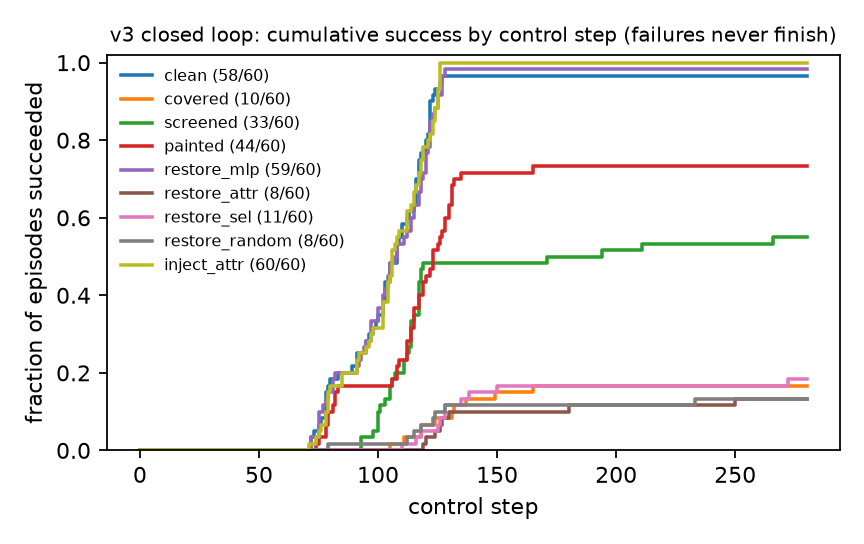

| condition | success | RMST (steps) | distractor lifted |
|---|---|---|---|
| clean | 58/60 | 109 | 0 |
| covered | 10/60 | 255 | 7 |
| screened | 33/60 | 193 | 0 |
| painted | 44/60 | 157 | 5 |
| restore_mlp | 59/60 | 108 | 0 |
| restore_attr | 8/60 | 262 | 6 |
| restore_random | 8/60 | 260 | 7 |
| inject_attr | 60/60 | 105 | 0 |
| restore_sel | 11/60 | 254 | 7 |

reproducibility vs archived v3 episodes: 540 / 540 same outcome


In [ ]:
# @title E0 · behaviour-level reanalysis of the v3 closed loop (CPU, ~1 min)
try:
    run_v4("reanalyze", resume=False)
    show4("fig_E0_success_by_step.png")
    t = json.loads((V4_OUT / "E0_behaviour_v3.json").read_text())
    display(Markdown("| condition | success | RMST (steps) | distractor lifted |\n|---|---|---|---|\n" + "\n".join(
        f"| {c} | {r['k']}/{r['n']} | {r['rmst_steps']:.0f} | {r['distractor_lifted']} |" for c, r in t["conditions"].items())))
    if t.get("reproducibility_vs_archived"):
        print("reproducibility vs archived v3 episodes:", t["reproducibility_vs_archived"]["same_success"], "/",
              t["reproducibility_vs_archived"]["n_common"], "same outcome")
except Exception:
    traceback.print_exc()

In [ ]:
# @title E2 · restoration controls under the box occluder, paired with v3 Goal 3 (~2 h, resumable per episode)
try:
    if RUN_E2_CONTROLS:
        run_v4("controls")
    else:
        print("RUN_E2_CONTROLS is off")
except Exception:
    traceback.print_exc()

$ /content/lerobot-venv/bin/python -u /content/groot-run/scripts/smaj_v4.py controls --out /content/groot-run/outputs/permanence/smaj_v4 --resume
[17:28:18] == controls | out=/content/groot-run/outputs/permanence/smaj_v4
/content/lerobot-venv/lib/python3.12/site-packages/robosuite/__init__.py:33: SyntaxWarning: invalid escape sequence '\ '
  /[_]\  [~]\/    |//  |
  ROBOSUITE_DEFAULT_LOGGER.warn("No private macro file found!")
[17:28:35] checkpoint config has compile_model=True -> disabling torch.compile (hooks need eager mode)
The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi
Loading model from: lerobot/pi05_libero_finetuned
✓ Loaded state dict from model.safetensors
All keys loaded successfully!
[17:31:03] policy PI05Policy loaded from lerobot/pi05_libero_finetuned in 149s | dtype=bfloat16 chunk=50 n_action_steps=50 image_

In [ ]:
# @title E3 · instrumented monitoring rollouts (~3.5-4 h full, resumable per episode)
try:
    if RUN_E3_MONITOR:
        run_v4("monitor")
    else:
        print("RUN_E3_MONITOR is off")
except Exception:
    traceback.print_exc()

$ /content/lerobot-venv/bin/python -u /content/groot-run/scripts/smaj_v4.py monitor --out /content/groot-run/outputs/permanence/smaj_v4 --resume
[20:22:07] == monitor | out=/content/groot-run/outputs/permanence/smaj_v4
  ROBOSUITE_DEFAULT_LOGGER.warn("No private macro file found!")
[20:22:14] checkpoint config has compile_model=True -> disabling torch.compile (hooks need eager mode)


In [ ]:
# @title E4 · gripper and speed feature discovery (CPU, ~5 min; needs E3's clean + box-miss episodes)
try:
    if (V4_OUT / "monitor" / "episodes.json").exists():
        run_v4("discover", resume=False)
        show4("fig_E4_grip_trace.png")
        d = V4_OUT / "discover" / "discover.json"
        if d.exists():
            d = json.loads(d.read_text())
            print("gripper held-out:", d["grip_heldout"], "\nspeed held-out:", d["speed_heldout"])
    else:
        print("no E3 episodes yet")
except Exception:
    traceback.print_exc()

In [ ]:
# @title E5 · steering vs prompting vs action scaling (~3.5-4 h full, resumable per episode)
try:
    if RUN_E5_STEER:
        run_v4("steer")
    else:
        print("RUN_E5_STEER is off")
except Exception:
    traceback.print_exc()

In [ ]:
# @title E6 · larger dictionary through the v3 open-loop protocol (~2.5 h; reuses the main run's frames and validation)
BIG_FEATURES = 8192  # @param {type:"integer"}
BIG_STEPS = 16000  # @param {type:"integer"}
import shutil

try:
    main_out = Path(RUNS["main"]["out"])
    if not RUN_E6_BIGDICT:
        print("RUN_E6_BIGDICT is off")
    elif not (main_out / "frames.pkl").exists():
        print("the main run's frames.pkl is not available (heavy file not restored); E6 is skipped")
    else:
        BIGDICT_OUT.mkdir(parents=True, exist_ok=True)
        for f in ("frames.pkl", "frames_candidates.json", "validate.json", "status/frames.json", "status/validate.json"):
            src, dst = main_out / f, BIGDICT_OUT / f
            if src.exists() and not dst.exists():
                dst.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(src, dst)
        cfg_big = json.loads((main_out / "config.json").read_text())
        cfg_big.update({"tc_features": int(BIG_FEATURES), "tc_steps": int(BIG_STEPS), "goal2_insample": False})
        (BIGDICT_OUT / "config.json").write_text(json.dumps(cfg_big, indent=2))
        RUNS["main_bigdict"] = {**cfg_big, "out": str(BIGDICT_OUT), "drive": str(DRIVE_V3 / BIGDICT_OUT.name),
                                "label": f"pi0.5 / LIBERO-Spatial, {BIG_FEATURES}-feature transcoders", "steps": "capture,train,goal1,attrib,goal2"}
        Path(RUNS["main_bigdict"]["drive"]).mkdir(parents=True, exist_ok=True)
        run_chain("main_bigdict")
        summary("main_bigdict")
except Exception:
    traceback.print_exc()

## Analysis, report and paper skeleton

In [ ]:
# @title Analysis + report: E2 / E3 / E5 / E6 statistics, figures, LaTeX tables, SPAIS draft skeleton (CPU, ~45 min)
try:
    run_v4("analyze,report", resume=False)
    show4("fig_E2_dose.png", "fig_E3_monitor_windows.png", "fig_E3_lead_time.png", "fig_E5_steering_forest.png", "fig_E6_fvu.png")
    s = V4_OUT / "SUMMARY.md"
    if s.exists():
        display(Markdown(s.read_text()))
    if COMPILE_PAPER_PDF:
        if not shutil.which("pdflatex"):
            subprocess.run(["apt-get", "install", "-y", "-qq", "--no-install-recommends", "texlive-latex-base", "texlive-latex-recommended",
                            "texlive-latex-extra", "texlive-fonts-recommended"], check=False, stdout=subprocess.DEVNULL)
        P = V4_OUT / "paper_v4"
        for cmd in (["pdflatex", "-interaction=nonstopmode", "main.tex"], ["bibtex", "main"], ["pdflatex", "-interaction=nonstopmode", "main.tex"]):
            subprocess.run(cmd, cwd=P, check=False, stdout=subprocess.DEVNULL)
        print("draft PDF:", P / "main.pdf", "exists:", (P / "main.pdf").exists())
    sync_to_drive(V4_OUT, DRIVE_V4)
except Exception:
    traceback.print_exc()

## Save, download, shut down
Saves everything to Drive, downloads the results zip (+ episode logs, transcoders and caches in ~1 GB parts) and shuts the runtime down.

In [ ]:
# @title Save everything to Drive, download everything to this computer, then shut the runtime down

# What you get on this computer (Chrome may ask once to "allow multiple downloads" from colab: click Allow):
#   smaj_v4_<time>_results.zip                        every result, the report, the paper (tex + pdf), scripts, this
#                                                      notebook WITH its outputs, logs, videos, environment, MANIFEST.tsv
#   tc_circuit_v3_<time>_models_and_caches_partNofM.zip transcoder weights, rendered probe frames, attribution arrays
# The same files are on Drive (DRIVE_OUTPUTS/permanence/...; see MANIFEST.tsv), whether or not the browser download works.
DOWNLOAD_TO_THIS_COMPUTER = True  # @param {type:"boolean"}
INCLUDE_MODELS_AND_CACHES = True  # @param {type:"boolean"}
PART_SIZE_GB = 1.0  # @param {type:"number"}
SHUTDOWN_WHEN_DONE = True  # @param {type:"boolean"}

import json
import time
import traceback
from pathlib import Path

shutdown = bool(SHUTDOWN_WHEN_DONE and globals().get("AUTO_SHUTDOWN_WHEN_DONE", True) and "shutdown_runtime" in globals())
if SHUTDOWN_WHEN_DONE and "shutdown_runtime" not in globals():
    print("the auto-shutdown cell was not run, so this cell cannot shut the runtime down: use Runtime -> Disconnect and delete runtime")
handed_off = False
try:
    _WD["managed"] = True  # this cell now owns the shutdown; the idle watchdog stands down
except NameError:
    pass
try:
    connected = browser_connected() if DOWNLOAD_TO_THIS_COMPUTER else False
    results_zip, heavy_zips = save_everything(to_browser=connected, include_heavy=bool(INCLUDE_MODELS_AND_CACHES and connected),
                                              part_gb=float(PART_SIZE_GB))
    files = [results_zip] + list(heavy_zips)
    if DOWNLOAD_TO_THIS_COMPUTER and connected:
        total_gb = sum(Path(f).stat().st_size for f in files) / 2 ** 30
        print(f"\nDownloading {len(files)} file(s), {total_gb:.2f} GB, to this computer. The transfer starts when this cell finishes "
              f"(progress bars appear below).")

        def on_finish(summary):
            ok = all(x["complete"] for x in summary)
            log = {"time": time.strftime("%Y-%m-%d %H:%M:%S"), "all_complete": ok, "files": summary}
            try:
                (Path(DRIVE_V3) / "bundles" / f"{Path(results_zip).stem}_download_log.json").write_text(json.dumps(log, indent=2))
            except Exception:
                pass
            print(f"\n[download] {'all files saved to this computer' if ok else 'some downloads did not finish'}: "
                  + ", ".join(f"{x['file']} {'OK' if x['complete'] else 'INCOMPLETE'}" for x in summary)
                  + ". Everything is also on Drive.", flush=True)
            if shutdown:
                shutdown_runtime("results saved to Drive and downloaded" + ("" if ok else " (partly: see the download log on Drive)"))

        state = start_browser_downloads(files)
        watch_downloads_then(state, on_finish)
        handed_off = True
        print("The runtime will shut itself down after the last file is saved." if shutdown else "SHUTDOWN_WHEN_DONE is off.")
    elif DOWNLOAD_TO_THIS_COMPUTER:
        print("\nNo browser tab is attached, so nothing can be downloaded to a computer right now. Everything is on Drive: "
              f"{Path(DRIVE_V3)} (bundles/ holds the results zip and MANIFEST.tsv).")
except Exception:
    traceback.print_exc()
    print("\nSaving/downloading failed (traceback above). The per-step Drive mirrors of every run are still complete.")
finally:
    if shutdown and not handed_off:
        shutdown_runtime("results saved to Drive")